# Final Analysis Notebook

This notebook evaluates MegaDetector human, animal and vehicle detection on manually validated MammalWeb camera-trap images. Manual annotations were collected through a blinded Streamlit annotation app using protocol version 1.1.

This notebook implements the final evaluation pipeline, including data and sampling audits, threshold-based validation performance, uncertainty and sampling-sensitivity analyses, privacy and safeguarding analysis, predicted-bbox and contextual/error analyses, uncertain-label robustness, class-specific operational-threshold synthesis and deployment score-trigger context.

Research questions:

1. How does MegaDetector performance vary by class and confidence threshold?
2. How do MegaDetector confidence thresholds affect precision-recall and false-positive/false-negative trade-offs, and what class-specific operating threshold strategy is most defensible for MammalWeb?
3. Does performance vary according to object size or contextual conditions?
4. Could missed human detections have privacy or safeguarding implications?


## Section 0. Reproducible Setup

This section defines paths, fixed configuration, output locations and package-version recording. All paths are relative to the project root so the notebook can be rerun from a cloned repository.

In [3]:
from pathlib import Path
import importlib.metadata
import json
import platform
import re
import sys

import numpy as np
import pandas as pd
from IPython.display import display

RANDOM_SEED = 42
PROTOCOL_VERSION = "1.1"

PROJECT_ROOT = Path.cwd()
SAMPLING_DIR = PROJECT_ROOT / "sampling_outputs"
OUTPUT_DIR = PROJECT_ROOT / "analysis_outputs"
TABLE_DIR = OUTPUT_DIR / "tables"
FIGURE_DIR = OUTPUT_DIR / "figures"
DERIVED_DIR = OUTPUT_DIR / "derived"

for directory in [OUTPUT_DIR, TABLE_DIR, FIGURE_DIR, DERIVED_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

pd.set_option("display.max_rows", 80)
pd.set_option("display.max_columns", 80)

written_files = []
rng = np.random.default_rng(RANDOM_SEED)

print("Project root:", PROJECT_ROOT)
print("Random seed:", RANDOM_SEED)
print("Expected annotation protocol:", PROTOCOL_VERSION)

Project root: c:\Users\cheng\Desktop\dissertation1-main\supplementary_var_chunk
Random seed: 42
Expected annotation protocol: 1.1


In [4]:
PACKAGE_NAMES = [
    "pandas",
    "numpy",
    "IPython",
    "jupyter",
    "nbformat",
    "nbclient",
]

version_rows = [
    {"package": "python", "version": sys.version.split()[0]},
    {"package": "platform", "version": platform.platform()},
]

for package_name in PACKAGE_NAMES:
    try:
        package_version = importlib.metadata.version(package_name)
    except importlib.metadata.PackageNotFoundError:
        package_version = "not installed"
    version_rows.append({"package": package_name, "version": package_version})

environment_versions = pd.DataFrame(version_rows)
display(environment_versions)

,package,version
0,python,3.13.14
1,platform,Windows-11-10.0.26200-SP0
2,pandas,2.2.3
3,numpy,2.2.3
4,IPython,9.3.0
5,jupyter,not installed
6,nbformat,5.10.4
7,nbclient,0.10.4


## Section 1. Load And Audit Frozen Inputs

The frozen manual ground-truth file and master sampling key are required inputs. If either file is absent, the notebook stops immediately with a clear error rather than substituting an earlier or similarly named file.

In [5]:
MANUAL_ANNOTATIONS_PATH = SAMPLING_DIR / "manual_annotations_final.csv"
MASTER_SAMPLING_KEY_PATH = SAMPLING_DIR / "master_annotation_sampling_key.csv"

def require_existing_file(path: Path) -> Path:
    if not path.exists():
        raise FileNotFoundError(
            f"Required source file not found: {path}. "
            "Do not substitute another manual annotation file; create or copy "
            "the frozen final file deliberately before rerunning this notebook."
        )
    return path

require_existing_file(MANUAL_ANNOTATIONS_PATH)
require_existing_file(MASTER_SAMPLING_KEY_PATH)

manual_annotations = pd.read_csv(MANUAL_ANNOTATIONS_PATH, dtype="string")
master_sampling_key = pd.read_csv(MASTER_SAMPLING_KEY_PATH, dtype="string")

manual_annotations.columns = manual_annotations.columns.str.strip()
master_sampling_key.columns = master_sampling_key.columns.str.strip()

print("Manual annotation rows:", f"{len(manual_annotations):,}")
print("Sampling-key rows:", f"{len(master_sampling_key):,}")

Manual annotation rows: 850
Sampling-key rows: 2,077


In [6]:
ANNOTATION_ID = "annotation_queue_id"
TARGET_CLASSES = ["human", "animal", "vehicle"]
MANUAL_LABEL_COLUMNS = {
    "human": "manual_human_present",
    "animal": "manual_animal_present",
    "vehicle": "manual_vehicle_present",
}
CORE_MANUAL_COLUMNS = [
    ANNOTATION_ID,
    "annotation_status",
    "annotation_quality",
    "protocol_version",
    *MANUAL_LABEL_COLUMNS.values(),
]
CORE_KEY_COLUMNS = [
    ANNOTATION_ID,
    "sample_type",
    "photo_id",
    "sequence_id",
    "site_id",
    "sampling_time_window",
    "season",
    "geographic_group",
    "evaluation_target_classes",
    "source_sampling_cell_ids",
    "selected_for_human",
    "selected_for_animal",
    "selected_for_vehicle",
]

def missing_required_columns(frame: pd.DataFrame, required_columns: list[str]) -> list[str]:
    return [column for column in required_columns if column not in frame.columns]

manual_missing_columns = missing_required_columns(manual_annotations, CORE_MANUAL_COLUMNS)
key_missing_columns = missing_required_columns(master_sampling_key, CORE_KEY_COLUMNS)

assert not manual_missing_columns, f"Manual annotations missing columns: {manual_missing_columns}"
assert not key_missing_columns, f"Sampling key missing columns: {key_missing_columns}"

def as_clean_string(series: pd.Series) -> pd.Series:
    return series.astype("string").str.strip()

def missing_text_mask(series: pd.Series) -> pd.Series:
    clean = as_clean_string(series)
    return clean.isna() | clean.eq("")

def normalised_text(series: pd.Series) -> pd.Series:
    return as_clean_string(series).str.lower()

allowed_label_values = {"yes", "no", "uncertain"}
allowed_quality_values = {"clear", "difficult but usable", "unusable"}
allowed_status_values = {"completed"}

audit_rows = []

def add_audit_row(check: str, value, severity: str = "info") -> None:
    audit_rows.append({"check": check, "value": value, "severity": severity})

add_audit_row("manual_rows", len(manual_annotations))
add_audit_row("sampling_key_rows", len(master_sampling_key))
add_audit_row("manual_unique_annotation_queue_id", manual_annotations[ANNOTATION_ID].nunique(dropna=True))
add_audit_row("sampling_key_unique_annotation_queue_id", master_sampling_key[ANNOTATION_ID].nunique(dropna=True))
add_audit_row("manual_duplicate_annotation_queue_id", int(manual_annotations[ANNOTATION_ID].duplicated().sum()), "critical")
add_audit_row("sampling_key_duplicate_annotation_queue_id", int(master_sampling_key[ANNOTATION_ID].duplicated().sum()), "critical")
add_audit_row("manual_missing_annotation_queue_id", int(missing_text_mask(manual_annotations[ANNOTATION_ID]).sum()), "critical")
add_audit_row("sampling_key_missing_annotation_queue_id", int(missing_text_mask(master_sampling_key[ANNOTATION_ID]).sum()), "critical")

for column in ["annotation_status", "annotation_quality", "protocol_version", *MANUAL_LABEL_COLUMNS.values()]:
    add_audit_row(f"missing_{column}", int(missing_text_mask(manual_annotations[column]).sum()), "warning")

status_values = set(normalised_text(manual_annotations["annotation_status"]).dropna()) - {""}
quality_values = set(normalised_text(manual_annotations["annotation_quality"]).dropna()) - {""}
protocol_values = set(as_clean_string(manual_annotations["protocol_version"]).dropna()) - {""}

add_audit_row("annotation_status_values", json.dumps(sorted(status_values)))
add_audit_row("annotation_quality_values", json.dumps(sorted(quality_values)))
add_audit_row("protocol_versions", json.dumps(sorted(protocol_values)))
add_audit_row("unexpected_annotation_status_values", json.dumps(sorted(status_values - allowed_status_values)), "critical")
add_audit_row("unexpected_annotation_quality_values", json.dumps(sorted(quality_values - allowed_quality_values)), "critical")
add_audit_row("unexpected_protocol_versions", json.dumps(sorted(protocol_values - {PROTOCOL_VERSION})), "critical")

for target_class, label_column in MANUAL_LABEL_COLUMNS.items():
    label_values = set(normalised_text(manual_annotations[label_column]).dropna()) - {""}
    unexpected_values = sorted(label_values - allowed_label_values)
    add_audit_row(f"{target_class}_label_values", json.dumps(sorted(label_values)))
    add_audit_row(f"unexpected_{target_class}_label_values", json.dumps(unexpected_values), "critical")

annotation_audit_table = pd.DataFrame(audit_rows)
display(annotation_audit_table)

,check,value,severity
0,manual_rows,850,info
1,sampling_key_rows,2077,info
2,manual_unique_annotation_queue_id,850,info
3,sampling_key_unique_annotation_queue_id,2077,info
4,manual_duplicate_annotation_queue_id,0,critical
5,sampling_key_duplicate_annotation_queue_id,0,critical
6,manual_missing_annotation_queue_id,0,critical
7,sampling_key_missing_annotation_queue_id,0,critical
8,missing_annotation_status,0,warning
9,missing_annotation_quality,0,warning


In [7]:
critical_audit = annotation_audit_table.loc[
    annotation_audit_table["severity"].eq("critical")
]

numeric_critical = critical_audit.loc[
    critical_audit["value"].apply(lambda value: isinstance(value, (int, np.integer)))
]
assert numeric_critical["value"].eq(0).all(), numeric_critical

text_critical = critical_audit.loc[
    critical_audit["value"].apply(lambda value: isinstance(value, str))
]
assert text_critical["value"].eq("[]").all(), text_critical

assert set(as_clean_string(manual_annotations["protocol_version"]).dropna()) == {PROTOCOL_VERSION}
assert normalised_text(manual_annotations["annotation_status"]).eq("completed").all()

annotation_audit_path = TABLE_DIR / "annotation_source_audit.csv"
annotation_audit_table.to_csv(annotation_audit_path, index=False)
written_files.append(annotation_audit_path)

print("Source annotation audit passed")
print("Saved:", annotation_audit_path.relative_to(PROJECT_ROOT))

Source annotation audit passed
Saved: analysis_outputs\tables\annotation_source_audit.csv


### Manual Annotation QC Provenance

Annotations were collected through the blinded protocol v1.1 workflow. Consistency checks identified cases requiring manual review: 39 flagged consistency cases were reviewed, followed by a random QC review of 50 annotations. Legitimate corrections were made where needed, and labels were frozen before MegaDetector outputs were unblinded for final evaluation. This documents annotation provenance and QC; it is not an inter-rater reliability assessment because there was no independent second annotator.

## Section 2. Merge And Canonical Dataset

Manual annotations are merged once to the master sampling key using `annotation_queue_id`. The merge audit explicitly reports unmatched IDs before `analysis_df` is created. The canonical dataframe is then enriched with available detector and sampling metadata from existing project artifacts.

In [8]:
manual_ids = manual_annotations[[ANNOTATION_ID]].copy()
key_ids = master_sampling_key[[ANNOTATION_ID]].copy()

merge_probe = manual_ids.merge(
    key_ids,
    on=ANNOTATION_ID,
    how="outer",
    indicator=True,
    validate="one_to_one",
)

merge_audit_table = pd.DataFrame(
    [
        {"metric": "manual_annotation_rows", "value": len(manual_annotations)},
        {"metric": "sampling_key_rows", "value": len(master_sampling_key)},
        {"metric": "matched_rows", "value": int(merge_probe["_merge"].eq("both").sum())},
        {"metric": "manual_only_ids", "value": int(merge_probe["_merge"].eq("left_only").sum())},
        {"metric": "key_only_ids", "value": int(merge_probe["_merge"].eq("right_only").sum())},
        {"metric": "duplicate_ids_after_merge", "value": int(merge_probe[ANNOTATION_ID].duplicated().sum())},
    ]
)

display(merge_audit_table)

manual_only_ids = merge_probe.loc[merge_probe["_merge"].eq("left_only"), ANNOTATION_ID].tolist()
assert not manual_only_ids, f"Manual annotations without sampling-key matches: {manual_only_ids[:10]}"

analysis_df = manual_annotations.merge(
    master_sampling_key,
    on=ANNOTATION_ID,
    how="left",
    validate="one_to_one",
)

assert len(analysis_df) == len(manual_annotations)
assert analysis_df[ANNOTATION_ID].is_unique
assert analysis_df["photo_id"].notna().all()

merge_audit_path = TABLE_DIR / "manual_sampling_key_merge_audit.csv"
merge_audit_table.to_csv(merge_audit_path, index=False)
written_files.append(merge_audit_path)

print("Canonical manual-to-key merge passed")
print("Saved:", merge_audit_path.relative_to(PROJECT_ROOT))

,metric,value
0,manual_annotation_rows,850
1,sampling_key_rows,2077
2,matched_rows,850
3,manual_only_ids,0
4,key_only_ids,1227
5,duplicate_ids_after_merge,0


Canonical manual-to-key merge passed
Saved: analysis_outputs\tables\manual_sampling_key_merge_audit.csv


In [9]:
SAMPLING_PREPARED_PATH = PROJECT_ROOT / "sampling_prepared.csv"
FINAL_POSITIVE_QUEUE_PATH = SAMPLING_DIR / "final_positive_image_queue.csv"
FINAL_POSITIVE_RECORDS_PATH = SAMPLING_DIR / "final_positive_class_records.csv"
FINAL_ZERO_QUEUE_PATH = SAMPLING_DIR / "final_zero_confidence_image_queue.csv"
POSITIVE_SAMPLING_DIAGNOSTICS_PATH = SAMPLING_DIR / "positive_sampling_diagnostics.csv"
FINAL_POSITIVE_DIAGNOSTICS_PATH = SAMPLING_DIR / "final_positive_sampling_diagnostics.csv"
POSITIVE_CELL_COUNTS_PATH = SAMPLING_DIR / "positive_cell_candidate_counts.csv"
POSITIVE_CANDIDATE_SUMMARY_PATH = SAMPLING_DIR / "positive_candidate_summary.csv"
CONFIDENCE_POPULATION_PATH = PROJECT_ROOT / "confidence_band_population_counts.csv"
ZERO_CANDIDATE_RECORDS_PATH = SAMPLING_DIR / "zero_confidence_candidate_records.csv"
ZERO_METADATA_PATH = PROJECT_ROOT / "zero_metadata_combined.csv"

OPTIONAL_ARTIFACTS = {
    "sampling_prepared": SAMPLING_PREPARED_PATH,
    "final_positive_image_queue": FINAL_POSITIVE_QUEUE_PATH,
    "final_positive_class_records": FINAL_POSITIVE_RECORDS_PATH,
    "final_zero_confidence_image_queue": FINAL_ZERO_QUEUE_PATH,
    "positive_sampling_diagnostics": POSITIVE_SAMPLING_DIAGNOSTICS_PATH,
    "final_positive_sampling_diagnostics": FINAL_POSITIVE_DIAGNOSTICS_PATH,
    "positive_cell_candidate_counts": POSITIVE_CELL_COUNTS_PATH,
    "positive_candidate_summary": POSITIVE_CANDIDATE_SUMMARY_PATH,
    "confidence_band_population_counts": CONFIDENCE_POPULATION_PATH,
    "zero_confidence_candidate_records": ZERO_CANDIDATE_RECORDS_PATH,
    "zero_metadata_combined": ZERO_METADATA_PATH,
}

def read_optional_csv(path: Path, name: str) -> pd.DataFrame | None:
    if not path.exists():
        print(f"Optional artifact unavailable: {name} ({path.relative_to(PROJECT_ROOT)})")
        return None
    frame = pd.read_csv(path, dtype="string", low_memory=False)
    frame.columns = frame.columns.str.strip()
    print(f"Loaded optional artifact: {name} ({len(frame):,} rows, {len(frame.columns):,} columns)")
    return frame

artifact_frames = {
    name: read_optional_csv(path, name)
    for name, path in OPTIONAL_ARTIFACTS.items()
}

artifact_inventory = pd.DataFrame(
    [
        {
            "artifact": name,
            "path": str(path.relative_to(PROJECT_ROOT)),
            "available": path.exists(),
            "rows": None if artifact_frames[name] is None else len(artifact_frames[name]),
            "columns": None if artifact_frames[name] is None else len(artifact_frames[name].columns),
        }
        for name, path in OPTIONAL_ARTIFACTS.items()
    ]
)

display(artifact_inventory)

Loaded optional artifact: sampling_prepared (6,720,367 rows, 64 columns)
Loaded optional artifact: final_positive_image_queue (1,677 rows, 23 columns)
Loaded optional artifact: final_positive_class_records (1,680 rows, 82 columns)
Loaded optional artifact: final_zero_confidence_image_queue (400 rows, 21 columns)
Loaded optional artifact: positive_sampling_diagnostics (84 rows, 15 columns)
Loaded optional artifact: final_positive_sampling_diagnostics (84 rows, 10 columns)
Loaded optional artifact: positive_cell_candidate_counts (84 rows, 4 columns)
Loaded optional artifact: positive_candidate_summary (3 rows, 10 columns)
Loaded optional artifact: confidence_band_population_counts (24 rows, 3 columns)
Loaded optional artifact: zero_confidence_candidate_records (798 rows, 72 columns)
Loaded optional artifact: zero_metadata_combined (3,559,125 rows, 12 columns)


,artifact,path,available,rows,columns
0,sampling_prepared,sampling_prepared.csv,True,6720367,64
1,final_positive_image_queue,sampling_outputs\final_positive_image_queue.csv,True,1677,23
2,final_positive_class_records,sampling_outputs\final_positive_class_records.csv,True,1680,82
3,final_zero_confidence_image_queue,sampling_outputs\final_zero_confidence_image_q...,True,400,21
4,positive_sampling_diagnostics,sampling_outputs\positive_sampling_diagnostics...,True,84,15
5,final_positive_sampling_diagnostics,sampling_outputs\final_positive_sampling_diagn...,True,84,10
6,positive_cell_candidate_counts,sampling_outputs\positive_cell_candidate_count...,True,84,4
7,positive_candidate_summary,sampling_outputs\positive_candidate_summary.csv,True,3,10
8,confidence_band_population_counts,confidence_band_population_counts.csv,True,24,3
9,zero_confidence_candidate_records,sampling_outputs\zero_confidence_candidate_rec...,True,798,72


In [10]:
def merge_image_metadata(
    left: pd.DataFrame,
    right: pd.DataFrame | None,
    source_name: str,
    columns: list[str],
) -> pd.DataFrame:
    if right is None:
        return left
    if "photo_id" not in right.columns:
        print(f"Skipping {source_name}: no photo_id column")
        return left

    available_columns = ["photo_id"] + [column for column in columns if column in right.columns]
    if len(available_columns) == 1:
        print(f"Skipping {source_name}: none of the requested metadata columns are available")
        return left

    right_metadata = right[available_columns].drop_duplicates().copy()
    duplicate_photo_ids = right_metadata["photo_id"].duplicated().sum()
    if duplicate_photo_ids:
        right_metadata = (
            right_metadata
            .sort_values("photo_id")
            .drop_duplicates(subset="photo_id", keep="first")
        )
        print(f"{source_name}: collapsed {duplicate_photo_ids:,} duplicate photo_id metadata rows")

    rename_map = {
        column: f"{column}__{source_name}"
        for column in right_metadata.columns
        if column != "photo_id" and column in left.columns
    }
    right_metadata = right_metadata.rename(columns=rename_map)

    before_rows = len(left)
    merged = left.merge(
        right_metadata,
        on="photo_id",
        how="left",
        validate="many_to_one",
    )
    assert len(merged) == before_rows
    return merged

sampling_prepared_columns = [
    "mega_human_confidence",
    "mega_animal_confidence",
    "mega_vehicle_confidence",
    "human_confidence_band",
    "animal_confidence_band",
    "vehicle_confidence_band",
    "time_window",
    "taken_dt",
    "year",
    "month",
    "hour",
    "latitude",
    "longitude",
    "n_human_boxes",
    "n_animal_boxes",
    "n_vehicle_boxes",
    "human_bbox_prob",
    "animal_bbox_prob",
    "vehicle_bbox_prob",
    "human_xmin",
    "human_ymin",
    "human_xmax",
    "human_ymax",
    "animal_xmin",
    "animal_ymin",
    "animal_xmax",
    "animal_ymax",
    "vehicle_xmin",
    "vehicle_ymin",
    "vehicle_xmax",
    "vehicle_ymax",
    "human_bbox_width_px",
    "human_bbox_height_px",
    "human_bbox_area_px",
    "animal_bbox_width_px",
    "animal_bbox_height_px",
    "animal_bbox_area_px",
    "vehicle_bbox_width_px",
    "vehicle_bbox_height_px",
    "vehicle_bbox_area_px",
    "human_has_bbox",
    "animal_has_bbox",
    "vehicle_has_bbox",
    "has_time_metadata",
    "has_geographic_metadata",
    "has_sequence_metadata",
]

positive_queue_columns = [
    "image_width_px",
    "image_height_px",
    "image_format",
    "image_access_status",
    "positive_target_classes",
    "positive_candidate_record_ids",
    "positive_final_record_ids",
    "positive_sampling_cell_ids",
    "number_positive_target_classes",
    "positive_image_queue_id",
]

zero_queue_columns = [
    "zero_final_id",
    "zero_sampling_cell_id",
    "zero_candidate_id",
    "zero_candidate_rank",
    "image_accessible",
    "http_status",
    "content_type",
]

analysis_df = merge_image_metadata(
    analysis_df,
    artifact_frames["sampling_prepared"],
    "sampling_prepared",
    sampling_prepared_columns,
)
analysis_df = merge_image_metadata(
    analysis_df,
    artifact_frames["final_positive_image_queue"],
    "final_positive_image_queue",
    positive_queue_columns,
)
analysis_df = merge_image_metadata(
    analysis_df,
    artifact_frames["final_zero_confidence_image_queue"],
    "final_zero_confidence_image_queue",
    zero_queue_columns,
)

assert len(analysis_df) == len(manual_annotations)
assert analysis_df[ANNOTATION_ID].is_unique

print("analysis_df rows:", f"{len(analysis_df):,}")
print("analysis_df columns:", f"{len(analysis_df.columns):,}")

analysis_df rows: 850
analysis_df columns: 103


In [11]:
def join_unique_values(series: pd.Series) -> str:
    values = sorted({str(value) for value in series.dropna() if str(value) != ""})
    return "|".join(values)

def join_class_value_pairs(frame: pd.DataFrame, value_column: str) -> str:
    if value_column not in frame.columns:
        return ""
    pairs = []
    for _, row in frame[["target_class", value_column]].dropna().iterrows():
        pairs.append(f"{row['target_class']}:{row[value_column]}")
    return "|".join(sorted(set(pairs)))

final_positive_records = artifact_frames["final_positive_class_records"]

if final_positive_records is not None and {"photo_id", "target_class"}.issubset(final_positive_records.columns):
    positive_record_summary_rows = []
    for photo_id, photo_records in final_positive_records.groupby("photo_id", observed=True):
        positive_record_summary_rows.append(
            {
                "photo_id": photo_id,
                "positive_record_target_classes": join_unique_values(photo_records["target_class"]),
                "positive_record_sampling_cells": join_class_value_pairs(photo_records, "sampling_cell_id"),
                "positive_record_bbox_groups": join_class_value_pairs(photo_records, "relative_bbox_group"),
                "positive_record_ids_from_class_table": join_unique_values(photo_records.get("final_positive_record_id", pd.Series(dtype="string"))),
            }
        )
    positive_record_summary = pd.DataFrame(positive_record_summary_rows)
    analysis_df = analysis_df.merge(
        positive_record_summary,
        on="photo_id",
        how="left",
        validate="many_to_one",
    )
    assert len(analysis_df) == len(manual_annotations)
else:
    positive_record_summary = pd.DataFrame()

print("Canonical analysis dataframe prepared:", f"{len(analysis_df):,} rows")

Canonical analysis dataframe prepared: 850 rows


In [12]:
COLUMN_CONCEPT_CANDIDATES = {
    "photo ID": ["photo_id"],
    "sequence ID": ["sequence_id"],
    "site ID": ["site_id"],
    "MegaDetector human confidence": ["mega_human_confidence"],
    "MegaDetector animal confidence": ["mega_animal_confidence"],
    "MegaDetector vehicle confidence": ["mega_vehicle_confidence"],
    "sample origin/type": ["sample_type"],
    "selected sampling class": ["evaluation_target_classes", "selected_for_human", "selected_for_animal", "selected_for_vehicle", "positive_target_classes", "positive_record_target_classes"],
    "confidence band": ["human_confidence_band", "animal_confidence_band", "vehicle_confidence_band", "sampling_confidence_band", "source_sampling_cell_ids", "positive_sampling_cell_ids"],
    "time window": ["sampling_time_window", "time_window", "source_sampling_cell_ids", "zero_sampling_cell_id"],
    "season": ["season"],
    "geography": ["geographic_group", "latitude", "longitude"],
    "bounding-box information": [
        "n_human_boxes", "n_animal_boxes", "n_vehicle_boxes",
        "human_bbox_prob", "animal_bbox_prob", "vehicle_bbox_prob",
        "human_xmin", "human_ymin", "human_xmax", "human_ymax",
        "animal_xmin", "animal_ymin", "animal_xmax", "animal_ymax",
        "vehicle_xmin", "vehicle_ymin", "vehicle_xmax", "vehicle_ymax",
        "human_bbox_width_px", "human_bbox_height_px", "human_bbox_area_px",
        "animal_bbox_width_px", "animal_bbox_height_px", "animal_bbox_area_px",
        "vehicle_bbox_width_px", "vehicle_bbox_height_px", "vehicle_bbox_area_px",
        "relative_bbox_area", "relative_bbox_group", "positive_record_bbox_groups",
    ],
    "image dimensions": ["image_width_px", "image_height_px", "image_area_px", "image_format"],
    "sampling-stratum identifiers": ["source_sampling_cell_ids", "positive_sampling_cell_ids", "sampling_cell_id", "zero_sampling_cell_id"],
}

source_frames = {
    "analysis_df": analysis_df,
    "manual_annotations_final": manual_annotations,
    "master_annotation_sampling_key": master_sampling_key,
    **{name: frame for name, frame in artifact_frames.items() if frame is not None},
}

column_inventory_rows = []

for concept, candidate_columns in COLUMN_CONCEPT_CANDIDATES.items():
    for source_name, frame in source_frames.items():
        found_columns = [column for column in candidate_columns if column in frame.columns]
        if found_columns:
            column_inventory_rows.append(
                {
                    "concept": concept,
                    "source": source_name,
                    "status": "available",
                    "columns": "|".join(found_columns),
                }
            )
    if not any(
        [column for source_frame in source_frames.values() for column in candidate_columns if column in source_frame.columns]
    ):
        column_inventory_rows.append(
            {
                "concept": concept,
                "source": "all_inspected_sources",
                "status": "unavailable",
                "columns": "",
            }
        )

column_inventory = pd.DataFrame(column_inventory_rows)
display(column_inventory)

column_inventory_path = TABLE_DIR / "column_inventory.csv"
artifact_inventory_path = TABLE_DIR / "sampling_artifact_inventory.csv"
column_inventory.to_csv(column_inventory_path, index=False)
artifact_inventory.to_csv(artifact_inventory_path, index=False)
written_files.extend([column_inventory_path, artifact_inventory_path])

print("Saved:", column_inventory_path.relative_to(PROJECT_ROOT))
print("Saved:", artifact_inventory_path.relative_to(PROJECT_ROOT))

,concept,source,status,columns
0,photo ID,analysis_df,available,photo_id
1,photo ID,master_annotation_sampling_key,available,photo_id
2,photo ID,sampling_prepared,available,photo_id
3,photo ID,final_positive_image_queue,available,photo_id
4,photo ID,final_positive_class_records,available,photo_id
...,...,...,...,...
83,sampling-stratum identifiers,master_annotation_sampling_key,available,source_sampling_cell_ids
84,sampling-stratum identifiers,final_positive_image_queue,available,positive_sampling_cell_ids
85,sampling-stratum identifiers,final_positive_class_records,available,sampling_cell_id
86,sampling-stratum identifiers,final_zero_confidence_image_queue,available,zero_sampling_cell_id


Saved: analysis_outputs\tables\column_inventory.csv
Saved: analysis_outputs\tables\sampling_artifact_inventory.csv


## Section 3. Manual Annotation Rules And Evaluable Sample

`annotation_quality == "Unusable"` excludes the image globally from primary performance analyses. Class-specific `Uncertain` labels exclude only that class from evaluation: an uncertain human label does not prevent animal or vehicle evaluation, and the same logic applies to animal and vehicle labels.

In [13]:
quality_clean = normalised_text(analysis_df["annotation_quality"])
analysis_df["globally_usable"] = quality_clean.ne("unusable")

for target_class, label_column in MANUAL_LABEL_COLUMNS.items():
    label_clean = normalised_text(analysis_df[label_column])

    analysis_df[f"{target_class}_evaluable"] = (
        analysis_df["globally_usable"]
        & label_clean.isin(["yes", "no"])
    )

assert (
    analysis_df.loc[
        ~analysis_df["globally_usable"],
        [f"{target_class}_evaluable" for target_class in TARGET_CLASSES],
    ]
    .sum()
    .sum()
    == 0
)

for target_class, label_column in MANUAL_LABEL_COLUMNS.items():
    evaluable_mask = analysis_df[f"{target_class}_evaluable"]

    observed_values = set(
        normalised_text(
            analysis_df.loc[evaluable_mask, label_column]
        ).dropna()
    )

    assert observed_values <= {"yes", "no"}, (
        f"Unexpected {target_class} values among evaluable rows: "
        f"{observed_values}"
    )

flag_summary = (
    analysis_df[
        [
            "globally_usable",
            "human_evaluable",
            "animal_evaluable",
            "vehicle_evaluable",
        ]
    ]
    .mean()
    .rename_axis("flag")
    .reset_index(name="share_of_annotated_rows")
)

display(flag_summary)

,flag,share_of_annotated_rows
0,globally_usable,0.963529
1,human_evaluable,0.951765
2,animal_evaluable,0.894118
3,vehicle_evaluable,0.949412


In [14]:
exclusion_rows = []

for target_class, label_column in MANUAL_LABEL_COLUMNS.items():
    label_clean = normalised_text(analysis_df[label_column])
    globally_usable = analysis_df["globally_usable"]
    evaluable = analysis_df[f"{target_class}_evaluable"]

    exclusion_rows.append(
        {
            "class": target_class,
            "total_annotated_n": len(analysis_df),
            "unusable_n": int((~globally_usable).sum()),
            "class_specific_uncertain_n": int((globally_usable & label_clean.eq("uncertain")).sum()),
            "final_evaluable_n": int(evaluable.sum()),
            "manual_positive_n": int((evaluable & label_clean.eq("yes")).sum()),
            "manual_negative_n": int((evaluable & label_clean.eq("no")).sum()),
        }
    )

final_sample_exclusions = pd.DataFrame(exclusion_rows)

for _, row in final_sample_exclusions.iterrows():
    assert row["manual_positive_n"] + row["manual_negative_n"] == row["final_evaluable_n"]

display(final_sample_exclusions)

exclusion_table_path = TABLE_DIR / "final_sample_exclusions.csv"
final_sample_exclusions.to_csv(exclusion_table_path, index=False)
written_files.append(exclusion_table_path)

analysis_dataset_path = DERIVED_DIR / "analysis_dataset.csv"
analysis_df.to_csv(analysis_dataset_path, index=False)
written_files.append(analysis_dataset_path)

print("Saved:", exclusion_table_path.relative_to(PROJECT_ROOT))
print("Saved:", analysis_dataset_path.relative_to(PROJECT_ROOT))
print("PRIVATE / DO NOT COMMIT TO PUBLIC GITHUB: analysis_dataset.csv may contain sensitive MammalWeb identifiers and is excluded from public-output recommendations.")

,class,total_annotated_n,unusable_n,class_specific_uncertain_n,final_evaluable_n,manual_positive_n,manual_negative_n
0,human,850,31,10,809,108,701
1,animal,850,31,59,760,198,562
2,vehicle,850,31,12,807,100,707


Saved: analysis_outputs\tables\final_sample_exclusions.csv
Saved: analysis_outputs\derived\analysis_dataset.csv
PRIVATE / DO NOT COMMIT TO PUBLIC GITHUB: analysis_dataset.csv may contain sensitive MammalWeb identifiers and is excluded from public-output recommendations.


## Section 4. Sampling Design Audit

The validation sample was not a simple random sample. Positive-confidence sampling was performed separately for human, animal and vehicle across confidence-band by time-window cells, with sequence/site restrictions and balancing by geography, season and later relative bounding-box size. A separate all-zero sample was shared across all three classes, stratified by time window, season and geographic group.

The diagnostics below reconstruct what is recoverable from saved repository artifacts. They do not calculate final sampling weights or headline MegaDetector performance metrics.

### 4.1 Positive-Confidence Sampling Pathway

Existing sampling notebooks indicate that positive-confidence candidate sampling used seven confidence bands and four usable time windows for each target class, producing 28 cells per class. Candidate sampling requested 40 images per class-specific cell with one image per sequence, a maximum of two candidate images per site, and geography/season balancing. Final positive selection retained 20 class-records per cell, incorporated relative bounding-box groups, and avoided repeated sites within each class where feasible. Because some images were selected for more than one target class, the final positive image queue deduplicated repeated photo IDs while preserving selected class flags.

In [15]:
POSITIVE_CONFIDENCE_BANDS = [
    "0.01_to_0.02",
    "0.02_to_0.05",
    "0.05_to_0.10",
    "0.10_to_0.30",
    "0.30_to_0.70",
    "0.70_to_0.90",
    "0.90_to_1.00",
]
USABLE_TIME_WINDOWS = [
    "overnight",
    "morning_transition",
    "daytime_core",
    "evening_transition",
]

positive_design_summary = pd.DataFrame(
    [
        {"design_feature": "target classes", "value": "human|animal|vehicle"},
        {"design_feature": "positive confidence bands", "value": "|".join(POSITIVE_CONFIDENCE_BANDS)},
        {"design_feature": "positive time windows", "value": "|".join(USABLE_TIME_WINDOWS)},
        {"design_feature": "positive cells per class", "value": len(POSITIVE_CONFIDENCE_BANDS) * len(USABLE_TIME_WINDOWS)},
        {"design_feature": "candidate target per positive cell", "value": 40},
        {"design_feature": "final target per positive cell", "value": 20},
        {"design_feature": "candidate sequence cap", "value": "one image per sequence"},
        {"design_feature": "candidate site cap", "value": "maximum two candidate images per site within class"},
        {"design_feature": "final site restriction", "value": "site reuse avoided within class during final selection"},
        {"design_feature": "balancing variables", "value": "geographic_group|season|relative_bbox_group"},
    ]
)

display(positive_design_summary)

,design_feature,value
0,target classes,human|animal|vehicle
1,positive confidence bands,0.01_to_0.02|0.02_to_0.05|0.05_to_0.10|0.10_to...
2,positive time windows,overnight|morning_transition|daytime_core|even...
3,positive cells per class,28
4,candidate target per positive cell,40
5,final target per positive cell,20
6,candidate sequence cap,one image per sequence
7,candidate site cap,maximum two candidate images per site within c...
8,final site restriction,site reuse avoided within class during final s...
9,balancing variables,geographic_group|season|relative_bbox_group


In [16]:
def parse_positive_sampling_cells(frame: pd.DataFrame) -> pd.DataFrame:
    if "source_sampling_cell_ids" not in frame.columns:
        return pd.DataFrame(columns=[ANNOTATION_ID, "target_class", "sampling_confidence_band", "sampling_time_window"])

    parsed_rows = []
    for _, row in frame[[ANNOTATION_ID, "source_sampling_cell_ids"]].iterrows():
        cell_value = row["source_sampling_cell_ids"]
        if pd.isna(cell_value):
            continue
        for cell_id in str(cell_value).split("|"):
            match = re.match(r"^(human|animal|vehicle)__(.+)__(.+)$", cell_id)
            if not match:
                continue
            parsed_rows.append(
                {
                    ANNOTATION_ID: row[ANNOTATION_ID],
                    "target_class": match.group(1),
                    "sampling_confidence_band": match.group(2),
                    "sampling_time_window": match.group(3),
                }
            )
    return pd.DataFrame(parsed_rows)

positive_annotation_cells = parse_positive_sampling_cells(analysis_df)

if not positive_annotation_cells.empty:
    positive_annotation_cells = positive_annotation_cells.merge(
        analysis_df[[ANNOTATION_ID, "human_evaluable", "animal_evaluable", "vehicle_evaluable"]],
        on=ANNOTATION_ID,
        how="left",
        validate="many_to_one",
    )
    for target_class in TARGET_CLASSES:
        positive_annotation_cells.loc[
            positive_annotation_cells["target_class"].eq(target_class),
            "class_evaluable",
        ] = positive_annotation_cells.loc[
            positive_annotation_cells["target_class"].eq(target_class),
            f"{target_class}_evaluable",
        ].astype(bool)

    positive_annotated_by_cell = (
        positive_annotation_cells
        .groupby(["target_class", "sampling_confidence_band", "sampling_time_window"], observed=True)
        .agg(
            annotated_n=(ANNOTATION_ID, "nunique"),
            evaluable_n=("class_evaluable", "sum"),
        )
        .reset_index()
    )
else:
    positive_annotated_by_cell = pd.DataFrame(
        columns=["target_class", "sampling_confidence_band", "sampling_time_window", "annotated_n", "evaluable_n"]
    )

display(positive_annotated_by_cell.head(20))

,target_class,sampling_confidence_band,sampling_time_window,annotated_n,evaluable_n
0,animal,0.01_to_0.02,daytime_core,6,6
1,animal,0.01_to_0.02,evening_transition,3,2
2,animal,0.01_to_0.02,morning_transition,6,6
3,animal,0.01_to_0.02,overnight,8,7
4,animal,0.02_to_0.05,daytime_core,10,10
5,animal,0.02_to_0.05,evening_transition,13,11
6,animal,0.02_to_0.05,morning_transition,9,9
7,animal,0.02_to_0.05,overnight,4,3
8,animal,0.05_to_0.10,daytime_core,5,3
9,animal,0.05_to_0.10,evening_transition,11,11


In [17]:
positive_sampling_diagnostics = artifact_frames["positive_sampling_diagnostics"]
positive_cell_counts = artifact_frames["positive_cell_candidate_counts"]
final_positive_diagnostics = artifact_frames["final_positive_sampling_diagnostics"]
confidence_population = artifact_frames["confidence_band_population_counts"]

if positive_sampling_diagnostics is not None:
    positive_eligible = positive_sampling_diagnostics.rename(
        columns={
            "confidence_band": "sampling_confidence_band",
            "time_window": "sampling_time_window",
            "available_images": "eligible_n",
            "selected_candidates": "candidate_selected_n",
        }
    )[
        [
            "target_class",
            "sampling_confidence_band",
            "sampling_time_window",
            "eligible_n",
            "candidate_selected_n",
            "unique_sequences_selected",
            "unique_sites_selected",
            "maximum_images_from_one_site",
        ]
    ].copy()
else:
    positive_eligible = pd.DataFrame(columns=["target_class", "sampling_confidence_band", "sampling_time_window"])

if final_positive_records is not None:
    final_selected_by_cell = (
        final_positive_records
        .groupby(["target_class", "sampling_confidence_band", "sampling_time_window"], observed=True)
        .size()
        .rename("final_selected_n")
        .reset_index()
    )
else:
    final_selected_by_cell = pd.DataFrame(columns=["target_class", "sampling_confidence_band", "sampling_time_window", "final_selected_n"])

positive_stratum_audit = positive_eligible.merge(
    final_selected_by_cell,
    on=["target_class", "sampling_confidence_band", "sampling_time_window"],
    how="outer",
    validate="one_to_one",
).merge(
    positive_annotated_by_cell,
    on=["target_class", "sampling_confidence_band", "sampling_time_window"],
    how="outer",
    validate="one_to_one",
)

if confidence_population is not None:
    confidence_population_for_merge = confidence_population.rename(
        columns={"confidence_band": "sampling_confidence_band", "population_count": "confidence_band_population_n"}
    )[["target_class", "sampling_confidence_band", "confidence_band_population_n"]]
    positive_stratum_audit = positive_stratum_audit.merge(
        confidence_population_for_merge,
        on=["target_class", "sampling_confidence_band"],
        how="left",
        validate="many_to_one",
    )

for column in ["eligible_n", "candidate_selected_n", "final_selected_n", "annotated_n", "evaluable_n"]:
    if column in positive_stratum_audit.columns:
        positive_stratum_audit[column] = pd.to_numeric(positive_stratum_audit[column], errors="coerce")

positive_stratum_audit = positive_stratum_audit.sort_values(
    ["target_class", "sampling_confidence_band", "sampling_time_window"],
    na_position="last",
).reset_index(drop=True)

positive_stratum_audit_path = TABLE_DIR / "positive_sampling_stratum_audit.csv"
positive_stratum_audit.to_csv(positive_stratum_audit_path, index=False)
written_files.append(positive_stratum_audit_path)

display(positive_stratum_audit.head(30))
print("Positive strata discovered:", len(positive_stratum_audit))
print("Saved:", positive_stratum_audit_path.relative_to(PROJECT_ROOT))

,target_class,sampling_confidence_band,sampling_time_window,eligible_n,candidate_selected_n,unique_sequences_selected,unique_sites_selected,maximum_images_from_one_site,final_selected_n,annotated_n,evaluable_n,confidence_band_population_n
0,animal,0.01_to_0.02,daytime_core,187478,40,40,39,2,20,6,6,270545
1,animal,0.01_to_0.02,evening_transition,36136,40,40,39,2,20,3,2,270545
2,animal,0.01_to_0.02,morning_transition,22307,40,40,39,2,20,6,6,270545
3,animal,0.01_to_0.02,overnight,24617,40,40,39,2,20,8,7,270545
4,animal,0.02_to_0.05,daytime_core,240085,40,40,39,2,20,10,10,345732
5,animal,0.02_to_0.05,evening_transition,45297,40,40,40,1,20,13,11,345732
6,animal,0.02_to_0.05,morning_transition,28125,40,40,38,2,20,9,9,345732
7,animal,0.02_to_0.05,overnight,32202,40,40,40,1,20,4,3,345732
8,animal,0.05_to_0.10,daytime_core,182420,40,40,39,2,20,5,3,261983
9,animal,0.05_to_0.10,evening_transition,32276,40,40,38,2,20,11,11,261983


Positive strata discovered: 84
Saved: analysis_outputs\tables\positive_sampling_stratum_audit.csv


### 4.2 All-Zero Sampling Pathway

The all-zero sample is shared across human, animal and vehicle because each manually reviewed image received labels for all three classes. The saved workflow reconstructs missing metadata for all-zero images, recreates season and time-window variables, assigns geography using the same latitude-based UK-core quantiles plus an outside-UK group, and samples across time window by season by geographic group.

There are 80 real all-zero design strata: 4 time windows x 4 seasons x 5 geographic groups. Class-specific evaluation expands those design strata across human, animal and vehicle for the audit table only. All-zero design strata that are not represented among annotated rows are retained with `annotated_n = 0` and `evaluable_n = 0`.

In [18]:
ZERO_TIME_WINDOWS = [
    "overnight",
    "morning_transition",
    "daytime_core",
    "evening_transition",
]
ZERO_SEASONS = ["winter", "spring", "summer", "autumn"]
ZERO_GEOGRAPHIC_GROUPS = [
    "south",
    "south_central",
    "north_central",
    "north",
    "outside_uk_core",
]
ZERO_CELL_COLUMNS = ["sampling_time_window", "season", "geographic_group"]

zero_design_summary = pd.DataFrame(
    [
        {"design_feature": "shared all-zero target classes", "value": "human|animal|vehicle"},
        {"design_feature": "zero time windows", "value": "|".join(ZERO_TIME_WINDOWS)},
        {"design_feature": "zero seasons", "value": "|".join(ZERO_SEASONS)},
        {"design_feature": "zero geographic groups", "value": "|".join(ZERO_GEOGRAPHIC_GROUPS)},
        {"design_feature": "zero sampling cells", "value": len(ZERO_TIME_WINDOWS) * len(ZERO_SEASONS) * len(ZERO_GEOGRAPHIC_GROUPS)},
        {"design_feature": "candidate target per zero cell", "value": 10},
        {"design_feature": "final target per zero cell", "value": 5},
        {"design_feature": "candidate site cap", "value": "maximum three candidate images per site within zero cell"},
        {"design_feature": "final site cap", "value": "maximum two final images per site within zero cell"},
        {"design_feature": "sequence restriction", "value": "one image per sequence"},
    ]
)

display(zero_design_summary)

,design_feature,value
0,shared all-zero target classes,human|animal|vehicle
1,zero time windows,overnight|morning_transition|daytime_core|even...
2,zero seasons,winter|spring|summer|autumn
3,zero geographic groups,south|south_central|north_central|north|outsid...
4,zero sampling cells,80
5,candidate target per zero cell,10
6,final target per zero cell,5
7,candidate site cap,maximum three candidate images per site within...
8,final site cap,maximum two final images per site within zero ...
9,sequence restriction,one image per sequence


In [19]:
def assign_time_window(hour_value):
    if pd.isna(hour_value):
        return pd.NA
    hour = int(hour_value)
    if hour < 5 or hour >= 22:
        return "overnight"
    if hour < 9:
        return "morning_transition"
    if hour < 17:
        return "daytime_core"
    return "evening_transition"

def add_temporal_variables(frame: pd.DataFrame) -> pd.DataFrame:
    output = frame.copy()
    output["taken_dt"] = pd.to_datetime(output["taken"], errors="coerce")
    invalid_year = output["taken_dt"].dt.year.lt(2000) | output["taken_dt"].dt.year.gt(2026)
    output.loc[invalid_year, "taken_dt"] = pd.NaT
    output["month"] = output["taken_dt"].dt.month
    output["hour"] = output["taken_dt"].dt.hour
    season_map = {
        12: "winter",
        1: "winter",
        2: "winter",
        3: "spring",
        4: "spring",
        5: "spring",
        6: "summer",
        7: "summer",
        8: "summer",
        9: "autumn",
        10: "autumn",
        11: "autumn",
    }
    output["season"] = output["month"].map(season_map)
    output["sampling_time_window"] = output["hour"].apply(assign_time_window)
    return output

def reconstruct_zero_eligible_pool(
    sampling_prepared: pd.DataFrame | None,
    zero_metadata: pd.DataFrame | None,
) -> pd.DataFrame:
    if sampling_prepared is None:
        return pd.DataFrame()
    required_score_columns = [
        "mega_human_confidence",
        "mega_animal_confidence",
        "mega_vehicle_confidence",
    ]
    if not set(required_score_columns).issubset(sampling_prepared.columns):
        return pd.DataFrame()

    prepared = sampling_prepared.copy()
    mega_scores = prepared[required_score_columns].apply(pd.to_numeric, errors="coerce")
    prepared["all_mega_scores_zero"] = mega_scores.eq(0).all(axis=1)
    zero_records = prepared.loc[prepared["all_mega_scores_zero"]].copy()

    if zero_metadata is not None and "photo_id" in zero_metadata.columns:
        metadata = zero_metadata.copy()
        merge_columns = [column for column in metadata.columns if column != "source_chunk"]
        metadata = metadata[merge_columns].drop_duplicates(subset="photo_id", keep="first")
        metadata_columns = [column for column in metadata.columns if column != "photo_id"]
        metadata = metadata.rename(columns={column: f"{column}__recovered" for column in metadata_columns})
        zero_records = zero_records.merge(metadata, on="photo_id", how="left", validate="many_to_one")
        for column in metadata_columns:
            recovered_column = f"{column}__recovered"
            if column in zero_records.columns:
                zero_records[column] = zero_records[column].combine_first(zero_records[recovered_column])
            else:
                zero_records[column] = zero_records[recovered_column]
        zero_records = zero_records.drop(columns=[column for column in zero_records.columns if column.endswith("__recovered")])
        zero_records["zero_metadata_recovered"] = zero_records["photo_id"].isin(metadata["photo_id"])
    else:
        zero_records["zero_metadata_recovered"] = True

    required_columns = ["photo_id", "sequence_id", "site_id", "taken", "filename", "dirname", "latitude", "longitude"]
    missing_columns = [column for column in required_columns if column not in zero_records.columns]
    if missing_columns:
        return pd.DataFrame()

    zero_pool = zero_records.loc[
        zero_records["zero_metadata_recovered"].astype(bool)
        & zero_records[required_columns].notna().all(axis=1)
    ].copy()
    zero_pool = add_temporal_variables(zero_pool)

    site_geo = (
        prepared.dropna(subset=["site_id", "latitude", "longitude"])
        .groupby("site_id", as_index=False)
        .agg(latitude=("latitude", "first"), longitude=("longitude", "first"))
    )
    site_geo["latitude"] = pd.to_numeric(site_geo["latitude"], errors="coerce")
    site_geo["longitude"] = pd.to_numeric(site_geo["longitude"], errors="coerce")
    original_uk_core = site_geo["latitude"].between(49, 59) & site_geo["longitude"].between(-9, 3)
    _, geographic_bins = pd.qcut(site_geo.loc[original_uk_core, "latitude"], q=4, retbins=True, duplicates="drop")
    geographic_bins[0] = -np.inf
    geographic_bins[-1] = np.inf

    zero_pool["latitude"] = pd.to_numeric(zero_pool["latitude"], errors="coerce")
    zero_pool["longitude"] = pd.to_numeric(zero_pool["longitude"], errors="coerce")
    zero_pool["geographic_group"] = "outside_uk_core"
    zero_uk_core = zero_pool["latitude"].between(49, 59) & zero_pool["longitude"].between(-9, 3)
    zero_pool.loc[zero_uk_core, "geographic_group"] = pd.cut(
        zero_pool.loc[zero_uk_core, "latitude"],
        bins=geographic_bins,
        labels=["south", "south_central", "north_central", "north"],
        include_lowest=True,
    ).astype("string")

    zero_pool = zero_pool.loc[
        zero_pool["sampling_time_window"].isin(ZERO_TIME_WINDOWS)
        & zero_pool["season"].isin(ZERO_SEASONS)
        & zero_pool["geographic_group"].isin(ZERO_GEOGRAPHIC_GROUPS)
    ].copy()
    return zero_pool

zero_eligible_pool = reconstruct_zero_eligible_pool(
    artifact_frames["sampling_prepared"],
    artifact_frames["zero_metadata_combined"],
)

print("Recovered all-zero eligible pool rows:", f"{len(zero_eligible_pool):,}")

Recovered all-zero eligible pool rows: 652,957


In [20]:
zero_design_strata = (
    pd.MultiIndex.from_product(
        [ZERO_TIME_WINDOWS, ZERO_SEASONS, ZERO_GEOGRAPHIC_GROUPS],
        names=ZERO_CELL_COLUMNS,
    )
    .to_frame(index=False)
)
zero_design_strata_n = len(zero_design_strata)
assert zero_design_strata_n == 80

if not zero_eligible_pool.empty:
    zero_population_observed = (
        zero_eligible_pool
        .groupby(ZERO_CELL_COLUMNS, observed=True)
        .agg(
            eligible_n=("photo_id", "size"),
            unique_sequences=("sequence_id", "nunique"),
            unique_sites=("site_id", "nunique"),
        )
        .reset_index()
    )
else:
    zero_population_observed = pd.DataFrame(
        columns=ZERO_CELL_COLUMNS + ["eligible_n", "unique_sequences", "unique_sites"]
    )

zero_population_by_cell = zero_design_strata.merge(
    zero_population_observed,
    on=ZERO_CELL_COLUMNS,
    how="left",
    validate="one_to_one",
)

zero_candidate_records = artifact_frames["zero_confidence_candidate_records"]
if zero_candidate_records is not None:
    zero_candidates_observed = (
        zero_candidate_records
        .groupby(ZERO_CELL_COLUMNS, observed=True)
        .size()
        .rename("candidate_selected_n")
        .reset_index()
    )
else:
    zero_candidates_observed = pd.DataFrame(columns=ZERO_CELL_COLUMNS + ["candidate_selected_n"])

final_zero_queue = artifact_frames["final_zero_confidence_image_queue"]
if final_zero_queue is not None:
    zero_final_observed = (
        final_zero_queue
        .groupby(ZERO_CELL_COLUMNS, observed=True)
        .size()
        .rename("final_selected_n")
        .reset_index()
    )
else:
    zero_final_observed = pd.DataFrame(columns=ZERO_CELL_COLUMNS + ["final_selected_n"])

zero_stratum_base = (
    zero_population_by_cell
    .merge(
        zero_candidates_observed,
        on=ZERO_CELL_COLUMNS,
        how="left",
        validate="one_to_one",
    )
    .merge(
        zero_final_observed,
        on=ZERO_CELL_COLUMNS,
        how="left",
        validate="one_to_one",
    )
)

zero_count_columns = [
    "eligible_n",
    "unique_sequences",
    "unique_sites",
    "candidate_selected_n",
    "final_selected_n",
]
for column in zero_count_columns:
    zero_stratum_base[column] = (
        pd.to_numeric(zero_stratum_base[column], errors="coerce")
        .fillna(0)
        .astype(int)
    )

zero_annotations = analysis_df.loc[
    normalised_text(analysis_df["sample_type"]).eq("zero_confidence")
].copy()

if zero_annotations.empty:
    zero_annotation_design_counts = pd.DataFrame(
        columns=ZERO_CELL_COLUMNS + ["annotated_design_n"]
    )
else:
    zero_annotation_design_counts = (
        zero_annotations
        .groupby(ZERO_CELL_COLUMNS, observed=True)
        .size()
        .rename("annotated_design_n")
        .reset_index()
    )
    zero_annotation_stratum_check = zero_annotation_design_counts.merge(
        zero_design_strata,
        on=ZERO_CELL_COLUMNS,
        how="left",
        indicator=True,
        validate="one_to_one",
    )
    assert zero_annotation_stratum_check["_merge"].eq("both").all()

zero_annotated_strata_represented_n = int(len(zero_annotation_design_counts))

zero_annotation_summary_rows = []
for target_class in TARGET_CLASSES:
    evaluable_column = f"{target_class}_evaluable"
    if zero_annotations.empty:
        continue
    summary = (
        zero_annotations
        .groupby(ZERO_CELL_COLUMNS, observed=True)
        .agg(
            annotated_n=(ANNOTATION_ID, "nunique"),
            evaluable_n=(evaluable_column, "sum"),
        )
        .reset_index()
    )
    summary.insert(0, "target_class", target_class)
    zero_annotation_summary_rows.append(summary)

zero_annotated_by_cell = (
    pd.concat(zero_annotation_summary_rows, ignore_index=True)
    if zero_annotation_summary_rows
    else pd.DataFrame(columns=["target_class", *ZERO_CELL_COLUMNS, "annotated_n", "evaluable_n"])
)

zero_class_grid = (
    pd.DataFrame({"target_class": TARGET_CLASSES})
    .merge(zero_design_strata, how="cross")
)

zero_stratum_audit = (
    zero_class_grid
    .merge(
        zero_stratum_base,
        on=ZERO_CELL_COLUMNS,
        how="left",
        validate="many_to_one",
    )
    .merge(
        zero_annotated_by_cell,
        on=["target_class", *ZERO_CELL_COLUMNS],
        how="left",
        validate="one_to_one",
    )
)

for column in ["annotated_n", "evaluable_n"]:
    zero_stratum_audit[column] = (
        pd.to_numeric(zero_stratum_audit[column], errors="coerce")
        .fillna(0)
        .astype(int)
    )

zero_stratum_audit = zero_stratum_audit.sort_values(
    ["target_class", *ZERO_CELL_COLUMNS],
    na_position="last",
).reset_index(drop=True)

zero_class_expanded_audit_rows_n = len(zero_stratum_audit)
assert zero_class_expanded_audit_rows_n == 240

zero_stratum_audit_path = TABLE_DIR / "zero_confidence_sampling_stratum_audit.csv"
zero_stratum_audit.to_csv(zero_stratum_audit_path, index=False)
if zero_stratum_audit_path not in written_files:
    written_files.append(zero_stratum_audit_path)

display(zero_stratum_audit.head(30))
print("All-zero design strata:", zero_design_strata_n)
print("All-zero strata represented in annotated subset:", zero_annotated_strata_represented_n)
print("Class-expanded zero audit rows:", zero_class_expanded_audit_rows_n)
print("Saved:", zero_stratum_audit_path.relative_to(PROJECT_ROOT))

,target_class,sampling_time_window,season,geographic_group,eligible_n,unique_sequences,unique_sites,candidate_selected_n,final_selected_n,annotated_n,evaluable_n
0,animal,daytime_core,autumn,north,19518,7650,249,10,5,0,0
1,animal,daytime_core,autumn,north_central,34636,17969,287,10,5,2,2
2,animal,daytime_core,autumn,outside_uk_core,105,55,14,10,5,2,2
3,animal,daytime_core,autumn,south,13438,7201,253,10,5,2,2
4,animal,daytime_core,autumn,south_central,8626,4808,238,10,5,4,4
5,animal,daytime_core,spring,north,11389,4692,205,10,5,3,3
6,animal,daytime_core,spring,north_central,45195,11444,224,10,5,1,1
7,animal,daytime_core,spring,outside_uk_core,286,231,18,10,5,1,1
8,animal,daytime_core,spring,south,33219,9042,172,10,5,2,2
9,animal,daytime_core,spring,south_central,12203,3722,156,10,5,1,1


All-zero design strata: 80
All-zero strata represented in annotated subset: 75
Class-expanded zero audit rows: 240
Saved: analysis_outputs\tables\zero_confidence_sampling_stratum_audit.csv


### Sampling design audit: information available for inference

Available information supports a design audit but not final sampling weights yet.

- Class-specific positive population denominators are recoverable at least by target class and MegaDetector confidence band from `confidence_band_population_counts.csv`.
- Positive eligible counts by class, confidence band and time window are recoverable from `positive_sampling_diagnostics.csv`, but these are post-eligibility counts after metadata, sequence, image-path and bounding-box requirements.
- All-zero eligible counts by time window, season and geographic group can be reconstructed when `sampling_prepared.csv` and `zero_metadata_combined.csv` are available.
- Exact inclusion probabilities are not directly recoverable from simple selected-over-population ratios because candidate and final selection used sequence restrictions, site caps, accessibility checks, class-specific positive samples, bbox-validity requirements and deduplication of images selected for more than one class.
- Simple post-stratification may be plausible only within clearly recovered strata and only if the analyst accepts that selected annotated rows are representative after the imposed constraints.
- Population-wide precision and recall may not be directly identifiable without additional assumptions because the design oversamples positive-confidence bands, includes a shared all-zero sample, and labels every selected image for all three classes regardless of the class that caused selection.

In [21]:
positive_population_status = "available" if confidence_population is not None else "unavailable"
positive_eligible_status = "available" if positive_sampling_diagnostics is not None else "unavailable"
zero_eligible_status = "available" if not zero_eligible_pool.empty else "unavailable"

inference_information_rows = []
for target_class in TARGET_CLASSES:
    inference_information_rows.append(
        {
            "sampling_pathway": f"{target_class}_positive_confidence",
            "class_specific_population_denominators": positive_population_status,
            "known_eligible_stratum_counts": positive_eligible_status,
            "strata_with_known_eligible_counts": int(
                positive_stratum_audit.loc[
                    positive_stratum_audit["target_class"].eq(target_class),
                    "eligible_n",
                ].notna().sum()
            ) if "eligible_n" in positive_stratum_audit.columns else 0,
            "exact_inclusion_probabilities_recoverable": "no",
            "simple_post_stratification_potentially_valid": "uncertain_with_assumptions",
            "required_assumptions": "selected images are representative within recovered class x confidence-band x time-window strata after site, sequence and bbox constraints",
            "main_identification_caution": "positive sampling is class-specific and may include images selected for multiple target classes",
        }
    )

inference_information_rows.append(
    {
        "sampling_pathway": "shared_all_zero_confidence",
        "class_specific_population_denominators": "shared all-zero denominator, not class-specific",
        "known_eligible_stratum_counts": zero_eligible_status,
        "strata_with_known_eligible_counts": int(zero_population_by_cell["eligible_n"].notna().sum()) if "eligible_n" in zero_population_by_cell.columns else 0,
        "exact_inclusion_probabilities_recoverable": "no",
        "simple_post_stratification_potentially_valid": "uncertain_with_assumptions",
        "required_assumptions": "all-zero selected images are representative within time-window x season x geography strata after metadata, sequence, site and accessibility constraints",
        "main_identification_caution": "the all-zero sample is shared across classes, so it supports false-negative auditing but not simple class-specific positive-rate estimation without assumptions",
    }
)

sampling_inference_readiness = pd.DataFrame(inference_information_rows)
display(sampling_inference_readiness)

inference_readiness_path = TABLE_DIR / "sampling_inference_readiness.csv"
sampling_inference_readiness.to_csv(inference_readiness_path, index=False)
written_files.append(inference_readiness_path)

print("Saved:", inference_readiness_path.relative_to(PROJECT_ROOT))

,sampling_pathway,class_specific_population_denominators,known_eligible_stratum_counts,strata_with_known_eligible_counts,exact_inclusion_probabilities_recoverable,simple_post_stratification_potentially_valid,required_assumptions,main_identification_caution
0,human_positive_confidence,available,available,28,no,uncertain_with_assumptions,selected images are representative within reco...,positive sampling is class-specific and may in...
1,animal_positive_confidence,available,available,28,no,uncertain_with_assumptions,selected images are representative within reco...,positive sampling is class-specific and may in...
2,vehicle_positive_confidence,available,available,28,no,uncertain_with_assumptions,selected images are representative within reco...,positive sampling is class-specific and may in...
3,shared_all_zero_confidence,"shared all-zero denominator, not class-specific",available,80,no,uncertain_with_assumptions,all-zero selected images are representative wi...,"the all-zero sample is shared across classes, ..."


Saved: analysis_outputs\tables\sampling_inference_readiness.csv


In [22]:
sample_type_counts = (
    analysis_df["sample_type"]
    .value_counts(dropna=False)
    .rename_axis("sample_type")
    .reset_index(name="annotated_rows")
)

sampling_strata_discovered = {
    "positive_class_specific_strata": int(len(positive_stratum_audit)),
    "zero_design_strata": int(zero_design_strata_n),
    "zero_annotated_strata_represented": int(zero_annotated_strata_represented_n),
    "zero_class_expanded_audit_rows": int(zero_class_expanded_audit_rows_n),
}

population_denominators_recovered = {
    "confidence_band_population_rows": 0 if confidence_population is None else int(len(confidence_population)),
    "positive_eligible_cells": int(positive_stratum_audit["eligible_n"].notna().sum()) if "eligible_n" in positive_stratum_audit.columns else 0,
    "zero_eligible_cells": int(zero_population_by_cell["eligible_n"].notna().sum()) if "eligible_n" in zero_population_by_cell.columns else 0,
}

unresolved_sampling_design_questions = [
    "exact per-image inclusion probabilities after sequence restrictions, site caps and cell processing order",
    "how to combine class-specific positive samples with the shared all-zero sample for population-wide estimates",
    "whether post-stratification assumptions are defensible for each class and confidence threshold",
    "how to treat images selected through another class when evaluating a given target class",
]

final_summary = {
    "frozen_annotation_n": int(len(manual_annotations)),
    "successful_merge_n": int(len(analysis_df)),
    "human_evaluable_n": int(analysis_df["human_evaluable"].sum()),
    "animal_evaluable_n": int(analysis_df["animal_evaluable"].sum()),
    "vehicle_evaluable_n": int(analysis_df["vehicle_evaluable"].sum()),
    "positive_sampling_versus_all_zero_counts": sample_type_counts.to_dict(orient="records"),
    "sampling_strata_discovered": sampling_strata_discovered,
    "population_denominators_recovered": population_denominators_recovered,
    "unresolved_sampling_design_questions": unresolved_sampling_design_questions,
    "files_written_by_this_notebook": [str(path.relative_to(PROJECT_ROOT)) for path in written_files],
}

print(json.dumps(final_summary, indent=2))

{
  "frozen_annotation_n": 850,
  "successful_merge_n": 850,
  "human_evaluable_n": 809,
  "animal_evaluable_n": 760,
  "vehicle_evaluable_n": 807,
  "positive_sampling_versus_all_zero_counts": [
    {
      "sample_type": "positive_confidence",
      "annotated_rows": 687
    },
    {
      "sample_type": "zero_confidence",
      "annotated_rows": 163
    }
  ],
  "sampling_strata_discovered": {
    "positive_class_specific_strata": 84,
    "zero_design_strata": 80,
    "zero_annotated_strata_represented": 75,
    "zero_class_expanded_audit_rows": 240
  },
  "population_denominators_recovered": {
    "confidence_band_population_rows": 24,
    "positive_eligible_cells": 84,
    "zero_eligible_cells": 80
  },
  "unresolved_sampling_design_questions": [
    "exact per-image inclusion probabilities after sequence restrictions, site caps and cell processing order",
    "how to combine class-specific positive samples with the shared all-zero sample for population-wide estimates",
    "wheth

## Section 5. Primary MegaDetector Performance

This section calculates transparent validation-sample MegaDetector performance for human, animal and vehicle detection, then prepares sampling-pathway-specific summaries for later population-adjusted or sensitivity analyses.

The manually annotated validation sample is deliberately stratified. Metrics calculated across annotated rows are therefore labelled `validation_sample`; they describe detector behaviour within the manually validated sample and are not population-prevalence-adjusted estimates of MammalWeb-wide MegaDetector performance. Accuracy is included only as a secondary descriptive metric because validation-sample class balance was deliberately altered by the sampling design. No sampling weights, population-wide metrics, threshold optimisation or threshold recommendation are calculated here.

### 5.1 Data Integrity For Class-Specific Evaluation

MegaDetector confidence scores are converted to numeric derived columns for analysis, while the original source columns and manual annotation columns are preserved. Critical checks stop execution if an evaluable row has a missing score, an out-of-range score, or a manual truth value other than `Yes` or `No`.

In [23]:
SECTION5_OUTPUT_PATHS = []

CLASS_CONFIG = {
    "human": {
        "manual_label_column": "manual_human_present",
        "score_column": "mega_human_confidence",
        "evaluable_column": "human_evaluable",
    },
    "animal": {
        "manual_label_column": "manual_animal_present",
        "score_column": "mega_animal_confidence",
        "evaluable_column": "animal_evaluable",
    },
    "vehicle": {
        "manual_label_column": "manual_vehicle_present",
        "score_column": "mega_vehicle_confidence",
        "evaluable_column": "vehicle_evaluable",
    },
}


def record_section5_table(frame: pd.DataFrame, path: Path) -> Path:
    frame.to_csv(path, index=False)
    if path not in written_files:
        written_files.append(path)
    if path not in SECTION5_OUTPUT_PATHS:
        SECTION5_OUTPUT_PATHS.append(path)
    return path


def as_boolean_series(series: pd.Series) -> pd.Series:
    if pd.api.types.is_bool_dtype(series):
        return series.fillna(False).astype(bool)
    return (
        normalised_text(series)
        .map({"true": True, "false": False})
        .fillna(False)
        .astype(bool)
    )


required_section5_columns = []
for config in CLASS_CONFIG.values():
    required_section5_columns.extend(
        [
            config["manual_label_column"],
            config["score_column"],
            config["evaluable_column"],
        ]
    )
missing_section5_columns = [
    column for column in required_section5_columns if column not in analysis_df.columns
]
assert not missing_section5_columns, f"Missing Section 5 columns in analysis_df: {missing_section5_columns}"

section5_df = analysis_df.copy()
section5_integrity_rows = []

for target_class, config in CLASS_CONFIG.items():
    score_column = config["score_column"]
    manual_label_column = config["manual_label_column"]
    evaluable_column = config["evaluable_column"]
    score_numeric_column = f"{target_class}_md_confidence_numeric"
    truth_numeric_column = f"{target_class}_manual_truth_numeric"

    section5_df[score_numeric_column] = pd.to_numeric(
        section5_df[score_column],
        errors="coerce",
    )
    label_clean = normalised_text(section5_df[manual_label_column])
    section5_df[truth_numeric_column] = label_clean.map({"yes": 1, "no": 0})
    section5_df[evaluable_column] = as_boolean_series(section5_df[evaluable_column])

    evaluable_mask = section5_df[evaluable_column]
    score_values = section5_df[score_numeric_column]
    missing_score_mask = evaluable_mask & score_values.isna()
    invalid_score_mask = evaluable_mask & score_values.notna() & ~score_values.between(0, 1)
    invalid_truth_mask = evaluable_mask & ~label_clean.isin(["yes", "no"])

    section5_integrity_rows.append(
        {
            "target_class": target_class,
            "annotated_n": int(len(section5_df)),
            "evaluable_n": int(evaluable_mask.sum()),
            "manual_positive_n": int((evaluable_mask & label_clean.eq("yes")).sum()),
            "manual_negative_n": int((evaluable_mask & label_clean.eq("no")).sum()),
            "missing_score_n": int(missing_score_mask.sum()),
            "invalid_score_n": int(invalid_score_mask.sum()),
        }
    )

    if missing_score_mask.any():
        raise ValueError(
            f"{target_class}: {int(missing_score_mask.sum())} evaluable rows have missing MegaDetector confidence."
        )
    if invalid_score_mask.any():
        raise ValueError(
            f"{target_class}: {int(invalid_score_mask.sum())} evaluable rows have MegaDetector confidence outside [0, 1]."
        )
    if invalid_truth_mask.any():
        raise ValueError(
            f"{target_class}: {int(invalid_truth_mask.sum())} evaluable rows have manual truth outside Yes/No."
        )

section5_data_integrity_audit = pd.DataFrame(section5_integrity_rows)
section5_data_integrity_path = TABLE_DIR / "section5_data_integrity_audit.csv"
record_section5_table(section5_data_integrity_audit, section5_data_integrity_path)

display(section5_data_integrity_audit)
print("Saved:", section5_data_integrity_path.relative_to(PROJECT_ROOT))

,target_class,annotated_n,evaluable_n,manual_positive_n,manual_negative_n,missing_score_n,invalid_score_n
0,human,850,809,108,701,0,0
1,animal,850,760,198,562,0,0
2,vehicle,850,807,100,707,0,0


Saved: analysis_outputs\tables\section5_data_integrity_audit.csv


### 5.2 Validation-Sample Threshold Metrics

For each class, metrics are calculated on all evaluable manually annotated images, regardless of which sampling pathway brought an image into the annotation queue. The prediction rule is `mega_confidence >= threshold`.

These are validation-sample metrics, not unbiased population-wide precision, recall, accuracy, AUROC or AUPRC estimates. Accuracy is shown as a secondary descriptive metric because the validation sample prevalence is artificial.

In [107]:
def safe_divide(numerator: float, denominator: float) -> float:
    if pd.isna(denominator) or denominator == 0:
        return np.nan
    return numerator / denominator


def evaluate_class_at_threshold(
    frame: pd.DataFrame,
    target_class: str,
    threshold: float,
    metric_scope: str = "validation_sample",
) -> dict:
    config = CLASS_CONFIG[target_class]
    evaluable_mask = as_boolean_series(frame[config["evaluable_column"]])
    score_values = frame.loc[evaluable_mask, f"{target_class}_md_confidence_numeric"]
    truth_values = frame.loc[evaluable_mask, f"{target_class}_manual_truth_numeric"].astype(int)

    predicted_positive = score_values.ge(threshold)
    predicted_negative = ~predicted_positive
    actual_positive = truth_values.eq(1)
    actual_negative = truth_values.eq(0)

    true_positive = int((predicted_positive & actual_positive).sum())
    false_positive = int((predicted_positive & actual_negative).sum())
    true_negative = int((predicted_negative & actual_negative).sum())
    false_negative = int((predicted_negative & actual_positive).sum())
    n_records = int(evaluable_mask.sum())

    precision = safe_divide(true_positive, true_positive + false_positive)
    recall = safe_divide(true_positive, true_positive + false_negative)
    specificity = safe_divide(true_negative, true_negative + false_positive)
    negative_predictive_value = safe_divide(true_negative, true_negative + false_negative)
    accuracy = safe_divide(true_positive + true_negative, n_records)
    f1 = safe_divide(2 * precision * recall, precision + recall)
    balanced_accuracy = safe_divide(recall + specificity, 2)
    false_positive_rate = safe_divide(false_positive, false_positive + true_negative)
    false_negative_rate = safe_divide(false_negative, false_negative + true_positive)

    mcc_denominator = np.sqrt(
        (true_positive + false_positive)
        * (true_positive + false_negative)
        * (true_negative + false_positive)
        * (true_negative + false_negative)
    )
    matthews_correlation_coefficient = safe_divide(
        true_positive * true_negative - false_positive * false_negative,
        mcc_denominator,
    )

    predicted_positive_n = true_positive + false_positive
    predicted_negative_n = true_negative + false_negative

    return {
        "metric_scope": metric_scope,
        "target_class": target_class,
        "threshold": float(threshold),
        "N": n_records,
        "TP": true_positive,
        "FP": false_positive,
        "TN": true_negative,
        "FN": false_negative,
        "precision": precision,
        "recall": recall,
        "specificity": specificity,
        "NPV": negative_predictive_value,
        "accuracy": accuracy,
        "F1": f1,
        "balanced_accuracy": balanced_accuracy,
        "MCC": matthews_correlation_coefficient,
        "false_positive_rate": false_positive_rate,
        "false_negative_rate": false_negative_rate,
        "predicted_positive_n": predicted_positive_n,
        "predicted_negative_n": predicted_negative_n,
        "predicted_positive_rate": safe_divide(predicted_positive_n, n_records),
    }


thresholds = np.round(np.arange(0.01, 1.00, 0.01), 2)
SELECTED_THRESHOLDS = [0.01, 0.05, 0.10, 0.20, 0.25, 0.30, 0.50, 0.70, 0.90]

validation_threshold_metrics = pd.DataFrame(
    [
        evaluate_class_at_threshold(section5_df, target_class, threshold)
        for target_class in TARGET_CLASSES
        for threshold in thresholds
    ]
)

validation_threshold_metrics_path = TABLE_DIR / "validation_threshold_metrics.csv"
record_section5_table(validation_threshold_metrics, validation_threshold_metrics_path)

validation_threshold_metrics_selected = (
    validation_threshold_metrics.loc[
        validation_threshold_metrics["threshold"].round(2).isin(SELECTED_THRESHOLDS)
    ]
    .sort_values(["target_class", "threshold"])
    .reset_index(drop=True)
)

validation_threshold_metrics_selected_path = TABLE_DIR / "validation_threshold_metrics_selected.csv"
record_section5_table(
    validation_threshold_metrics_selected,
    validation_threshold_metrics_selected_path,
)

assert len(validation_threshold_metrics) == len(TARGET_CLASSES) * len(thresholds)
assert len(validation_threshold_metrics_selected) == len(TARGET_CLASSES) * len(SELECTED_THRESHOLDS)

display(validation_threshold_metrics_selected)
print("Saved:", validation_threshold_metrics_path.relative_to(PROJECT_ROOT))
print("Saved:", validation_threshold_metrics_selected_path.relative_to(PROJECT_ROOT))

,metric_scope,target_class,threshold,N,TP,FP,TN,FN,precision,recall,specificity,NPV,accuracy,F1,balanced_accuracy,MCC,false_positive_rate,false_negative_rate,predicted_positive_n,predicted_negative_n,predicted_positive_rate
0,validation_sample,animal,0.01,760,189,233,329,9,0.447867,0.954545,0.585409,0.973373,0.681579,0.609677,0.769977,0.476918,0.414591,0.045455,422,338,0.555263
1,validation_sample,animal,0.05,760,186,131,431,12,0.586751,0.939394,0.766904,0.972912,0.811842,0.722330,0.853149,0.628720,0.233096,0.060606,317,443,0.417105
2,validation_sample,animal,0.10,760,179,93,469,19,0.658088,0.904040,0.834520,0.961066,0.852632,0.761702,0.869280,0.676226,0.165480,0.095960,272,488,0.357895
3,validation_sample,animal,0.20,760,174,59,503,24,0.746781,0.878788,0.895018,0.954459,0.890789,0.807425,0.886903,0.736630,0.104982,0.121212,233,527,0.306579
4,validation_sample,animal,0.25,760,170,52,510,28,0.765766,0.858586,0.907473,0.947955,0.894737,0.809524,0.883030,0.739427,0.092527,0.141414,222,538,0.292105
5,validation_sample,animal,0.30,760,168,44,518,30,0.792453,0.848485,0.921708,0.945255,0.902632,0.819512,0.885097,0.753776,0.078292,0.151515,212,548,0.278947
6,validation_sample,animal,0.50,760,161,19,543,37,0.894444,0.813131,0.966192,0.936207,0.926316,0.851852,0.889662,0.804578,0.033808,0.186869,180,580,0.236842
7,validation_sample,animal,0.70,760,139,5,557,59,0.965278,0.702020,0.991103,0.904221,0.915789,0.812865,0.846562,0.776318,0.008897,0.297980,144,616,0.189474
8,validation_sample,animal,0.90,760,88,1,561,110,0.988764,0.444444,0.998221,0.836066,0.853947,0.613240,0.721333,0.604254,0.001779,0.555556,89,671,0.117105
9,validation_sample,human,0.01,809,107,204,497,1,0.344051,0.990741,0.708987,0.997992,0.746601,0.510740,0.849864,0.489221,0.291013,0.009259,311,498,0.384425


Saved: analysis_outputs\tables\validation_threshold_metrics.csv
Saved: analysis_outputs\tables\validation_threshold_metrics_selected.csv


### 5.3 Positive-Confidence Sampling Pathway Truth Rates

This subsection uses `positive_annotation_cells` from Section 4. An image contributes to a target class only when it was selected through that target class's positive-confidence sampling pathway. Images selected for multiple target classes may contribute once to each corresponding class-specific analysis.

The table describes manually confirmed truth rates within deliberately sampled positive-confidence bands. These bands are not combined using population weights in Section 5.

In [108]:
required_positive_annotation_columns = [
    ANNOTATION_ID,
    "target_class",
    "sampling_confidence_band",
    "sampling_time_window",
]
missing_positive_annotation_columns = [
    column
    for column in required_positive_annotation_columns
    if column not in positive_annotation_cells.columns
]
assert not missing_positive_annotation_columns, (
    "positive_annotation_cells is missing required columns: "
    f"{missing_positive_annotation_columns}"
)

positive_pathway_records = positive_annotation_cells[
    required_positive_annotation_columns
].copy()

positive_pair_duplicates = positive_pathway_records.duplicated(
    subset=[ANNOTATION_ID, "target_class"]
).sum()
assert positive_pair_duplicates == 0, (
    "Each annotation_queue_id x target_class pair should occur at most once; "
    f"found {positive_pair_duplicates} duplicates."
)

positive_pathway_records = positive_pathway_records.merge(
    section5_df[
        [
            ANNOTATION_ID,
            *[config["manual_label_column"] for config in CLASS_CONFIG.values()],
            *[config["evaluable_column"] for config in CLASS_CONFIG.values()],
        ]
    ],
    on=ANNOTATION_ID,
    how="left",
    validate="many_to_one",
)
assert len(positive_pathway_records) == len(positive_annotation_cells)

positive_band_grid = pd.MultiIndex.from_product(
    [TARGET_CLASSES, POSITIVE_CONFIDENCE_BANDS],
    names=["target_class", "sampling_confidence_band"],
).to_frame(index=False)

positive_band_rows = []
for (target_class, confidence_band), group in positive_pathway_records.groupby(
    ["target_class", "sampling_confidence_band"],
    observed=True,
):
    config = CLASS_CONFIG[target_class]
    label_clean = normalised_text(group[config["manual_label_column"]])
    evaluable_mask = as_boolean_series(group[config["evaluable_column"]])
    manual_positive_n = int((evaluable_mask & label_clean.eq("yes")).sum())
    manual_negative_n = int((evaluable_mask & label_clean.eq("no")).sum())
    evaluable_n = int(evaluable_mask.sum())

    positive_band_rows.append(
        {
            "target_class": target_class,
            "sampling_confidence_band": confidence_band,
            "annotated_n": int(group[ANNOTATION_ID].nunique()),
            "evaluable_n": evaluable_n,
            "manual_positive_n": manual_positive_n,
            "manual_negative_n": manual_negative_n,
            "manual_positive_rate": safe_divide(manual_positive_n, evaluable_n),
        }
    )

positive_band_observed = pd.DataFrame(positive_band_rows)
positive_band_presence = positive_band_grid.merge(
    positive_band_observed[["target_class", "sampling_confidence_band"]].drop_duplicates(),
    on=["target_class", "sampling_confidence_band"],
    how="left",
    indicator=True,
    validate="one_to_one",
)
missing_positive_band_cells = positive_band_presence.loc[
    positive_band_presence["_merge"].eq("left_only"),
    ["target_class", "sampling_confidence_band"],
]

positive_confidence_band_truth_rates = positive_band_grid.merge(
    positive_band_observed,
    on=["target_class", "sampling_confidence_band"],
    how="left",
    validate="one_to_one",
)
for column in ["annotated_n", "evaluable_n", "manual_positive_n", "manual_negative_n"]:
    positive_confidence_band_truth_rates[column] = (
        pd.to_numeric(positive_confidence_band_truth_rates[column], errors="coerce")
        .fillna(0)
        .astype(int)
    )
positive_confidence_band_truth_rates["manual_positive_rate"] = positive_confidence_band_truth_rates.apply(
    lambda row: safe_divide(row["manual_positive_n"], row["evaluable_n"]),
    axis=1,
)

assert len(positive_confidence_band_truth_rates) == len(TARGET_CLASSES) * len(POSITIVE_CONFIDENCE_BANDS)
assert not positive_confidence_band_truth_rates.duplicated(
    subset=["target_class", "sampling_confidence_band"]
).any()

if missing_positive_band_cells.empty:
    print("All expected target_class x positive confidence-band cells are represented.")
else:
    print("Expected target_class x positive confidence-band cells missing from positive_annotation_cells:")
    display(missing_positive_band_cells)

positive_confidence_band_truth_rates_path = TABLE_DIR / "positive_confidence_band_truth_rates.csv"
record_section5_table(
    positive_confidence_band_truth_rates,
    positive_confidence_band_truth_rates_path,
)

display(positive_confidence_band_truth_rates)
print("Positive-confidence class-specific records analysed:", len(positive_pathway_records))
print("Saved:", positive_confidence_band_truth_rates_path.relative_to(PROJECT_ROOT))

All expected target_class x positive confidence-band cells are represented.


,target_class,sampling_confidence_band,annotated_n,evaluable_n,manual_positive_n,manual_negative_n,manual_positive_rate
0,human,0.01_to_0.02,37,36,2,34,0.055556
1,human,0.02_to_0.05,37,32,5,27,0.156250
2,human,0.05_to_0.10,37,34,3,31,0.088235
3,human,0.10_to_0.30,32,27,3,24,0.111111
4,human,0.30_to_0.70,38,36,13,23,0.361111
5,human,0.70_to_0.90,36,31,29,2,0.935484
6,human,0.90_to_1.00,28,27,26,1,0.962963
7,animal,0.01_to_0.02,23,21,0,21,0.000000
8,animal,0.02_to_0.05,36,33,1,32,0.030303
9,animal,0.05_to_0.10,34,27,5,22,0.185185


Positive-confidence class-specific records analysed: 687
Saved: analysis_outputs\tables\positive_confidence_band_truth_rates.csv


### 5.4 All-Zero False-Negative Audit

The shared all-zero sampling pathway is analysed separately. A manually confirmed positive in this sample represents an object that MegaDetector assigned zero confidence to for that class and therefore would be missed at any strictly positive threshold.

This is labelled an all-zero false-negative audit rather than population-wide recall. The stratum table keeps all 80 all-zero design strata for each class and leaves `manual_positive_rate` as missing where no evaluable observations are available.

In [109]:
all_zero_annotations = section5_df.loc[
    normalised_text(section5_df["sample_type"]).eq("zero_confidence")
].copy()

zero_score_numeric_columns = [
    f"{target_class}_md_confidence_numeric" for target_class in TARGET_CLASSES
]
all_zero_score_matrix = all_zero_annotations[zero_score_numeric_columns]
all_zero_score_violations = (
    all_zero_score_matrix.isna().any(axis=1)
    | ~all_zero_score_matrix.eq(0).all(axis=1)
)
if all_zero_score_violations.any():
    raise ValueError(
        "All-zero sampling rows must have human, animal and vehicle MegaDetector scores exactly zero; "
        f"found {int(all_zero_score_violations.sum())} violating rows."
    )

all_zero_false_negative_rows = []
for target_class, config in CLASS_CONFIG.items():
    label_clean = normalised_text(all_zero_annotations[config["manual_label_column"]])
    globally_usable = as_boolean_series(all_zero_annotations["globally_usable"])
    evaluable_mask = as_boolean_series(all_zero_annotations[config["evaluable_column"]])
    manual_positive_n = int((evaluable_mask & label_clean.eq("yes")).sum())
    manual_negative_n = int((evaluable_mask & label_clean.eq("no")).sum())
    evaluable_n = int(evaluable_mask.sum())

    all_zero_false_negative_rows.append(
        {
            "analysis_scope": "all-zero false-negative audit",
            "target_class": target_class,
            "annotated_n": int(len(all_zero_annotations)),
            "unusable_n": int((~globally_usable).sum()),
            "class_uncertain_n": int((globally_usable & label_clean.eq("uncertain")).sum()),
            "evaluable_n": evaluable_n,
            "manual_positive_n": manual_positive_n,
            "manual_negative_n": manual_negative_n,
            "manual_positive_rate": safe_divide(manual_positive_n, evaluable_n),
        }
    )

all_zero_false_negative_audit = pd.DataFrame(all_zero_false_negative_rows)
all_zero_false_negative_audit_path = TABLE_DIR / "all_zero_false_negative_audit.csv"
record_section5_table(all_zero_false_negative_audit, all_zero_false_negative_audit_path)

display(all_zero_false_negative_audit)
print("Annotated all-zero images:", len(all_zero_annotations))
print("Saved:", all_zero_false_negative_audit_path.relative_to(PROJECT_ROOT))

,analysis_scope,target_class,annotated_n,unusable_n,class_uncertain_n,evaluable_n,manual_positive_n,manual_negative_n,manual_positive_rate
0,all-zero false-negative audit,human,163,5,2,156,0,156,0.000000
1,all-zero false-negative audit,animal,163,5,7,151,6,145,0.039735
2,all-zero false-negative audit,vehicle,163,5,0,158,0,158,0.000000


Annotated all-zero images: 163
Saved: analysis_outputs\tables\all_zero_false_negative_audit.csv


In [110]:
zero_population_for_section5 = zero_design_strata.merge(
    zero_population_by_cell[ZERO_CELL_COLUMNS + ["eligible_n"]],
    on=ZERO_CELL_COLUMNS,
    how="left",
    validate="one_to_one",
)
zero_population_for_section5["eligible_n"] = (
    pd.to_numeric(zero_population_for_section5["eligible_n"], errors="coerce")
    .fillna(0)
    .astype(int)
)
assert len(zero_population_for_section5) == 80

if all_zero_annotations.empty:
    all_zero_annotation_stratum_counts = pd.DataFrame(
        columns=["target_class", *ZERO_CELL_COLUMNS, "annotated_n", "evaluable_n", "manual_positive_n", "manual_negative_n"]
    )
else:
    all_zero_stratum_check = (
        all_zero_annotations[ZERO_CELL_COLUMNS]
        .drop_duplicates()
        .merge(
            zero_design_strata,
            on=ZERO_CELL_COLUMNS,
            how="left",
            indicator=True,
            validate="one_to_one",
        )
    )
    assert all_zero_stratum_check["_merge"].eq("both").all()

    all_zero_stratum_rows = []
    for target_class, config in CLASS_CONFIG.items():
        label_clean = normalised_text(all_zero_annotations[config["manual_label_column"]])
        evaluable_mask = as_boolean_series(all_zero_annotations[config["evaluable_column"]])
        target_data = all_zero_annotations[ZERO_CELL_COLUMNS + [ANNOTATION_ID]].copy()
        target_data["is_evaluable"] = evaluable_mask.to_numpy()
        target_data["is_manual_positive"] = (evaluable_mask & label_clean.eq("yes")).to_numpy()
        target_data["is_manual_negative"] = (evaluable_mask & label_clean.eq("no")).to_numpy()

        grouped = (
            target_data
            .groupby(ZERO_CELL_COLUMNS, observed=True)
            .agg(
                annotated_n=(ANNOTATION_ID, "nunique"),
                evaluable_n=("is_evaluable", "sum"),
                manual_positive_n=("is_manual_positive", "sum"),
                manual_negative_n=("is_manual_negative", "sum"),
            )
            .reset_index()
        )
        grouped.insert(0, "target_class", target_class)
        all_zero_stratum_rows.append(grouped)

    all_zero_annotation_stratum_counts = pd.concat(
        all_zero_stratum_rows,
        ignore_index=True,
    )

all_zero_class_stratum_grid = (
    pd.DataFrame({"target_class": TARGET_CLASSES})
    .merge(zero_population_for_section5, how="cross")
)

all_zero_stratum_truth_rates = all_zero_class_stratum_grid.merge(
    all_zero_annotation_stratum_counts,
    on=["target_class", *ZERO_CELL_COLUMNS],
    how="left",
    validate="one_to_one",
)

for column in ["annotated_n", "evaluable_n", "manual_positive_n", "manual_negative_n"]:
    all_zero_stratum_truth_rates[column] = (
        pd.to_numeric(all_zero_stratum_truth_rates[column], errors="coerce")
        .fillna(0)
        .astype(int)
    )
all_zero_stratum_truth_rates["manual_positive_rate"] = all_zero_stratum_truth_rates.apply(
    lambda row: safe_divide(row["manual_positive_n"], row["evaluable_n"]),
    axis=1,
)

assert len(all_zero_stratum_truth_rates) == 240
assert all_zero_stratum_truth_rates.groupby(ZERO_CELL_COLUMNS, observed=True).ngroups == 80
assert not all_zero_stratum_truth_rates.duplicated(
    subset=["target_class", *ZERO_CELL_COLUMNS]
).any()

all_zero_stratum_truth_rates_path = TABLE_DIR / "all_zero_stratum_truth_rates.csv"
record_section5_table(all_zero_stratum_truth_rates, all_zero_stratum_truth_rates_path)

display(all_zero_stratum_truth_rates.head(30))
print("All-zero design strata:", zero_design_strata_n)
print("Class-expanded all-zero stratum truth-rate rows:", len(all_zero_stratum_truth_rates))
print("Saved:", all_zero_stratum_truth_rates_path.relative_to(PROJECT_ROOT))

,target_class,sampling_time_window,season,geographic_group,eligible_n,annotated_n,evaluable_n,manual_positive_n,manual_negative_n,manual_positive_rate
0,human,overnight,winter,south,4747,4,4,0,4,0.0
1,human,overnight,winter,south_central,442,1,1,0,1,0.0
2,human,overnight,winter,north_central,621,1,1,0,1,0.0
3,human,overnight,winter,north,3236,2,2,0,2,0.0
4,human,overnight,winter,outside_uk_core,83,3,1,0,1,0.0
5,human,overnight,spring,south,4138,2,2,0,2,0.0
6,human,overnight,spring,south_central,2844,2,2,0,2,0.0
7,human,overnight,spring,north_central,4971,1,1,0,1,0.0
8,human,overnight,spring,north,2311,3,3,0,3,0.0
9,human,overnight,spring,outside_uk_core,56,2,2,0,2,0.0


All-zero design strata: 80
Class-expanded all-zero stratum truth-rate rows: 240
Saved: analysis_outputs\tables\all_zero_stratum_truth_rates.csv


### 5.5 Section 5 Summary

This final Section 5 check prints the main validation-sample sizes, pathway-specific counts and paths of the Section 5 output tables. It also restates the scope limitation before any later weighting, threshold choice or population-adjusted analysis.

In [111]:
all_zero_positive_counts = all_zero_false_negative_audit.set_index("target_class")["manual_positive_n"]
section5_evaluable_counts = section5_data_integrity_audit.set_index("target_class")["evaluable_n"]
section5_manual_positive_counts = section5_data_integrity_audit.set_index("target_class")["manual_positive_n"]

section5_summary = {
    "Human evaluable N": int(section5_evaluable_counts.loc["human"]),
    "Animal evaluable N": int(section5_evaluable_counts.loc["animal"]),
    "Vehicle evaluable N": int(section5_evaluable_counts.loc["vehicle"]),
    "Human manually positive N": int(section5_manual_positive_counts.loc["human"]),
    "Animal manually positive N": int(section5_manual_positive_counts.loc["animal"]),
    "Vehicle manually positive N": int(section5_manual_positive_counts.loc["vehicle"]),
    "Number of positive-confidence class-specific records analysed": int(len(positive_pathway_records)),
    "Number of annotated all-zero images": int(len(all_zero_annotations)),
    "Number of manual human positives in the all-zero sample": int(all_zero_positive_counts.loc["human"]),
    "Number of manual animal positives in the all-zero sample": int(all_zero_positive_counts.loc["animal"]),
    "Number of manual vehicle positives in the all-zero sample": int(all_zero_positive_counts.loc["vehicle"]),
    "Paths of all Section 5 output tables": [
        str(path.relative_to(PROJECT_ROOT)) for path in SECTION5_OUTPUT_PATHS
    ],
}

print(json.dumps(section5_summary, indent=2))
print(
    "Section 5 metrics are validation-sample or sampling-pathway-specific results.\n"
    "No population-wide MegaDetector performance estimate or threshold recommendation\n"
    "has yet been made."
)

{
  "Human evaluable N": 809,
  "Animal evaluable N": 760,
  "Vehicle evaluable N": 807,
  "Human manually positive N": 108,
  "Animal manually positive N": 198,
  "Vehicle manually positive N": 100,
  "Number of positive-confidence class-specific records analysed": 687,
  "Number of annotated all-zero images": 163,
  "Number of manual human positives in the all-zero sample": 0,
  "Number of manual animal positives in the all-zero sample": 6,
  "Number of manual vehicle positives in the all-zero sample": 0,
  "Paths of all Section 5 output tables": [
    "analysis_outputs\\tables\\section5_data_integrity_audit.csv",
    "analysis_outputs\\tables\\validation_threshold_metrics.csv",
    "analysis_outputs\\tables\\validation_threshold_metrics_selected.csv",
    "analysis_outputs\\tables\\positive_confidence_band_truth_rates.csv",
    "analysis_outputs\\tables\\all_zero_false_negative_audit.csv",
    "analysis_outputs\\tables\\all_zero_stratum_truth_rates.csv"
  ]
}
Section 5 metrics are v

## Section 6. Uncertainty and Sampling-Sensitivity Analysis

This section quantifies uncertainty around selected descriptive proportions from Section 5 and performs a deliberately limited post-stratified sensitivity analysis for positive-confidence manual-confirmation rate.

The adjusted analysis is a `post-stratified sensitivity analysis`. It is not an unbiased population estimate, population-corrected performance estimate, or full design-based population estimate. Exact image-level inclusion probabilities are not directly recoverable because sampling involved sequence restrictions, site caps, image-accessibility checks, bounding-box validity requirements, class-specific positive sampling and cross-class image deduplication.

In [112]:
from pathlib import Path
import re

import numpy as np
import pandas as pd
from IPython.display import display


PROJECT_ROOT = globals().get("PROJECT_ROOT", Path.cwd())
SAMPLING_DIR = globals().get("SAMPLING_DIR", PROJECT_ROOT / "sampling_outputs")
OUTPUT_DIR = globals().get("OUTPUT_DIR", PROJECT_ROOT / "analysis_outputs")
TABLE_DIR = globals().get("TABLE_DIR", OUTPUT_DIR / "tables")
TABLE_DIR.mkdir(parents=True, exist_ok=True)

written_files = globals().get("written_files", [])

ANNOTATION_ID = globals().get("ANNOTATION_ID", "annotation_queue_id")
TARGET_CLASSES = globals().get("TARGET_CLASSES", ["human", "animal", "vehicle"])
MANUAL_LABEL_COLUMNS = globals().get(
    "MANUAL_LABEL_COLUMNS",
    {
        "human": "manual_human_present",
        "animal": "manual_animal_present",
        "vehicle": "manual_vehicle_present",
    },
)
CLASS_CONFIG = globals().get(
    "CLASS_CONFIG",
    {
        "human": {
            "manual_label_column": "manual_human_present",
            "score_column": "mega_human_confidence",
            "evaluable_column": "human_evaluable",
        },
        "animal": {
            "manual_label_column": "manual_animal_present",
            "score_column": "mega_animal_confidence",
            "evaluable_column": "animal_evaluable",
        },
        "vehicle": {
            "manual_label_column": "manual_vehicle_present",
            "score_column": "mega_vehicle_confidence",
            "evaluable_column": "vehicle_evaluable",
        },
    },
)
POSITIVE_CONFIDENCE_BANDS = globals().get(
    "POSITIVE_CONFIDENCE_BANDS",
    [
        "0.01_to_0.02",
        "0.02_to_0.05",
        "0.05_to_0.10",
        "0.10_to_0.30",
        "0.30_to_0.70",
        "0.70_to_0.90",
        "0.90_to_1.00",
    ],
)
USABLE_TIME_WINDOWS = globals().get(
    "USABLE_TIME_WINDOWS",
    ["daytime_core", "evening_transition", "morning_transition", "overnight"],
)


def as_clean_string(series: pd.Series) -> pd.Series:
    return series.astype("string").str.strip()


def normalised_text(series: pd.Series) -> pd.Series:
    return as_clean_string(series).str.lower()


def safe_divide(numerator: float, denominator: float) -> float:
    if pd.isna(denominator) or denominator == 0:
        return np.nan
    return numerator / denominator


def as_boolean_series(series: pd.Series) -> pd.Series:
    if pd.api.types.is_bool_dtype(series):
        return series.fillna(False).astype(bool)
    return (
        normalised_text(series)
        .map({"true": True, "false": False})
        .fillna(False)
        .astype(bool)
    )


def load_section6_table(name: str) -> pd.DataFrame:
    path = TABLE_DIR / name
    assert path.exists(), f"Required Section 5 output table is missing: {path}"
    return pd.read_csv(path)


if "validation_threshold_metrics_selected" not in globals():
    validation_threshold_metrics_selected = load_section6_table(
        "validation_threshold_metrics_selected.csv"
    )
if "positive_confidence_band_truth_rates" not in globals():
    positive_confidence_band_truth_rates = load_section6_table(
        "positive_confidence_band_truth_rates.csv"
    )
if "all_zero_false_negative_audit" not in globals():
    all_zero_false_negative_audit = load_section6_table(
        "all_zero_false_negative_audit.csv"
    )
if "positive_stratum_audit" not in globals():
    positive_stratum_audit = load_section6_table(
        "positive_sampling_stratum_audit.csv"
    )


def parse_positive_sampling_cells(frame: pd.DataFrame) -> pd.DataFrame:
    if "source_sampling_cell_ids" not in frame.columns:
        return pd.DataFrame(
            columns=[
                ANNOTATION_ID,
                "target_class",
                "sampling_confidence_band",
                "sampling_time_window",
            ]
        )

    parsed_rows = []
    for _, row in frame[[ANNOTATION_ID, "source_sampling_cell_ids"]].iterrows():
        cell_value = row["source_sampling_cell_ids"]
        if pd.isna(cell_value):
            continue
        for cell_id in str(cell_value).split("|"):
            match = re.match(r"^(human|animal|vehicle)__(.+)__(.+)$", cell_id)
            if not match:
                continue
            parsed_rows.append(
                {
                    ANNOTATION_ID: row[ANNOTATION_ID],
                    "target_class": match.group(1),
                    "sampling_confidence_band": match.group(2),
                    "sampling_time_window": match.group(3),
                }
            )
    return pd.DataFrame(parsed_rows)


if "positive_pathway_records" not in globals():
    manual_annotations_path = SAMPLING_DIR / "manual_annotations_final.csv"
    master_sampling_key_path = SAMPLING_DIR / "master_annotation_sampling_key.csv"
    assert manual_annotations_path.exists(), f"Missing {manual_annotations_path}"
    assert master_sampling_key_path.exists(), f"Missing {master_sampling_key_path}"

    section6_manual_annotations = pd.read_csv(manual_annotations_path)
    section6_sampling_key = pd.read_csv(
        master_sampling_key_path,
        usecols=[ANNOTATION_ID, "source_sampling_cell_ids"],
    )
    assert section6_manual_annotations[ANNOTATION_ID].is_unique
    assert section6_sampling_key[ANNOTATION_ID].is_unique

    section6_annotation_frame = section6_manual_annotations.merge(
        section6_sampling_key,
        on=ANNOTATION_ID,
        how="left",
        validate="one_to_one",
    )

    section6_annotation_frame["globally_usable"] = (
        normalised_text(section6_annotation_frame["annotation_quality"]).ne("unusable")
    )
    for target_class, label_column in MANUAL_LABEL_COLUMNS.items():
        label_clean = normalised_text(section6_annotation_frame[label_column])
        section6_annotation_frame[f"{target_class}_evaluable"] = (
            section6_annotation_frame["globally_usable"]
            & label_clean.isin(["yes", "no"])
        )

    positive_annotation_cells = parse_positive_sampling_cells(section6_annotation_frame)
    positive_pathway_records = positive_annotation_cells.merge(
        section6_annotation_frame[
            [
                ANNOTATION_ID,
                *MANUAL_LABEL_COLUMNS.values(),
                *[CLASS_CONFIG[target_class]["evaluable_column"] for target_class in TARGET_CLASSES],
            ]
        ],
        on=ANNOTATION_ID,
        how="left",
        validate="many_to_one",
    )

print("Section 6 prerequisite tables loaded without reading sampling_prepared.csv.")

Section 6 prerequisite tables loaded without reading sampling_prepared.csv.


### 6.1 Wilson Intervals For Selected Validation Thresholds

These are nominal Wilson intervals around descriptive proportions observed within the deliberately stratified validation sample. They quantify uncertainty in the manually observed sample and must not be interpreted as design-based MammalWeb population confidence intervals.

Wilson intervals are calculated only for simple binomial proportions. F1, MCC and balanced accuracy are preserved as Section 5 point estimates because they are not single-binomial proportions.

In [113]:
from statistics import NormalDist

SECTION6_OUTPUT_PATHS = []
WILSON_ALPHA = 0.05


def record_section6_table(frame: pd.DataFrame, path: Path) -> Path:
    frame.to_csv(path, index=False)
    if path not in written_files:
        written_files.append(path)
    if path not in SECTION6_OUTPUT_PATHS:
        SECTION6_OUTPUT_PATHS.append(path)
    return path


def wilson_score_interval(
    successes: int | float,
    trials: int | float,
    alpha: float = WILSON_ALPHA,
) -> tuple[float, float]:
    if pd.isna(successes) or pd.isna(trials) or trials == 0:
        return (np.nan, np.nan)

    successes = float(successes)
    trials = float(trials)
    if successes < 0 or trials < 0 or successes > trials:
        raise ValueError(
            f"Invalid Wilson interval inputs: successes={successes}, trials={trials}"
        )

    proportion = successes / trials
    z_value = NormalDist().inv_cdf(1 - alpha / 2)
    denominator = 1 + (z_value**2 / trials)
    centre = (proportion + (z_value**2 / (2 * trials))) / denominator
    half_width = (
        z_value
        * np.sqrt((proportion * (1 - proportion) + z_value**2 / (4 * trials)) / trials)
        / denominator
    )
    return (max(0.0, centre - half_width), min(1.0, centre + half_width))


def assert_probability_columns(frame: pd.DataFrame, columns: list[str]) -> None:
    for column in columns:
        values = pd.to_numeric(frame[column], errors="coerce")
        in_range_or_missing = values.isna() | values.between(0, 1)
        assert in_range_or_missing.all(), f"{column} contains values outside [0, 1]"


selected_threshold_metrics_with_wilson_ci = validation_threshold_metrics_selected.copy()

threshold_interval_definitions = {
    "precision": ("TP", lambda row: row["TP"] + row["FP"]),
    "recall": ("TP", lambda row: row["TP"] + row["FN"]),
    "specificity": ("TN", lambda row: row["TN"] + row["FP"]),
    "NPV": ("TN", lambda row: row["TN"] + row["FN"]),
    "accuracy": (lambda row: row["TP"] + row["TN"], lambda row: row["N"]),
    "false_positive_rate": ("FP", lambda row: row["FP"] + row["TN"]),
    "false_negative_rate": ("FN", lambda row: row["FN"] + row["TP"]),
    "predicted_positive_rate": ("predicted_positive_n", lambda row: row["N"]),
}

for metric_name, (success_definition, trial_definition) in threshold_interval_definitions.items():
    interval_bounds = []
    for _, row in selected_threshold_metrics_with_wilson_ci.iterrows():
        successes = row[success_definition] if isinstance(success_definition, str) else success_definition(row)
        trials = trial_definition(row)
        interval_bounds.append(wilson_score_interval(successes, trials))
    selected_threshold_metrics_with_wilson_ci[f"{metric_name}_ci_low"] = [
        bounds[0] for bounds in interval_bounds
    ]
    selected_threshold_metrics_with_wilson_ci[f"{metric_name}_ci_high"] = [
        bounds[1] for bounds in interval_bounds
    ]

threshold_probability_columns = [
    "precision",
    "recall",
    "specificity",
    "NPV",
    "accuracy",
    "false_positive_rate",
    "false_negative_rate",
    "predicted_positive_rate",
    *[
        f"{metric_name}_ci_{bound}"
        for metric_name in threshold_interval_definitions
        for bound in ["low", "high"]
    ],
]
assert_probability_columns(selected_threshold_metrics_with_wilson_ci, threshold_probability_columns)

selected_threshold_metrics_with_wilson_ci_path = (
    TABLE_DIR / "selected_threshold_metrics_with_wilson_ci.csv"
)
record_section6_table(
    selected_threshold_metrics_with_wilson_ci,
    selected_threshold_metrics_with_wilson_ci_path,
)

selected_threshold_ci_display_columns = [
    "target_class",
    "threshold",
    "precision",
    "precision_ci_low",
    "precision_ci_high",
    "recall",
    "recall_ci_low",
    "recall_ci_high",
    "false_positive_rate",
    "false_negative_rate",
    "F1",
    "MCC",
    "accuracy",
]

display(selected_threshold_metrics_with_wilson_ci[selected_threshold_ci_display_columns])
print("Saved:", selected_threshold_metrics_with_wilson_ci_path.relative_to(PROJECT_ROOT))

,target_class,threshold,precision,precision_ci_low,precision_ci_high,recall,recall_ci_low,recall_ci_high,false_positive_rate,false_negative_rate,F1,MCC,accuracy
0,animal,0.01,0.447867,0.401105,0.495570,0.954545,0.915884,0.975905,0.414591,0.045455,0.609677,0.476918,0.681579
1,animal,0.05,0.586751,0.531821,0.639603,0.939394,0.897068,0.964994,0.233096,0.060606,0.722330,0.628720,0.811842
2,animal,0.10,0.658088,0.599865,0.711908,0.904040,0.854996,0.937705,0.165480,0.095960,0.761702,0.676226,0.852632
3,animal,0.20,0.746781,0.687253,0.798304,0.878788,0.825980,0.917178,0.104982,0.121212,0.807425,0.736630,0.890789
4,animal,0.25,0.765766,0.705825,0.816666,0.858586,0.803208,0.900314,0.092527,0.141414,0.809524,0.739427,0.894737
5,animal,0.30,0.792453,0.732895,0.841601,0.848485,0.791945,0.891760,0.078292,0.151515,0.819512,0.753776,0.902632
6,animal,0.50,0.894444,0.841028,0.931377,0.813131,0.753066,0.861277,0.033808,0.186869,0.851852,0.804578,0.926316
7,animal,0.70,0.965278,0.921297,0.985079,0.702020,0.634961,0.761390,0.008897,0.297980,0.812865,0.776318,0.915789
8,animal,0.90,0.988764,0.939068,0.998014,0.444444,0.376942,0.514061,0.001779,0.555556,0.613240,0.604254,0.853947
9,human,0.01,0.344051,0.293445,0.398463,0.990741,0.949407,0.998364,0.291013,0.009259,0.510740,0.489221,0.746601


Saved: analysis_outputs\tables\selected_threshold_metrics_with_wilson_ci.csv


### 6.2 Positive Confidence-Band Truth Rates With Wilson Intervals

The positive-confidence band table keeps the Section 5 observed manual-positive rates and adds nominal Wilson intervals for each class by confidence band. The observed rates and intervals are not forced to be monotonic with MegaDetector confidence.

In [114]:
positive_confidence_band_truth_rates_with_ci = positive_confidence_band_truth_rates.copy()

positive_confidence_band_truth_rates_with_ci["sampling_confidence_band"] = pd.Categorical(
    positive_confidence_band_truth_rates_with_ci["sampling_confidence_band"],
    categories=POSITIVE_CONFIDENCE_BANDS,
    ordered=True,
)
positive_confidence_band_truth_rates_with_ci = (
    positive_confidence_band_truth_rates_with_ci
    .sort_values(["target_class", "sampling_confidence_band"])
    .reset_index(drop=True)
)

positive_band_intervals = [
    wilson_score_interval(row["manual_positive_n"], row["evaluable_n"])
    for _, row in positive_confidence_band_truth_rates_with_ci.iterrows()
]
positive_confidence_band_truth_rates_with_ci["manual_positive_rate_ci_low"] = [
    bounds[0] for bounds in positive_band_intervals
]
positive_confidence_band_truth_rates_with_ci["manual_positive_rate_ci_high"] = [
    bounds[1] for bounds in positive_band_intervals
]

assert len(positive_confidence_band_truth_rates_with_ci) == len(TARGET_CLASSES) * len(POSITIVE_CONFIDENCE_BANDS)
assert not positive_confidence_band_truth_rates_with_ci.duplicated(
    subset=["target_class", "sampling_confidence_band"]
).any()
assert_probability_columns(
    positive_confidence_band_truth_rates_with_ci,
    [
        "manual_positive_rate",
        "manual_positive_rate_ci_low",
        "manual_positive_rate_ci_high",
    ],
)

positive_confidence_band_truth_rates_with_ci_path = (
    TABLE_DIR / "positive_confidence_band_truth_rates_with_ci.csv"
)
record_section6_table(
    positive_confidence_band_truth_rates_with_ci,
    positive_confidence_band_truth_rates_with_ci_path,
)

display(positive_confidence_band_truth_rates_with_ci)
print("Saved:", positive_confidence_band_truth_rates_with_ci_path.relative_to(PROJECT_ROOT))

,target_class,sampling_confidence_band,annotated_n,evaluable_n,manual_positive_n,manual_negative_n,manual_positive_rate,manual_positive_rate_ci_low,manual_positive_rate_ci_high
0,animal,0.01_to_0.02,23,21,0,21,0.000000,0.000000,0.154639
1,animal,0.02_to_0.05,36,33,1,32,0.030303,0.005369,0.153187
2,animal,0.05_to_0.10,34,27,5,22,0.185185,0.081807,0.366987
3,animal,0.10_to_0.30,27,21,3,18,0.142857,0.049810,0.346361
4,animal,0.30_to_0.70,40,32,18,14,0.562500,0.393256,0.718347
5,animal,0.70_to_0.90,23,19,18,1,0.947368,0.753613,0.990648
6,animal,0.90_to_1.00,36,36,36,0,1.000000,0.903581,1.000000
7,human,0.01_to_0.02,37,36,2,34,0.055556,0.015370,0.181447
8,human,0.02_to_0.05,37,32,5,27,0.156250,0.068644,0.317541
9,human,0.05_to_0.10,37,34,3,31,0.088235,0.030466,0.229605


Saved: analysis_outputs\tables\positive_confidence_band_truth_rates_with_ci.csv


### 6.3 All-Zero False-Negative Audit With Wilson Intervals

This remains an all-three-zero false-negative audit, not an estimate of population-wide MegaDetector recall. Wilson intervals are especially useful where observed positives are zero because zero observed positives do not prove that the underlying probability is exactly zero.

In [115]:
all_zero_false_negative_audit_with_ci = all_zero_false_negative_audit.copy()

all_zero_intervals = [
    wilson_score_interval(row["manual_positive_n"], row["evaluable_n"])
    for _, row in all_zero_false_negative_audit_with_ci.iterrows()
]
all_zero_false_negative_audit_with_ci["manual_positive_rate_ci_low"] = [
    bounds[0] for bounds in all_zero_intervals
]
all_zero_false_negative_audit_with_ci["manual_positive_rate_ci_high"] = [
    bounds[1] for bounds in all_zero_intervals
]

assert_probability_columns(
    all_zero_false_negative_audit_with_ci,
    [
        "manual_positive_rate",
        "manual_positive_rate_ci_low",
        "manual_positive_rate_ci_high",
    ],
)

all_zero_false_negative_audit_with_ci_path = (
    TABLE_DIR / "all_zero_false_negative_audit_with_ci.csv"
)
record_section6_table(
    all_zero_false_negative_audit_with_ci,
    all_zero_false_negative_audit_with_ci_path,
)

display(all_zero_false_negative_audit_with_ci)
print("Saved:", all_zero_false_negative_audit_with_ci_path.relative_to(PROJECT_ROOT))

,analysis_scope,target_class,annotated_n,unusable_n,class_uncertain_n,evaluable_n,manual_positive_n,manual_negative_n,manual_positive_rate,manual_positive_rate_ci_low,manual_positive_rate_ci_high
0,all-zero false-negative audit,human,163,5,2,156,0,156,0.000000,0.000000,0.024033
1,all-zero false-negative audit,animal,163,5,7,151,6,145,0.039735,0.018336,0.083972
2,all-zero false-negative audit,vehicle,163,5,0,158,0,158,0.000000,0.000000,0.023736


Saved: analysis_outputs\tables\all_zero_false_negative_audit_with_ci.csv


### 6.4 Positive Design-Cell Truth Rates For Standardisation

The positive-confidence sampling design consists of `target_class x sampling_confidence_band x sampling_time_window`, giving 84 design cells. An annotation contributes to a target class only if it was selected through that target class's positive-confidence pathway. Cross-class annotations are not treated as sampled observations for another target class.

The `eligible_n` denominator is taken from the recovered post-eligibility sampling-frame counts in `positive_stratum_audit`; it is not reconstructed from `sampling_prepared`.

In [116]:
positive_pathway_pair_duplicates = positive_pathway_records.duplicated(
    subset=[ANNOTATION_ID, "target_class"]
).sum()
assert positive_pathway_pair_duplicates == 0, (
    "Each annotation_queue_id x target_class pair should occur at most once; "
    f"found {positive_pathway_pair_duplicates} duplicates."
)

positive_design_grid = pd.MultiIndex.from_product(
    [TARGET_CLASSES, POSITIVE_CONFIDENCE_BANDS, USABLE_TIME_WINDOWS],
    names=["target_class", "sampling_confidence_band", "sampling_time_window"],
).to_frame(index=False)
assert len(positive_design_grid) == 84

positive_cell_denominators = positive_stratum_audit[
    ["target_class", "sampling_confidence_band", "sampling_time_window", "eligible_n"]
].copy()
positive_cell_denominators["eligible_n"] = pd.to_numeric(
    positive_cell_denominators["eligible_n"],
    errors="raise",
)
assert not positive_cell_denominators["eligible_n"].isna().any()
assert positive_cell_denominators["eligible_n"].ge(0).all()
assert len(positive_cell_denominators.drop_duplicates(
    subset=["target_class", "sampling_confidence_band", "sampling_time_window"]
)) == 84

positive_cell_base = positive_design_grid.merge(
    positive_cell_denominators,
    on=["target_class", "sampling_confidence_band", "sampling_time_window"],
    how="left",
    validate="one_to_one",
)
assert len(positive_cell_base) == 84
assert positive_cell_base["eligible_n"].notna().all()

positive_cell_rows = []
for (target_class, confidence_band, time_window), group in positive_pathway_records.groupby(
    ["target_class", "sampling_confidence_band", "sampling_time_window"],
    observed=True,
):
    config = CLASS_CONFIG[target_class]
    label_clean = normalised_text(group[config["manual_label_column"]])
    evaluable_mask = as_boolean_series(group[config["evaluable_column"]])
    invalid_evaluable_truth = evaluable_mask & ~label_clean.isin(["yes", "no"])
    assert not invalid_evaluable_truth.any(), (
        f"{target_class} {confidence_band} {time_window}: evaluable records include labels other than Yes/No."
    )

    manual_positive_n = int((evaluable_mask & label_clean.eq("yes")).sum())
    manual_negative_n = int((evaluable_mask & label_clean.eq("no")).sum())
    evaluable_n = int(evaluable_mask.sum())
    positive_cell_rows.append(
        {
            "target_class": target_class,
            "sampling_confidence_band": confidence_band,
            "sampling_time_window": time_window,
            "annotated_n": int(group[ANNOTATION_ID].nunique()),
            "evaluable_n": evaluable_n,
            "manual_positive_n": manual_positive_n,
            "manual_negative_n": manual_negative_n,
            "observed_manual_positive_rate": safe_divide(manual_positive_n, evaluable_n),
        }
    )

positive_cell_observed = pd.DataFrame(positive_cell_rows)
positive_cell_truth_rates_for_standardisation = positive_cell_base.merge(
    positive_cell_observed,
    on=["target_class", "sampling_confidence_band", "sampling_time_window"],
    how="left",
    validate="one_to_one",
)

for column in ["annotated_n", "evaluable_n", "manual_positive_n", "manual_negative_n"]:
    positive_cell_truth_rates_for_standardisation[column] = (
        pd.to_numeric(
            positive_cell_truth_rates_for_standardisation[column],
            errors="coerce",
        )
        .fillna(0)
        .astype(int)
    )
positive_cell_truth_rates_for_standardisation["observed_manual_positive_rate"] = (
    positive_cell_truth_rates_for_standardisation.apply(
        lambda row: safe_divide(row["manual_positive_n"], row["evaluable_n"]),
        axis=1,
    )
)
positive_cell_truth_rates_for_standardisation["eligible_n"] = (
    positive_cell_truth_rates_for_standardisation["eligible_n"].astype(int)
)

assert len(positive_cell_truth_rates_for_standardisation) == 84
assert not positive_cell_truth_rates_for_standardisation.duplicated(
    subset=["target_class", "sampling_confidence_band", "sampling_time_window"]
).any()
assert_probability_columns(
    positive_cell_truth_rates_for_standardisation,
    ["observed_manual_positive_rate"],
)

positive_cell_truth_rates_for_standardisation_path = (
    TABLE_DIR / "positive_cell_truth_rates_for_standardisation.csv"
)
record_section6_table(
    positive_cell_truth_rates_for_standardisation,
    positive_cell_truth_rates_for_standardisation_path,
)

display(positive_cell_truth_rates_for_standardisation.head(20))
print("Saved:", positive_cell_truth_rates_for_standardisation_path.relative_to(PROJECT_ROOT))

,target_class,sampling_confidence_band,sampling_time_window,eligible_n,annotated_n,evaluable_n,manual_positive_n,manual_negative_n,observed_manual_positive_rate
0,human,0.01_to_0.02,overnight,8654,11,11,0,11,0.000000
1,human,0.01_to_0.02,morning_transition,17138,11,10,1,9,0.100000
2,human,0.01_to_0.02,daytime_core,123172,7,7,0,7,0.000000
3,human,0.01_to_0.02,evening_transition,21824,8,8,1,7,0.125000
4,human,0.02_to_0.05,overnight,7519,9,9,2,7,0.222222
5,human,0.02_to_0.05,morning_transition,16718,5,5,0,5,0.000000
6,human,0.02_to_0.05,daytime_core,115230,10,9,1,8,0.111111
7,human,0.02_to_0.05,evening_transition,20974,13,9,2,7,0.222222
8,human,0.05_to_0.10,overnight,3277,9,8,1,7,0.125000
9,human,0.05_to_0.10,morning_transition,9086,10,8,0,8,0.000000


Saved: analysis_outputs\tables\positive_cell_truth_rates_for_standardisation.csv


### 6.5 Positive Post-Stratification Coverage

Before calculating any adjusted sensitivity estimate, this audit reports how much of the eligible positive-confidence sampling frame is represented by at least one evaluable manual annotation. Cells with eligible records but no evaluable annotations are not imputed and their truth rates remain missing.

In [117]:
positive_poststratification_coverage_audit = (
    positive_cell_truth_rates_for_standardisation
    .assign(cell_has_evaluable_annotation=lambda frame: frame["evaluable_n"].gt(0))
    .groupby("target_class", observed=True)
    .agg(
        total_design_cells=("sampling_confidence_band", "size"),
        cells_with_evaluable_annotations=("cell_has_evaluable_annotation", "sum"),
        eligible_population_n=("eligible_n", "sum"),
        eligible_population_covered_n=(
            "eligible_n",
            lambda values: values[
                positive_cell_truth_rates_for_standardisation.loc[
                    values.index,
                    "evaluable_n",
                ].gt(0)
            ].sum(),
        ),
    )
    .reset_index()
)
positive_poststratification_coverage_audit["cells_without_evaluable_annotations"] = (
    positive_poststratification_coverage_audit["total_design_cells"]
    - positive_poststratification_coverage_audit["cells_with_evaluable_annotations"]
)
positive_poststratification_coverage_audit["coverage_fraction"] = (
    positive_poststratification_coverage_audit.apply(
        lambda row: safe_divide(row["eligible_population_covered_n"], row["eligible_population_n"]),
        axis=1,
    )
)
positive_poststratification_coverage_audit = positive_poststratification_coverage_audit[
    [
        "target_class",
        "total_design_cells",
        "cells_with_evaluable_annotations",
        "cells_without_evaluable_annotations",
        "eligible_population_n",
        "eligible_population_covered_n",
        "coverage_fraction",
    ]
]

assert positive_poststratification_coverage_audit["total_design_cells"].eq(28).all()
assert_probability_columns(
    positive_poststratification_coverage_audit,
    ["coverage_fraction"],
)

if positive_poststratification_coverage_audit["cells_without_evaluable_annotations"].gt(0).any():
    print(
        "Warning: Positive post-stratification coverage is incomplete; "
        "cells without evaluable annotations are not imputed."
    )

positive_poststratification_coverage_audit_path = (
    TABLE_DIR / "positive_poststratification_coverage_audit.csv"
)
record_section6_table(
    positive_poststratification_coverage_audit,
    positive_poststratification_coverage_audit_path,
)

display(positive_poststratification_coverage_audit)
print("Saved:", positive_poststratification_coverage_audit_path.relative_to(PROJECT_ROOT))

,target_class,total_design_cells,cells_with_evaluable_annotations,cells_without_evaluable_annotations,eligible_population_n,eligible_population_covered_n,coverage_fraction
0,animal,28,28,0,5579229,5579229,1.0
1,human,28,28,0,614551,614551,1.0
2,vehicle,28,28,0,679902,679902,1.0


Saved: analysis_outputs\tables\positive_poststratification_coverage_audit.csv


### 6.6 Positive-Confidence Post-Stratified Sensitivity Estimates

This post-stratified sensitivity analysis is limited to thresholds that exactly match original confidence-band lower boundaries. Thresholds such as 0.20 and 0.50 are not estimated here because they split an original sampling band and the available stratum denominators do not identify the within-band population distribution.

The denominator for the adjusted estimate uses only covered cells with at least one evaluable annotation. The total eligible population across threshold-relevant cells is reported separately so incomplete coverage remains visible.

In [118]:
STANDARDISATION_THRESHOLDS = [0.01, 0.02, 0.05, 0.10, 0.30, 0.70, 0.90]
CONFIDENCE_BAND_LOWER_EDGES = {
    "0.01_to_0.02": 0.01,
    "0.02_to_0.05": 0.02,
    "0.05_to_0.10": 0.05,
    "0.10_to_0.30": 0.10,
    "0.30_to_0.70": 0.30,
    "0.70_to_0.90": 0.70,
    "0.90_to_1.00": 0.90,
}

assert set(STANDARDISATION_THRESHOLDS) == set(CONFIDENCE_BAND_LOWER_EDGES.values())
assert set(CONFIDENCE_BAND_LOWER_EDGES) == set(POSITIVE_CONFIDENCE_BANDS)

positive_cells_for_standardisation = positive_cell_truth_rates_for_standardisation.copy()
positive_cells_for_standardisation["confidence_band_lower_edge"] = (
    positive_cells_for_standardisation["sampling_confidence_band"].map(CONFIDENCE_BAND_LOWER_EDGES)
)
assert positive_cells_for_standardisation["confidence_band_lower_edge"].notna().all()

poststratified_rows = []
for target_class in TARGET_CLASSES:
    class_cells = positive_cells_for_standardisation.loc[
        positive_cells_for_standardisation["target_class"].eq(target_class)
    ].copy()

    for threshold in STANDARDISATION_THRESHOLDS:
        threshold_cells = class_cells.loc[
            class_cells["confidence_band_lower_edge"].ge(threshold)
        ].copy()
        covered_cells = threshold_cells.loc[threshold_cells["evaluable_n"].gt(0)].copy()

        eligible_population_n = int(threshold_cells["eligible_n"].sum())
        eligible_population_covered_n = int(covered_cells["eligible_n"].sum())
        weighted_success_sum = (
            covered_cells["eligible_n"]
            * covered_cells["observed_manual_positive_rate"]
        ).sum()

        poststratified_rate = safe_divide(
            weighted_success_sum,
            eligible_population_covered_n,
        )

        poststratified_rows.append(
            {
                "target_class": target_class,
                "threshold": float(threshold),
                "poststratified_manual_positive_rate": poststratified_rate,
                "eligible_population_n": eligible_population_n,
                "eligible_population_covered_n": eligible_population_covered_n,
                "coverage_fraction": safe_divide(
                    eligible_population_covered_n,
                    eligible_population_n,
                ),
                "cells_total": int(len(threshold_cells)),
                "cells_evaluable": int(len(covered_cells)),
            }
        )

positive_poststratified_sensitivity_estimates = pd.DataFrame(poststratified_rows)

assert set(positive_poststratified_sensitivity_estimates["threshold"]) == set(STANDARDISATION_THRESHOLDS)
assert not positive_poststratified_sensitivity_estimates["threshold"].isin([0.20, 0.50]).any()
assert_probability_columns(
    positive_poststratified_sensitivity_estimates,
    [
        "poststratified_manual_positive_rate",
        "coverage_fraction",
    ],
)

positive_poststratified_sensitivity_estimates_path = (
    TABLE_DIR / "positive_poststratified_sensitivity_estimates.csv"
)
record_section6_table(
    positive_poststratified_sensitivity_estimates,
    positive_poststratified_sensitivity_estimates_path,
)

display(positive_poststratified_sensitivity_estimates)
print("Saved:", positive_poststratified_sensitivity_estimates_path.relative_to(PROJECT_ROOT))

,target_class,threshold,poststratified_manual_positive_rate,eligible_population_n,eligible_population_covered_n,coverage_fraction,cells_total,cells_evaluable
0,human,0.01,0.264163,614551,614551,1.0,28,28
1,human,0.02,0.355820,443763,443763,1.0,24,24
2,human,0.05,0.489777,283322,283322,1.0,20,20
3,human,0.10,0.631446,202570,202570,1.0,16,16
4,human,0.30,0.771401,150552,150552,1.0,12,12
5,human,0.70,0.972067,95441,95441,1.0,8,8
6,human,0.90,0.995296,41773,41773,1.0,4,4
7,animal,0.01,0.692687,5579229,5579229,1.0,28,28
8,animal,0.02,0.727988,5308691,5308691,1.0,24,24
9,animal,0.05,0.777868,4962982,4962982,1.0,20,20


Saved: analysis_outputs\tables\positive_poststratified_sensitivity_estimates.csv


### 6.7 Validation-Sample Precision Versus Post-Stratified Sensitivity

The validation-sample precision and post-stratified manual-confirmation rate are calculated from differently defined analytical samples. Their difference is a sampling-sensitivity comparison, not a direct measurement of statistical bias.

In [119]:
validation_precision_for_comparison = selected_threshold_metrics_with_wilson_ci[
    [
        "target_class",
        "threshold",
        "precision",
        "precision_ci_low",
        "precision_ci_high",
    ]
].rename(
    columns={
        "precision": "validation_sample_precision",
        "precision_ci_low": "validation_precision_ci_low",
        "precision_ci_high": "validation_precision_ci_high",
    }
)

unweighted_vs_poststratified_precision_sensitivity = (
    validation_precision_for_comparison
    .merge(
        positive_poststratified_sensitivity_estimates[
            [
                "target_class",
                "threshold",
                "poststratified_manual_positive_rate",
                "coverage_fraction",
            ]
        ],
        on=["target_class", "threshold"],
        how="inner",
        validate="one_to_one",
    )
    .sort_values(["target_class", "threshold"])
    .reset_index(drop=True)
)

unweighted_vs_poststratified_precision_sensitivity[
    "difference_adjusted_minus_validation"
] = (
    unweighted_vs_poststratified_precision_sensitivity["poststratified_manual_positive_rate"]
    - unweighted_vs_poststratified_precision_sensitivity["validation_sample_precision"]
)
unweighted_vs_poststratified_precision_sensitivity["absolute_difference"] = (
    unweighted_vs_poststratified_precision_sensitivity[
        "difference_adjusted_minus_validation"
    ].abs()
)

assert not unweighted_vs_poststratified_precision_sensitivity["threshold"].isin([0.20, 0.50]).any()
assert set(unweighted_vs_poststratified_precision_sensitivity["threshold"]).issubset(
    set(STANDARDISATION_THRESHOLDS)
)
assert_probability_columns(
    unweighted_vs_poststratified_precision_sensitivity,
    [
        "validation_sample_precision",
        "validation_precision_ci_low",
        "validation_precision_ci_high",
        "poststratified_manual_positive_rate",
        "coverage_fraction",
        "absolute_difference",
    ],
)

unweighted_vs_poststratified_precision_sensitivity_path = (
    TABLE_DIR / "unweighted_vs_poststratified_precision_sensitivity.csv"
)
record_section6_table(
    unweighted_vs_poststratified_precision_sensitivity,
    unweighted_vs_poststratified_precision_sensitivity_path,
)

display(unweighted_vs_poststratified_precision_sensitivity)
print("Saved:", unweighted_vs_poststratified_precision_sensitivity_path.relative_to(PROJECT_ROOT))

,target_class,threshold,validation_sample_precision,validation_precision_ci_low,validation_precision_ci_high,poststratified_manual_positive_rate,coverage_fraction,difference_adjusted_minus_validation,absolute_difference
0,animal,0.01,0.447867,0.401105,0.495570,0.692687,1.0,0.244820,0.244820
1,animal,0.05,0.586751,0.531821,0.639603,0.777868,1.0,0.191117,0.191117
2,animal,0.10,0.658088,0.599865,0.711908,0.818233,1.0,0.160144,0.160144
3,animal,0.30,0.792453,0.732895,0.841601,0.905434,1.0,0.112981,0.112981
4,animal,0.70,0.965278,0.921297,0.985079,0.967131,1.0,0.001853,0.001853
5,animal,0.90,0.988764,0.939068,0.998014,1.000000,1.0,0.011236,0.011236
6,human,0.01,0.344051,0.293445,0.398463,0.264163,1.0,-0.079889,0.079889
7,human,0.05,0.500000,0.430328,0.569672,0.489777,1.0,-0.010223,0.010223
8,human,0.10,0.610738,0.530606,0.685304,0.631446,1.0,0.020707,0.020707
9,human,0.30,0.752137,0.666722,0.821521,0.771401,1.0,0.019264,0.019264


Saved: analysis_outputs\tables\unweighted_vs_poststratified_precision_sensitivity.csv


### 6.8 Section 6 Summary

This summary reports the number of interval and sensitivity rows created, the all-zero observed positive rates with Wilson intervals, positive post-stratification coverage, and the largest validation-versus-post-stratified precision differences by class.

In [120]:
print(
    "Number of selected-threshold validation rows with Wilson intervals:",
    len(selected_threshold_metrics_with_wilson_ci),
)
print(
    "Number of positive confidence-band rows with Wilson intervals:",
    len(positive_confidence_band_truth_rates_with_ci),
)

for target_class in TARGET_CLASSES:
    row = (
        all_zero_false_negative_audit_with_ci
        .loc[all_zero_false_negative_audit_with_ci["target_class"].eq(target_class)]
        .iloc[0]
    )
    print(
        f"All-zero {target_class} observed positive rate and Wilson interval:",
        {
            "manual_positive_rate": row["manual_positive_rate"],
            "ci_low": row["manual_positive_rate_ci_low"],
            "ci_high": row["manual_positive_rate_ci_high"],
        },
    )

print("Positive post-stratification coverage by class:")
display(positive_poststratification_coverage_audit)

maximum_absolute_difference_by_class = (
    unweighted_vs_poststratified_precision_sensitivity
    .groupby("target_class", observed=True)["absolute_difference"]
    .max()
    .reset_index(name="maximum_absolute_difference")
)

print(
    "Maximum absolute difference between validation-sample precision "
    "and post-stratified sensitivity estimate by class:"
)
display(maximum_absolute_difference_by_class)

print("Paths of all Section 6 output tables:")
for path in SECTION6_OUTPUT_PATHS:
    print(path.relative_to(PROJECT_ROOT))

Number of selected-threshold validation rows with Wilson intervals: 27
Number of positive confidence-band rows with Wilson intervals: 21
All-zero human observed positive rate and Wilson interval: {'manual_positive_rate': np.float64(0.0), 'ci_low': np.float64(0.0), 'ci_high': np.float64(0.024032931437414928)}
All-zero animal observed positive rate and Wilson interval: {'manual_positive_rate': np.float64(0.039735099337748346), 'ci_low': np.float64(0.01833606720540129), 'ci_high': np.float64(0.08397153788529008)}
All-zero vehicle observed positive rate and Wilson interval: {'manual_positive_rate': np.float64(0.0), 'ci_low': np.float64(0.0), 'ci_high': np.float64(0.023735937927685864)}
Positive post-stratification coverage by class:


,target_class,total_design_cells,cells_with_evaluable_annotations,cells_without_evaluable_annotations,eligible_population_n,eligible_population_covered_n,coverage_fraction
0,animal,28,28,0,5579229,5579229,1.0
1,human,28,28,0,614551,614551,1.0
2,vehicle,28,28,0,679902,679902,1.0


Maximum absolute difference between validation-sample precision and post-stratified sensitivity estimate by class:


,target_class,maximum_absolute_difference
0,animal,0.244820
1,human,0.079889
2,vehicle,0.116472


Paths of all Section 6 output tables:
analysis_outputs\tables\selected_threshold_metrics_with_wilson_ci.csv
analysis_outputs\tables\positive_confidence_band_truth_rates_with_ci.csv
analysis_outputs\tables\all_zero_false_negative_audit_with_ci.csv
analysis_outputs\tables\positive_cell_truth_rates_for_standardisation.csv
analysis_outputs\tables\positive_poststratification_coverage_audit.csv
analysis_outputs\tables\positive_poststratified_sensitivity_estimates.csv
analysis_outputs\tables\unweighted_vs_poststratified_precision_sensitivity.csv


### 6.9 Interpretation

- Wilson intervals quantify uncertainty around descriptive binomial proportions in the manually validated data.
- They are not design-based population confidence intervals.
- Post-stratification partially accounts for deliberate imbalance across positive confidence-band x time-window sampling cells by reweighting observed cell truth rates using recovered eligible cell sizes.
- The adjusted estimate still assumes annotated images are reasonably representative of their recovered cells.
- Sequence restrictions, site caps, accessibility requirements, bbox filtering and cross-class deduplication prevent this from being a full design-based estimator.
- No adjusted population-wide recall, F1, accuracy, specificity or false-negative rate has been estimated.
- The shared all-zero pathway remains a separate false-negative audit.
- No final operational threshold recommendation is made here.

## Section 7. Human Privacy And Safeguarding Analysis

This section addresses Research Question 4: could missed human detections have privacy or safeguarding implications?

The analysis uses the existing frozen `analysis_df` validation dataset. It is descriptive and validation-sample based. The privacy and safeguarding proportions below are not MammalWeb population prevalence estimates, and no privacy/safeguarding sampling weights or post-stratification are applied.

Under annotation protocol v1.1, human-specific secondary labels are image-level labels. Where multiple humans were visible, the protocol records the highest applicable secondary score observed anywhere in the image.

### 7.1 Human Secondary Annotation Audit

The human-positive denominator is restricted to rows where `human_evaluable == True` and `manual_human_present == "Yes"`. Unusable images, class-specific uncertain human annotations and non-evaluable human rows are excluded before deriving risk categories.

In [121]:
SECTION7_OUTPUT_PATHS = []


def record_section7_table(frame: pd.DataFrame, path: Path) -> Path:
    frame.to_csv(path, index=False)
    if path not in written_files:
        written_files.append(path)
    if path not in SECTION7_OUTPUT_PATHS:
        SECTION7_OUTPUT_PATHS.append(path)
    return path


def section7_wilson_interval(successes: int | float, trials: int | float) -> tuple[float, float]:
    if "wilson_score_interval" in globals():
        return wilson_score_interval(successes, trials)
    if "wilson_interval" in globals():
        return wilson_interval(successes, trials)
    raise NameError("Section 7 requires the Wilson interval helper created in Section 6.")


def nonblank_mask(series: pd.Series) -> pd.Series:
    clean = series.astype("string").str.strip()
    return clean.notna() & clean.ne("")


def assert_rate_columns(frame: pd.DataFrame, columns: list[str]) -> None:
    for column in columns:
        values = pd.to_numeric(frame[column], errors="coerce")
        assert (values.isna() | values.between(0, 1)).all(), (
            f"{column} contains values outside [0, 1]"
        )


required_human_secondary_columns = [
    "manual_human_present",
    "human_evaluable",
    "mega_human_confidence",
    "human_recognisability",
    "child_or_vulnerable_person_visible",
    "human_privacy_risk",
    "safeguarding_risk",
]
missing_human_secondary_columns = [
    column for column in required_human_secondary_columns if column not in analysis_df.columns
]
assert not missing_human_secondary_columns, (
    f"Missing required human secondary columns: {missing_human_secondary_columns}"
)

section7_df = analysis_df.copy()
section7_df["_human_evaluable_bool"] = as_boolean_series(section7_df["human_evaluable"])
section7_df["_manual_human_clean"] = normalised_text(section7_df["manual_human_present"])
section7_df["_manual_human_yes"] = section7_df["_manual_human_clean"].eq("yes")

human_positive_mask = (
    section7_df["_human_evaluable_bool"]
    & section7_df["_manual_human_yes"]
)
human_positive_n = int(human_positive_mask.sum())

ordinal_human_fields = [
    "human_recognisability",
    "human_privacy_risk",
    "safeguarding_risk",
]
child_field = "child_or_vulnerable_person_visible"
human_secondary_fields = [*ordinal_human_fields, child_field]

missing_counts = {
    field: int((human_positive_mask & ~nonblank_mask(section7_df[field])).sum())
    for field in human_secondary_fields
}

for field in ordinal_human_fields:
    numeric_column = f"{field}_numeric"
    section7_df[numeric_column] = pd.to_numeric(section7_df[field], errors="coerce")

ordinal_invalid_counts = {}
for field in ordinal_human_fields:
    nonblank = nonblank_mask(section7_df[field])
    numeric_values = section7_df[f"{field}_numeric"]
    invalid = nonblank & ~(numeric_values.isin([0, 1, 2]))
    ordinal_invalid_counts[field] = int((human_positive_mask & invalid).sum())
    assert int(invalid.sum()) == 0, f"{field} contains nonblank values outside 0, 1 or 2."

section7_df["_child_or_vulnerable_clean"] = normalised_text(section7_df[child_field])
child_nonblank = nonblank_mask(section7_df[child_field])
child_invalid_mask = child_nonblank & ~section7_df["_child_or_vulnerable_clean"].isin(
    ["no", "yes", "uncertain"]
)
child_invalid_n = int((human_positive_mask & child_invalid_mask).sum())
assert int(child_invalid_mask.sum()) == 0, (
    "child_or_vulnerable_person_visible contains nonblank values outside No, Yes or Uncertain."
)

not_manual_human_yes_mask = ~section7_df["_manual_human_yes"]
nonhuman_secondary_field_counts = {
    field: int((not_manual_human_yes_mask & nonblank_mask(section7_df[field])).sum())
    for field in human_secondary_fields
}
nonhuman_any_secondary_n = int(
    (
        not_manual_human_yes_mask
        & pd.concat(
            [nonblank_mask(section7_df[field]) for field in human_secondary_fields],
            axis=1,
        ).any(axis=1)
    ).sum()
)

human_secondary_annotation_audit_rows = [
    {"check": "human_positive_n", "value": human_positive_n, "status": "info"},
    {
        "check": "missing_human_recognisability_n",
        "value": missing_counts["human_recognisability"],
        "status": "critical",
    },
    {
        "check": "missing_child_or_vulnerable_n",
        "value": missing_counts[child_field],
        "status": "critical",
    },
    {
        "check": "missing_human_privacy_risk_n",
        "value": missing_counts["human_privacy_risk"],
        "status": "critical",
    },
    {
        "check": "missing_safeguarding_risk_n",
        "value": missing_counts["safeguarding_risk"],
        "status": "critical",
    },
]

for field in ordinal_human_fields:
    human_secondary_annotation_audit_rows.append(
        {
            "check": f"invalid_{field}_among_human_positives_n",
            "value": ordinal_invalid_counts[field],
            "status": "critical",
        }
    )
human_secondary_annotation_audit_rows.append(
    {
        "check": "invalid_child_or_vulnerable_among_human_positives_n",
        "value": child_invalid_n,
        "status": "critical",
    }
)
human_secondary_annotation_audit_rows.append(
    {
        "check": "nonblank_human_secondary_field_outside_manual_human_yes_rows_n",
        "value": nonhuman_any_secondary_n,
        "status": "critical",
    }
)
for field, count in nonhuman_secondary_field_counts.items():
    human_secondary_annotation_audit_rows.append(
        {
            "check": f"nonblank_{field}_outside_manual_human_yes_n",
            "value": count,
            "status": "critical",
        }
    )

human_secondary_annotation_audit = pd.DataFrame(human_secondary_annotation_audit_rows)
human_secondary_annotation_audit_path = (
    TABLE_DIR / "human_secondary_annotation_audit.csv"
)
record_section7_table(
    human_secondary_annotation_audit,
    human_secondary_annotation_audit_path,
)

display(human_secondary_annotation_audit)
print("Saved:", human_secondary_annotation_audit_path.relative_to(PROJECT_ROOT))

missing_or_invalid_human_positive_n = (
    sum(missing_counts.values())
    + sum(ordinal_invalid_counts.values())
    + child_invalid_n
)
if missing_or_invalid_human_positive_n > 0:
    raise ValueError(
        "Human-positive rows have missing or invalid secondary labels; "
        "risk categories were not derived."
    )
if nonhuman_any_secondary_n > 0:
    raise ValueError(
        "Human-specific secondary labels are present outside manual human positives; "
        "risk categories were not derived."
    )

assert missing_or_invalid_human_positive_n == 0
assert nonhuman_any_secondary_n == 0
assert human_positive_n > 0
print("Human secondary annotation audit passed for aggregate Section 7 analysis.")

,check,value,status
0,human_positive_n,108,info
1,missing_human_recognisability_n,0,critical
2,missing_child_or_vulnerable_n,0,critical
3,missing_human_privacy_risk_n,0,critical
4,missing_safeguarding_risk_n,0,critical
5,invalid_human_recognisability_among_human_posi...,0,critical
6,invalid_human_privacy_risk_among_human_positiv...,0,critical
7,invalid_safeguarding_risk_among_human_positives_n,0,critical
8,invalid_child_or_vulnerable_among_human_positi...,0,critical
9,nonblank_human_secondary_field_outside_manual_...,0,critical


Saved: analysis_outputs\tables\human_secondary_annotation_audit.csv
Human secondary annotation audit passed for aggregate Section 7 analysis.


### 7.2 Protocol Risk Categories

The three primary categories are mutually exclusive and collectively exhaustive among valid evaluable manually confirmed human rows. `any_sensitive_human` and `recognisable_human` are additional indicators and may overlap with the primary categories.

In [122]:
human_positive_analysis = section7_df.loc[human_positive_mask].copy()

recognisability = human_positive_analysis["human_recognisability_numeric"]
privacy_risk = human_positive_analysis["human_privacy_risk_numeric"]
safeguarding_risk = human_positive_analysis["safeguarding_risk_numeric"]
child_visible = human_positive_analysis["_child_or_vulnerable_clean"]

human_positive_analysis["safeguarding_sensitive_human"] = (
    child_visible.isin(["yes", "uncertain"])
    | safeguarding_risk.ge(1)
)
human_positive_analysis["privacy_sensitive_human"] = (
    recognisability.ge(1)
    | privacy_risk.ge(1)
) & ~human_positive_analysis["safeguarding_sensitive_human"]
human_positive_analysis["benign_human"] = (
    recognisability.eq(0)
    & privacy_risk.eq(0)
    & child_visible.eq("no")
    & safeguarding_risk.eq(0)
)
human_positive_analysis["any_sensitive_human"] = (
    human_positive_analysis["privacy_sensitive_human"]
    | human_positive_analysis["safeguarding_sensitive_human"]
)
human_positive_analysis["recognisable_human"] = recognisability.ge(1)

primary_category_columns = [
    "benign_human",
    "privacy_sensitive_human",
    "safeguarding_sensitive_human",
]
primary_category_count = human_positive_analysis[primary_category_columns].sum(axis=1)
uncategorised_primary_n = int(primary_category_count.eq(0).sum())
multiply_categorised_primary_n = int(primary_category_count.gt(1).sum())

primary_category_assignment_audit = pd.DataFrame(
    [
        {
            "check": "uncategorised_primary_human_rows_n",
            "value": uncategorised_primary_n,
        },
        {
            "check": "multiply_categorised_primary_human_rows_n",
            "value": multiply_categorised_primary_n,
        },
    ]
)
if uncategorised_primary_n or multiply_categorised_primary_n:
    display(primary_category_assignment_audit)
    raise ValueError(
        "Primary human risk categories are not mutually exclusive and exhaustive; "
        "category definitions were not changed."
    )

assert primary_category_count.eq(1).all()

risk_category_columns = [
    "benign_human",
    "privacy_sensitive_human",
    "safeguarding_sensitive_human",
    "any_sensitive_human",
    "recognisable_human",
]

risk_summary_rows = []
for category in risk_category_columns:
    category_n = int(human_positive_analysis[category].sum())
    ci_low, ci_high = section7_wilson_interval(category_n, human_positive_n)
    risk_summary_rows.append(
        {
            "category": category,
            "n": category_n,
            "proportion_of_manual_humans": safe_divide(category_n, human_positive_n),
            "ci_low": ci_low,
            "ci_high": ci_high,
        }
    )

human_risk_category_summary = pd.DataFrame(risk_summary_rows)
assert_rate_columns(
    human_risk_category_summary,
    ["proportion_of_manual_humans", "ci_low", "ci_high"],
)

human_risk_category_summary_path = (
    TABLE_DIR / "human_risk_category_summary.csv"
)
record_section7_table(
    human_risk_category_summary,
    human_risk_category_summary_path,
)

display(human_risk_category_summary)
print("Saved:", human_risk_category_summary_path.relative_to(PROJECT_ROOT))

,category,n,proportion_of_manual_humans,ci_low,ci_high
0,benign_human,59,0.546296,0.452425,0.636987
1,privacy_sensitive_human,36,0.333333,0.251505,0.426611
2,safeguarding_sensitive_human,13,0.120370,0.071711,0.195109
3,any_sensitive_human,49,0.453704,0.363013,0.547575
4,recognisable_human,39,0.361111,0.276735,0.455028


Saved: analysis_outputs\tables\human_risk_category_summary.csv


### 7.3 Human Secondary Label Distributions

These distributions are calculated among the valid evaluable manually confirmed human rows. All protocol-valid levels are retained, including levels with zero observed rows.

In [123]:
distribution_rows = []
for field in ordinal_human_fields:
    numeric_values = human_positive_analysis[f"{field}_numeric"]
    for level in [0, 1, 2]:
        level_n = int(numeric_values.eq(level).sum())
        distribution_rows.append(
            {
                "field": field,
                "level": level,
                "n": level_n,
                "proportion": safe_divide(level_n, human_positive_n),
            }
        )

child_level_labels = {
    "no": "No",
    "yes": "Yes",
    "uncertain": "Uncertain",
}
for level_clean, level_label in child_level_labels.items():
    level_n = int(human_positive_analysis["_child_or_vulnerable_clean"].eq(level_clean).sum())
    distribution_rows.append(
        {
            "field": child_field,
            "level": level_label,
            "n": level_n,
            "proportion": safe_divide(level_n, human_positive_n),
        }
    )

human_secondary_label_distributions = pd.DataFrame(distribution_rows)
assert_rate_columns(human_secondary_label_distributions, ["proportion"])

human_secondary_label_distributions_path = (
    TABLE_DIR / "human_secondary_label_distributions.csv"
)
record_section7_table(
    human_secondary_label_distributions,
    human_secondary_label_distributions_path,
)

display(human_secondary_label_distributions)
print("Saved:", human_secondary_label_distributions_path.relative_to(PROJECT_ROOT))

,field,level,n,proportion
0,human_recognisability,0,69,0.638889
1,human_recognisability,1,29,0.268519
2,human_recognisability,2,10,0.092593
3,human_privacy_risk,0,61,0.564815
4,human_privacy_risk,1,41,0.379630
5,human_privacy_risk,2,6,0.055556
6,safeguarding_risk,0,105,0.972222
7,safeguarding_risk,1,3,0.027778
8,safeguarding_risk,2,0,0.000000
9,child_or_vulnerable_person_visible,No,97,0.898148


Saved: analysis_outputs\tables\human_secondary_label_distributions.csv


### 7.4 Human Confidence By Risk Category

This subsection summarises MegaDetector human confidence among manually confirmed human rows by operational risk category. It is descriptive only; no significance tests are performed between categories.

In [124]:
section7_df["mega_human_confidence_numeric"] = pd.to_numeric(
    section7_df["mega_human_confidence"],
    errors="coerce",
)
human_evaluable_confidence_invalid = (
    section7_df["_human_evaluable_bool"]
    & (
        section7_df["mega_human_confidence_numeric"].isna()
        | ~section7_df["mega_human_confidence_numeric"].between(0, 1)
    )
)
assert not human_evaluable_confidence_invalid.any(), (
    "MegaDetector human confidence must be numeric and within [0, 1] for human-evaluable rows."
)

human_positive_analysis["mega_human_confidence_numeric"] = section7_df.loc[
    human_positive_analysis.index,
    "mega_human_confidence_numeric",
]
assert human_positive_analysis["mega_human_confidence_numeric"].between(0, 1).all()


def summarise_human_confidence(category: str, mask: pd.Series) -> dict:
    values = human_positive_analysis.loc[mask, "mega_human_confidence_numeric"].dropna()
    return {
        "category": category,
        "n": int(len(values)),
        "mean_confidence": values.mean() if len(values) else np.nan,
        "median_confidence": values.median() if len(values) else np.nan,
        "q1_confidence": values.quantile(0.25) if len(values) else np.nan,
        "q3_confidence": values.quantile(0.75) if len(values) else np.nan,
        "min_confidence": values.min() if len(values) else np.nan,
        "max_confidence": values.max() if len(values) else np.nan,
        "zero_confidence_n": int(values.eq(0).sum()) if len(values) else 0,
    }


confidence_category_masks = {
    "all_humans": pd.Series(True, index=human_positive_analysis.index),
    "benign_human": human_positive_analysis["benign_human"],
    "privacy_sensitive_human": human_positive_analysis["privacy_sensitive_human"],
    "safeguarding_sensitive_human": human_positive_analysis["safeguarding_sensitive_human"],
    "any_sensitive_human": human_positive_analysis["any_sensitive_human"],
    "recognisable_human": human_positive_analysis["recognisable_human"],
}

human_confidence_by_risk_category = pd.DataFrame(
    [
        summarise_human_confidence(category, mask)
        for category, mask in confidence_category_masks.items()
    ]
)
assert_rate_columns(
    human_confidence_by_risk_category,
    [
        "mean_confidence",
        "median_confidence",
        "q1_confidence",
        "q3_confidence",
        "min_confidence",
        "max_confidence",
    ],
)

human_confidence_by_risk_category_path = (
    TABLE_DIR / "human_confidence_by_risk_category.csv"
)
record_section7_table(
    human_confidence_by_risk_category,
    human_confidence_by_risk_category_path,
)

display(human_confidence_by_risk_category)
print("Saved:", human_confidence_by_risk_category_path.relative_to(PROJECT_ROOT))

,category,n,mean_confidence,median_confidence,q1_confidence,q3_confidence,min_confidence,max_confidence,zero_confidence_n
0,all_humans,108,0.663290,0.8000,0.50975,0.91300,0.0000,0.973,1
1,benign_human,59,0.638575,0.7650,0.43150,0.91400,0.0125,0.973,0
2,privacy_sensitive_human,36,0.714803,0.8595,0.61125,0.91475,0.0000,0.957,1
3,safeguarding_sensitive_human,13,0.632808,0.7520,0.66100,0.86200,0.0147,0.936,0
4,any_sensitive_human,49,0.693049,0.8310,0.61700,0.90600,0.0000,0.957,1
5,recognisable_human,39,0.700451,0.8390,0.60550,0.90650,0.0000,0.957,1


Saved: analysis_outputs\tables\human_confidence_by_risk_category.csv


### 7.5 Human Risk Threshold Curves

For each threshold, `predicted_human = mega_human_confidence >= threshold`, matching Section 5. These curves describe missed manually confirmed humans within the validation sample by category; they are not threshold optimisation or threshold recommendation outputs.

In [125]:
section7_thresholds = [float(np.round(threshold, 2)) for threshold in thresholds]
section7_selected_thresholds = [float(np.round(threshold, 2)) for threshold in SELECTED_THRESHOLDS]
assert set(section7_selected_thresholds).issubset(set(section7_thresholds)), (
    "Selected thresholds must be available in the full threshold grid."
)

threshold_category_masks = confidence_category_masks.copy()
threshold_curve_rows = []
for threshold in section7_thresholds:
    predicted_human = human_positive_analysis["mega_human_confidence_numeric"].ge(threshold)
    for category, mask in threshold_category_masks.items():
        category_n = int(mask.sum())
        detected_n = int((mask & predicted_human).sum())
        missed_n = int(category_n - detected_n)
        detection_ci_low, detection_ci_high = section7_wilson_interval(detected_n, category_n)
        miss_ci_low, miss_ci_high = section7_wilson_interval(missed_n, category_n)

        threshold_curve_rows.append(
            {
                "threshold": threshold,
                "category": category,
                "category_n": category_n,
                "detected_n": detected_n,
                "missed_n": missed_n,
                "detection_rate": safe_divide(detected_n, category_n),
                "miss_rate": safe_divide(missed_n, category_n),
                "detection_ci_low": detection_ci_low,
                "detection_ci_high": detection_ci_high,
                "miss_ci_low": miss_ci_low,
                "miss_ci_high": miss_ci_high,
            }
        )

human_risk_threshold_curves = pd.DataFrame(threshold_curve_rows)
assert len(human_risk_threshold_curves) == len(section7_thresholds) * len(threshold_category_masks)
assert_rate_columns(
    human_risk_threshold_curves,
    [
        "detection_rate",
        "miss_rate",
        "detection_ci_low",
        "detection_ci_high",
        "miss_ci_low",
        "miss_ci_high",
    ],
)

human_risk_threshold_curves_path = (
    TABLE_DIR / "human_risk_threshold_curves.csv"
)
record_section7_table(
    human_risk_threshold_curves,
    human_risk_threshold_curves_path,
)

human_risk_threshold_metrics_selected = (
    human_risk_threshold_curves.loc[
        human_risk_threshold_curves["threshold"].isin(section7_selected_thresholds)
    ]
    .sort_values(["threshold", "category"])
    .reset_index(drop=True)
)
assert set(human_risk_threshold_metrics_selected["threshold"]) == set(section7_selected_thresholds)

human_risk_threshold_metrics_selected_path = (
    TABLE_DIR / "human_risk_threshold_metrics_selected.csv"
)
record_section7_table(
    human_risk_threshold_metrics_selected,
    human_risk_threshold_metrics_selected_path,
)

display(human_risk_threshold_metrics_selected)
print("Saved:", human_risk_threshold_curves_path.relative_to(PROJECT_ROOT))
print("Saved:", human_risk_threshold_metrics_selected_path.relative_to(PROJECT_ROOT))

,threshold,category,category_n,detected_n,missed_n,detection_rate,miss_rate,detection_ci_low,detection_ci_high,miss_ci_low,miss_ci_high
0,0.01,all_humans,108,107,1,0.990741,0.009259,0.949407,0.998364,0.001636,0.050593
1,0.01,any_sensitive_human,49,48,1,0.979592,0.020408,0.893065,0.996388,0.003612,0.106935
2,0.01,benign_human,59,59,0,1.000000,0.000000,0.938871,1.000000,0.000000,0.061129
3,0.01,privacy_sensitive_human,36,35,1,0.972222,0.027778,0.858303,0.995080,0.004920,0.141697
4,0.01,recognisable_human,39,38,1,0.974359,0.025641,0.868190,0.995459,0.004541,0.131810
5,0.01,safeguarding_sensitive_human,13,13,0,1.000000,0.000000,0.771905,1.000000,0.000000,0.228095
6,0.05,all_humans,108,97,11,0.898148,0.101852,0.826775,0.942171,0.057829,0.173225
7,0.05,any_sensitive_human,49,45,4,0.918367,0.081633,0.808109,0.967797,0.032203,0.191891
8,0.05,benign_human,59,52,7,0.881356,0.118644,0.774764,0.941324,0.058676,0.225236
9,0.05,privacy_sensitive_human,36,33,3,0.916667,0.083333,0.781733,0.971251,0.028749,0.218267


Saved: analysis_outputs\tables\human_risk_threshold_curves.csv
Saved: analysis_outputs\tables\human_risk_threshold_metrics_selected.csv


### 7.6 Sensitive Human False-Negative Audit

This audit counts manually confirmed human images missed at selected thresholds. The raw secondary indicators can overlap, so their missed counts must not be summed together. No image-level sensitive records are displayed or exported.

In [126]:
false_negative_audit_rows = []
for threshold in section7_selected_thresholds:
    missed_human = human_positive_analysis["mega_human_confidence_numeric"].lt(threshold)
    total_human_missed_n = int(missed_human.sum())

    false_negative_audit_rows.append(
        {
            "threshold": threshold,
            "total_human_n": human_positive_n,
            "total_human_missed_n": total_human_missed_n,
            "benign_human_missed_n": int((missed_human & human_positive_analysis["benign_human"]).sum()),
            "privacy_sensitive_human_missed_n": int(
                (missed_human & human_positive_analysis["privacy_sensitive_human"]).sum()
            ),
            "safeguarding_sensitive_human_missed_n": int(
                (missed_human & human_positive_analysis["safeguarding_sensitive_human"]).sum()
            ),
            "any_sensitive_human_missed_n": int(
                (missed_human & human_positive_analysis["any_sensitive_human"]).sum()
            ),
            "recognisable_human_missed_n": int(
                (missed_human & human_positive_analysis["recognisable_human"]).sum()
            ),
            "sensitive_share_of_human_misses": safe_divide(
                int((missed_human & human_positive_analysis["any_sensitive_human"]).sum()),
                total_human_missed_n,
            ),
            "missed_human_recognisability_ge_1_n": int((missed_human & recognisability.ge(1)).sum()),
            "missed_human_privacy_risk_ge_1_n": int((missed_human & privacy_risk.ge(1)).sum()),
            "missed_child_or_vulnerable_yes_or_uncertain_n": int(
                (missed_human & child_visible.isin(["yes", "uncertain"])).sum()
            ),
            "missed_safeguarding_risk_ge_1_n": int((missed_human & safeguarding_risk.ge(1)).sum()),
        }
    )

human_sensitive_false_negative_audit = pd.DataFrame(false_negative_audit_rows)
assert_rate_columns(
    human_sensitive_false_negative_audit,
    ["sensitive_share_of_human_misses"],
)

human_sensitive_false_negative_audit_path = (
    TABLE_DIR / "human_sensitive_false_negative_audit.csv"
)
record_section7_table(
    human_sensitive_false_negative_audit,
    human_sensitive_false_negative_audit_path,
)

display(human_sensitive_false_negative_audit)
print("Saved:", human_sensitive_false_negative_audit_path.relative_to(PROJECT_ROOT))

,threshold,total_human_n,total_human_missed_n,benign_human_missed_n,privacy_sensitive_human_missed_n,safeguarding_sensitive_human_missed_n,any_sensitive_human_missed_n,recognisable_human_missed_n,sensitive_share_of_human_misses,missed_human_recognisability_ge_1_n,missed_human_privacy_risk_ge_1_n,missed_child_or_vulnerable_yes_or_uncertain_n,missed_safeguarding_risk_ge_1_n
0,0.01,108,1,0,1,0,1,1,1.000000,1,1,0,0
1,0.05,108,11,7,3,1,4,4,0.363636,4,4,1,0
2,0.10,108,17,10,4,3,7,5,0.411765,5,5,3,0
3,0.20,108,17,10,4,3,7,5,0.411765,5,5,3,0
4,0.25,108,17,10,4,3,7,5,0.411765,5,5,3,0
5,0.30,108,20,12,5,3,8,6,0.400000,6,6,3,0
6,0.50,108,27,17,7,3,10,8,0.370370,8,8,3,0
7,0.70,108,39,24,11,4,15,11,0.384615,11,13,4,0
8,0.90,108,74,42,20,12,32,25,0.432432,25,30,10,2


Saved: analysis_outputs\tables\human_sensitive_false_negative_audit.csv


### 7.7 Residual Risk Among Unflagged Human-Evaluable Images

These rates describe residual human/privacy/safeguarding risk within the deliberately stratified validation sample. Because the validation-sample prevalence was altered by the sampling design, they must not be interpreted as population probabilities for all MammalWeb images passing through an operational filter.

In [127]:
for category in risk_category_columns:
    section7_df[category] = False
    section7_df.loc[human_positive_analysis.index, category] = human_positive_analysis[category].to_numpy()

unflagged_residual_risk_rows = []
for threshold in section7_selected_thresholds:
    unflagged = (
        section7_df["_human_evaluable_bool"]
        & section7_df["mega_human_confidence_numeric"].lt(threshold)
    )
    unflagged_n = int(unflagged.sum())
    human_false_negative_n = int((unflagged & human_positive_mask).sum())
    any_sensitive_false_negative_n = int((unflagged & section7_df["any_sensitive_human"]).sum())

    human_ci_low, human_ci_high = section7_wilson_interval(human_false_negative_n, unflagged_n)
    sensitive_ci_low, sensitive_ci_high = section7_wilson_interval(
        any_sensitive_false_negative_n,
        unflagged_n,
    )

    unflagged_residual_risk_rows.append(
        {
            "threshold": threshold,
            "unflagged_n": unflagged_n,
            "human_false_negative_n": human_false_negative_n,
            "any_sensitive_human_false_negative_n": any_sensitive_false_negative_n,
            "privacy_sensitive_human_false_negative_n": int(
                (unflagged & section7_df["privacy_sensitive_human"]).sum()
            ),
            "safeguarding_sensitive_human_false_negative_n": int(
                (unflagged & section7_df["safeguarding_sensitive_human"]).sum()
            ),
            "recognisable_human_false_negative_n": int(
                (unflagged & section7_df["recognisable_human"]).sum()
            ),
            "human_among_unflagged_rate": safe_divide(human_false_negative_n, unflagged_n),
            "sensitive_human_among_unflagged_rate": safe_divide(
                any_sensitive_false_negative_n,
                unflagged_n,
            ),
            "human_among_unflagged_ci_low": human_ci_low,
            "human_among_unflagged_ci_high": human_ci_high,
            "sensitive_human_among_unflagged_ci_low": sensitive_ci_low,
            "sensitive_human_among_unflagged_ci_high": sensitive_ci_high,
        }
    )

human_unflagged_residual_risk = pd.DataFrame(unflagged_residual_risk_rows)
assert_rate_columns(
    human_unflagged_residual_risk,
    [
        "human_among_unflagged_rate",
        "sensitive_human_among_unflagged_rate",
        "human_among_unflagged_ci_low",
        "human_among_unflagged_ci_high",
        "sensitive_human_among_unflagged_ci_low",
        "sensitive_human_among_unflagged_ci_high",
    ],
)

human_unflagged_residual_risk_path = (
    TABLE_DIR / "human_unflagged_residual_risk.csv"
)
record_section7_table(
    human_unflagged_residual_risk,
    human_unflagged_residual_risk_path,
)

display(human_unflagged_residual_risk)
print("Saved:", human_unflagged_residual_risk_path.relative_to(PROJECT_ROOT))

,threshold,unflagged_n,human_false_negative_n,any_sensitive_human_false_negative_n,privacy_sensitive_human_false_negative_n,safeguarding_sensitive_human_false_negative_n,recognisable_human_false_negative_n,human_among_unflagged_rate,sensitive_human_among_unflagged_rate,human_among_unflagged_ci_low,human_among_unflagged_ci_high,sensitive_human_among_unflagged_ci_low,sensitive_human_among_unflagged_ci_high
0,0.01,498,1,1,1,0,1,0.002008,0.002008,0.000355,0.011285,0.000355,0.011285
1,0.05,615,11,4,3,1,4,0.017886,0.006504,0.010016,0.031742,0.002532,0.016603
2,0.10,660,17,7,4,3,5,0.025758,0.010606,0.016143,0.040861,0.005147,0.021729
3,0.20,680,17,7,4,3,5,0.025000,0.010294,0.015666,0.039670,0.004995,0.021095
4,0.25,685,17,7,4,3,5,0.024818,0.010219,0.015552,0.039383,0.004959,0.020942
5,0.30,692,20,8,5,3,6,0.028902,0.011561,0.018786,0.044219,0.005869,0.022645
6,0.50,714,27,10,7,3,8,0.037815,0.014006,0.026117,0.054460,0.007625,0.025588
7,0.70,736,39,15,11,4,11,0.052989,0.020380,0.039002,0.071618,0.012389,0.033352
8,0.90,774,74,32,20,12,25,0.095607,0.041344,0.076844,0.118365,0.029436,0.057782


Saved: analysis_outputs\tables\human_unflagged_residual_risk.csv


### 7.8 All-Zero Human Miss Check

This check reuses the existing all-zero false-negative audit from Section 5. It does not reconstruct the all-zero pathway and does not create artificial privacy or safeguarding denominators for all-zero images when no manually confirmed human positives exist.

In [128]:
all_zero_human_row = (
    all_zero_false_negative_audit
    .loc[all_zero_false_negative_audit["target_class"].eq("human")]
    .iloc[0]
)
all_zero_human_evaluable_n = int(all_zero_human_row["evaluable_n"])
all_zero_manual_human_positive_n = int(all_zero_human_row["manual_positive_n"])

print("Human-evaluable all-three-zero images:", all_zero_human_evaluable_n)
print(
    "Manually confirmed humans in the all-three-zero sample:",
    all_zero_manual_human_positive_n,
)
if all_zero_manual_human_positive_n == 0:
    print(
        "No manually confirmed human, and therefore no manually confirmed "
        "privacy- or safeguarding-sensitive human, was observed in the "
        "annotated all-three-zero subset."
    )
    print(
        "This does not demonstrate that the true underlying population miss "
        "probability is zero."
    )

Human-evaluable all-three-zero images: 156
Manually confirmed humans in the all-three-zero sample: 0
No manually confirmed human, and therefore no manually confirmed privacy- or safeguarding-sensitive human, was observed in the annotated all-three-zero subset.
This does not demonstrate that the true underlying population miss probability is zero.


### 7.9 Section 7 Summary

This summary prints the main human risk-category counts, selected false-negative counts and output locations for the Section 7 aggregate tables.

In [129]:
risk_summary_counts = human_risk_category_summary.set_index("category")["n"]
confidence_summary_lookup = human_confidence_by_risk_category.set_index("category")

print("Total evaluable manually confirmed human N:", human_positive_n)
print("Benign human N:", int(risk_summary_counts.loc["benign_human"]))
print("Privacy-sensitive human N:", int(risk_summary_counts.loc["privacy_sensitive_human"]))
print("Safeguarding-sensitive human N:", int(risk_summary_counts.loc["safeguarding_sensitive_human"]))
print("Any-sensitive human N:", int(risk_summary_counts.loc["any_sensitive_human"]))
print("Recognisable human N:", int(risk_summary_counts.loc["recognisable_human"]))

print("Median MegaDetector confidence:")
for category in [
    "benign_human",
    "privacy_sensitive_human",
    "safeguarding_sensitive_human",
]:
    print(f"- {category}: {confidence_summary_lookup.loc[category, 'median_confidence']}")

summary_thresholds = [0.05, 0.10, 0.30, 0.50]
selected_false_negative_summary = human_sensitive_false_negative_audit.loc[
    human_sensitive_false_negative_audit["threshold"].isin(summary_thresholds),
    [
        "threshold",
        "total_human_missed_n",
        "benign_human_missed_n",
        "privacy_sensitive_human_missed_n",
        "safeguarding_sensitive_human_missed_n",
        "any_sensitive_human_missed_n",
    ],
].reset_index(drop=True)

print("At thresholds 0.05, 0.10, 0.30 and 0.50:")
display(selected_false_negative_summary)

print("All-zero manually confirmed human N:", all_zero_manual_human_positive_n)

print("Paths of all Section 7 output tables:")
for path in SECTION7_OUTPUT_PATHS:
    print(path.relative_to(PROJECT_ROOT))

Total evaluable manually confirmed human N: 108
Benign human N: 59
Privacy-sensitive human N: 36
Safeguarding-sensitive human N: 13
Any-sensitive human N: 49
Recognisable human N: 39
Median MegaDetector confidence:
- benign_human: 0.765
- privacy_sensitive_human: 0.8594999999999999
- safeguarding_sensitive_human: 0.752
At thresholds 0.05, 0.10, 0.30 and 0.50:


,threshold,total_human_missed_n,benign_human_missed_n,privacy_sensitive_human_missed_n,safeguarding_sensitive_human_missed_n,any_sensitive_human_missed_n
0,0.05,11,7,3,1,4
1,0.10,17,10,4,3,7
2,0.30,20,12,5,3,8
3,0.50,27,17,7,3,10


All-zero manually confirmed human N: 0
Paths of all Section 7 output tables:
analysis_outputs\tables\human_secondary_annotation_audit.csv
analysis_outputs\tables\human_risk_category_summary.csv
analysis_outputs\tables\human_secondary_label_distributions.csv
analysis_outputs\tables\human_confidence_by_risk_category.csv
analysis_outputs\tables\human_risk_threshold_curves.csv
analysis_outputs\tables\human_risk_threshold_metrics_selected.csv
analysis_outputs\tables\human_sensitive_false_negative_audit.csv
analysis_outputs\tables\human_unflagged_residual_risk.csv


### 7.10 Interpretation

- Human privacy and safeguarding categories are operational manual-annotation categories defined by protocol v1.1 and are not legal determinations.
- Human secondary labels are image-level and use the highest applicable score when multiple humans are visible.
- Increasing the human confidence threshold can reduce false positives but may increase missed human images.
- The operational consequence of a miss depends on whether the missed human is benign, recognisable, privacy-sensitive or safeguarding-sensitive.
- The child/vulnerable-person label is distinct from safeguarding risk: the presence of a child or vulnerable person alone does not necessarily imply visible safeguarding concern.
- Subgroup counts may be small, especially for safeguarding-sensitive humans, so estimates and intervals must be interpreted cautiously.
- All Section 7 estimates are descriptive validation-sample quantities rather than MammalWeb population prevalence estimates.
- No final operating threshold is selected in Section 7.

## Section 8. Bounding-Box Size Analysis

This section addresses the object-size component of Research Question 3: does MegaDetector performance vary according to object size or contextual conditions

The analysis reuses MegaDetector-predicted target-class bounding-box size metadata already calculated during the positive sampling pipeline. It does not recalculate image dimensions, recalculate boxes, download images, or construct new bounding-box bins.

The bounding box is a MegaDetector-predicted bounding box, not a manually annotated ground-truth object bounding box. Section 8 therefore investigates whether the correctness of an existing MegaDetector detection varies according to the relative area of its predicted target-class box. It does not estimate recall as a function of true object size, and it cannot identify true object size for complete target-class zero-score misses that have no target-class detector box.

### 8.1 Build And Audit The Class-Specific Bbox Dataset

The positive pathway is class-specific. Images selected for more than one target class must therefore be merged to bbox metadata using `photo_id` plus `target_class`, not `photo_id` alone.

In [130]:
SECTION8_OUTPUT_PATHS = []
BBOX_GROUP_ORDER = ["very_small", "small", "medium", "large"]


def record_section8_table(frame: pd.DataFrame, path: Path) -> Path:
    frame.to_csv(path, index=False)
    if path not in written_files:
        written_files.append(path)
    if path not in SECTION8_OUTPUT_PATHS:
        SECTION8_OUTPUT_PATHS.append(path)
    return path


def section8_wilson_interval(successes: int | float, trials: int | float) -> tuple[float, float]:
    if "wilson_score_interval" in globals():
        return wilson_score_interval(successes, trials)
    if "wilson_interval" in globals():
        return wilson_interval(successes, trials)
    raise NameError("Section 8 requires the Wilson interval helper created in Section 6.")


def assert_section8_rate_columns(frame: pd.DataFrame, columns: list[str]) -> None:
    for column in columns:
        values = pd.to_numeric(frame[column], errors="coerce")
        assert (values.isna() | values.between(0, 1)).all(), (
            f"{column} contains values outside [0, 1]"
        )


if "final_positive_records" in globals() and final_positive_records is not None:
    section8_bbox_source_raw = final_positive_records.copy()
elif "artifact_frames" in globals() and artifact_frames.get("final_positive_class_records") is not None:
    section8_bbox_source_raw = artifact_frames["final_positive_class_records"].copy()
else:
    raise NameError(
        "Section 8 requires final_positive_records or artifact_frames['final_positive_class_records']."
    )

required_bbox_source_columns = [
    "photo_id",
    "target_class",
    "relative_bbox_area",
    "relative_bbox_group",
    "mega_human_confidence",
    "mega_animal_confidence",
    "mega_vehicle_confidence",
]
required_positive_pathway_columns = [
    ANNOTATION_ID,
    "target_class",
    "sampling_confidence_band",
    "sampling_time_window",
]
required_analysis_columns = [
    ANNOTATION_ID,
    "photo_id",
    *[CLASS_CONFIG[target_class]["manual_label_column"] for target_class in TARGET_CLASSES],
    *[CLASS_CONFIG[target_class]["evaluable_column"] for target_class in TARGET_CLASSES],
]

missing_bbox_source_columns = [
    column for column in required_bbox_source_columns if column not in section8_bbox_source_raw.columns
]
missing_positive_pathway_columns = [
    column for column in required_positive_pathway_columns if column not in positive_pathway_records.columns
]
missing_analysis_columns = [
    column for column in required_analysis_columns if column not in analysis_df.columns
]
assert not missing_bbox_source_columns, (
    f"final_positive_class_records missing required bbox columns: {missing_bbox_source_columns}"
)
assert not missing_positive_pathway_columns, (
    f"positive_pathway_records missing required columns: {missing_positive_pathway_columns}"
)
assert not missing_analysis_columns, (
    f"analysis_df missing required columns for Section 8: {missing_analysis_columns}"
)

section8_positive_pathway_core = (
    positive_pathway_records[required_positive_pathway_columns]
    .copy()
    .reset_index(drop=True)
)
duplicate_annotation_target_n = int(
    section8_positive_pathway_core.duplicated(
        subset=[ANNOTATION_ID, "target_class"]
    ).sum()
)

section8_analysis_lookup = analysis_df[required_analysis_columns].copy()
section8_analysis_lookup["photo_id"] = pd.to_numeric(
    section8_analysis_lookup["photo_id"],
    errors="raise",
)
assert section8_analysis_lookup[ANNOTATION_ID].is_unique

section8_positive_pathway_core = section8_positive_pathway_core.merge(
    section8_analysis_lookup,
    on=ANNOTATION_ID,
    how="left",
    validate="many_to_one",
)

section8_bbox_source = section8_bbox_source_raw[required_bbox_source_columns].copy()
section8_bbox_source["photo_id"] = pd.to_numeric(
    section8_bbox_source["photo_id"],
    errors="raise",
)
duplicate_photo_target_bbox_source_n = int(
    section8_bbox_source.duplicated(subset=["photo_id", "target_class"]).sum()
)

section8_bbox_df = section8_positive_pathway_core.merge(
    section8_bbox_source,
    on=["photo_id", "target_class"],
    how="left",
    validate="many_to_one",
    indicator=True,
)

section8_bbox_df["relative_bbox_area"] = pd.to_numeric(
    section8_bbox_df["relative_bbox_area"],
    errors="coerce",
)
section8_bbox_df["relative_bbox_group_clean"] = (
    section8_bbox_df["relative_bbox_group"].astype("string").str.strip()
)

section8_bbox_df["target_confidence"] = np.nan
for target_class in TARGET_CLASSES:
    class_mask = section8_bbox_df["target_class"].eq(target_class)
    confidence_column = CLASS_CONFIG[target_class]["score_column"]
    section8_bbox_df.loc[class_mask, "target_confidence"] = pd.to_numeric(
        section8_bbox_df.loc[class_mask, confidence_column],
        errors="coerce",
    )

section8_bbox_df["manual_target_label"] = pd.NA
section8_bbox_df["target_evaluable"] = False
for target_class in TARGET_CLASSES:
    class_mask = section8_bbox_df["target_class"].eq(target_class)
    label_column = CLASS_CONFIG[target_class]["manual_label_column"]
    evaluable_column = CLASS_CONFIG[target_class]["evaluable_column"]
    section8_bbox_df.loc[class_mask, "manual_target_label"] = section8_bbox_df.loc[
        class_mask,
        label_column,
    ]
    section8_bbox_df.loc[class_mask, "target_evaluable"] = as_boolean_series(
        section8_bbox_df.loc[class_mask, evaluable_column]
    ).to_numpy()

section8_bbox_df["manual_target_label_clean"] = normalised_text(
    section8_bbox_df["manual_target_label"]
)
section8_bbox_df["manual_target_positive"] = (
    section8_bbox_df["target_evaluable"]
    & section8_bbox_df["manual_target_label_clean"].eq("yes")
)
section8_bbox_df["manual_target_negative"] = (
    section8_bbox_df["target_evaluable"]
    & section8_bbox_df["manual_target_label_clean"].eq("no")
)

merged_bbox_records_n = int(section8_bbox_df["_merge"].eq("both").sum())
missing_relative_bbox_area_n = int(section8_bbox_df["relative_bbox_area"].isna().sum())
missing_relative_bbox_group_n = int(
    (
        section8_bbox_df["relative_bbox_group_clean"].isna()
        | section8_bbox_df["relative_bbox_group_clean"].eq("")
    ).sum()
)
invalid_relative_bbox_area_le_zero_n = int(
    (
        section8_bbox_df["relative_bbox_area"].notna()
        & section8_bbox_df["relative_bbox_area"].le(0)
    ).sum()
)
invalid_relative_bbox_area_gt_one_n = int(
    (
        section8_bbox_df["relative_bbox_area"].notna()
        & section8_bbox_df["relative_bbox_area"].gt(1)
    ).sum()
)
invalid_bbox_group_values_n = int(
    (
        section8_bbox_df["relative_bbox_group_clean"].notna()
        & section8_bbox_df["relative_bbox_group_clean"].ne("")
        & ~section8_bbox_df["relative_bbox_group_clean"].isin(BBOX_GROUP_ORDER)
    ).sum()
)
invalid_target_confidence_n = int(
    (
        section8_bbox_df["target_confidence"].isna()
        | ~section8_bbox_df["target_confidence"].between(0, 1)
    ).sum()
)
invalid_evaluable_truth_n = int(
    (
        section8_bbox_df["target_evaluable"]
        & ~section8_bbox_df["manual_target_label_clean"].isin(["yes", "no"])
    ).sum()
)

bbox_analysis_data_audit = pd.DataFrame(
    [
        {
            "check": "total_positive_pathway_class_records",
            "value": int(len(section8_positive_pathway_core)),
            "status": "info",
        },
        {
            "check": "merged_bbox_records",
            "value": merged_bbox_records_n,
            "status": "info",
        },
        {
            "check": "missing_relative_bbox_area",
            "value": missing_relative_bbox_area_n,
            "status": "critical",
        },
        {
            "check": "missing_relative_bbox_group",
            "value": missing_relative_bbox_group_n,
            "status": "critical",
        },
        {
            "check": "invalid_relative_bbox_area_le_zero",
            "value": invalid_relative_bbox_area_le_zero_n,
            "status": "critical",
        },
        {
            "check": "invalid_relative_bbox_area_gt_one",
            "value": invalid_relative_bbox_area_gt_one_n,
            "status": "critical",
        },
        {
            "check": "invalid_bbox_group_values",
            "value": invalid_bbox_group_values_n,
            "status": "critical",
        },
        {
            "check": "invalid_target_confidence",
            "value": invalid_target_confidence_n,
            "status": "critical",
        },
        {
            "check": "invalid_evaluable_target_truth",
            "value": invalid_evaluable_truth_n,
            "status": "critical",
        },
        {
            "check": "duplicate_annotation_queue_id_x_target_class",
            "value": duplicate_annotation_target_n,
            "status": "critical",
        },
        {
            "check": "duplicate_photo_id_x_target_class_in_bbox_source",
            "value": duplicate_photo_target_bbox_source_n,
            "status": "critical",
        },
    ]
)

bbox_analysis_data_audit_path = TABLE_DIR / "bbox_analysis_data_audit.csv"
record_section8_table(bbox_analysis_data_audit, bbox_analysis_data_audit_path)

display(bbox_analysis_data_audit)
print("Saved:", bbox_analysis_data_audit_path.relative_to(PROJECT_ROOT))

critical_bbox_problem_n = int(
    bbox_analysis_data_audit.loc[
        bbox_analysis_data_audit["status"].eq("critical"),
        "value",
    ].sum()
)
if critical_bbox_problem_n > 0 or merged_bbox_records_n != len(section8_positive_pathway_core):
    raise ValueError(
        "Section 8 bbox metadata audit failed; aggregate counts are shown above and bbox values were not altered."
    )

assert duplicate_annotation_target_n == 0
assert duplicate_photo_target_bbox_source_n == 0
assert merged_bbox_records_n == len(section8_positive_pathway_core)
assert section8_bbox_df["_merge"].eq("both").all()
assert section8_bbox_df["relative_bbox_area"].gt(0).all()
assert section8_bbox_df["relative_bbox_area"].le(1).all()
assert section8_bbox_df["relative_bbox_group_clean"].isin(BBOX_GROUP_ORDER).all()
assert section8_bbox_df["target_confidence"].between(0, 1).all()
assert not (
    section8_bbox_df["target_evaluable"]
    & ~section8_bbox_df["manual_target_label_clean"].isin(["yes", "no"])
).any()

section8_bbox_df["relative_bbox_group"] = pd.Categorical(
    section8_bbox_df["relative_bbox_group_clean"],
    categories=BBOX_GROUP_ORDER,
    ordered=True,
)

print(
    "Class-specific positive-pathway bbox records ready:",
    f"{len(section8_bbox_df):,}",
)

,check,value,status
0,total_positive_pathway_class_records,687,info
1,merged_bbox_records,687,info
2,missing_relative_bbox_area,0,critical
3,missing_relative_bbox_group,0,critical
4,invalid_relative_bbox_area_le_zero,0,critical
5,invalid_relative_bbox_area_gt_one,0,critical
6,invalid_bbox_group_values,0,critical
7,invalid_target_confidence,0,critical
8,invalid_evaluable_target_truth,0,critical
9,duplicate_annotation_queue_id_x_target_class,0,critical


Saved: analysis_outputs\tables\bbox_analysis_data_audit.csv
Class-specific positive-pathway bbox records ready: 687


### 8.2 Pre-Existing Bbox Group Definitions

The bbox groups below are the original class-specific quartile cut points from the eligible positive sampling frame. They are not derived from the annotated validation sample. A `relative_bbox_area` value of 0.01 means the predicted target-class box occupies approximately 1% of the full image area.

Because cut points are class-specific, a "small" animal box and a "small" human box do not represent the same percentage of image area.

In [131]:
bbox_group_definitions = pd.DataFrame(
    [
        {"target_class": "human", "q25": 0.008706, "q50": 0.048100, "q75": 0.176889},
        {"target_class": "animal", "q25": 0.002385, "q50": 0.008889, "q75": 0.030272},
        {"target_class": "vehicle", "q25": 0.008718, "q50": 0.044408, "q75": 0.193054},
    ]
)

bbox_group_definitions_path = TABLE_DIR / "bbox_group_definitions.csv"
record_section8_table(bbox_group_definitions, bbox_group_definitions_path)

display(bbox_group_definitions)
print("Saved:", bbox_group_definitions_path.relative_to(PROJECT_ROOT))

,target_class,q25,q50,q75
0,human,0.008706,0.048100,0.176889
1,animal,0.002385,0.008889,0.030272
2,vehicle,0.008718,0.044408,0.193054


Saved: analysis_outputs\tables\bbox_group_definitions.csv


### 8.3 Descriptive Bbox-Size Distribution

The summaries below describe target-class positive-pathway validation records with valid predicted bbox metadata. Because bounding-box group was deliberately balanced during positive sample selection, these group frequencies describe the validation sample and must not be interpreted as the natural MammalWeb distribution of object sizes.

In [132]:
def summarise_numeric_series(values: pd.Series, prefix: str) -> dict:
    clean_values = pd.to_numeric(values, errors="coerce").dropna()
    return {
        f"mean_{prefix}": clean_values.mean() if len(clean_values) else np.nan,
        f"median_{prefix}": clean_values.median() if len(clean_values) else np.nan,
        f"q1_{prefix}": clean_values.quantile(0.25) if len(clean_values) else np.nan,
        f"q3_{prefix}": clean_values.quantile(0.75) if len(clean_values) else np.nan,
        f"min_{prefix}": clean_values.min() if len(clean_values) else np.nan,
        f"max_{prefix}": clean_values.max() if len(clean_values) else np.nan,
    }


bbox_size_descriptive_rows = []
for target_class in TARGET_CLASSES:
    class_evaluable_bbox = section8_bbox_df.loc[
        section8_bbox_df["target_class"].eq(target_class)
        & section8_bbox_df["target_evaluable"]
    ]
    bbox_size_descriptive_rows.append(
        {
            "target_class": target_class,
            "evaluable_bbox_n": int(len(class_evaluable_bbox)),
            **summarise_numeric_series(
                class_evaluable_bbox["relative_bbox_area"],
                "relative_bbox_area",
            ),
        }
    )

bbox_size_descriptive_summary = pd.DataFrame(bbox_size_descriptive_rows)
assert_section8_rate_columns(
    bbox_size_descriptive_summary,
    [
        "mean_relative_bbox_area",
        "median_relative_bbox_area",
        "q1_relative_bbox_area",
        "q3_relative_bbox_area",
        "min_relative_bbox_area",
        "max_relative_bbox_area",
    ],
)

bbox_group_grid = pd.MultiIndex.from_product(
    [TARGET_CLASSES, BBOX_GROUP_ORDER],
    names=["target_class", "relative_bbox_group"],
).to_frame(index=False)

bbox_group_observed = (
    section8_bbox_df
    .groupby(["target_class", "relative_bbox_group"], observed=True)
    .agg(
        annotated_n=(ANNOTATION_ID, "nunique"),
        evaluable_n=("target_evaluable", "sum"),
    )
    .reset_index()
)

bbox_group_sample_distribution = bbox_group_grid.merge(
    bbox_group_observed,
    on=["target_class", "relative_bbox_group"],
    how="left",
    validate="one_to_one",
)
for column in ["annotated_n", "evaluable_n"]:
    bbox_group_sample_distribution[column] = (
        pd.to_numeric(bbox_group_sample_distribution[column], errors="coerce")
        .fillna(0)
        .astype(int)
    )

class_evaluable_totals = (
    bbox_group_sample_distribution
    .groupby("target_class", observed=True)["evaluable_n"]
    .transform("sum")
)
bbox_group_sample_distribution["proportion_of_evaluable_class_records"] = [
    safe_divide(evaluable_n, class_total)
    for evaluable_n, class_total in zip(
        bbox_group_sample_distribution["evaluable_n"],
        class_evaluable_totals,
    )
]

assert len(bbox_group_sample_distribution) == len(TARGET_CLASSES) * len(BBOX_GROUP_ORDER)
assert_section8_rate_columns(
    bbox_group_sample_distribution,
    ["proportion_of_evaluable_class_records"],
)

bbox_size_descriptive_summary_path = (
    TABLE_DIR / "bbox_size_descriptive_summary.csv"
)
bbox_group_sample_distribution_path = (
    TABLE_DIR / "bbox_group_sample_distribution.csv"
)
record_section8_table(
    bbox_size_descriptive_summary,
    bbox_size_descriptive_summary_path,
)
record_section8_table(
    bbox_group_sample_distribution,
    bbox_group_sample_distribution_path,
)

display(bbox_size_descriptive_summary)
display(bbox_group_sample_distribution)
print("Saved:", bbox_size_descriptive_summary_path.relative_to(PROJECT_ROOT))
print("Saved:", bbox_group_sample_distribution_path.relative_to(PROJECT_ROOT))

,target_class,evaluable_bbox_n,mean_relative_bbox_area,median_relative_bbox_area,q1_relative_bbox_area,q3_relative_bbox_area,min_relative_bbox_area,max_relative_bbox_area
0,human,223,0.157334,0.050192,0.010058,0.180031,0.000111,0.957212
1,animal,189,0.046771,0.009723,0.003342,0.031019,0.000124,0.929858
2,vehicle,212,0.168862,0.048909,0.010261,0.210808,0.000170,0.953701


,target_class,relative_bbox_group,annotated_n,evaluable_n,proportion_of_evaluable_class_records
0,human,very_small,49,48,0.215247
1,human,small,66,62,0.278027
2,human,medium,60,55,0.246637
3,human,large,70,58,0.260090
4,animal,very_small,42,37,0.195767
5,animal,small,57,48,0.253968
6,animal,medium,63,56,0.296296
7,animal,large,57,48,0.253968
8,vehicle,very_small,49,47,0.221698
9,vehicle,small,62,56,0.264151


Saved: analysis_outputs\tables\bbox_size_descriptive_summary.csv
Saved: analysis_outputs\tables\bbox_group_sample_distribution.csv


### 8.4 Manual Confirmation By Predicted Bbox Group

Manual confirmation of MegaDetector detections varied by predicted bounding-box size in the validation sample. This is not an object-size recall estimate; it is a class-specific confirmation rate for existing positive-pathway MegaDetector detections with predicted boxes.

In [133]:
bbox_confirmation_observed = (
    section8_bbox_df
    .groupby(["target_class", "relative_bbox_group"], observed=True)
    .agg(
        annotated_n=(ANNOTATION_ID, "nunique"),
        evaluable_n=("target_evaluable", "sum"),
        manual_positive_n=("manual_target_positive", "sum"),
        manual_negative_n=("manual_target_negative", "sum"),
    )
    .reset_index()
)

manual_confirmation_by_bbox_group = bbox_group_grid.merge(
    bbox_confirmation_observed,
    on=["target_class", "relative_bbox_group"],
    how="left",
    validate="one_to_one",
)
for column in ["annotated_n", "evaluable_n", "manual_positive_n", "manual_negative_n"]:
    manual_confirmation_by_bbox_group[column] = (
        pd.to_numeric(manual_confirmation_by_bbox_group[column], errors="coerce")
        .fillna(0)
        .astype(int)
    )

manual_confirmation_by_bbox_group["manual_positive_rate"] = [
    safe_divide(positive_n, evaluable_n)
    for positive_n, evaluable_n in zip(
        manual_confirmation_by_bbox_group["manual_positive_n"],
        manual_confirmation_by_bbox_group["evaluable_n"],
    )
]
bbox_group_intervals = [
    section8_wilson_interval(row["manual_positive_n"], row["evaluable_n"])
    for _, row in manual_confirmation_by_bbox_group.iterrows()
]
manual_confirmation_by_bbox_group["manual_positive_ci_low"] = [
    bounds[0] for bounds in bbox_group_intervals
]
manual_confirmation_by_bbox_group["manual_positive_ci_high"] = [
    bounds[1] for bounds in bbox_group_intervals
]

assert len(manual_confirmation_by_bbox_group) == len(TARGET_CLASSES) * len(BBOX_GROUP_ORDER)
assert_section8_rate_columns(
    manual_confirmation_by_bbox_group,
    [
        "manual_positive_rate",
        "manual_positive_ci_low",
        "manual_positive_ci_high",
    ],
)

manual_confirmation_by_bbox_group_path = (
    TABLE_DIR / "manual_confirmation_by_bbox_group.csv"
)
record_section8_table(
    manual_confirmation_by_bbox_group,
    manual_confirmation_by_bbox_group_path,
)

display(manual_confirmation_by_bbox_group)
print("Saved:", manual_confirmation_by_bbox_group_path.relative_to(PROJECT_ROOT))

,target_class,relative_bbox_group,annotated_n,evaluable_n,manual_positive_n,manual_negative_n,manual_positive_rate,manual_positive_ci_low,manual_positive_ci_high
0,human,very_small,49,48,21,27,0.437500,0.307013,0.577250
1,human,small,66,62,24,38,0.387097,0.275846,0.511522
2,human,medium,60,55,14,41,0.254545,0.158121,0.383019
3,human,large,70,58,22,36,0.379310,0.265643,0.507972
4,animal,very_small,42,37,6,31,0.162162,0.076512,0.311365
5,animal,small,57,48,15,33,0.312500,0.199457,0.453331
6,animal,medium,63,56,30,26,0.535714,0.407042,0.659801
7,animal,large,57,48,30,18,0.625000,0.483628,0.747847
8,vehicle,very_small,49,47,10,37,0.212766,0.119897,0.349040
9,vehicle,small,62,56,20,36,0.357143,0.244566,0.488061


Saved: analysis_outputs\tables\manual_confirmation_by_bbox_group.csv


### 8.5 Continuous Bbox Area By Manual Outcome

This table compares predicted relative bbox area for manually confirmed and unconfirmed target-class detections. It is descriptive only; no Mann-Whitney tests, t-tests, ANOVA or other significance tests are performed.

In [134]:
evaluable_bbox_df = section8_bbox_df.loc[section8_bbox_df["target_evaluable"]].copy()
evaluable_bbox_df["manual_outcome"] = np.where(
    evaluable_bbox_df["manual_target_positive"],
    "manual_positive",
    "manual_negative",
)

bbox_outcome_grid = pd.MultiIndex.from_product(
    [TARGET_CLASSES, ["manual_positive", "manual_negative"]],
    names=["target_class", "manual_outcome"],
).to_frame(index=False)

bbox_area_by_manual_outcome_rows = []
for target_class in TARGET_CLASSES:
    for manual_outcome in ["manual_positive", "manual_negative"]:
        outcome_values = evaluable_bbox_df.loc[
            evaluable_bbox_df["target_class"].eq(target_class)
            & evaluable_bbox_df["manual_outcome"].eq(manual_outcome),
            "relative_bbox_area",
        ]
        bbox_area_by_manual_outcome_rows.append(
            {
                "target_class": target_class,
                "manual_outcome": manual_outcome,
                "n": int(outcome_values.notna().sum()),
                **summarise_numeric_series(outcome_values, "relative_bbox_area"),
            }
        )

bbox_area_by_manual_outcome = pd.DataFrame(bbox_area_by_manual_outcome_rows)
assert len(bbox_area_by_manual_outcome) == len(bbox_outcome_grid)
assert_section8_rate_columns(
    bbox_area_by_manual_outcome,
    [
        "mean_relative_bbox_area",
        "median_relative_bbox_area",
        "q1_relative_bbox_area",
        "q3_relative_bbox_area",
        "min_relative_bbox_area",
        "max_relative_bbox_area",
    ],
)

bbox_area_by_manual_outcome_path = TABLE_DIR / "bbox_area_by_manual_outcome.csv"
record_section8_table(
    bbox_area_by_manual_outcome,
    bbox_area_by_manual_outcome_path,
)

display(bbox_area_by_manual_outcome)
print("Saved:", bbox_area_by_manual_outcome_path.relative_to(PROJECT_ROOT))

,target_class,manual_outcome,n,mean_relative_bbox_area,median_relative_bbox_area,q1_relative_bbox_area,q3_relative_bbox_area,min_relative_bbox_area,max_relative_bbox_area
0,human,manual_positive,81,0.119771,0.030352,0.008507,0.183552,0.000142,0.864904
1,human,manual_negative,142,0.178760,0.063303,0.014133,0.177949,0.000111,0.957212
2,animal,manual_positive,81,0.052964,0.019035,0.008750,0.070799,0.000635,0.307521
3,animal,manual_negative,108,0.042126,0.005482,0.002224,0.013882,0.000124,0.929858
4,vehicle,manual_positive,65,0.186023,0.050996,0.021823,0.251606,0.000332,0.850501
5,vehicle,manual_negative,147,0.161275,0.046823,0.008442,0.201883,0.000170,0.953701


Saved: analysis_outputs\tables\bbox_area_by_manual_outcome.csv


### 8.6 MegaDetector Confidence By Predicted Bbox Group

Because confidence and predicted bbox size may be related, this subsection describes target-class MegaDetector confidence within bbox groups and reports a descriptive Spearman rank correlation between `relative_bbox_area` and `target_confidence` for each class. The correlation is not used as a significance-testing workflow or causal claim.

In [135]:
confidence_by_bbox_observed_rows = []
for target_class in TARGET_CLASSES:
    for bbox_group in BBOX_GROUP_ORDER:
        confidence_values = section8_bbox_df.loc[
            section8_bbox_df["target_class"].eq(target_class)
            & section8_bbox_df["relative_bbox_group"].eq(bbox_group),
            "target_confidence",
        ]
        confidence_by_bbox_observed_rows.append(
            {
                "target_class": target_class,
                "relative_bbox_group": bbox_group,
                "n": int(confidence_values.notna().sum()),
                **summarise_numeric_series(confidence_values, "confidence"),
            }
        )

confidence_by_bbox_group = pd.DataFrame(confidence_by_bbox_observed_rows)
assert len(confidence_by_bbox_group) == len(TARGET_CLASSES) * len(BBOX_GROUP_ORDER)
assert_section8_rate_columns(
    confidence_by_bbox_group,
    [
        "mean_confidence",
        "median_confidence",
        "q1_confidence",
        "q3_confidence",
        "min_confidence",
        "max_confidence",
    ],
)

spearman_rows = []
for target_class in TARGET_CLASSES:
    correlation_data = section8_bbox_df.loc[
        section8_bbox_df["target_class"].eq(target_class),
        ["relative_bbox_area", "target_confidence"],
    ].dropna()
    spearman_rho = (
        correlation_data["relative_bbox_area"]
        .rank(method="average")
        .corr(correlation_data["target_confidence"].rank(method="average"))
        if len(correlation_data) >= 2
        else np.nan
    )
    spearman_rows.append(
        {
            "target_class": target_class,
            "n": int(len(correlation_data)),
            "spearman_rho": spearman_rho,
        }
    )

bbox_confidence_spearman = pd.DataFrame(spearman_rows)
assert_section8_rate_columns(
    bbox_confidence_spearman.assign(
        spearman_abs=bbox_confidence_spearman["spearman_rho"].abs()
    ),
    ["spearman_abs"],
)

confidence_by_bbox_group_path = TABLE_DIR / "confidence_by_bbox_group.csv"
bbox_confidence_spearman_path = TABLE_DIR / "bbox_confidence_spearman.csv"
record_section8_table(confidence_by_bbox_group, confidence_by_bbox_group_path)
record_section8_table(bbox_confidence_spearman, bbox_confidence_spearman_path)

display(confidence_by_bbox_group)
display(bbox_confidence_spearman)
print("Saved:", confidence_by_bbox_group_path.relative_to(PROJECT_ROOT))
print("Saved:", bbox_confidence_spearman_path.relative_to(PROJECT_ROOT))

,target_class,relative_bbox_group,n,mean_confidence,median_confidence,q1_confidence,q3_confidence,min_confidence,max_confidence
0,human,very_small,49,0.218727,0.06830,0.022000,0.38300,0.0102,0.906
1,human,small,66,0.368832,0.22800,0.035525,0.78700,0.0107,0.957
2,human,medium,60,0.370883,0.22350,0.054425,0.74200,0.0104,0.953
3,human,large,70,0.382533,0.23000,0.035625,0.76425,0.0105,0.973
4,animal,very_small,42,0.138176,0.05645,0.022475,0.14400,0.0106,0.783
5,animal,small,57,0.331742,0.18000,0.049600,0.65000,0.0103,0.920
6,animal,medium,63,0.429711,0.24200,0.049900,0.88200,0.0102,0.949
7,animal,large,57,0.538458,0.55500,0.094000,0.93800,0.0192,0.978
8,vehicle,very_small,49,0.218686,0.10000,0.030100,0.30500,0.0105,0.935
9,vehicle,small,62,0.311821,0.14950,0.035950,0.59350,0.0103,0.949


,target_class,n,spearman_rho
0,human,245,0.119984
1,animal,219,0.400972
2,vehicle,223,0.234092


Saved: analysis_outputs\tables\confidence_by_bbox_group.csv
Saved: analysis_outputs\tables\bbox_confidence_spearman.csv


### 8.7 Manual Confirmation Within Confidence Bands And Bbox Groups

This stratified table is descriptive. It checks whether bbox-size differences persist within broad confidence bands, but sparse cells and the deliberate validation-sampling design limit strong inference. No multivariable model is fitted.

In [136]:
confidence_bbox_grid = pd.MultiIndex.from_product(
    [TARGET_CLASSES, POSITIVE_CONFIDENCE_BANDS, BBOX_GROUP_ORDER],
    names=["target_class", "sampling_confidence_band", "relative_bbox_group"],
).to_frame(index=False)

confidence_bbox_observed = (
    section8_bbox_df
    .groupby(
        ["target_class", "sampling_confidence_band", "relative_bbox_group"],
        observed=True,
    )
    .agg(
        annotated_n=(ANNOTATION_ID, "nunique"),
        evaluable_n=("target_evaluable", "sum"),
        manual_positive_n=("manual_target_positive", "sum"),
        manual_negative_n=("manual_target_negative", "sum"),
    )
    .reset_index()
)

manual_confirmation_by_confidence_and_bbox = confidence_bbox_grid.merge(
    confidence_bbox_observed,
    on=["target_class", "sampling_confidence_band", "relative_bbox_group"],
    how="left",
    validate="one_to_one",
)
for column in ["annotated_n", "evaluable_n", "manual_positive_n", "manual_negative_n"]:
    manual_confirmation_by_confidence_and_bbox[column] = (
        pd.to_numeric(
            manual_confirmation_by_confidence_and_bbox[column],
            errors="coerce",
        )
        .fillna(0)
        .astype(int)
    )

manual_confirmation_by_confidence_and_bbox["manual_positive_rate"] = [
    safe_divide(positive_n, evaluable_n)
    for positive_n, evaluable_n in zip(
        manual_confirmation_by_confidence_and_bbox["manual_positive_n"],
        manual_confirmation_by_confidence_and_bbox["evaluable_n"],
    )
]
confidence_bbox_intervals = [
    section8_wilson_interval(row["manual_positive_n"], row["evaluable_n"])
    for _, row in manual_confirmation_by_confidence_and_bbox.iterrows()
]
manual_confirmation_by_confidence_and_bbox["manual_positive_ci_low"] = [
    bounds[0] for bounds in confidence_bbox_intervals
]
manual_confirmation_by_confidence_and_bbox["manual_positive_ci_high"] = [
    bounds[1] for bounds in confidence_bbox_intervals
]
manual_confirmation_by_confidence_and_bbox["sparse_cell"] = (
    manual_confirmation_by_confidence_and_bbox["evaluable_n"].lt(5)
)

assert len(manual_confirmation_by_confidence_and_bbox) == (
    len(TARGET_CLASSES) * len(POSITIVE_CONFIDENCE_BANDS) * len(BBOX_GROUP_ORDER)
)
assert_section8_rate_columns(
    manual_confirmation_by_confidence_and_bbox,
    [
        "manual_positive_rate",
        "manual_positive_ci_low",
        "manual_positive_ci_high",
    ],
)

manual_confirmation_by_confidence_and_bbox_path = (
    TABLE_DIR / "manual_confirmation_by_confidence_and_bbox.csv"
)
record_section8_table(
    manual_confirmation_by_confidence_and_bbox,
    manual_confirmation_by_confidence_and_bbox_path,
)

display(
    manual_confirmation_by_confidence_and_bbox.loc[
        manual_confirmation_by_confidence_and_bbox["evaluable_n"].ge(5)
    ].reset_index(drop=True)
)
print("Saved:", manual_confirmation_by_confidence_and_bbox_path.relative_to(PROJECT_ROOT))

,target_class,sampling_confidence_band,relative_bbox_group,annotated_n,evaluable_n,manual_positive_n,manual_negative_n,manual_positive_rate,manual_positive_ci_low,manual_positive_ci_high,sparse_cell
0,human,0.01_to_0.02,very_small,9,9,2,7,0.222222,6.322511e-02,0.547411,False
1,human,0.01_to_0.02,small,9,9,0,9,0.000000,0.000000e+00,0.299145,False
2,human,0.01_to_0.02,medium,8,8,0,8,0.000000,0.000000e+00,0.324408,False
3,human,0.01_to_0.02,large,11,10,0,10,0.000000,2.775558e-17,0.277533,False
4,human,0.02_to_0.05,very_small,10,10,3,7,0.300000,1.077913e-01,0.603222,False
5,human,0.02_to_0.05,small,12,10,2,8,0.200000,5.668215e-02,0.509838,False
6,human,0.02_to_0.05,large,11,8,0,8,0.000000,0.000000e+00,0.324408,False
7,human,0.05_to_0.10,very_small,11,11,3,8,0.272727,9.746059e-02,0.565645,False
8,human,0.05_to_0.10,small,7,6,0,6,0.000000,0.000000e+00,0.390334,False
9,human,0.05_to_0.10,medium,11,11,0,11,0.000000,0.000000e+00,0.258833,False


Saved: analysis_outputs\tables\manual_confirmation_by_confidence_and_bbox.csv


### 8.8 Large Versus Very Small Sensitivity Summary

This optional contrast is only calculated where both the `very_small` and `large` cells have at least five evaluable records within the same target class and confidence band. It is a compact descriptive contrast, not a model.

In [137]:
large_vs_very_small_columns = [
    "target_class",
    "sampling_confidence_band",
    "very_small_evaluable_n",
    "large_evaluable_n",
    "very_small_manual_positive_rate",
    "large_manual_positive_rate",
    "large_minus_very_small_difference",
]

large_vs_very_small_rows = []
for target_class in TARGET_CLASSES:
    for confidence_band in POSITIVE_CONFIDENCE_BANDS:
        comparison_cells = manual_confirmation_by_confidence_and_bbox.loc[
            manual_confirmation_by_confidence_and_bbox["target_class"].eq(target_class)
            & manual_confirmation_by_confidence_and_bbox["sampling_confidence_band"].eq(confidence_band)
            & manual_confirmation_by_confidence_and_bbox["relative_bbox_group"].isin(["very_small", "large"])
        ].set_index("relative_bbox_group")

        very_small_evaluable_n = int(comparison_cells.loc["very_small", "evaluable_n"])
        large_evaluable_n = int(comparison_cells.loc["large", "evaluable_n"])
        if very_small_evaluable_n >= 5 and large_evaluable_n >= 5:
            very_small_rate = comparison_cells.loc["very_small", "manual_positive_rate"]
            large_rate = comparison_cells.loc["large", "manual_positive_rate"]
            large_vs_very_small_rows.append(
                {
                    "target_class": target_class,
                    "sampling_confidence_band": confidence_band,
                    "very_small_evaluable_n": very_small_evaluable_n,
                    "large_evaluable_n": large_evaluable_n,
                    "very_small_manual_positive_rate": very_small_rate,
                    "large_manual_positive_rate": large_rate,
                    "large_minus_very_small_difference": large_rate - very_small_rate,
                }
            )

bbox_large_vs_very_small_sensitivity = pd.DataFrame(
    large_vs_very_small_rows,
    columns=large_vs_very_small_columns,
)
assert_section8_rate_columns(
    bbox_large_vs_very_small_sensitivity,
    [
        "very_small_manual_positive_rate",
        "large_manual_positive_rate",
    ],
)

bbox_large_vs_very_small_sensitivity_path = (
    TABLE_DIR / "bbox_large_vs_very_small_sensitivity.csv"
)
record_section8_table(
    bbox_large_vs_very_small_sensitivity,
    bbox_large_vs_very_small_sensitivity_path,
)

if bbox_large_vs_very_small_sensitivity.empty:
    print(
        "No target-class x confidence-band combination had at least five evaluable records "
        "in both the very_small and large bbox groups."
    )
else:
    display(bbox_large_vs_very_small_sensitivity)
print("Saved:", bbox_large_vs_very_small_sensitivity_path.relative_to(PROJECT_ROOT))

,target_class,sampling_confidence_band,very_small_evaluable_n,large_evaluable_n,very_small_manual_positive_rate,large_manual_positive_rate,large_minus_very_small_difference
0,human,0.01_to_0.02,9,10,0.222222,0.000000,-0.222222
1,human,0.02_to_0.05,10,8,0.300000,0.000000,-0.300000
2,human,0.05_to_0.10,11,6,0.272727,0.000000,-0.272727
3,human,0.30_to_0.70,8,10,0.750000,0.300000,-0.450000
4,human,0.70_to_0.90,5,8,1.000000,0.875000,-0.125000
5,animal,0.02_to_0.05,10,6,0.000000,0.000000,0.000000
6,animal,0.05_to_0.10,8,6,0.250000,0.166667,-0.083333
7,animal,0.30_to_0.70,6,6,0.500000,0.666667,0.166667
8,vehicle,0.02_to_0.05,7,7,0.000000,0.000000,0.000000
9,vehicle,0.05_to_0.10,10,9,0.000000,0.000000,0.000000


Saved: analysis_outputs\tables\bbox_large_vs_very_small_sensitivity.csv


### 8.9 Section 8 Summary

This summary prints the main aggregate counts, confirmation-rate pattern, continuous bbox-area contrast, confidence correlation and sparse-cell diagnostics for the Section 8 outputs.

In [138]:
print(
    "Total class-specific positive-pathway bbox records analysed:",
    len(section8_bbox_df),
)

evaluable_bbox_records_by_class = (
    section8_bbox_df
    .groupby("target_class", observed=True)["target_evaluable"]
    .sum()
    .reindex(TARGET_CLASSES)
    .astype(int)
)
print("Evaluable bbox records by class:")
display(evaluable_bbox_records_by_class.reset_index(name="evaluable_bbox_n"))

confirmation_rate_lookup = manual_confirmation_by_bbox_group.pivot(
    index="target_class",
    columns="relative_bbox_group",
    values="manual_positive_rate",
)
for target_class in TARGET_CLASSES:
    print(f"For {target_class}: manual positive rate for very_small / small / medium / large")
    print(
        [
            confirmation_rate_lookup.loc[target_class, bbox_group]
            for bbox_group in BBOX_GROUP_ORDER
        ]
    )

median_bbox_area_by_outcome = (
    bbox_area_by_manual_outcome
    .pivot(
        index="target_class",
        columns="manual_outcome",
        values="median_relative_bbox_area",
    )
    .reset_index()
)
print("Median bbox area among manually confirmed and unconfirmed detections for each class:")
display(median_bbox_area_by_outcome)

print("Spearman rho between bbox area and confidence for each class:")
display(bbox_confidence_spearman)

confidence_bbox_cell_counts = {
    "evaluable_n_eq_0": int(manual_confirmation_by_confidence_and_bbox["evaluable_n"].eq(0).sum()),
    "evaluable_n_lt_5": int(manual_confirmation_by_confidence_and_bbox["evaluable_n"].lt(5).sum()),
    "evaluable_n_ge_5": int(manual_confirmation_by_confidence_and_bbox["evaluable_n"].ge(5).sum()),
}
print("Number of 84 confidence x bbox cells with:")
for label, value in confidence_bbox_cell_counts.items():
    print(f"- {label}: {value}")

print("Paths of all Section 8 output tables:")
for path in SECTION8_OUTPUT_PATHS:
    print(path.relative_to(PROJECT_ROOT))

Total class-specific positive-pathway bbox records analysed: 687
Evaluable bbox records by class:


,target_class,evaluable_bbox_n
0,human,223
1,animal,189
2,vehicle,212


For human: manual positive rate for very_small / small / medium / large
[np.float64(0.4375), np.float64(0.3870967741935484), np.float64(0.2545454545454545), np.float64(0.3793103448275862)]
For animal: manual positive rate for very_small / small / medium / large
[np.float64(0.16216216216216217), np.float64(0.3125), np.float64(0.5357142857142857), np.float64(0.625)]
For vehicle: manual positive rate for very_small / small / medium / large
[np.float64(0.2127659574468085), np.float64(0.35714285714285715), np.float64(0.29411764705882354), np.float64(0.3448275862068966)]
Median bbox area among manually confirmed and unconfirmed detections for each class:


manual_outcome,target_class,manual_negative,manual_positive
0,animal,0.005482,0.019035
1,human,0.063303,0.030352
2,vehicle,0.046823,0.050996


Spearman rho between bbox area and confidence for each class:


,target_class,n,spearman_rho
0,human,245,0.119984
1,animal,219,0.400972
2,vehicle,223,0.234092


Number of 84 confidence x bbox cells with:
- evaluable_n_eq_0: 1
- evaluable_n_lt_5: 15
- evaluable_n_ge_5: 69
Paths of all Section 8 output tables:
analysis_outputs\tables\bbox_analysis_data_audit.csv
analysis_outputs\tables\bbox_group_definitions.csv
analysis_outputs\tables\bbox_size_descriptive_summary.csv
analysis_outputs\tables\bbox_group_sample_distribution.csv
analysis_outputs\tables\manual_confirmation_by_bbox_group.csv
analysis_outputs\tables\bbox_area_by_manual_outcome.csv
analysis_outputs\tables\confidence_by_bbox_group.csv
analysis_outputs\tables\bbox_confidence_spearman.csv
analysis_outputs\tables\manual_confirmation_by_confidence_and_bbox.csv
analysis_outputs\tables\bbox_large_vs_very_small_sensitivity.csv


### 8.10 Interpretation

- `relative_bbox_area` refers to the area of the MegaDetector-predicted target-class box relative to the full image, not manually measured true object size.
- Bbox groups are class-specific quartile categories created before manual annotation.
- The positive validation sample deliberately balanced bbox groups, so bbox-group frequencies are not MammalWeb object-size prevalence estimates.
- Manual confirmation rate by bbox group describes the reliability of existing MegaDetector detections of different predicted sizes.
- Confidence and bbox size may be associated, so the within-confidence-band analysis is used as a descriptive sensitivity check.
- Sparse confidence x bbox cells should not be overinterpreted.
- Objects assigned target-class confidence zero cannot generally be assigned a target-class MegaDetector bbox size, so Section 8 does not estimate recall as a function of true object size.
- No operating threshold is selected in Section 8.

## Section 9. Contextual Performance Analysis

This section addresses the contextual component of Research Question 3. Time of day is the primary contextual variable because it was incorporated directly into the positive-confidence sampling cells. Season and geography are secondary descriptive variables used to examine the deliberately stratified validation sample.

Positive-confidence sampling used target class x confidence band x time window as formal cells, with season and geography used for balancing. The all-three-zero pathway was separately stratified by time window x season x geographic group. Accordingly, all results below are validation-sample descriptive comparisons, not estimates of natural MammalWeb prevalence or population-wide subgroup performance. No sampling weighting is applied.

### 9.1 Build And Audit The Context Evaluation Dataset

The class-specific dataset contains one row per annotation queue ID and target class. Existing contextual metadata is reused as recorded. Missing contextual values, if present, are reported and excluded only from the corresponding contextual analysis.

In [139]:
CONTEXT_TIME_ORDER = [
    "overnight",
    "morning_transition",
    "daytime_core",
    "evening_transition",
]
CONTEXT_SEASON_ORDER = ["winter", "spring", "summer", "autumn"]
CONTEXT_GEOGRAPHY_ORDER = [
    "south",
    "south_central",
    "north_central",
    "north",
    "outside_uk_core",
]
CONTEXT_THRESHOLDS = [0.10, 0.30, 0.50]
CONTEXT_REFERENCE_THRESHOLD = 0.50
SECTION9_OUTPUT_PATHS = []
SECTION9_FORBIDDEN_OUTPUT_COLUMNS = {
    "image_url",
    "annotation_image_url",
    "filename",
    "dirname",
    "site_id",
    "notes",
    "latitude",
    "longitude",
}


def record_section9_table(frame: pd.DataFrame, path: Path) -> Path:
    forbidden_columns = SECTION9_FORBIDDEN_OUTPUT_COLUMNS.intersection(frame.columns)
    assert not forbidden_columns, f"Forbidden Section 9 output columns: {sorted(forbidden_columns)}"
    frame.to_csv(path, index=False)
    if path not in written_files:
        written_files.append(path)
    if path not in SECTION9_OUTPUT_PATHS:
        SECTION9_OUTPUT_PATHS.append(path)
    return path


def assert_section9_probabilities(frame: pd.DataFrame, columns: list[str]) -> None:
    for column in columns:
        values = pd.to_numeric(frame[column], errors="coerce")
        assert (values.isna() | values.between(0, 1)).all(), (
            f"{column} contains values outside [0, 1]"
        )


assert all(
    any(np.isclose(existing_threshold, requested_threshold) for existing_threshold in thresholds)
    for requested_threshold in CONTEXT_THRESHOLDS
), "All Section 9 thresholds must occur in the existing Section 5 threshold grid."

required_context_columns = [
    ANNOTATION_ID,
    "sampling_time_window",
    "season",
    "geographic_group",
    "sample_type",
]
missing_context_columns = [
    column for column in required_context_columns if column not in section5_df.columns
]
assert not missing_context_columns, f"Missing contextual columns: {missing_context_columns}"

context_long_parts = []
for target_class in TARGET_CLASSES:
    config = CLASS_CONFIG[target_class]
    class_context = section5_df[
        [
            *required_context_columns,
            config["score_column"],
            config["manual_label_column"],
            config["evaluable_column"],
        ]
    ].copy()
    class_context["target_class"] = target_class
    class_context["target_confidence"] = pd.to_numeric(
        class_context[config["score_column"]], errors="coerce"
    )
    class_context["manual_target_label"] = normalised_text(
        class_context[config["manual_label_column"]]
    )
    class_context["target_evaluable"] = as_boolean_series(
        class_context[config["evaluable_column"]]
    )
    context_long_parts.append(
        class_context[
            [
                ANNOTATION_ID,
                "target_class",
                "target_confidence",
                "manual_target_label",
                "target_evaluable",
                "sampling_time_window",
                "season",
                "geographic_group",
                "sample_type",
            ]
        ]
    )

context_evaluation_df = pd.concat(context_long_parts, ignore_index=True)
for column in ["sampling_time_window", "season", "geographic_group", "sample_type"]:
    context_evaluation_df[column] = normalised_text(context_evaluation_df[column])

duplicate_context_pairs_n = int(
    context_evaluation_df.duplicated([ANNOTATION_ID, "target_class"]).sum()
)
invalid_confidence_n = int(
    (
        context_evaluation_df["target_confidence"].notna()
        & ~context_evaluation_df["target_confidence"].between(0, 1)
    ).sum()
)

context_valid_values = {
    "sampling_time_window": set(CONTEXT_TIME_ORDER),
    "season": set(CONTEXT_SEASON_ORDER),
    "geographic_group": set(CONTEXT_GEOGRAPHY_ORDER),
}
context_invalid_counts = {}
for column, allowed_values in context_valid_values.items():
    clean_values = context_evaluation_df[column]
    nonmissing = clean_values.notna() & clean_values.ne("")
    context_invalid_counts[column] = int(
        (nonmissing & ~clean_values.isin(allowed_values)).sum()
    )

evaluable_context = context_evaluation_df.loc[
    context_evaluation_df["target_evaluable"]
]
context_audit_rows = [
    {
        "check": "total_class_evaluation_rows",
        "value": int(len(context_evaluation_df)),
        "status": "info",
    },
]
for target_class in TARGET_CLASSES:
    context_audit_rows.append(
        {
            "check": f"evaluable_rows_{target_class}",
            "value": int(
                (
                    context_evaluation_df["target_class"].eq(target_class)
                    & context_evaluation_df["target_evaluable"]
                ).sum()
            ),
            "status": "info",
        }
    )
for column in ["sampling_time_window", "season", "geographic_group"]:
    missing_n = int(
        (
            evaluable_context[column].isna()
            | evaluable_context[column].eq("")
        ).sum()
    )
    context_audit_rows.append(
        {
            "check": f"missing_{column}_among_evaluable",
            "value": missing_n,
            "status": "warning" if missing_n else "complete",
        }
    )
    invalid_n = context_invalid_counts[column]
    context_audit_rows.append(
        {
            "check": f"invalid_{column}_values",
            "value": invalid_n,
            "status": "critical" if invalid_n else "complete",
        }
    )
context_audit_rows.extend(
    [
        {
            "check": "duplicate_annotation_queue_id_x_target_class_rows",
            "value": duplicate_context_pairs_n,
            "status": "critical" if duplicate_context_pairs_n else "complete",
        },
        {
            "check": "invalid_confidence_values_outside_0_1",
            "value": invalid_confidence_n,
            "status": "critical" if invalid_confidence_n else "complete",
        },
        {
            "check": "missing_confidence_values",
            "value": int(context_evaluation_df["target_confidence"].isna().sum()),
            "status": "warning"
            if context_evaluation_df["target_confidence"].isna().any()
            else "complete",
        },
    ]
)
context_analysis_data_audit = pd.DataFrame(context_audit_rows)

assert duplicate_context_pairs_n == 0
assert invalid_confidence_n == 0
assert context_evaluation_df.loc[
    context_evaluation_df["target_confidence"].notna(), "target_confidence"
].between(0, 1).all()
assert all(value == 0 for value in context_invalid_counts.values())

context_analysis_data_audit_path = TABLE_DIR / "context_analysis_data_audit.csv"
record_section9_table(context_analysis_data_audit, context_analysis_data_audit_path)

display(context_analysis_data_audit)
print("Saved:", context_analysis_data_audit_path.relative_to(PROJECT_ROOT))

,check,value,status
0,total_class_evaluation_rows,2550,info
1,evaluable_rows_human,809,info
2,evaluable_rows_animal,760,info
3,evaluable_rows_vehicle,807,info
4,missing_sampling_time_window_among_evaluable,0,complete
5,invalid_sampling_time_window_values,0,complete
6,missing_season_among_evaluable,0,complete
7,invalid_season_values,0,complete
8,missing_geographic_group_among_evaluable,0,complete
9,invalid_geographic_group_values,0,complete


Saved: analysis_outputs\tables\context_analysis_data_audit.csv


### 9.2 Contextual Sample Support

The following complete grids report evaluable support before performance is calculated. `sparse_evaluable` and `sparse_manual_positive` are descriptive safeguards for interpretation, not inferential cut-offs.

In [140]:
def build_context_support(context_column: str, context_values: list[str]) -> pd.DataFrame:
    grid = pd.MultiIndex.from_product(
        [TARGET_CLASSES, context_values],
        names=["target_class", context_column],
    ).to_frame(index=False)
    relevant_rows = context_evaluation_df.loc[
        context_evaluation_df["target_evaluable"]
        & context_evaluation_df[context_column].isin(context_values)
    ].copy()
    relevant_rows["manual_target_positive"] = relevant_rows[
        "manual_target_label"
    ].eq("yes")
    relevant_rows["manual_target_negative"] = relevant_rows[
        "manual_target_label"
    ].eq("no")
    observed = (
        relevant_rows.groupby(["target_class", context_column], observed=True)
        .agg(
            evaluable_n=("target_evaluable", "sum"),
            manual_positive_n=("manual_target_positive", "sum"),
            manual_negative_n=("manual_target_negative", "sum"),
        )
        .reset_index()
    )
    support = grid.merge(
        observed,
        on=["target_class", context_column],
        how="left",
        validate="one_to_one",
    )
    for column in ["evaluable_n", "manual_positive_n", "manual_negative_n"]:
        support[column] = pd.to_numeric(support[column], errors="coerce").fillna(0).astype(int)
    support["sparse_evaluable"] = support["evaluable_n"].lt(20)
    support["sparse_manual_positive"] = support["manual_positive_n"].lt(5)
    assert (
        support["manual_positive_n"] + support["manual_negative_n"]
        == support["evaluable_n"]
    ).all()
    return support


context_time_support = build_context_support(
    "sampling_time_window", CONTEXT_TIME_ORDER
)
context_season_support = build_context_support("season", CONTEXT_SEASON_ORDER)
context_geography_support = build_context_support(
    "geographic_group", CONTEXT_GEOGRAPHY_ORDER
)

assert len(context_time_support) == 12
assert len(context_season_support) == 12
assert len(context_geography_support) == 15

context_time_support_path = TABLE_DIR / "context_time_support.csv"
context_season_support_path = TABLE_DIR / "context_season_support.csv"
context_geography_support_path = TABLE_DIR / "context_geography_support.csv"
record_section9_table(context_time_support, context_time_support_path)
record_section9_table(context_season_support, context_season_support_path)
record_section9_table(context_geography_support, context_geography_support_path)

display(context_time_support)
display(context_season_support)
display(context_geography_support)
print("Saved:", context_time_support_path.relative_to(PROJECT_ROOT))
print("Saved:", context_season_support_path.relative_to(PROJECT_ROOT))
print("Saved:", context_geography_support_path.relative_to(PROJECT_ROOT))

,target_class,sampling_time_window,evaluable_n,manual_positive_n,manual_negative_n,sparse_evaluable,sparse_manual_positive
0,human,overnight,192,18,174,False,False
1,human,morning_transition,202,26,176,False,False
2,human,daytime_core,210,35,175,False,False
3,human,evening_transition,205,29,176,False,False
4,animal,overnight,178,45,133,False,False
5,animal,morning_transition,193,52,141,False,False
6,animal,daytime_core,203,49,154,False,False
7,animal,evening_transition,186,52,134,False,False
8,vehicle,overnight,191,24,167,False,False
9,vehicle,morning_transition,201,24,177,False,False


,target_class,season,evaluable_n,manual_positive_n,manual_negative_n,sparse_evaluable,sparse_manual_positive
0,human,winter,150,11,139,False,False
1,human,spring,206,28,178,False,False
2,human,summer,245,34,211,False,False
3,human,autumn,208,35,173,False,False
4,animal,winter,137,39,98,False,False
5,animal,spring,192,54,138,False,False
6,animal,summer,229,54,175,False,False
7,animal,autumn,202,51,151,False,False
8,vehicle,winter,151,8,143,False,False
9,vehicle,spring,206,26,180,False,False


,target_class,geographic_group,evaluable_n,manual_positive_n,manual_negative_n,sparse_evaluable,sparse_manual_positive
0,human,south,163,23,140,False,False
1,human,south_central,192,32,160,False,False
2,human,north_central,187,26,161,False,False
3,human,north,192,26,166,False,False
4,human,outside_uk_core,75,1,74,False,True
5,animal,south,157,36,121,False,False
6,animal,south_central,182,41,141,False,False
7,animal,north_central,172,43,129,False,False
8,animal,north,177,55,122,False,False
9,animal,outside_uk_core,72,23,49,False,False


Saved: analysis_outputs\tables\context_time_support.csv
Saved: analysis_outputs\tables\context_season_support.csv
Saved: analysis_outputs\tables\context_geography_support.csv


### 9.3 Time-Window Performance At Operational Thresholds

Time-window metrics use the Section 5 confusion-matrix implementation at thresholds 0.10, 0.30 and 0.50. Wilson 95% intervals are added for precision and recall only. These comparisons are not ranked as statistically best or worst.

In [141]:
def build_context_threshold_performance(
    context_column: str,
    context_values: list[str],
    threshold_values: list[float],
) -> pd.DataFrame:
    rows = []
    clean_context = normalised_text(section5_df[context_column])
    for target_class in TARGET_CLASSES:
        for threshold in threshold_values:
            for context_value in context_values:
                group = section5_df.loc[clean_context.eq(context_value)]
                section5_metrics = evaluate_class_at_threshold(
                    group,
                    target_class,
                    threshold,
                    metric_scope=f"validation_sample_by_{context_column}",
                )
                precision_interval = wilson_score_interval(
                    section5_metrics["TP"],
                    section5_metrics["predicted_positive_n"],
                )
                recall_interval = wilson_score_interval(
                    section5_metrics["TP"],
                    section5_metrics["TP"] + section5_metrics["FN"],
                )
                rows.append(
                    {
                        "target_class": target_class,
                        "threshold": float(threshold),
                        context_column: context_value,
                        "evaluable_n": int(section5_metrics["N"]),
                        "manual_positive_n": int(
                            section5_metrics["TP"] + section5_metrics["FN"]
                        ),
                        "manual_negative_n": int(
                            section5_metrics["FP"] + section5_metrics["TN"]
                        ),
                        "predicted_positive_n": int(
                            section5_metrics["predicted_positive_n"]
                        ),
                        "predicted_negative_n": int(
                            section5_metrics["predicted_negative_n"]
                        ),
                        "tp": int(section5_metrics["TP"]),
                        "fp": int(section5_metrics["FP"]),
                        "fn": int(section5_metrics["FN"]),
                        "tn": int(section5_metrics["TN"]),
                        "precision": section5_metrics["precision"],
                        "precision_ci_low": precision_interval[0],
                        "precision_ci_high": precision_interval[1],
                        "recall": section5_metrics["recall"],
                        "recall_ci_low": recall_interval[0],
                        "recall_ci_high": recall_interval[1],
                        "specificity": section5_metrics["specificity"],
                        "fpr": section5_metrics["false_positive_rate"],
                        "fnr": section5_metrics["false_negative_rate"],
                        "f1": section5_metrics["F1"],
                        "predicted_positive_rate": section5_metrics[
                            "predicted_positive_rate"
                        ],
                        "precision_sparse": section5_metrics[
                            "predicted_positive_n"
                        ] < 5,
                        "recall_sparse": (
                            section5_metrics["TP"] + section5_metrics["FN"]
                        ) < 5,
                    }
                )
    result = pd.DataFrame(rows)
    assert_section9_probabilities(
        result,
        [
            "precision",
            "precision_ci_low",
            "precision_ci_high",
            "recall",
            "recall_ci_low",
            "recall_ci_high",
            "specificity",
            "fpr",
            "fnr",
            "f1",
            "predicted_positive_rate",
        ],
    )
    return result


time_window_threshold_performance = build_context_threshold_performance(
    "sampling_time_window",
    CONTEXT_TIME_ORDER,
    CONTEXT_THRESHOLDS,
)
assert len(time_window_threshold_performance) == 36

time_window_threshold_performance_path = (
    TABLE_DIR / "time_window_threshold_performance.csv"
)
record_section9_table(
    time_window_threshold_performance,
    time_window_threshold_performance_path,
)

time_performance_display_columns = [
    "target_class",
    "threshold",
    "sampling_time_window",
    "evaluable_n",
    "precision",
    "recall",
    "f1",
    "fn",
    "fp",
    "precision_sparse",
    "recall_sparse",
]
display(time_window_threshold_performance[time_performance_display_columns])
print("Saved:", time_window_threshold_performance_path.relative_to(PROJECT_ROOT))

,target_class,threshold,sampling_time_window,evaluable_n,precision,recall,f1,fn,fp,precision_sparse,recall_sparse
0,human,0.1,overnight,192,0.454545,0.833333,0.588235,3,18,False,False
1,human,0.1,morning_transition,202,0.733333,0.846154,0.785714,4,8,False,False
2,human,0.1,daytime_core,210,0.695652,0.914286,0.790123,3,14,False,False
3,human,0.1,evening_transition,205,0.550000,0.758621,0.637681,7,18,False,False
4,human,0.3,overnight,192,0.625000,0.833333,0.714286,3,9,False,False
5,human,0.3,morning_transition,202,0.846154,0.846154,0.846154,4,4,False,False
6,human,0.3,daytime_core,210,0.810811,0.857143,0.833333,5,7,False,False
7,human,0.3,evening_transition,205,0.700000,0.724138,0.711864,8,9,False,False
8,human,0.5,overnight,192,0.736842,0.777778,0.756757,4,5,False,False
9,human,0.5,morning_transition,202,0.909091,0.769231,0.833333,6,2,False,False


Saved: analysis_outputs\tables\time_window_threshold_performance.csv


### 9.4 Confidence-Band X Time Sensitivity Analysis

Because positive sampling was explicitly stratified by target class x confidence band x time window, this descriptive sensitivity analysis checks whether apparent time-of-day differences remain when detections are compared within similar confidence ranges. It is not a formal adjusted effect estimate or a causal adjustment. The complete 84-cell grid is exported; only cells with at least five evaluable records are displayed.

In [142]:
confidence_time_grid = pd.MultiIndex.from_product(
    [TARGET_CLASSES, POSITIVE_CONFIDENCE_BANDS, CONTEXT_TIME_ORDER],
    names=[
        "target_class",
        "sampling_confidence_band",
        "sampling_time_window",
    ],
).to_frame(index=False)

confidence_time_rows = []
for (target_class, confidence_band, time_window), group in positive_pathway_records.groupby(
    ["target_class", "sampling_confidence_band", "sampling_time_window"],
    observed=True,
):
    config = CLASS_CONFIG[target_class]
    label_clean = normalised_text(group[config["manual_label_column"]])
    evaluable_mask = as_boolean_series(group[config["evaluable_column"]])
    manual_positive_n = int((evaluable_mask & label_clean.eq("yes")).sum())
    manual_negative_n = int((evaluable_mask & label_clean.eq("no")).sum())
    evaluable_n = int(evaluable_mask.sum())
    interval = wilson_score_interval(manual_positive_n, evaluable_n)
    confidence_time_rows.append(
        {
            "target_class": target_class,
            "sampling_confidence_band": confidence_band,
            "sampling_time_window": time_window,
            "annotated_n": int(group[ANNOTATION_ID].nunique()),
            "evaluable_n": evaluable_n,
            "manual_positive_n": manual_positive_n,
            "manual_negative_n": manual_negative_n,
            "manual_positive_rate": safe_divide(manual_positive_n, evaluable_n),
            "manual_positive_ci_low": interval[0],
            "manual_positive_ci_high": interval[1],
            "sparse_cell": evaluable_n < 5,
        }
    )

confidence_time_observed = pd.DataFrame(confidence_time_rows)
manual_confirmation_by_confidence_and_time = confidence_time_grid.merge(
    confidence_time_observed,
    on=[
        "target_class",
        "sampling_confidence_band",
        "sampling_time_window",
    ],
    how="left",
    validate="one_to_one",
)
for column in ["annotated_n", "evaluable_n", "manual_positive_n", "manual_negative_n"]:
    manual_confirmation_by_confidence_and_time[column] = (
        pd.to_numeric(
            manual_confirmation_by_confidence_and_time[column], errors="coerce"
        )
        .fillna(0)
        .astype(int)
    )
manual_confirmation_by_confidence_and_time["manual_positive_rate"] = [
    safe_divide(positive_n, evaluable_n)
    for positive_n, evaluable_n in zip(
        manual_confirmation_by_confidence_and_time["manual_positive_n"],
        manual_confirmation_by_confidence_and_time["evaluable_n"],
    )
]
confidence_time_intervals = [
    wilson_score_interval(row["manual_positive_n"], row["evaluable_n"])
    for _, row in manual_confirmation_by_confidence_and_time.iterrows()
]
manual_confirmation_by_confidence_and_time["manual_positive_ci_low"] = [
    interval[0] for interval in confidence_time_intervals
]
manual_confirmation_by_confidence_and_time["manual_positive_ci_high"] = [
    interval[1] for interval in confidence_time_intervals
]
manual_confirmation_by_confidence_and_time["sparse_cell"] = (
    manual_confirmation_by_confidence_and_time["evaluable_n"].lt(5)
)

assert len(manual_confirmation_by_confidence_and_time) == 84
assert not manual_confirmation_by_confidence_and_time.duplicated(
    ["target_class", "sampling_confidence_band", "sampling_time_window"]
).any()
assert_section9_probabilities(
    manual_confirmation_by_confidence_and_time,
    [
        "manual_positive_rate",
        "manual_positive_ci_low",
        "manual_positive_ci_high",
    ],
)

manual_confirmation_by_confidence_and_time_path = (
    TABLE_DIR / "manual_confirmation_by_confidence_and_time.csv"
)
record_section9_table(
    manual_confirmation_by_confidence_and_time,
    manual_confirmation_by_confidence_and_time_path,
)

display(
    manual_confirmation_by_confidence_and_time.loc[
        manual_confirmation_by_confidence_and_time["evaluable_n"].ge(5)
    ].reset_index(drop=True)
)
print(
    "Saved:",
    manual_confirmation_by_confidence_and_time_path.relative_to(PROJECT_ROOT),
)

,target_class,sampling_confidence_band,sampling_time_window,annotated_n,evaluable_n,manual_positive_n,manual_negative_n,manual_positive_rate,manual_positive_ci_low,manual_positive_ci_high,sparse_cell
0,human,0.01_to_0.02,overnight,11,11,0,11,0.000000,0.000000e+00,0.258833,False
1,human,0.01_to_0.02,morning_transition,11,10,1,9,0.100000,1.787621e-02,0.404150,False
2,human,0.01_to_0.02,daytime_core,7,7,0,7,0.000000,0.000000e+00,0.354330,False
3,human,0.01_to_0.02,evening_transition,8,8,1,7,0.125000,2.241749e-02,0.470888,False
4,human,0.02_to_0.05,overnight,9,9,2,7,0.222222,6.322511e-02,0.547411,False
5,human,0.02_to_0.05,morning_transition,5,5,0,5,0.000000,2.775558e-17,0.434482,False
6,human,0.02_to_0.05,daytime_core,10,9,1,8,0.111111,1.989089e-02,0.435000,False
7,human,0.02_to_0.05,evening_transition,13,9,2,7,0.222222,6.322511e-02,0.547411,False
8,human,0.05_to_0.10,overnight,9,8,1,7,0.125000,2.241749e-02,0.470888,False
9,human,0.05_to_0.10,morning_transition,10,8,0,8,0.000000,0.000000e+00,0.324408,False


Saved: analysis_outputs\tables\manual_confirmation_by_confidence_and_time.csv


### 9.5 Season And Geography At Threshold 0.50

Season and geography are intentionally limited to a single descriptive reference threshold. No hypothesis tests are performed.

The geographic groups are sampling-oriented latitude groups. They should not be interpreted as ecological regions, administrative regions, or estimates of regional MammalWeb performance. `outside_uk_core` contains records outside the predefined UK-core coordinate window.

In [143]:
season_reference_threshold_performance = build_context_threshold_performance(
    "season",
    CONTEXT_SEASON_ORDER,
    [CONTEXT_REFERENCE_THRESHOLD],
)[
    [
        "target_class",
        "threshold",
        "season",
        "evaluable_n",
        "manual_positive_n",
        "predicted_positive_n",
        "tp",
        "fp",
        "fn",
        "tn",
        "precision",
        "recall",
        "f1",
        "precision_sparse",
        "recall_sparse",
    ]
]
geography_reference_threshold_performance = build_context_threshold_performance(
    "geographic_group",
    CONTEXT_GEOGRAPHY_ORDER,
    [CONTEXT_REFERENCE_THRESHOLD],
)[
    [
        "target_class",
        "threshold",
        "geographic_group",
        "evaluable_n",
        "manual_positive_n",
        "predicted_positive_n",
        "tp",
        "fp",
        "fn",
        "tn",
        "precision",
        "recall",
        "f1",
        "precision_sparse",
        "recall_sparse",
    ]
]

assert len(season_reference_threshold_performance) == 12
assert len(geography_reference_threshold_performance) == 15
assert_section9_probabilities(
    season_reference_threshold_performance,
    ["precision", "recall", "f1"],
)
assert_section9_probabilities(
    geography_reference_threshold_performance,
    ["precision", "recall", "f1"],
)

season_reference_threshold_performance_path = (
    TABLE_DIR / "season_reference_threshold_performance.csv"
)
geography_reference_threshold_performance_path = (
    TABLE_DIR / "geography_reference_threshold_performance.csv"
)
record_section9_table(
    season_reference_threshold_performance,
    season_reference_threshold_performance_path,
)
record_section9_table(
    geography_reference_threshold_performance,
    geography_reference_threshold_performance_path,
)

display(season_reference_threshold_performance)
display(geography_reference_threshold_performance)
print("Saved:", season_reference_threshold_performance_path.relative_to(PROJECT_ROOT))
print("Saved:", geography_reference_threshold_performance_path.relative_to(PROJECT_ROOT))

,target_class,threshold,season,evaluable_n,manual_positive_n,predicted_positive_n,tp,fp,fn,tn,precision,recall,f1,precision_sparse,recall_sparse
0,human,0.5,winter,150,11,7,6,1,5,138,0.857143,0.545455,0.666667,False,False
1,human,0.5,spring,206,28,25,18,7,10,171,0.720000,0.642857,0.679245,False,False
2,human,0.5,summer,245,34,30,27,3,7,208,0.900000,0.794118,0.843750,False,False
3,human,0.5,autumn,208,35,33,30,3,5,170,0.909091,0.857143,0.882353,False,False
4,animal,0.5,winter,137,39,36,35,1,4,97,0.972222,0.897436,0.933333,False,False
5,animal,0.5,spring,192,54,46,42,4,12,134,0.913043,0.777778,0.840000,False,False
6,animal,0.5,summer,229,54,48,43,5,11,170,0.895833,0.796296,0.843137,False,False
7,animal,0.5,autumn,202,51,50,41,9,10,142,0.820000,0.803922,0.811881,False,False
8,vehicle,0.5,winter,151,8,7,5,2,3,141,0.714286,0.625000,0.666667,False,False
9,vehicle,0.5,spring,206,26,28,22,6,4,174,0.785714,0.846154,0.814815,False,False


,target_class,threshold,geographic_group,evaluable_n,manual_positive_n,predicted_positive_n,tp,fp,fn,tn,precision,recall,f1,precision_sparse,recall_sparse
0,human,0.5,south,163,23,22,19,3,4,137,0.863636,0.826087,0.844444,False,False
1,human,0.5,south_central,192,32,25,20,5,12,155,0.800000,0.625000,0.701754,False,False
2,human,0.5,north_central,187,26,23,20,3,6,158,0.869565,0.769231,0.816327,False,False
3,human,0.5,north,192,26,24,21,3,5,163,0.875000,0.807692,0.840000,False,False
4,human,0.5,outside_uk_core,75,1,1,1,0,0,74,1.000000,1.000000,1.000000,True,True
5,animal,0.5,south,157,36,35,32,3,4,118,0.914286,0.888889,0.901408,False,False
6,animal,0.5,south_central,182,41,42,36,6,5,135,0.857143,0.878049,0.867470,False,False
7,animal,0.5,north_central,172,43,42,38,4,5,125,0.904762,0.883721,0.894118,False,False
8,animal,0.5,north,177,55,44,40,4,15,118,0.909091,0.727273,0.808081,False,False
9,animal,0.5,outside_uk_core,72,23,17,15,2,8,47,0.882353,0.652174,0.750000,False,False


Saved: analysis_outputs\tables\season_reference_threshold_performance.csv
Saved: analysis_outputs\tables\geography_reference_threshold_performance.csv


### 9.6 All-Zero Context Margins

The existing all-zero annotation object is summarised marginally by time, season and geography. Because manually confirmed positives in this pathway are extremely rare, these summaries are descriptive only and should not be interpreted as evidence of contextual risk differences. The full time x season x geography infrastructure remains in Section 5 and is not reproduced here.

In [144]:
def build_all_zero_context_summary(
    context_column: str,
    context_values: list[str],
) -> pd.DataFrame:
    grid = pd.MultiIndex.from_product(
        [TARGET_CLASSES, context_values],
        names=["target_class", context_column],
    ).to_frame(index=False)
    rows = []
    clean_context = normalised_text(all_zero_annotations[context_column])
    for target_class in TARGET_CLASSES:
        config = CLASS_CONFIG[target_class]
        for context_value in context_values:
            group = all_zero_annotations.loc[clean_context.eq(context_value)]
            evaluable_mask = as_boolean_series(group[config["evaluable_column"]])
            label_clean = normalised_text(group[config["manual_label_column"]])
            evaluable_n = int(evaluable_mask.sum())
            manual_positive_n = int((evaluable_mask & label_clean.eq("yes")).sum())
            rows.append(
                {
                    "target_class": target_class,
                    context_column: context_value,
                    "evaluable_n": evaluable_n,
                    "manual_positive_n": manual_positive_n,
                    "observed_positive_rate": safe_divide(
                        manual_positive_n, evaluable_n
                    ),
                }
            )
    summary = grid.merge(
        pd.DataFrame(rows),
        on=["target_class", context_column],
        how="left",
        validate="one_to_one",
    )
    assert_section9_probabilities(summary, ["observed_positive_rate"])
    return summary


all_zero_positive_by_time = build_all_zero_context_summary(
    "sampling_time_window", CONTEXT_TIME_ORDER
)
all_zero_positive_by_season = build_all_zero_context_summary(
    "season", CONTEXT_SEASON_ORDER
)
all_zero_positive_by_geography = build_all_zero_context_summary(
    "geographic_group", CONTEXT_GEOGRAPHY_ORDER
)

assert len(all_zero_positive_by_time) == 12
assert len(all_zero_positive_by_season) == 12
assert len(all_zero_positive_by_geography) == 15

all_zero_positive_by_time_path = TABLE_DIR / "all_zero_positive_by_time.csv"
all_zero_positive_by_season_path = TABLE_DIR / "all_zero_positive_by_season.csv"
all_zero_positive_by_geography_path = TABLE_DIR / "all_zero_positive_by_geography.csv"
record_section9_table(all_zero_positive_by_time, all_zero_positive_by_time_path)
record_section9_table(all_zero_positive_by_season, all_zero_positive_by_season_path)
record_section9_table(all_zero_positive_by_geography, all_zero_positive_by_geography_path)

display(all_zero_positive_by_time)
display(all_zero_positive_by_season)
display(all_zero_positive_by_geography)
print("Saved:", all_zero_positive_by_time_path.relative_to(PROJECT_ROOT))
print("Saved:", all_zero_positive_by_season_path.relative_to(PROJECT_ROOT))
print("Saved:", all_zero_positive_by_geography_path.relative_to(PROJECT_ROOT))

,target_class,sampling_time_window,evaluable_n,manual_positive_n,observed_positive_rate
0,human,overnight,43,0,0.000000
1,human,morning_transition,38,0,0.000000
2,human,daytime_core,38,0,0.000000
3,human,evening_transition,37,0,0.000000
4,animal,overnight,43,0,0.000000
5,animal,morning_transition,39,3,0.076923
6,animal,daytime_core,37,2,0.054054
7,animal,evening_transition,32,1,0.031250
8,vehicle,overnight,43,0,0.000000
9,vehicle,morning_transition,40,0,0.000000


,target_class,season,evaluable_n,manual_positive_n,observed_positive_rate
0,human,winter,36,0,0.000000
1,human,spring,34,0,0.000000
2,human,summer,49,0,0.000000
3,human,autumn,37,0,0.000000
4,animal,winter,33,2,0.060606
5,animal,spring,34,2,0.058824
6,animal,summer,47,1,0.021277
7,animal,autumn,37,1,0.027027
8,vehicle,winter,36,0,0.000000
9,vehicle,spring,34,0,0.000000


,target_class,geographic_group,evaluable_n,manual_positive_n,observed_positive_rate
0,human,south,28,0,0.000000
1,human,south_central,31,0,0.000000
2,human,north_central,31,0,0.000000
3,human,north,36,0,0.000000
4,human,outside_uk_core,30,0,0.000000
5,animal,south,28,0,0.000000
6,animal,south_central,31,0,0.000000
7,animal,north_central,29,1,0.034483
8,animal,north,33,2,0.060606
9,animal,outside_uk_core,30,3,0.100000


Saved: analysis_outputs\tables\all_zero_positive_by_time.csv
Saved: analysis_outputs\tables\all_zero_positive_by_season.csv
Saved: analysis_outputs\tables\all_zero_positive_by_geography.csv


### 9.7 Descriptive Contextual Variation Summary

At threshold 0.50, ranges are calculated only across groups with at least five predicted positives and at least five manual positives, so both precision and recall have supported denominators. These ranges are descriptive summaries, not effect sizes or significance tests.

In [145]:
time_reference_performance = time_window_threshold_performance.loc[
    np.isclose(
        time_window_threshold_performance["threshold"],
        CONTEXT_REFERENCE_THRESHOLD,
    )
].copy()

contextual_performance_sources = {
    "time": time_reference_performance,
    "season": season_reference_threshold_performance,
    "geography": geography_reference_threshold_performance,
}
contextual_variation_rows = []
for context_variable, source in contextual_performance_sources.items():
    for target_class in TARGET_CLASSES:
        class_rows = source.loc[source["target_class"].eq(target_class)].copy()
        supported = class_rows.loc[
            class_rows["predicted_positive_n"].ge(5)
            & class_rows["manual_positive_n"].ge(5)
        ]
        precision_min = supported["precision"].min() if len(supported) else np.nan
        precision_max = supported["precision"].max() if len(supported) else np.nan
        recall_min = supported["recall"].min() if len(supported) else np.nan
        recall_max = supported["recall"].max() if len(supported) else np.nan
        contextual_variation_rows.append(
            {
                "target_class": target_class,
                "context_variable": context_variable,
                "supported_groups_n": int(len(supported)),
                "precision_min": precision_min,
                "precision_max": precision_max,
                "precision_range": precision_max - precision_min
                if len(supported)
                else np.nan,
                "recall_min": recall_min,
                "recall_max": recall_max,
                "recall_range": recall_max - recall_min
                if len(supported)
                else np.nan,
            }
        )

contextual_variation_summary = pd.DataFrame(contextual_variation_rows)
assert len(contextual_variation_summary) == len(TARGET_CLASSES) * 3
assert_section9_probabilities(
    contextual_variation_summary,
    [
        "precision_min",
        "precision_max",
        "precision_range",
        "recall_min",
        "recall_max",
        "recall_range",
    ],
)

contextual_variation_summary_path = TABLE_DIR / "contextual_variation_summary.csv"
record_section9_table(
    contextual_variation_summary,
    contextual_variation_summary_path,
)

display(contextual_variation_summary)
print("Saved:", contextual_variation_summary_path.relative_to(PROJECT_ROOT))

,target_class,context_variable,supported_groups_n,precision_min,precision_max,precision_range,recall_min,recall_max,recall_range
0,human,time,4,0.736842,0.909091,0.172249,0.689655,0.777778,0.088123
1,animal,time,4,0.857143,0.955556,0.098413,0.800000,0.826923,0.026923
2,vehicle,time,4,0.736842,0.857143,0.120301,0.583333,0.851852,0.268519
3,human,season,4,0.720000,0.909091,0.189091,0.545455,0.857143,0.311688
4,animal,season,4,0.820000,0.972222,0.152222,0.777778,0.897436,0.119658
5,vehicle,season,4,0.714286,0.931034,0.216749,0.625000,0.846154,0.221154
6,human,geography,4,0.800000,0.875000,0.075000,0.625000,0.826087,0.201087
7,animal,geography,5,0.857143,0.914286,0.057143,0.652174,0.888889,0.236715
8,vehicle,geography,4,0.681818,0.958333,0.276515,0.656250,0.793103,0.136853


Saved: analysis_outputs\tables\contextual_variation_summary.csv


### 9.8 Section 9 Summary

This concise summary reports metadata completeness, contextual support, reference-threshold performance, sparse estimates, all-zero positives and the largest supported descriptive ranges.

In [146]:
print("Context metadata completeness")
display(
    context_analysis_data_audit.loc[
        context_analysis_data_audit["check"].str.startswith("missing_")
        | context_analysis_data_audit["check"].str.startswith("invalid_")
    ].reset_index(drop=True)
)

print("Evaluable N by class and time window")
display(
    context_time_support[
        ["target_class", "sampling_time_window", "evaluable_n"]
    ]
)

print("At threshold 0.50: precision and recall by time window for each class")
display(
    time_reference_performance[
        [
            "target_class",
            "sampling_time_window",
            "evaluable_n",
            "precision",
            "recall",
            "precision_sparse",
            "recall_sparse",
        ]
    ]
)

def print_supported_sparse_counts(label: str, frame: pd.DataFrame) -> None:
    supported = int((~frame["precision_sparse"] & ~frame["recall_sparse"]).sum())
    sparse = int(len(frame) - supported)
    print(f"{label}: supported={supported}, sparse={sparse}")


print("Number of supported versus sparse time-window estimates")
print_supported_sparse_counts("time at threshold 0.50", time_reference_performance)
print("Number of supported versus sparse season estimates at threshold 0.50")
print_supported_sparse_counts("season", season_reference_threshold_performance)
print("Number of supported versus sparse geographic estimates at threshold 0.50")
print_supported_sparse_counts("geography", geography_reference_threshold_performance)

all_zero_positive_by_class = (
    all_zero_positive_by_time.groupby("target_class", observed=True)[
        ["evaluable_n", "manual_positive_n"]
    ]
    .sum()
    .reindex(TARGET_CLASSES)
    .reset_index()
)
print("All-zero manually confirmed positives by class")
display(all_zero_positive_by_class)

largest_precision_range = contextual_variation_summary.loc[
    contextual_variation_summary["precision_range"].notna()
].nlargest(1, "precision_range")
largest_recall_range = contextual_variation_summary.loc[
    contextual_variation_summary["recall_range"].notna()
].nlargest(1, "recall_range")
print("Largest observed supported precision range by contextual variable")
display(largest_precision_range)
print("Largest observed supported recall range by contextual variable")
display(largest_recall_range)

print("Paths of all Section 9 tables")
for path in SECTION9_OUTPUT_PATHS:
    print(path.relative_to(PROJECT_ROOT))

Context metadata completeness


,check,value,status
0,missing_sampling_time_window_among_evaluable,0,complete
1,invalid_sampling_time_window_values,0,complete
2,missing_season_among_evaluable,0,complete
3,invalid_season_values,0,complete
4,missing_geographic_group_among_evaluable,0,complete
5,invalid_geographic_group_values,0,complete
6,invalid_confidence_values_outside_0_1,0,complete
7,missing_confidence_values,0,complete


Evaluable N by class and time window


,target_class,sampling_time_window,evaluable_n
0,human,overnight,192
1,human,morning_transition,202
2,human,daytime_core,210
3,human,evening_transition,205
4,animal,overnight,178
5,animal,morning_transition,193
6,animal,daytime_core,203
7,animal,evening_transition,186
8,vehicle,overnight,191
9,vehicle,morning_transition,201


At threshold 0.50: precision and recall by time window for each class


...

Largest observed supported precision range by contextual variable


,target_class,context_variable,supported_groups_n,precision_min,precision_max,precision_range,recall_min,recall_max,recall_range
8,vehicle,geography,4,0.681818,0.958333,0.276515,0.65625,0.793103,0.136853


Largest observed supported recall range by contextual variable


,target_class,context_variable,supported_groups_n,precision_min,precision_max,precision_range,recall_min,recall_max,recall_range
3,human,season,4,0.72,0.909091,0.189091,0.545455,0.857143,0.311688


Paths of all Section 9 tables
analysis_outputs\tables\context_analysis_data_audit.csv
analysis_outputs\tables\context_time_support.csv
analysis_outputs\tables\context_season_support.csv
analysis_outputs\tables\context_geography_support.csv
analysis_outputs\tables\time_window_threshold_performance.csv
analysis_outputs\tables\manual_confirmation_by_confidence_and_time.csv
analysis_outputs\tables\season_reference_threshold_performance.csv
analysis_outputs\tables\geography_reference_threshold_performance.csv
analysis_outputs\tables\all_zero_positive_by_time.csv
analysis_outputs\tables\all_zero_positive_by_season.csv
analysis_outputs\tables\all_zero_positive_by_geography.csv
analysis_outputs\tables\contextual_variation_summary.csv


### 9.9 Interpretation

- Time of day is the primary contextual variable because it was incorporated directly into positive-confidence sampling cells.
- Season and geography are secondary descriptive analyses.
- Contextual metrics describe this deliberately stratified validation sample and are not population-wide subgroup estimates.
- Apparent subgroup differences may reflect confidence composition, sample composition or limited subgroup size rather than context itself.
- The confidence-band x time sensitivity analysis partially addresses confidence composition but is not a causal adjustment.
- Geographic categories are sampling-oriented latitude groups rather than named ecological regions.
- Sparse subgroup estimates should not be overinterpreted.
- The small number of all-zero manual positives prevents meaningful inference about contextual patterns among complete misses.
- No operating threshold is selected in Section 9.

## Section 10 — Structured Error Profile Analysis

### 10.1 Scope And Reference Thresholds

This section provides a structured numerical profile of MegaDetector errors already observed in the manually reviewed validation sample. It does not introduce a predictive model, inspect images or notes, or infer semantic visual causes.

Threshold 0.50 is used only as a common descriptive reference point because it was also used in Sections 8 and 9. It is not presented as an optimal or recommended operating threshold.

In [147]:
ERROR_REFERENCE_THRESHOLD = 0.50
ERROR_SELECTED_THRESHOLDS = [0.10, 0.30, 0.50]
ERROR_TYPE_ORDER = [
    "true_positive",
    "false_positive",
    "false_negative",
    "true_negative",
]
SECTION10_OUTPUT_PATHS = []
SECTION10_FORBIDDEN_OUTPUT_COLUMNS = {
    "image_url",
    "annotation_image_url",
    "photo_id",
    "sequence_id",
    "site_id",
    "filename",
    "dirname",
    "latitude",
    "longitude",
    "notes",
    ANNOTATION_ID,
}


def record_section10_table(frame: pd.DataFrame, path: Path) -> Path:
    forbidden_columns = SECTION10_FORBIDDEN_OUTPUT_COLUMNS.intersection(frame.columns)
    assert not forbidden_columns, f"Forbidden Section 10 output columns: {sorted(forbidden_columns)}"
    frame.to_csv(path, index=False)
    if path not in written_files:
        written_files.append(path)
    if path not in SECTION10_OUTPUT_PATHS:
        SECTION10_OUTPUT_PATHS.append(path)
    return path


def assert_section10_proportions(frame: pd.DataFrame, columns: list[str]) -> None:
    for column in columns:
        values = pd.to_numeric(frame[column], errors="coerce")
        assert (values.isna() | values.between(0, 1)).all(), (
            f"{column} contains values outside [0, 1]"
        )


assert any(np.isclose(thresholds, ERROR_REFERENCE_THRESHOLD))
assert all(
    any(np.isclose(thresholds, selected_threshold))
    for selected_threshold in ERROR_SELECTED_THRESHOLDS
)

### 10.2 Selected-Threshold Error Summary

The existing Section 5 threshold results are filtered rather than recalculated. Raw error counts describe the deliberately constructed validation sample and must not be interpreted as estimates of population error frequency across MammalWeb.

In [148]:
selected_error_mask = validation_threshold_metrics["threshold"].round(2).isin(
    ERROR_SELECTED_THRESHOLDS
)
error_summary_selected_thresholds = (
    validation_threshold_metrics.loc[
        selected_error_mask,
        [
            "target_class",
            "threshold",
            "N",
            "TP",
            "FP",
            "FN",
            "TN",
            "precision",
            "recall",
            "F1",
            "false_positive_rate",
            "false_negative_rate",
        ],
    ]
    .rename(
        columns={
            "N": "evaluable_n",
            "TP": "tp",
            "FP": "fp",
            "FN": "fn",
            "TN": "tn",
            "F1": "f1",
        }
    )
    .copy()
)
error_summary_selected_thresholds["target_class"] = pd.Categorical(
    error_summary_selected_thresholds["target_class"],
    categories=TARGET_CLASSES,
    ordered=True,
)
error_summary_selected_thresholds = (
    error_summary_selected_thresholds.sort_values(["target_class", "threshold"])
    .reset_index(drop=True)
)
error_summary_selected_thresholds["target_class"] = (
    error_summary_selected_thresholds["target_class"].astype("string")
)
assert len(error_summary_selected_thresholds) == (
    len(TARGET_CLASSES) * len(ERROR_SELECTED_THRESHOLDS)
)
assert_section10_proportions(
    error_summary_selected_thresholds,
    ["precision", "recall", "f1", "false_positive_rate", "false_negative_rate"],
)

error_summary_selected_thresholds_path = (
    TABLE_DIR / "error_summary_selected_thresholds.csv"
)
record_section10_table(
    error_summary_selected_thresholds,
    error_summary_selected_thresholds_path,
)

display(error_summary_selected_thresholds)
print("Saved:", error_summary_selected_thresholds_path.relative_to(PROJECT_ROOT))

,target_class,threshold,evaluable_n,tp,fp,fn,tn,precision,recall,f1,false_positive_rate,false_negative_rate
0,human,0.1,809,91,58,17,643,0.610738,0.842593,0.708171,0.082739,0.157407
1,human,0.3,809,88,29,20,672,0.752137,0.814815,0.782222,0.041369,0.185185
2,human,0.5,809,81,14,27,687,0.852632,0.750000,0.798030,0.019971,0.250000
3,animal,0.1,760,179,93,19,469,0.658088,0.904040,0.761702,0.165480,0.095960
4,animal,0.3,760,168,44,30,518,0.792453,0.848485,0.819512,0.078292,0.151515
5,animal,0.5,760,161,19,37,543,0.894444,0.813131,0.851852,0.033808,0.186869
6,vehicle,0.1,807,88,69,12,638,0.560510,0.880000,0.684825,0.097595,0.120000
7,vehicle,0.3,807,81,30,19,677,0.729730,0.810000,0.767773,0.042433,0.190000
8,vehicle,0.5,807,73,15,27,692,0.829545,0.730000,0.776596,0.021216,0.270000


Saved: analysis_outputs\tables\error_summary_selected_thresholds.csv


### 10.3 Reference-Threshold Error Dataframe And Reconciliation

The internal dataframe below contains one row per evaluable annotation queue ID and target class. It is used only for aggregate calculations and reconciliation with Section 5; it is neither displayed nor exported.

In [149]:
reference_error_parts = []
for target_class in TARGET_CLASSES:
    config = CLASS_CONFIG[target_class]
    evaluable_mask = as_boolean_series(section5_df[config["evaluable_column"]])
    class_errors = section5_df.loc[
        evaluable_mask,
        [
            ANNOTATION_ID,
            f"{target_class}_md_confidence_numeric",
            f"{target_class}_manual_truth_numeric",
            "annotation_quality",
            "sample_type",
        ],
    ].copy()
    class_errors = class_errors.rename(
        columns={
            f"{target_class}_md_confidence_numeric": "target_confidence",
            f"{target_class}_manual_truth_numeric": "manual_target_truth_numeric",
        }
    )
    class_errors["target_class"] = target_class
    class_errors["target_confidence"] = pd.to_numeric(
        class_errors["target_confidence"], errors="raise"
    )
    class_errors["manual_target_positive"] = (
        class_errors["manual_target_truth_numeric"].astype(int).eq(1)
    )
    class_errors["predicted_target_positive"] = class_errors[
        "target_confidence"
    ].ge(ERROR_REFERENCE_THRESHOLD)

    predicted_positive = class_errors["predicted_target_positive"]
    manual_positive = class_errors["manual_target_positive"]
    outcome_masks = {
        "true_positive": predicted_positive & manual_positive,
        "false_positive": predicted_positive & ~manual_positive,
        "true_negative": ~predicted_positive & ~manual_positive,
        "false_negative": ~predicted_positive & manual_positive,
    }
    membership_count = sum(mask.astype(int) for mask in outcome_masks.values())
    assert membership_count.eq(1).all(), (
        f"{target_class}: classification outcomes are not mutually exclusive and exhaustive"
    )
    class_errors["error_type"] = np.select(
        [outcome_masks[error_type] for error_type in ERROR_TYPE_ORDER],
        ERROR_TYPE_ORDER,
        default="unclassified",
    )
    reference_error_parts.append(
        class_errors[
            [
                ANNOTATION_ID,
                "target_class",
                "target_confidence",
                "manual_target_positive",
                "predicted_target_positive",
                "error_type",
                "annotation_quality",
                "sample_type",
            ]
        ]
    )

reference_threshold_error_df = pd.concat(reference_error_parts, ignore_index=True)

assert not reference_threshold_error_df.duplicated(
    [ANNOTATION_ID, "target_class"]
).any()
assert reference_threshold_error_df["target_confidence"].between(0, 1).all()
assert reference_threshold_error_df["error_type"].isin(ERROR_TYPE_ORDER).all()
assert (
    reference_threshold_error_df["error_type"].eq("false_positive")
    & reference_threshold_error_df["target_confidence"].lt(ERROR_REFERENCE_THRESHOLD)
).sum() == 0
assert (
    reference_threshold_error_df["error_type"].eq("false_negative")
    & reference_threshold_error_df["target_confidence"].ge(ERROR_REFERENCE_THRESHOLD)
).sum() == 0

error_count_column_map = {
    "true_positive": "TP",
    "false_positive": "FP",
    "true_negative": "TN",
    "false_negative": "FN",
}
reconciliation_rows = []
for target_class in TARGET_CLASSES:
    section5_metrics = evaluate_class_at_threshold(
        section5_df,
        target_class,
        ERROR_REFERENCE_THRESHOLD,
    )
    class_rows = reference_threshold_error_df.loc[
        reference_threshold_error_df["target_class"].eq(target_class)
    ]
    for error_type, section5_column in error_count_column_map.items():
        section10_count = int(class_rows["error_type"].eq(error_type).sum())
        reconciliation_rows.append(
            {
                "target_class": target_class,
                "quantity": section5_column,
                "section5_count": int(section5_metrics[section5_column]),
                "section10_count": section10_count,
                "difference": section10_count - int(section5_metrics[section5_column]),
            }
        )
    reconciliation_rows.append(
        {
            "target_class": target_class,
            "quantity": "N",
            "section5_count": int(section5_metrics["N"]),
            "section10_count": int(len(class_rows)),
            "difference": int(len(class_rows)) - int(section5_metrics["N"]),
        }
    )

reference_error_reconciliation = pd.DataFrame(reconciliation_rows)
if reference_error_reconciliation["difference"].ne(0).any():
    display(reference_error_reconciliation)
    raise AssertionError(
        "Section 10 reference-threshold counts do not reconcile with Section 5."
    )

print(
    "Reference-threshold class records reconciled with Section 5:",
    f"{len(reference_threshold_error_df):,}",
)
display(reference_error_reconciliation)

Reference-threshold class records reconciled with Section 5: 2,376


,target_class,quantity,section5_count,section10_count,difference
0,human,TP,81,81,0
1,human,FP,14,14,0
2,human,TN,687,687,0
3,human,FN,27,27,0
4,human,N,809,809,0
5,animal,TP,161,161,0
6,animal,FP,19,19,0
7,animal,TN,543,543,0
8,animal,FN,37,37,0
9,animal,N,760,760,0


### 10.4 Error-Confidence Profile By Score Band

Because MegaDetector confidence was itself a primary dimension of the positive-confidence sampling design, the observed proportions of false positives and false negatives falling within particular score ranges are strongly influenced by the validation sampling strategy. These quantities therefore describe the confidence distribution of errors within the manually reviewed validation sample and must not be interpreted as the natural or production-wide distribution of MegaDetector errors across MammalWeb.

Confidence-band composition was deliberately altered by sampling. Quantities such as `zero_or_very_low_fn_share`, `near_threshold_fp_share` and `high_confidence_fp_share` are useful diagnostic summaries of this validation sample, but they are not estimates that a given percentage of all MegaDetector production errors falls within a score range. They should not be described as population prevalence or natural error frequencies.

False positives and false negatives use separate, mutually exclusive score bands appropriate to their side of threshold 0.50. Complete grids retain unobserved bands with zero counts.

In [150]:
FP_SCORE_BANDS = ["0.50_to_0.70", "0.70_to_0.90", "0.90_to_1.00"]
FN_SCORE_BANDS = [
    "exactly_zero",
    "0_to_0.01",
    "0.01_to_0.05",
    "0.05_to_0.10",
    "0.10_to_0.30",
    "0.30_to_0.50",
]

false_positive_rows = reference_threshold_error_df.loc[
    reference_threshold_error_df["error_type"].eq("false_positive")
].copy()
fp_score = false_positive_rows["target_confidence"]
false_positive_rows["error_score_band"] = np.select(
    [
        fp_score.ge(0.50) & fp_score.lt(0.70),
        fp_score.ge(0.70) & fp_score.lt(0.90),
        fp_score.ge(0.90) & fp_score.le(1.00),
    ],
    FP_SCORE_BANDS,
    default="unassigned",
)

false_negative_rows = reference_threshold_error_df.loc[
    reference_threshold_error_df["error_type"].eq("false_negative")
].copy()
fn_score = false_negative_rows["target_confidence"]
false_negative_rows["error_score_band"] = np.select(
    [
        fn_score.eq(0),
        fn_score.gt(0) & fn_score.lt(0.01),
        fn_score.ge(0.01) & fn_score.lt(0.05),
        fn_score.ge(0.05) & fn_score.lt(0.10),
        fn_score.ge(0.10) & fn_score.lt(0.30),
        fn_score.ge(0.30) & fn_score.lt(0.50),
    ],
    FN_SCORE_BANDS,
    default="unassigned",
)

assert false_positive_rows["error_score_band"].isin(FP_SCORE_BANDS).all()
assert false_negative_rows["error_score_band"].isin(FN_SCORE_BANDS).all()

fp_band_grid = pd.MultiIndex.from_product(
    [TARGET_CLASSES, ["false_positive"], FP_SCORE_BANDS],
    names=["target_class", "error_type", "error_score_band"],
).to_frame(index=False)
fn_band_grid = pd.MultiIndex.from_product(
    [TARGET_CLASSES, ["false_negative"], FN_SCORE_BANDS],
    names=["target_class", "error_type", "error_score_band"],
).to_frame(index=False)
error_band_grid = pd.concat([fp_band_grid, fn_band_grid], ignore_index=True)

band_observed = (
    pd.concat([false_positive_rows, false_negative_rows], ignore_index=True)
    .groupby(["target_class", "error_type", "error_score_band"], observed=True)
    .size()
    .reset_index(name="error_n")
)
reference_threshold_error_score_bands = error_band_grid.merge(
    band_observed,
    on=["target_class", "error_type", "error_score_band"],
    how="left",
    validate="one_to_one",
)
reference_threshold_error_score_bands["error_n"] = (
    pd.to_numeric(
        reference_threshold_error_score_bands["error_n"], errors="coerce"
    )
    .fillna(0)
    .astype(int)
)
band_totals = reference_threshold_error_score_bands.groupby(
    ["target_class", "error_type"], observed=True
)["error_n"].transform("sum")
reference_threshold_error_score_bands[
    "proportion_within_class_error_type"
] = [
    safe_divide(error_n, total_n)
    for error_n, total_n in zip(
        reference_threshold_error_score_bands["error_n"], band_totals
    )
]

for target_class in TARGET_CLASSES:
    class_fp_total = int(
        false_positive_rows["target_class"].eq(target_class).sum()
    )
    class_fn_total = int(
        false_negative_rows["target_class"].eq(target_class).sum()
    )
    class_fp_bands = reference_threshold_error_score_bands.loc[
        reference_threshold_error_score_bands["target_class"].eq(target_class)
        & reference_threshold_error_score_bands["error_type"].eq("false_positive")
    ]
    class_fn_bands = reference_threshold_error_score_bands.loc[
        reference_threshold_error_score_bands["target_class"].eq(target_class)
        & reference_threshold_error_score_bands["error_type"].eq("false_negative")
    ]
    assert int(class_fp_bands["error_n"].sum()) == class_fp_total
    assert int(class_fn_bands["error_n"].sum()) == class_fn_total
    if class_fp_total > 0:
        assert np.isclose(
            class_fp_bands["proportion_within_class_error_type"].sum(), 1.0
        )
    if class_fn_total > 0:
        assert np.isclose(
            class_fn_bands["proportion_within_class_error_type"].sum(), 1.0
        )

assert_section10_proportions(
    reference_threshold_error_score_bands,
    ["proportion_within_class_error_type"],
)
reference_threshold_error_score_bands_path = (
    TABLE_DIR / "reference_threshold_error_score_bands.csv"
)
record_section10_table(
    reference_threshold_error_score_bands,
    reference_threshold_error_score_bands_path,
)
print("Saved:", reference_threshold_error_score_bands_path.relative_to(PROJECT_ROOT))

Saved: analysis_outputs\tables\reference_threshold_error_score_bands.csv


### 10.5 Confidence Distribution By Classification Outcome

High-confidence false positives are detections confidently predicted by MegaDetector but contradicted by manual annotation. Extremely low-confidence false negatives are manually confirmed target classes that received little or no target-class score. These summaries describe confidence location within the deliberately sampled validation data; they are descriptive rather than causal, and no outcome-group significance tests are performed.

In [151]:
confidence_outcome_grid = pd.MultiIndex.from_product(
    [TARGET_CLASSES, ERROR_TYPE_ORDER],
    names=["target_class", "error_type"],
).to_frame(index=False)

confidence_outcome_rows = []
for target_class in TARGET_CLASSES:
    for error_type in ERROR_TYPE_ORDER:
        confidence_values = reference_threshold_error_df.loc[
            reference_threshold_error_df["target_class"].eq(target_class)
            & reference_threshold_error_df["error_type"].eq(error_type),
            "target_confidence",
        ]
        confidence_outcome_rows.append(
            {
                "target_class": target_class,
                "error_type": error_type,
                "n": int(len(confidence_values)),
                "mean_confidence": confidence_values.mean(),
                "median_confidence": confidence_values.median(),
                "q1_confidence": confidence_values.quantile(0.25),
                "q3_confidence": confidence_values.quantile(0.75),
                "min_confidence": confidence_values.min(),
                "max_confidence": confidence_values.max(),
            }
        )

reference_threshold_confidence_by_outcome = pd.DataFrame(
    confidence_outcome_rows
)
assert len(reference_threshold_confidence_by_outcome) == 12
assert_section10_proportions(
    reference_threshold_confidence_by_outcome,
    [
        "mean_confidence",
        "median_confidence",
        "q1_confidence",
        "q3_confidence",
        "min_confidence",
        "max_confidence",
    ],
)

reference_threshold_confidence_by_outcome_path = (
    TABLE_DIR / "reference_threshold_confidence_by_outcome.csv"
)
record_section10_table(
    reference_threshold_confidence_by_outcome,
    reference_threshold_confidence_by_outcome_path,
)
display(reference_threshold_confidence_by_outcome)
print(
    "Saved:",
    reference_threshold_confidence_by_outcome_path.relative_to(PROJECT_ROOT),
)

,target_class,error_type,n,mean_confidence,median_confidence,q1_confidence,q3_confidence,min_confidence,max_confidence
0,human,true_positive,81,0.832469,0.8650,0.75900,0.9230,0.524,0.973
1,human,false_positive,14,0.638857,0.5810,0.56225,0.7350,0.510,0.928
2,human,false_negative,27,0.155752,0.0559,0.02135,0.2900,0.000,0.467
3,human,true_negative,687,0.022960,0.0000,0.00000,0.0121,0.000,0.489
4,animal,true_positive,161,0.862472,0.9130,0.84600,0.9390,0.505,0.978
5,animal,false_positive,19,0.662211,0.6390,0.60850,0.7055,0.528,0.946
6,animal,false_negative,37,0.150343,0.0976,0.01930,0.2420,0.000,0.435
7,animal,true_negative,543,0.041199,0.0000,0.00000,0.0331,0.000,0.485
8,vehicle,true_positive,73,0.834699,0.8730,0.74800,0.9360,0.507,0.977
9,vehicle,false_positive,15,0.707000,0.7160,0.60200,0.8245,0.506,0.947


Saved: analysis_outputs\tables\reference_threshold_confidence_by_outcome.csv


### 10.6 Error Confidence-Extremity Indicators

These indicators collapse the detailed score bands into mutually exclusive confidence-location categories while retaining false-positive and false-negative totals separately.

Confidence extremity and operational severity are distinct concepts. A high-confidence false positive represents a strong detector/manual-label disagreement, whereas the operational consequence of an error depends on the application. A zero-score false negative is an extreme confidence disagreement, but it is not automatically more harmful than another false negative. For human detections, privacy and safeguarding consequences were analysed separately in Section 7.

In [152]:
error_severity_rows = []
for target_class in TARGET_CLASSES:
    class_fp = false_positive_rows.loc[
        false_positive_rows["target_class"].eq(target_class)
    ]
    class_fn = false_negative_rows.loc[
        false_negative_rows["target_class"].eq(target_class)
    ]
    fp_score = class_fp["target_confidence"]
    fn_score = class_fn["target_confidence"]

    total_fp_n = int(len(class_fp))
    near_threshold_fp_n = int((fp_score.ge(0.50) & fp_score.lt(0.70)).sum())
    elevated_confidence_fp_n = int((fp_score.ge(0.70) & fp_score.lt(0.90)).sum())
    high_confidence_fp_n = int(fp_score.ge(0.90).sum())

    total_fn_n = int(len(class_fn))
    zero_score_fn_n = int(fn_score.eq(0).sum())
    very_low_positive_score_fn_n = int((fn_score.gt(0) & fn_score.lt(0.10)).sum())
    mid_score_fn_n = int((fn_score.ge(0.10) & fn_score.lt(0.30)).sum())
    near_threshold_fn_n = int((fn_score.ge(0.30) & fn_score.lt(0.50)).sum())

    assert (
        near_threshold_fp_n
        + elevated_confidence_fp_n
        + high_confidence_fp_n
        == total_fp_n
    )
    assert (
        zero_score_fn_n
        + very_low_positive_score_fn_n
        + mid_score_fn_n
        + near_threshold_fn_n
        == total_fn_n
    )

    error_severity_rows.append(
        {
            "target_class": target_class,
            "total_fp_n": total_fp_n,
            "near_threshold_fp_n": near_threshold_fp_n,
            "elevated_confidence_fp_n": elevated_confidence_fp_n,
            "high_confidence_fp_n": high_confidence_fp_n,
            "total_fn_n": total_fn_n,
            "zero_score_fn_n": zero_score_fn_n,
            "very_low_positive_score_fn_n": very_low_positive_score_fn_n,
            "mid_score_fn_n": mid_score_fn_n,
            "near_threshold_fn_n": near_threshold_fn_n,
            "near_threshold_fp_share": safe_divide(near_threshold_fp_n, total_fp_n),
            "elevated_confidence_fp_share": safe_divide(
                elevated_confidence_fp_n, total_fp_n
            ),
            "high_confidence_fp_share": safe_divide(
                high_confidence_fp_n, total_fp_n
            ),
            "zero_score_fn_share": safe_divide(zero_score_fn_n, total_fn_n),
            "zero_or_very_low_fn_share": safe_divide(
                zero_score_fn_n + very_low_positive_score_fn_n, total_fn_n
            ),
            "mid_score_fn_share": safe_divide(mid_score_fn_n, total_fn_n),
            "near_threshold_fn_share": safe_divide(
                near_threshold_fn_n, total_fn_n
            ),
        }
    )

reference_threshold_error_severity_summary = pd.DataFrame(error_severity_rows)
assert_section10_proportions(
    reference_threshold_error_severity_summary,
    [column for column in reference_threshold_error_severity_summary.columns if column.endswith("_share")],
)

reference_threshold_error_severity_summary_path = (
    TABLE_DIR / "reference_threshold_error_severity_summary.csv"
)
record_section10_table(
    reference_threshold_error_severity_summary,
    reference_threshold_error_severity_summary_path,
)

display(reference_threshold_error_severity_summary)
print(
    "Saved:",
    reference_threshold_error_severity_summary_path.relative_to(PROJECT_ROOT),
)

,target_class,total_fp_n,near_threshold_fp_n,elevated_confidence_fp_n,high_confidence_fp_n,total_fn_n,zero_score_fn_n,very_low_positive_score_fn_n,mid_score_fn_n,near_threshold_fn_n,near_threshold_fp_share,elevated_confidence_fp_share,high_confidence_fp_share,zero_score_fn_share,zero_or_very_low_fn_share,mid_score_fn_share,near_threshold_fn_share
0,human,14,10,3,1,27,1,16,3,7,0.714286,0.214286,0.071429,0.037037,0.629630,0.111111,0.259259
1,animal,19,14,4,1,37,9,10,11,7,0.736842,0.210526,0.052632,0.243243,0.513514,0.297297,0.189189
2,vehicle,15,7,7,1,27,3,9,7,8,0.466667,0.466667,0.066667,0.111111,0.444444,0.259259,0.296296


Saved: analysis_outputs\tables\reference_threshold_error_severity_summary.csv


### 10.7 Zero-Score False Negatives By Sampling Pathway

A target-class score of zero should not be conflated with membership of the shared all-three-zero sampling pathway. Images selected through another positive-confidence class may still have zero confidence for the target class currently being evaluated.

In [153]:
zero_score_false_negatives = reference_threshold_error_df.loc[
    reference_threshold_error_df["error_type"].eq("false_negative")
    & reference_threshold_error_df["target_confidence"].eq(0)
].copy()
zero_score_false_negatives["sample_type_clean"] = normalised_text(
    zero_score_false_negatives["sample_type"]
)
EXPECTED_ERROR_SAMPLE_TYPES = {"positive_confidence", "zero_confidence"}
reference_sample_type_clean = normalised_text(
    reference_threshold_error_df["sample_type"]
)
assert reference_sample_type_clean.isin(EXPECTED_ERROR_SAMPLE_TYPES).all()
observed_zero_fn_sample_types = set(
    zero_score_false_negatives["sample_type_clean"].dropna()
)
assert observed_zero_fn_sample_types <= EXPECTED_ERROR_SAMPLE_TYPES

zero_score_pathway_rows = []
for target_class in TARGET_CLASSES:
    class_zero_fn = zero_score_false_negatives.loc[
        zero_score_false_negatives["target_class"].eq(target_class)
    ]
    positive_pathway_n = int(
        class_zero_fn["sample_type_clean"].eq("positive_confidence").sum()
    )
    all_zero_pathway_n = int(
        class_zero_fn["sample_type_clean"].eq("zero_confidence").sum()
    )
    total_zero_fn_n = int(len(class_zero_fn))
    assert positive_pathway_n + all_zero_pathway_n == total_zero_fn_n
    zero_score_pathway_rows.append(
        {
            "target_class": target_class,
            "zero_score_fn_n": total_zero_fn_n,
            "zero_score_fn_positive_confidence_pathway_n": positive_pathway_n,
            "zero_score_fn_all_zero_pathway_n": all_zero_pathway_n,
        }
    )

zero_score_false_negatives_by_sampling_pathway = pd.DataFrame(
    zero_score_pathway_rows
)
zero_score_false_negatives_by_sampling_pathway_path = (
    TABLE_DIR / "zero_score_false_negatives_by_sampling_pathway.csv"
)
record_section10_table(
    zero_score_false_negatives_by_sampling_pathway,
    zero_score_false_negatives_by_sampling_pathway_path,
)
display(zero_score_false_negatives_by_sampling_pathway)
print(
    "Saved:",
    zero_score_false_negatives_by_sampling_pathway_path.relative_to(PROJECT_ROOT),
)

,target_class,zero_score_fn_n,zero_score_fn_positive_confidence_pathway_n,zero_score_fn_all_zero_pathway_n
0,human,1,1,0
1,animal,9,3,6
2,vehicle,3,3,0


Saved: analysis_outputs\tables\zero_score_false_negatives_by_sampling_pathway.csv


### 10.8 Annotation-Quality Profile

`annotation_quality` is an image-level manual review-difficulty variable, not a target-specific explanation for why MegaDetector succeeded or failed. The primary evaluable sample already excludes globally `unusable` images and class-specific `uncertain` labels. This analysis therefore compares only `clear` with `difficult but usable` images for which a confident class-specific manual Yes/No evaluation remained possible.

The new quality-specific error-rate, false-positive-rate and false-negative-rate table is the main quality comparison. The two existing quality tables are retained as composition summaries. Any counterintuitive pattern should be interpreted in light of the evaluability rule: the difficult-but-usable group contains images that were challenging to review but still sufficiently interpretable for a confident manual Yes/No label. The comparisons are descriptive and do not establish that image difficulty caused or prevented model errors.

In [154]:
QUALITY_LEVELS = ["clear", "difficult but usable"]
reference_threshold_error_df["annotation_quality_clean"] = normalised_text(
    reference_threshold_error_df["annotation_quality"]
)
assert not reference_threshold_error_df["annotation_quality_clean"].eq(
    "unusable"
).any()
assert set(reference_threshold_error_df["annotation_quality_clean"].dropna()) <= set(
    QUALITY_LEVELS
)

quality_grid = pd.MultiIndex.from_product(
    [TARGET_CLASSES, ERROR_TYPE_ORDER, QUALITY_LEVELS],
    names=["target_class", "error_type", "annotation_quality_clean"],
).to_frame(index=False)
quality_observed = (
    reference_threshold_error_df.groupby(
        ["target_class", "error_type", "annotation_quality_clean"],
        observed=True,
    )
    .size()
    .reset_index(name="n")
)
error_profile_by_annotation_quality = quality_grid.merge(
    quality_observed,
    on=["target_class", "error_type", "annotation_quality_clean"],
    how="left",
    validate="one_to_one",
)
error_profile_by_annotation_quality["n"] = (
    pd.to_numeric(error_profile_by_annotation_quality["n"], errors="coerce")
    .fillna(0)
    .astype(int)
)
quality_error_totals = error_profile_by_annotation_quality.groupby(
    ["target_class", "error_type"], observed=True
)["n"].transform("sum")
error_profile_by_annotation_quality["proportion_within_error_type"] = [
    safe_divide(n, total_n)
    for n, total_n in zip(
        error_profile_by_annotation_quality["n"], quality_error_totals
    )
]
assert len(error_profile_by_annotation_quality) == 24
assert_section10_proportions(
    error_profile_by_annotation_quality,
    ["proportion_within_error_type"],
)

quality_comparison_rows = []
for target_class in TARGET_CLASSES:
    class_rows = reference_threshold_error_df.loc[
        reference_threshold_error_df["target_class"].eq(target_class)
    ]
    difficult = class_rows["annotation_quality_clean"].eq("difficult but usable")
    fp = class_rows["error_type"].eq("false_positive")
    fn = class_rows["error_type"].eq("false_negative")
    error = fp | fn
    correct = class_rows["error_type"].isin(["true_positive", "true_negative"])
    fp_n = int(fp.sum())
    fn_n = int(fn.sum())
    error_n = int(error.sum())
    correct_n = int(correct.sum())
    fp_difficult_n = int((fp & difficult).sum())
    fn_difficult_n = int((fn & difficult).sum())
    error_difficult_n = int((error & difficult).sum())
    correct_difficult_n = int((correct & difficult).sum())
    quality_comparison_rows.append(
        {
            "target_class": target_class,
            "fp_n": fp_n,
            "fp_difficult_n": fp_difficult_n,
            "fp_difficult_share": safe_divide(fp_difficult_n, fp_n),
            "fn_n": fn_n,
            "fn_difficult_n": fn_difficult_n,
            "fn_difficult_share": safe_divide(fn_difficult_n, fn_n),
            "error_n": error_n,
            "error_difficult_n": error_difficult_n,
            "error_difficult_share": safe_divide(error_difficult_n, error_n),
            "correct_n": correct_n,
            "correct_difficult_n": correct_difficult_n,
            "correct_difficult_share": safe_divide(
                correct_difficult_n, correct_n
            ),
        }
    )

error_quality_comparison = pd.DataFrame(quality_comparison_rows)
assert_section10_proportions(
    error_quality_comparison,
    [column for column in error_quality_comparison.columns if column.endswith("_share")],
)

error_profile_by_annotation_quality_path = (
    TABLE_DIR / "error_profile_by_annotation_quality.csv"
)
error_quality_comparison_path = TABLE_DIR / "error_quality_comparison.csv"
record_section10_table(
    error_profile_by_annotation_quality,
    error_profile_by_annotation_quality_path,
)
record_section10_table(error_quality_comparison, error_quality_comparison_path)

quality_rate_grid = pd.MultiIndex.from_product(
    [TARGET_CLASSES, QUALITY_LEVELS],
    names=["target_class", "annotation_quality"],
).to_frame(index=False)

quality_rate_rows = []
for target_class in TARGET_CLASSES:
    for annotation_quality in QUALITY_LEVELS:
        quality_rows = reference_threshold_error_df.loc[
            reference_threshold_error_df["target_class"].eq(target_class)
            & reference_threshold_error_df["annotation_quality_clean"].eq(
                annotation_quality
            )
        ]
        outcome_counts = quality_rows["error_type"].value_counts()
        tp = int(outcome_counts.get("true_positive", 0))
        fp = int(outcome_counts.get("false_positive", 0))
        tn = int(outcome_counts.get("true_negative", 0))
        fn = int(outcome_counts.get("false_negative", 0))
        evaluable_n = int(len(quality_rows))
        error_n = fp + fn
        fpr_denominator_n = fp + tn
        fnr_denominator_n = fn + tp
        quality_rate_rows.append(
            {
                "target_class": target_class,
                "annotation_quality": annotation_quality,
                "evaluable_n": evaluable_n,
                "tp": tp,
                "fp": fp,
                "tn": tn,
                "fn": fn,
                "error_n": error_n,
                "error_rate": safe_divide(error_n, evaluable_n),
                "fpr_denominator_n": fpr_denominator_n,
                "false_positive_rate": safe_divide(fp, fpr_denominator_n),
                "fnr_denominator_n": fnr_denominator_n,
                "false_negative_rate": safe_divide(fn, fnr_denominator_n),
            }
        )

error_rates_by_annotation_quality = quality_rate_grid.merge(
    pd.DataFrame(quality_rate_rows),
    on=["target_class", "annotation_quality"],
    how="left",
    validate="one_to_one",
)
assert len(error_rates_by_annotation_quality) == 6
assert not error_rates_by_annotation_quality.duplicated(
    ["target_class", "annotation_quality"]
).any()

for target_class in TARGET_CLASSES:
    class_quality_rates = error_rates_by_annotation_quality.loc[
        error_rates_by_annotation_quality["target_class"].eq(target_class)
    ]
    section5_metrics = evaluate_class_at_threshold(
        section5_df,
        target_class,
        ERROR_REFERENCE_THRESHOLD,
    )
    assert int(class_quality_rates["evaluable_n"].sum()) == int(
        section5_metrics["N"]
    )
    for quality_count_column, section5_count_column in {
        "tp": "TP",
        "fp": "FP",
        "tn": "TN",
        "fn": "FN",
    }.items():
        assert int(class_quality_rates[quality_count_column].sum()) == int(
            section5_metrics[section5_count_column]
        )

assert_section10_proportions(
    error_rates_by_annotation_quality,
    ["error_rate", "false_positive_rate", "false_negative_rate"],
)

error_rates_by_annotation_quality_path = (
    TABLE_DIR / "error_rates_by_annotation_quality.csv"
)
record_section10_table(
    error_rates_by_annotation_quality,
    error_rates_by_annotation_quality_path,
)

print("Main annotation-quality comparison at threshold 0.50")
display(error_rates_by_annotation_quality)
for target_class in TARGET_CLASSES:
    class_rates = error_rates_by_annotation_quality.loc[
        error_rates_by_annotation_quality["target_class"].eq(target_class)
    ].set_index("annotation_quality")
    clear_rates = class_rates.loc["clear"]
    difficult_rates = class_rates.loc["difficult but usable"]
    print(
        f"{target_class}: clear versus difficult-but-usable error rate "
        f"{clear_rates['error_rate']:.1%} vs {difficult_rates['error_rate']:.1%}; "
        f"FPR {clear_rates['false_positive_rate']:.1%} vs "
        f"{difficult_rates['false_positive_rate']:.1%}; "
        f"FNR {clear_rates['false_negative_rate']:.1%} vs "
        f"{difficult_rates['false_negative_rate']:.1%}."
    )

print("Composition summaries retained as secondary diagnostics")
display(error_quality_comparison)
print("Saved:", error_profile_by_annotation_quality_path.relative_to(PROJECT_ROOT))
print("Saved:", error_quality_comparison_path.relative_to(PROJECT_ROOT))
print("Saved:", error_rates_by_annotation_quality_path.relative_to(PROJECT_ROOT))


Main annotation-quality comparison at threshold 0.50


,target_class,annotation_quality,evaluable_n,tp,fp,tn,fn,error_n,error_rate,fpr_denominator_n,false_positive_rate,fnr_denominator_n,false_negative_rate
0,human,clear,533,66,6,435,26,32,0.060038,441,0.013605,92,0.282609
1,human,difficult but usable,276,15,8,252,1,9,0.032609,260,0.030769,16,0.062500
2,animal,clear,513,116,9,357,31,40,0.077973,366,0.024590,147,0.210884
3,animal,difficult but usable,247,45,10,186,6,16,0.064777,196,0.051020,51,0.117647
4,vehicle,clear,529,62,11,432,24,35,0.066163,443,0.024831,86,0.279070
5,vehicle,difficult but usable,278,11,4,260,3,7,0.025180,264,0.015152,14,0.214286


human: clear versus difficult-but-usable error rate 6.0% vs 3.3%; FPR 1.4% vs 3.1%; FNR 28.3% vs 6.2%.
animal: clear versus difficult-but-usable error rate 7.8% vs 6.5%; FPR 2.5% vs 5.1%; FNR 21.1% vs 11.8%.
vehicle: clear versus difficult-but-usable error rate 6.6% vs 2.5%; FPR 2.5% vs 1.5%; FNR 27.9% vs 21.4%.
Composition summaries retained as secondary diagnostics


,target_class,fp_n,fp_difficult_n,fp_difficult_share,fn_n,fn_difficult_n,fn_difficult_share,error_n,error_difficult_n,error_difficult_share,correct_n,correct_difficult_n,correct_difficult_share
0,human,14,8,0.571429,27,1,0.037037,41,9,0.219512,768,267,0.347656
1,animal,19,10,0.526316,37,6,0.162162,56,16,0.285714,704,231,0.328125
2,vehicle,15,4,0.266667,27,3,0.111111,42,7,0.166667,765,271,0.354248


Saved: analysis_outputs\tables\error_profile_by_annotation_quality.csv
Saved: analysis_outputs\tables\error_quality_comparison.csv
Saved: analysis_outputs\tables\error_rates_by_annotation_quality.csv


### 10.9 Complete-Miss Cross-Check

The existing Section 5 all-zero audit is reused without recreating or resampling the pathway. The all-three-zero subset provides direct manual evidence about a sampled set of images where MegaDetector assigned zero confidence to all three target classes. Manually confirmed positives demonstrate that an exact zero detector score does not guarantee true class absence.

These observed counts are validation-sample findings and do not estimate the full population probability of a zero-confidence miss.

### 10.10 Human-Sensitive False-Negative Cross-Check

Operational consequence is not determined only by MegaDetector confidence. For the human class, a false negative may also have privacy or safeguarding implications; these dimensions were analysed in detail in Section 7. The existing Section 7 table is treated as the authoritative source.

In [155]:
all_zero_complete_miss_crosscheck = (
    all_zero_false_negative_audit.loc[
        all_zero_false_negative_audit["target_class"].isin(TARGET_CLASSES),
        ["target_class", "evaluable_n", "manual_positive_n", "manual_positive_rate"],
    ]
    .copy()
    .set_index("target_class")
    .reindex(TARGET_CLASSES)
    .reset_index()
)
assert len(all_zero_complete_miss_crosscheck) == 3
assert_section10_proportions(
    all_zero_complete_miss_crosscheck,
    ["manual_positive_rate"],
)

human_sensitive_miss_crosscheck = human_sensitive_false_negative_audit.loc[
    np.isclose(
        pd.to_numeric(
            human_sensitive_false_negative_audit["threshold"], errors="raise"
        ),
        ERROR_REFERENCE_THRESHOLD,
    ),
    [
        "threshold",
        "total_human_missed_n",
        "benign_human_missed_n",
        "privacy_sensitive_human_missed_n",
        "safeguarding_sensitive_human_missed_n",
        "any_sensitive_human_missed_n",
        "recognisable_human_missed_n",
    ],
].copy()
assert len(human_sensitive_miss_crosscheck) == 1
section10_human_fn_n = int(
    reference_threshold_error_severity_summary.loc[
        reference_threshold_error_severity_summary["target_class"].eq("human"),
        "total_fn_n",
    ].iloc[0]
)
section7_human_fn_n = int(
    human_sensitive_miss_crosscheck["total_human_missed_n"].iloc[0]
)
assert section10_human_fn_n == section7_human_fn_n, (
    "Human false-negative reconciliation failed: "
    f"Section 10={section10_human_fn_n}, Section 7={section7_human_fn_n}"
)

display(all_zero_complete_miss_crosscheck)
display(human_sensitive_miss_crosscheck)

,target_class,evaluable_n,manual_positive_n,manual_positive_rate
0,human,156,0,0.000000
1,animal,151,6,0.039735
2,vehicle,158,0,0.000000


,threshold,total_human_missed_n,benign_human_missed_n,privacy_sensitive_human_missed_n,safeguarding_sensitive_human_missed_n,any_sensitive_human_missed_n,recognisable_human_missed_n
6,0.5,27,17,7,3,10,8


### 10.11 Compact Structured Error-Profile Synthesis

This is the primary Section 10 synthesis table, combining reference-threshold error counts, confidence-extremity diagnostics and secondary annotation-quality composition summaries. Existing Python object and CSV names are retained for notebook compatibility.

In [156]:
error_failure_profile_summary = (
    reference_threshold_error_severity_summary.merge(
        error_quality_comparison[
            [
                "target_class",
                "fp_difficult_share",
                "fn_difficult_share",
                "error_difficult_share",
            ]
        ],
        on="target_class",
        how="left",
        validate="one_to_one",
    )
    .rename(
        columns={
            "total_fp_n": "fp_n",
            "total_fn_n": "fn_n",
            "fp_difficult_share": "difficult_fp_share",
            "fn_difficult_share": "difficult_fn_share",
        }
    )
)
error_failure_profile_summary.insert(
    1, "reference_threshold", ERROR_REFERENCE_THRESHOLD
)
error_failure_profile_summary = error_failure_profile_summary[
    [
        "target_class",
        "reference_threshold",
        "fp_n",
        "fn_n",
        "near_threshold_fp_n",
        "elevated_confidence_fp_n",
        "high_confidence_fp_n",
        "high_confidence_fp_share",
        "zero_score_fn_n",
        "very_low_positive_score_fn_n",
        "near_threshold_fn_n",
        "zero_or_very_low_fn_share",
        "near_threshold_fn_share",
        "difficult_fp_share",
        "difficult_fn_share",
        "error_difficult_share",
    ]
]
assert len(error_failure_profile_summary) == 3
assert_section10_proportions(
    error_failure_profile_summary,
    [column for column in error_failure_profile_summary.columns if column.endswith("_share")],
)

error_failure_profile_summary_path = (
    TABLE_DIR / "error_failure_profile_summary.csv"
)
record_section10_table(
    error_failure_profile_summary,
    error_failure_profile_summary_path,
)

display(error_failure_profile_summary)
print("Saved:", error_failure_profile_summary_path.relative_to(PROJECT_ROOT))

,target_class,reference_threshold,fp_n,fn_n,near_threshold_fp_n,elevated_confidence_fp_n,high_confidence_fp_n,high_confidence_fp_share,zero_score_fn_n,very_low_positive_score_fn_n,near_threshold_fn_n,zero_or_very_low_fn_share,near_threshold_fn_share,difficult_fp_share,difficult_fn_share,error_difficult_share
0,human,0.5,14,27,10,3,1,0.071429,1,16,7,0.629630,0.259259,0.571429,0.037037,0.219512
1,animal,0.5,19,37,14,4,1,0.052632,9,10,7,0.513514,0.189189,0.526316,0.162162,0.285714
2,vehicle,0.5,15,27,7,7,1,0.066667,3,9,8,0.444444,0.296296,0.266667,0.111111,0.166667


Saved: analysis_outputs\tables\error_failure_profile_summary.csv


### 10.12 Section 10 Summary

At threshold 0.50, most observed human and animal false positives were in the 0.50-to-0.70 band, while only one false positive per class occurred at confidence at or above 0.90. Zero or very-low positive target-class scores occurred for 17 of 27 human false negatives, 19 of 37 animal false negatives and 12 of 27 vehicle false negatives. These score-range proportions are validation-sample diagnostics influenced by confidence-stratified sampling, not production-wide error distributions.

Exact target-class zero-score false negatives occurred both inside and outside the shared all-three-zero sampling pathway. The six manually confirmed animal positives in the reviewed all-three-zero subset show that zero detector confidence does not guarantee true absence.

The main annotation-quality comparison uses quality-specific error rate, FPR and FNR. Clear versus difficult-but-usable error rates were 6.0% versus 3.3% for human, 7.8% versus 6.5% for animal and 6.6% versus 2.5% for vehicle. FPR was higher in the difficult-but-usable group for human and animal but lower for vehicle; FNR was lower in the difficult-but-usable group for all three classes. These patterns must be interpreted in light of the selected evaluable subset: unusable images and class-specific uncertain labels were excluded, and image-level review difficulty is not a target-specific causal failure label.

Human errors also require the privacy and safeguarding interpretation from Section 7. Threshold 0.50 remains an analytical reference rather than a threshold recommendation.

In [157]:
print(f"Reference threshold: {ERROR_REFERENCE_THRESHOLD:.2f}")
print(
    "Confidence-range shares below are validation-sample diagnostics influenced "
    "by confidence-stratified sampling."
)
for _, row in error_failure_profile_summary.iterrows():
    print(f"For {row['target_class']}:")
    print(f"- total FP: {int(row['fp_n'])}")
    print(f"- total FN: {int(row['fn_n'])}")
    print(f"- near-threshold FP: {int(row['near_threshold_fp_n'])}")
    print(f"- high-confidence FP: {int(row['high_confidence_fp_n'])}")
    print(f"- zero-score FN: {int(row['zero_score_fn_n'])}")
    print(
        "- very-low-positive-score FN: "
        f"{int(row['very_low_positive_score_fn_n'])}"
    )
    print(f"- near-threshold FN: {int(row['near_threshold_fn_n'])}")

print("Quality-specific error rate, FPR and FNR at threshold 0.50")
display(error_rates_by_annotation_quality)

print("Zero-score FN sampling pathways")
display(zero_score_false_negatives_by_sampling_pathway)

print("All-three-zero manually confirmed positives")
display(
    all_zero_complete_miss_crosscheck[
        ["target_class", "manual_positive_n"]
    ]
)

print("Human sensitive misses at threshold 0.50")
display(
    human_sensitive_miss_crosscheck[
        [
            "total_human_missed_n",
            "any_sensitive_human_missed_n",
            "recognisable_human_missed_n",
        ]
    ]
)

print("Paths of all Section 10 output tables")
for path in SECTION10_OUTPUT_PATHS:
    print(path.relative_to(PROJECT_ROOT))


Reference threshold: 0.50
Confidence-range shares below are validation-sample diagnostics influenced by confidence-stratified sampling.
For human:
- total FP: 14
- total FN: 27
- near-threshold FP: 10
- high-confidence FP: 1
- zero-score FN: 1
- very-low-positive-score FN: 16
- near-threshold FN: 7
For animal:
- total FP: 19
- total FN: 37
- near-threshold FP: 14
- high-confidence FP: 1
- zero-score FN: 9
- very-low-positive-score FN: 10
- near-threshold FN: 7
For vehicle:
- total FP: 15
- total FN: 27
- near-threshold FP: 7
- high-confidence FP: 1
- zero-score FN: 3
- very-low-positive-score FN: 9
- near-threshold FN: 8
Quality-specific error rate, FPR and FNR at threshold 0.50


,target_class,annotation_quality,evaluable_n,tp,fp,tn,fn,error_n,error_rate,fpr_denominator_n,false_positive_rate,fnr_denominator_n,false_negative_rate
0,human,clear,533,66,6,435,26,32,0.060038,441,0.013605,92,0.282609
1,human,difficult but usable,276,15,8,252,1,9,0.032609,260,0.030769,16,0.062500
2,animal,clear,513,116,9,357,31,40,0.077973,366,0.024590,147,0.210884
3,animal,difficult but usable,247,45,10,186,6,16,0.064777,196,0.051020,51,0.117647
4,vehicle,clear,529,62,11,432,24,35,0.066163,443,0.024831,86,0.279070
5,vehicle,difficult but usable,278,11,4,260,3,7,0.025180,264,0.015152,14,0.214286


Zero-score FN sampling pathways


,target_class,zero_score_fn_n,zero_score_fn_positive_confidence_pathway_n,zero_score_fn_all_zero_pathway_n
0,human,1,1,0
1,animal,9,3,6
2,vehicle,3,3,0


All-three-zero manually confirmed positives


,target_class,manual_positive_n
0,human,0
1,animal,6
2,vehicle,0


Human sensitive misses at threshold 0.50


,total_human_missed_n,any_sensitive_human_missed_n,recognisable_human_missed_n
6,27,10,8


Paths of all Section 10 output tables
analysis_outputs\tables\error_summary_selected_thresholds.csv
analysis_outputs\tables\reference_threshold_error_score_bands.csv
analysis_outputs\tables\reference_threshold_confidence_by_outcome.csv
analysis_outputs\tables\reference_threshold_error_severity_summary.csv
analysis_outputs\tables\zero_score_false_negatives_by_sampling_pathway.csv
analysis_outputs\tables\error_profile_by_annotation_quality.csv
analysis_outputs\tables\error_quality_comparison.csv
analysis_outputs\tables\error_rates_by_annotation_quality.csv
analysis_outputs\tables\error_failure_profile_summary.csv


#### Interpretation

- Section 10 is a structured numerical error-profile analysis and does not identify semantic visual causes.
- False positives and false negatives have different operational consequences.
- Confidence-extreme errors describe the strength of disagreement between detector score and manual truth, not necessarily real-world harm or operational severity.
- Confidence was deliberately stratified during positive sampling; distributions of errors across confidence ranges are therefore design-dependent validation-sample quantities rather than natural or production-wide error distributions.
- A target-class zero score is not equivalent to membership of the all-three-zero sampling pathway.
- The manually confirmed animal positives in the all-three-zero subset show that zero confidence cannot be treated as proof of true class absence.
- `annotation_quality` is an image-level review-difficulty variable and not a target-specific explanation for model error.
- The quality analysis excludes unusable images and class-specific uncertain labels, so the difficult-but-usable group is a selected evaluable subset.
- Quality-specific error-rate, FPR and FNR comparisons are descriptive and do not establish causality.
- Human false negatives should be interpreted alongside the privacy and safeguarding results from Section 7.
- All Section 10 error counts and proportions describe the deliberately constructed validation sample and are not MammalWeb population error prevalence estimates.
- Threshold 0.50 is a common analytical reference only and is not a final threshold recommendation.

## Section 11 — Robustness to Class-Specific Uncertain Labels

### 11.1 Audit Class-Specific Uncertain Labels

The primary dissertation analysis remains the protocol-defined analysis: globally `unusable` images are excluded; class-specific `uncertain` labels are excluded only for the affected class; and usable Yes/No labels form the primary evaluable sample.

Class-specific Uncertain annotations reflect manual ambiguity under protocol v1.1. The primary analysis excludes these observations for the affected class rather than forcing a binary label. Section 11 applies two deterministic extreme-case recodings only as sensitivity checks. They are hypothetical scenarios, not alternative annotations or claims about true class membership.

In [158]:
UNCERTAIN_SENSITIVITY_THRESHOLDS = [0.10, 0.30, 0.50]
UNCERTAIN_SCENARIO_ORDER = [
    "primary_exclude_uncertain",
    "uncertain_as_negative",
    "uncertain_as_positive",
]
SECTION11_OUTPUT_PATHS = []
SECTION11_FORBIDDEN_OUTPUT_COLUMNS = {
    "image_url",
    "annotation_image_url",
    "photo_id",
    "sequence_id",
    "site_id",
    "filename",
    "dirname",
    "latitude",
    "longitude",
    "notes",
    ANNOTATION_ID,
}


def record_section11_table(frame: pd.DataFrame, path: Path) -> Path:
    forbidden_columns = SECTION11_FORBIDDEN_OUTPUT_COLUMNS.intersection(frame.columns)
    assert not forbidden_columns, f"Forbidden Section 11 output columns: {sorted(forbidden_columns)}"
    frame.to_csv(path, index=False)
    if path not in written_files:
        written_files.append(path)
    if path not in SECTION11_OUTPUT_PATHS:
        SECTION11_OUTPUT_PATHS.append(path)
    return path


def assert_section11_rates(frame: pd.DataFrame, columns: list[str]) -> None:
    for column in columns:
        values = pd.to_numeric(frame[column], errors="coerce")
        assert (values.isna() | values.between(0, 1)).all(), (
            f"{column} contains values outside [0, 1]"
        )


required_uncertain_columns = [
    "globally_usable",
    *MANUAL_LABEL_COLUMNS.values(),
    *[f"{target_class}_md_confidence_numeric" for target_class in TARGET_CLASSES],
]
missing_uncertain_columns = [
    column for column in required_uncertain_columns if column not in section5_df.columns
]
assert not missing_uncertain_columns, (
    f"Section 11 required columns are missing: {missing_uncertain_columns}"
)
assert all(
    any(np.isclose(thresholds, threshold))
    for threshold in UNCERTAIN_SENSITIVITY_THRESHOLDS
)

globally_usable_mask = as_boolean_series(section5_df["globally_usable"])
uncertain_audit_rows = []
for target_class in TARGET_CLASSES:
    config = CLASS_CONFIG[target_class]
    label_clean = normalised_text(section5_df[config["manual_label_column"]])
    usable_labels = label_clean.loc[globally_usable_mask]
    observed_usable_labels = set(usable_labels.dropna())
    assert observed_usable_labels <= {"yes", "no", "uncertain"}, (
        f"Unexpected usable {target_class} labels: {sorted(observed_usable_labels)}"
    )

    total_annotated_n = int(len(section5_df))
    globally_usable_n = int(globally_usable_mask.sum())
    unusable_n = total_annotated_n - globally_usable_n
    manual_yes_n = int((globally_usable_mask & label_clean.eq("yes")).sum())
    manual_no_n = int((globally_usable_mask & label_clean.eq("no")).sum())
    uncertain_n = int(
        (globally_usable_mask & label_clean.eq("uncertain")).sum()
    )
    primary_evaluable_n = manual_yes_n + manual_no_n

    assert primary_evaluable_n + uncertain_n == globally_usable_n
    assert primary_evaluable_n == int(
        as_boolean_series(section5_df[config["evaluable_column"]]).sum()
    )

    uncertain_audit_rows.append(
        {
            "target_class": target_class,
            "total_annotated_n": total_annotated_n,
            "unusable_n": unusable_n,
            "globally_usable_n": globally_usable_n,
            "primary_evaluable_n": primary_evaluable_n,
            "manual_yes_n": manual_yes_n,
            "manual_no_n": manual_no_n,
            "uncertain_n": uncertain_n,
            "uncertain_share_of_globally_usable": safe_divide(
                uncertain_n, globally_usable_n
            ),
        }
    )

uncertain_label_audit = pd.DataFrame(uncertain_audit_rows)
assert len(uncertain_label_audit) == len(TARGET_CLASSES)
assert_section11_rates(
    uncertain_label_audit,
    ["uncertain_share_of_globally_usable"],
)

uncertain_label_audit_path = TABLE_DIR / "uncertain_label_audit.csv"
record_section11_table(uncertain_label_audit, uncertain_label_audit_path)

display(uncertain_label_audit)
print("Saved:", uncertain_label_audit_path.relative_to(PROJECT_ROOT))

,target_class,total_annotated_n,unusable_n,globally_usable_n,primary_evaluable_n,manual_yes_n,manual_no_n,uncertain_n,uncertain_share_of_globally_usable
0,human,850,31,819,809,108,701,10,0.012210
1,animal,850,31,819,760,198,562,59,0.072039
2,vehicle,850,31,819,807,100,707,12,0.014652


Saved: analysis_outputs\tables\uncertain_label_audit.csv


### 11.2 Confidence Profile Of Uncertain Labels

This descriptive profile shows where ambiguous manual labels lie in MegaDetector confidence space. It does not determine the true class of those observations.

In [159]:
uncertain_confidence_rows = []
for target_class in TARGET_CLASSES:
    config = CLASS_CONFIG[target_class]
    label_clean = normalised_text(section5_df[config["manual_label_column"]])
    uncertain_mask = globally_usable_mask & label_clean.eq("uncertain")
    confidence_values = pd.to_numeric(
        section5_df.loc[
            uncertain_mask,
            f"{target_class}_md_confidence_numeric",
        ],
        errors="raise",
    )
    assert (
        confidence_values.isna() | confidence_values.between(0, 1)
    ).all()
    uncertain_n = int(uncertain_mask.sum())
    assert int(confidence_values.notna().sum()) == uncertain_n

    profile_row = {
        "target_class": target_class,
        "uncertain_n": uncertain_n,
        "mean_confidence": confidence_values.mean() if uncertain_n else np.nan,
        "median_confidence": confidence_values.median() if uncertain_n else np.nan,
        "q1_confidence": confidence_values.quantile(0.25) if uncertain_n else np.nan,
        "q3_confidence": confidence_values.quantile(0.75) if uncertain_n else np.nan,
        "min_confidence": confidence_values.min() if uncertain_n else np.nan,
        "max_confidence": confidence_values.max() if uncertain_n else np.nan,
    }
    for threshold in UNCERTAIN_SENSITIVITY_THRESHOLDS:
        threshold_label = f"{threshold:.2f}".replace(".", "_")
        predicted_positive_n = int(confidence_values.ge(threshold).sum())
        profile_row[f"predicted_positive_at_{threshold_label}_n"] = (
            predicted_positive_n
        )
        profile_row[f"predicted_positive_at_{threshold_label}_rate"] = (
            safe_divide(predicted_positive_n, uncertain_n)
        )
    uncertain_confidence_rows.append(profile_row)

uncertain_label_confidence_profile = pd.DataFrame(uncertain_confidence_rows)
assert len(uncertain_label_confidence_profile) == len(TARGET_CLASSES)
assert_section11_rates(
    uncertain_label_confidence_profile,
    [
        "mean_confidence",
        "median_confidence",
        "q1_confidence",
        "q3_confidence",
        "min_confidence",
        "max_confidence",
        "predicted_positive_at_0_10_rate",
        "predicted_positive_at_0_30_rate",
        "predicted_positive_at_0_50_rate",
    ],
)

uncertain_label_confidence_profile_path = (
    TABLE_DIR / "uncertain_label_confidence_profile.csv"
)
record_section11_table(
    uncertain_label_confidence_profile,
    uncertain_label_confidence_profile_path,
)

display(uncertain_label_confidence_profile)
print(
    "Saved:",
    uncertain_label_confidence_profile_path.relative_to(PROJECT_ROOT),
)

,target_class,uncertain_n,mean_confidence,median_confidence,q1_confidence,q3_confidence,min_confidence,max_confidence,predicted_positive_at_0_10_n,predicted_positive_at_0_10_rate,predicted_positive_at_0_30_n,predicted_positive_at_0_30_rate,predicted_positive_at_0_50_n,predicted_positive_at_0_50_rate
0,human,10,0.260000,0.0255,0.0000,0.51075,0.0,0.909,4,0.400000,3,0.30000,3,0.300000
1,animal,59,0.276047,0.1650,0.0129,0.51950,0.0,0.898,30,0.508475,24,0.40678,17,0.288136
2,vehicle,12,0.343017,0.3295,0.0574,0.56100,0.0,0.838,8,0.666667,6,0.50000,4,0.333333


Saved: analysis_outputs\tables\uncertain_label_confidence_profile.csv


### 11.3 Three Label-Handling Scenarios

- `primary_exclude_uncertain` is the existing protocol-defined analysis: usable Yes maps to 1, usable No maps to 0 and class-specific Uncertain is excluded. Its rows are taken from the authoritative Section 5 threshold table.
- `uncertain_as_negative` temporarily maps every usable class-specific Uncertain label to 0.
- `uncertain_as_positive` temporarily maps every usable class-specific Uncertain label to 1.

The two recodings are deliberately extreme deterministic scenarios. They do not overwrite annotations, include globally unusable images, or represent alternative ground truths.

In [160]:
def scenario_metric_row(
    target_class: str,
    threshold: float,
    scenario: str,
    truth_values: pd.Series,
    confidence_values: pd.Series,
    uncertain_included_n: int,
) -> dict:
    predicted_positive = confidence_values.ge(threshold)
    predicted_negative = ~predicted_positive
    manual_positive = truth_values.eq(1)
    manual_negative = truth_values.eq(0)

    tp = int((predicted_positive & manual_positive).sum())
    fp = int((predicted_positive & manual_negative).sum())
    tn = int((predicted_negative & manual_negative).sum())
    fn = int((predicted_negative & manual_positive).sum())
    n_records = int(len(truth_values))
    manual_positive_n = tp + fn
    manual_negative_n = fp + tn
    predicted_positive_n = tp + fp
    predicted_negative_n = tn + fn
    precision = safe_divide(tp, tp + fp)
    recall = safe_divide(tp, tp + fn)
    f1 = safe_divide(2 * precision * recall, precision + recall)

    row = {
        "target_class": target_class,
        "threshold": float(threshold),
        "scenario": scenario,
        "N": n_records,
        "uncertain_included_n": int(uncertain_included_n),
        "manual_positive_n": manual_positive_n,
        "manual_negative_n": manual_negative_n,
        "predicted_positive_n": predicted_positive_n,
        "predicted_negative_n": predicted_negative_n,
        "tp": tp,
        "fp": fp,
        "tn": tn,
        "fn": fn,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "false_positive_rate": safe_divide(fp, fp + tn),
        "false_negative_rate": safe_divide(fn, fn + tp),
    }
    assert tp + fp + tn + fn == n_records
    assert manual_positive_n + manual_negative_n == n_records
    assert predicted_positive_n + predicted_negative_n == n_records
    return row


scenario_metric_rows = []
for target_class in TARGET_CLASSES:
    config = CLASS_CONFIG[target_class]
    label_clean = normalised_text(section5_df[config["manual_label_column"]])
    confidence_column = f"{target_class}_md_confidence_numeric"
    usable_confidence = pd.to_numeric(
        section5_df.loc[globally_usable_mask, confidence_column],
        errors="raise",
    )
    usable_labels = label_clean.loc[globally_usable_mask]
    assert usable_confidence.between(0, 1).all()
    uncertain_n = int(usable_labels.eq("uncertain").sum())
    globally_usable_n = int(globally_usable_mask.sum())

    negative_truth = usable_labels.map({"yes": 1, "no": 0, "uncertain": 0})
    positive_truth = usable_labels.map({"yes": 1, "no": 0, "uncertain": 1})
    assert negative_truth.notna().all() and positive_truth.notna().all()
    assert len(negative_truth) == globally_usable_n
    assert len(positive_truth) == globally_usable_n
    assert negative_truth.loc[usable_labels.eq("uncertain")].eq(0).all()
    assert positive_truth.loc[usable_labels.eq("uncertain")].eq(1).all()

    for threshold in UNCERTAIN_SENSITIVITY_THRESHOLDS:
        section5_row = validation_threshold_metrics.loc[
            validation_threshold_metrics["target_class"].eq(target_class)
            & np.isclose(validation_threshold_metrics["threshold"], threshold)
        ]
        assert len(section5_row) == 1
        section5_row = section5_row.iloc[0]
        scenario_metric_rows.append(
            {
                "target_class": target_class,
                "threshold": float(threshold),
                "scenario": "primary_exclude_uncertain",
                "N": int(section5_row["N"]),
                "uncertain_included_n": 0,
                "manual_positive_n": int(section5_row["TP"] + section5_row["FN"]),
                "manual_negative_n": int(section5_row["FP"] + section5_row["TN"]),
                "predicted_positive_n": int(
                    section5_row["TP"] + section5_row["FP"]
                ),
                "predicted_negative_n": int(
                    section5_row["TN"] + section5_row["FN"]
                ),
                "tp": int(section5_row["TP"]),
                "fp": int(section5_row["FP"]),
                "tn": int(section5_row["TN"]),
                "fn": int(section5_row["FN"]),
                "precision": section5_row["precision"],
                "recall": section5_row["recall"],
                "f1": section5_row["F1"],
                "false_positive_rate": section5_row["false_positive_rate"],
                "false_negative_rate": section5_row["false_negative_rate"],
            }
        )
        scenario_metric_rows.append(
            scenario_metric_row(
                target_class,
                threshold,
                "uncertain_as_negative",
                negative_truth.astype(int),
                usable_confidence,
                uncertain_n,
            )
        )
        scenario_metric_rows.append(
            scenario_metric_row(
                target_class,
                threshold,
                "uncertain_as_positive",
                positive_truth.astype(int),
                usable_confidence,
                uncertain_n,
            )
        )

uncertain_label_sensitivity_metrics = pd.DataFrame(scenario_metric_rows)
assert len(uncertain_label_sensitivity_metrics) == 27
assert not uncertain_label_sensitivity_metrics.duplicated(
    ["target_class", "threshold", "scenario"]
).any()
for _, row in uncertain_label_sensitivity_metrics.iterrows():
    assert row["tp"] + row["fp"] + row["tn"] + row["fn"] == row["N"]
    assert row["manual_positive_n"] + row["manual_negative_n"] == row["N"]
    assert row["predicted_positive_n"] + row["predicted_negative_n"] == row["N"]

primary_rows = uncertain_label_sensitivity_metrics.loc[
    uncertain_label_sensitivity_metrics["scenario"].eq(
        "primary_exclude_uncertain"
    )
]
assert primary_rows["uncertain_included_n"].eq(0).all()
for target_class in TARGET_CLASSES:
    class_audit = uncertain_label_audit.loc[
        uncertain_label_audit["target_class"].eq(target_class)
    ].iloc[0]
    class_recoded = uncertain_label_sensitivity_metrics.loc[
        uncertain_label_sensitivity_metrics["target_class"].eq(target_class)
        & uncertain_label_sensitivity_metrics["scenario"].ne(
            "primary_exclude_uncertain"
        )
    ]
    assert class_recoded["N"].eq(class_audit["globally_usable_n"]).all()
    assert class_recoded["uncertain_included_n"].eq(
        class_audit["uncertain_n"]
    ).all()

assert_section11_rates(
    uncertain_label_sensitivity_metrics,
    [
        "precision",
        "recall",
        "f1",
        "false_positive_rate",
        "false_negative_rate",
    ],
)

### 11.4 Reconcile The Primary Scenario With Section 5

The primary scenario must match the authoritative Section 5 counts exactly and its rates within floating-point tolerance. Any discrepancy is displayed at aggregate level and stops execution; source labels, confidence values and exclusions are never adjusted to force agreement.

In [161]:
section5_comparison = validation_threshold_metrics.loc[
    validation_threshold_metrics["threshold"].round(2).isin(
        UNCERTAIN_SENSITIVITY_THRESHOLDS
    ),
    [
        "target_class",
        "threshold",
        "N",
        "TP",
        "FP",
        "TN",
        "FN",
        "precision",
        "recall",
        "F1",
        "false_positive_rate",
        "false_negative_rate",
    ],
].copy()
primary_comparison = primary_rows.merge(
    section5_comparison,
    on=["target_class", "threshold"],
    how="left",
    validate="one_to_one",
    suffixes=("_section11", "_section5"),
)

reconciliation_checks = []
for _, row in primary_comparison.iterrows():
    count_differences = {
        "N": int(row["N_section11"]) - int(row["N_section5"]),
        "TP": int(row["tp"]) - int(row["TP"]),
        "FP": int(row["fp"]) - int(row["FP"]),
        "TN": int(row["tn"]) - int(row["TN"]),
        "FN": int(row["fn"]) - int(row["FN"]),
    }
    rate_pairs = {
        "precision": (row["precision_section11"], row["precision_section5"]),
        "recall": (row["recall_section11"], row["recall_section5"]),
        "F1": (row["f1"], row["F1"]),
        "false_positive_rate": (
            row["false_positive_rate_section11"],
            row["false_positive_rate_section5"],
        ),
        "false_negative_rate": (
            row["false_negative_rate_section11"],
            row["false_negative_rate_section5"],
        ),
    }
    reconciliation_checks.append(
        {
            "target_class": row["target_class"],
            "threshold": row["threshold"],
            **{f"{name}_difference": value for name, value in count_differences.items()},
            **{
                f"{name}_matches": bool(
                    np.isclose(section11_value, section5_value, equal_nan=True)
                )
                for name, (section11_value, section5_value) in rate_pairs.items()
            },
        }
    )

primary_section5_reconciliation = pd.DataFrame(reconciliation_checks)
count_difference_columns = [
    column
    for column in primary_section5_reconciliation.columns
    if column.endswith("_difference")
]
rate_match_columns = [
    column
    for column in primary_section5_reconciliation.columns
    if column.endswith("_matches")
]
reconciliation_failed = (
    primary_section5_reconciliation[count_difference_columns].ne(0).any().any()
    or ~primary_section5_reconciliation[rate_match_columns].all().all()
)
if reconciliation_failed:
    display(primary_section5_reconciliation)
    raise AssertionError(
        "Section 11 primary scenario does not reconcile with Section 5."
    )

uncertain_label_sensitivity_metrics_path = (
    TABLE_DIR / "uncertain_label_sensitivity_metrics.csv"
)
record_section11_table(
    uncertain_label_sensitivity_metrics,
    uncertain_label_sensitivity_metrics_path,
)

display(primary_section5_reconciliation)
print("Primary scenario reconciles exactly with Section 5.")
print(
    "Saved:",
    uncertain_label_sensitivity_metrics_path.relative_to(PROJECT_ROOT),
)

,target_class,threshold,N_difference,TP_difference,FP_difference,TN_difference,FN_difference,precision_matches,recall_matches,F1_matches,false_positive_rate_matches,false_negative_rate_matches
0,human,0.1,0,0,0,0,0,True,True,True,True,True
1,human,0.3,0,0,0,0,0,True,True,True,True,True
2,human,0.5,0,0,0,0,0,True,True,True,True,True
3,animal,0.1,0,0,0,0,0,True,True,True,True,True
4,animal,0.3,0,0,0,0,0,True,True,True,True,True
5,animal,0.5,0,0,0,0,0,True,True,True,True,True
6,vehicle,0.1,0,0,0,0,0,True,True,True,True,True
7,vehicle,0.3,0,0,0,0,0,True,True,True,True,True
8,vehicle,0.5,0,0,0,0,0,True,True,True,True,True


Primary scenario reconciles exactly with Section 5.
Saved: analysis_outputs\tables\uncertain_label_sensitivity_metrics.csv


### 11.5 Compare Extreme Recodings With The Primary Analysis

Each delta is the recoded scenario metric minus the primary metric. Each extreme range spans only the all-negative and all-positive hypothetical recodings; it is not a confidence interval, credible interval, statistical bound or population bound.

In [162]:
sensitivity_comparison_rows = []
for target_class in TARGET_CLASSES:
    uncertain_n = int(
        uncertain_label_audit.loc[
            uncertain_label_audit["target_class"].eq(target_class),
            "uncertain_n",
        ].iloc[0]
    )
    for threshold in UNCERTAIN_SENSITIVITY_THRESHOLDS:
        scenario_rows = uncertain_label_sensitivity_metrics.loc[
            uncertain_label_sensitivity_metrics["target_class"].eq(target_class)
            & np.isclose(
                uncertain_label_sensitivity_metrics["threshold"], threshold
            )
        ].set_index("scenario")
        primary = scenario_rows.loc["primary_exclude_uncertain"]
        negative = scenario_rows.loc["uncertain_as_negative"]
        positive = scenario_rows.loc["uncertain_as_positive"]
        sensitivity_comparison_rows.append(
            {
                "target_class": target_class,
                "threshold": float(threshold),
                "primary_n": int(primary["N"]),
                "uncertain_n": uncertain_n,
                "primary_precision": primary["precision"],
                "uncertain_negative_precision": negative["precision"],
                "uncertain_positive_precision": positive["precision"],
                "primary_recall": primary["recall"],
                "uncertain_negative_recall": negative["recall"],
                "uncertain_positive_recall": positive["recall"],
                "primary_f1": primary["f1"],
                "uncertain_negative_f1": negative["f1"],
                "uncertain_positive_f1": positive["f1"],
                "precision_delta_uncertain_negative": (
                    negative["precision"] - primary["precision"]
                ),
                "precision_delta_uncertain_positive": (
                    positive["precision"] - primary["precision"]
                ),
                "recall_delta_uncertain_negative": (
                    negative["recall"] - primary["recall"]
                ),
                "recall_delta_uncertain_positive": (
                    positive["recall"] - primary["recall"]
                ),
                "f1_delta_uncertain_negative": negative["f1"] - primary["f1"],
                "f1_delta_uncertain_positive": positive["f1"] - primary["f1"],
                "precision_extreme_range": abs(
                    positive["precision"] - negative["precision"]
                ),
                "recall_extreme_range": abs(
                    positive["recall"] - negative["recall"]
                ),
                "f1_extreme_range": abs(positive["f1"] - negative["f1"]),
            }
        )

uncertain_label_sensitivity_comparison = pd.DataFrame(
    sensitivity_comparison_rows
)
assert len(uncertain_label_sensitivity_comparison) == 9
assert not uncertain_label_sensitivity_comparison.duplicated(
    ["target_class", "threshold"]
).any()
assert_section11_rates(
    uncertain_label_sensitivity_comparison,
    [
        "primary_precision",
        "uncertain_negative_precision",
        "uncertain_positive_precision",
        "primary_recall",
        "uncertain_negative_recall",
        "uncertain_positive_recall",
        "primary_f1",
        "uncertain_negative_f1",
        "uncertain_positive_f1",
        "precision_extreme_range",
        "recall_extreme_range",
        "f1_extreme_range",
    ],
)

uncertain_label_sensitivity_comparison_path = (
    TABLE_DIR / "uncertain_label_sensitivity_comparison.csv"
)
record_section11_table(
    uncertain_label_sensitivity_comparison,
    uncertain_label_sensitivity_comparison_path,
)

display(uncertain_label_sensitivity_comparison)
print(
    "Saved:",
    uncertain_label_sensitivity_comparison_path.relative_to(PROJECT_ROOT),
)

,target_class,threshold,primary_n,uncertain_n,primary_precision,uncertain_negative_precision,uncertain_positive_precision,primary_recall,uncertain_negative_recall,uncertain_positive_recall,primary_f1,uncertain_negative_f1,uncertain_positive_f1,precision_delta_uncertain_negative,precision_delta_uncertain_positive,recall_delta_uncertain_negative,recall_delta_uncertain_positive,f1_delta_uncertain_negative,f1_delta_uncertain_positive,precision_extreme_range,recall_extreme_range,f1_extreme_range
0,human,0.1,809,10,0.610738,0.594771,0.620915,0.842593,0.842593,0.805085,0.708171,0.697318,0.701107,-0.015967,0.010177,0.0,-0.037508,-0.010853,-0.007064,0.026144,0.037508,0.003789
1,human,0.3,809,10,0.752137,0.733333,0.758333,0.814815,0.814815,0.771186,0.782222,0.771930,0.764706,-0.018803,0.006197,0.0,-0.043628,-0.010292,-0.017516,0.025000,0.043628,0.007224
2,human,0.5,809,10,0.852632,0.826531,0.857143,0.750000,0.750000,0.711864,0.798030,0.786408,0.777778,-0.026101,0.004511,0.0,-0.038136,-0.011622,-0.020252,0.030612,0.038136,0.008630
3,animal,0.1,760,59,0.658088,0.592715,0.692053,0.904040,0.904040,0.813230,0.761702,0.716000,0.747764,-0.065373,0.033965,0.0,-0.090811,-0.045702,-0.013938,0.099338,0.090811,0.031764
4,animal,0.3,760,59,0.792453,0.711864,0.813559,0.848485,0.848485,0.747082,0.819512,0.774194,0.778905,-0.080588,0.021106,0.0,-0.101403,-0.045319,-0.040608,0.101695,0.101403,0.004711
5,animal,0.5,760,59,0.894444,0.817259,0.903553,0.813131,0.813131,0.692607,0.851852,0.815190,0.784141,-0.077186,0.009109,0.0,-0.120524,-0.036662,-0.067711,0.086294,0.120524,0.031049
6,vehicle,0.1,807,12,0.560510,0.533333,0.581818,0.880000,0.880000,0.857143,0.684825,0.664151,0.693141,-0.027176,0.021309,0.0,-0.022857,-0.020674,0.008316,0.048485,0.022857,0.028990
7,vehicle,0.3,807,12,0.729730,0.692308,0.743590,0.810000,0.810000,0.776786,0.767773,0.746544,0.759825,-0.037422,0.013860,0.0,-0.033214,-0.021229,-0.007947,0.051282,0.033214,0.013282
8,vehicle,0.5,807,12,0.829545,0.793478,0.836957,0.730000,0.730000,0.687500,0.776596,0.760417,0.754902,-0.036067,0.007411,0.0,-0.042500,-0.016179,-0.021694,0.043478,0.042500,0.005515


Saved: analysis_outputs\tables\uncertain_label_sensitivity_comparison.csv


### 11.6 Reference-Threshold Robustness Summary

At threshold 0.50, this table reports the observed metric values and maximum absolute changes from the protocol-defined primary result. No arbitrary robustness cut-off is imposed.

In [163]:
reference_comparison = uncertain_label_sensitivity_comparison.loc[
    np.isclose(
        uncertain_label_sensitivity_comparison["threshold"],
        0.50,
    )
].copy()
uncertain_label_reference_threshold_summary = reference_comparison.merge(
    uncertain_label_audit[
        [
            "target_class",
            "uncertain_share_of_globally_usable",
        ]
    ],
    on="target_class",
    how="left",
    validate="one_to_one",
)
uncertain_label_reference_threshold_summary = uncertain_label_reference_threshold_summary.rename(
    columns={
        "uncertain_negative_precision": "negative_recode_precision",
        "uncertain_positive_precision": "positive_recode_precision",
        "uncertain_negative_recall": "negative_recode_recall",
        "uncertain_positive_recall": "positive_recode_recall",
        "uncertain_negative_f1": "negative_recode_f1",
        "uncertain_positive_f1": "positive_recode_f1",
    }
)
uncertain_label_reference_threshold_summary[
    "max_absolute_precision_change_from_primary"
] = uncertain_label_reference_threshold_summary[
    [
        "precision_delta_uncertain_negative",
        "precision_delta_uncertain_positive",
    ]
].abs().max(axis=1)
uncertain_label_reference_threshold_summary[
    "max_absolute_recall_change_from_primary"
] = uncertain_label_reference_threshold_summary[
    ["recall_delta_uncertain_negative", "recall_delta_uncertain_positive"]
].abs().max(axis=1)
uncertain_label_reference_threshold_summary[
    "max_absolute_f1_change_from_primary"
] = uncertain_label_reference_threshold_summary[
    ["f1_delta_uncertain_negative", "f1_delta_uncertain_positive"]
].abs().max(axis=1)
uncertain_label_reference_threshold_summary = uncertain_label_reference_threshold_summary[
    [
        "target_class",
        "uncertain_n",
        "uncertain_share_of_globally_usable",
        "primary_precision",
        "negative_recode_precision",
        "positive_recode_precision",
        "primary_recall",
        "negative_recode_recall",
        "positive_recode_recall",
        "primary_f1",
        "negative_recode_f1",
        "positive_recode_f1",
        "max_absolute_precision_change_from_primary",
        "max_absolute_recall_change_from_primary",
        "max_absolute_f1_change_from_primary",
    ]
]

assert len(uncertain_label_reference_threshold_summary) == 3
assert_section11_rates(
    uncertain_label_reference_threshold_summary,
    [
        column
        for column in uncertain_label_reference_threshold_summary.columns
        if column not in ["target_class", "uncertain_n"]
    ],
)

uncertain_label_reference_threshold_summary_path = (
    TABLE_DIR / "uncertain_label_reference_threshold_summary.csv"
)
record_section11_table(
    uncertain_label_reference_threshold_summary,
    uncertain_label_reference_threshold_summary_path,
)

display(uncertain_label_reference_threshold_summary)
print(
    "Saved:",
    uncertain_label_reference_threshold_summary_path.relative_to(PROJECT_ROOT),
)

,target_class,uncertain_n,uncertain_share_of_globally_usable,primary_precision,negative_recode_precision,positive_recode_precision,primary_recall,negative_recode_recall,positive_recode_recall,primary_f1,negative_recode_f1,positive_recode_f1,max_absolute_precision_change_from_primary,max_absolute_recall_change_from_primary,max_absolute_f1_change_from_primary
0,human,10,0.012210,0.852632,0.826531,0.857143,0.750000,0.750000,0.711864,0.798030,0.786408,0.777778,0.026101,0.038136,0.020252
1,animal,59,0.072039,0.894444,0.817259,0.903553,0.813131,0.813131,0.692607,0.851852,0.815190,0.784141,0.077186,0.120524,0.067711
2,vehicle,12,0.014652,0.829545,0.793478,0.836957,0.730000,0.730000,0.687500,0.776596,0.760417,0.754902,0.036067,0.042500,0.021694


Saved: analysis_outputs\tables\uncertain_label_reference_threshold_summary.csv


### 11.7 Largest Observed Metric Changes

This aggregate table identifies the largest absolute change from the primary result across the three classes, three thresholds and two extreme recodings for precision, recall and F1. It is descriptive and is not used for significance testing or threshold selection.

In [164]:
largest_change_rows = []
for metric in ["precision", "recall", "f1"]:
    metric_candidates = []
    for _, row in uncertain_label_sensitivity_comparison.iterrows():
        for scenario_label, scenario_prefix in [
            ("uncertain_as_negative", "uncertain_negative"),
            ("uncertain_as_positive", "uncertain_positive"),
        ]:
            primary_value = row[f"primary_{metric}"]
            recoded_value = row[f"{scenario_prefix}_{metric}"]
            metric_candidates.append(
                {
                    "metric": metric,
                    "target_class": row["target_class"],
                    "threshold": row["threshold"],
                    "scenario": scenario_label,
                    "primary_value": primary_value,
                    "recoded_value": recoded_value,
                    "absolute_change": abs(recoded_value - primary_value),
                }
            )
    metric_candidates = pd.DataFrame(metric_candidates)
    largest_change_rows.append(
        metric_candidates.sort_values(
            ["absolute_change", "target_class", "threshold", "scenario"],
            ascending=[False, True, True, True],
        ).iloc[0].to_dict()
    )

uncertain_label_largest_metric_changes = pd.DataFrame(largest_change_rows)
assert len(uncertain_label_largest_metric_changes) == 3
assert set(uncertain_label_largest_metric_changes["metric"]) == {
    "precision",
    "recall",
    "f1",
}
assert_section11_rates(
    uncertain_label_largest_metric_changes,
    ["primary_value", "recoded_value", "absolute_change"],
)

uncertain_label_largest_metric_changes_path = (
    TABLE_DIR / "uncertain_label_largest_metric_changes.csv"
)
record_section11_table(
    uncertain_label_largest_metric_changes,
    uncertain_label_largest_metric_changes_path,
)

display(uncertain_label_largest_metric_changes)
print(
    "Saved:",
    uncertain_label_largest_metric_changes_path.relative_to(PROJECT_ROOT),
)

,metric,target_class,threshold,scenario,primary_value,recoded_value,absolute_change
0,precision,animal,0.3,uncertain_as_negative,0.792453,0.711864,0.080588
1,recall,animal,0.5,uncertain_as_positive,0.813131,0.692607,0.120524
2,f1,animal,0.5,uncertain_as_positive,0.851852,0.784141,0.067711


Saved: analysis_outputs\tables\uncertain_label_largest_metric_changes.csv


### 11.8 Section 11 Summary

The summary reports the prevalence and confidence location of usable class-specific Uncertain labels, the threshold-0.50 metric changes under both extreme recodings, and the largest observed absolute changes across tested thresholds.

In [165]:
print("Class-specific usable Uncertain counts and shares")
display(
    uncertain_label_audit[
        [
            "target_class",
            "uncertain_n",
            "uncertain_share_of_globally_usable",
        ]
    ]
)

print("Median MegaDetector confidence among usable Uncertain labels")
display(
    uncertain_label_confidence_profile[
        ["target_class", "uncertain_n", "median_confidence"]
    ]
)

print("Threshold 0.50 extreme-recoding sensitivity by class")
display(uncertain_label_reference_threshold_summary)

print("Largest observed absolute metric change across all tested thresholds")
display(uncertain_label_largest_metric_changes)

print("Paths of all Section 11 output tables")
for path in SECTION11_OUTPUT_PATHS:
    print(path.relative_to(PROJECT_ROOT))

Class-specific usable Uncertain counts and shares


,target_class,uncertain_n,uncertain_share_of_globally_usable
0,human,10,0.012210
1,animal,59,0.072039
2,vehicle,12,0.014652


Median MegaDetector confidence among usable Uncertain labels


,target_class,uncertain_n,median_confidence
0,human,10,0.0255
1,animal,59,0.1650
2,vehicle,12,0.3295


Threshold 0.50 extreme-recoding sensitivity by class


,target_class,uncertain_n,uncertain_share_of_globally_usable,primary_precision,negative_recode_precision,positive_recode_precision,primary_recall,negative_recode_recall,positive_recode_recall,primary_f1,negative_recode_f1,positive_recode_f1,max_absolute_precision_change_from_primary,max_absolute_recall_change_from_primary,max_absolute_f1_change_from_primary
0,human,10,0.012210,0.852632,0.826531,0.857143,0.750000,0.750000,0.711864,0.798030,0.786408,0.777778,0.026101,0.038136,0.020252
1,animal,59,0.072039,0.894444,0.817259,0.903553,0.813131,0.813131,0.692607,0.851852,0.815190,0.784141,0.077186,0.120524,0.067711
2,vehicle,12,0.014652,0.829545,0.793478,0.836957,0.730000,0.730000,0.687500,0.776596,0.760417,0.754902,0.036067,0.042500,0.021694


Largest observed absolute metric change across all tested thresholds


,metric,target_class,threshold,scenario,primary_value,recoded_value,absolute_change
0,precision,animal,0.3,uncertain_as_negative,0.792453,0.711864,0.080588
1,recall,animal,0.5,uncertain_as_positive,0.813131,0.692607,0.120524
2,f1,animal,0.5,uncertain_as_positive,0.851852,0.784141,0.067711


Paths of all Section 11 output tables
analysis_outputs\tables\uncertain_label_audit.csv
analysis_outputs\tables\uncertain_label_confidence_profile.csv
analysis_outputs\tables\uncertain_label_sensitivity_metrics.csv
analysis_outputs\tables\uncertain_label_sensitivity_comparison.csv
analysis_outputs\tables\uncertain_label_reference_threshold_summary.csv
analysis_outputs\tables\uncertain_label_largest_metric_changes.csv


### 11.9 Interpretation

- The primary dissertation analysis continues to use the protocol-defined exclusion of class-specific Uncertain labels.
- Treating every Uncertain label as negative or every Uncertain label as positive represents deliberately extreme deterministic sensitivity scenarios, not plausible alternative ground truths.
- These scenarios quantify how strongly validation-sample performance metrics depend on the treatment of ambiguous manual labels.
- Globally Unusable images remain excluded in every scenario and are never recoded.
- A class containing more Uncertain observations may naturally show greater sensitivity under these extreme recodings.
- The confidence profile of Uncertain observations may help explain why particular classes or thresholds are more affected, but it does not establish their true labels.
- No statistical significance tests or confidence intervals are needed for this deterministic recoding sensitivity analysis.
- Section 6 already addresses sampling-design sensitivity; Section 11 does not repeat post-stratification or weighting analyses.
- These results remain validation-sample sensitivity analyses and do not estimate population-wide MammalWeb performance.
- No operating threshold is selected or recommended in Section 11.
- Human privacy and safeguarding categories from Section 7 are not reconstructed for manually Uncertain human-presence rows, because those secondary categories were defined for manually confirmed human-positive observations rather than ambiguous human-presence labels.

## Section 12 — Class-Specific Operational Threshold Strategy

### 12.1 Purpose And Decision Principles

Threshold selection is an operational trade-off between retaining true detections, avoiding false negatives, reducing false-positive review burden and, for humans specifically, avoiding privacy- or safeguarding-relevant misses.

1. A single universal threshold is not assumed to be appropriate.
2. The primary endpoint is a class-specific fixed threshold range.
3. Adaptive thresholds by time, season, geography or predicted bbox are not developed here.
4. Human detection has asymmetric consequences because missed humans may have privacy or safeguarding implications.
5. Animal and vehicle decisions may place comparatively greater weight on reducing false-positive detections while retaining reasonable recall.
6. F1, MCC and balanced accuracy are reference summaries only and are not sufficient alone to define an operating threshold.
7. Section 12 synthesizes existing analyses rather than introducing a new modelling pipeline.

The primary performance evidence remains the manually validated dataset. The full prepared MegaDetector dataset is used only for score-trigger-volume context; no platform, volunteer or legacy label is used as ground truth.

### 12.2 Class-Specific Full Threshold Decision Data

The full 0.01–0.99 grid is copied from Section 5 without recalculating primary performance. Existing Section 7 human-risk counts are merged only where available; animal and vehicle risk fields remain missing by design.

In [166]:
DECISION_THRESHOLDS = [0.05, 0.10, 0.20, 0.25, 0.30, 0.50, 0.70]
SECTION12_OUTPUT_PATHS = []
SECTION12_FORBIDDEN_OUTPUT_COLUMNS = {
    "image_url",
    "annotation_image_url",
    "photo_id",
    "sequence_id",
    "site_id",
    "filename",
    "dirname",
    "latitude",
    "longitude",
    "notes",
    "annotation_queue_id",
}
SECTION12_PROHIBITED_TRUTH_COLUMNS = {
    "contains_human",
    "spotter_classification",
    "animal_classification",
    "legacy_label",
}


def record_section12_table(frame: pd.DataFrame, path: Path) -> Path:
    forbidden = SECTION12_FORBIDDEN_OUTPUT_COLUMNS.intersection(frame.columns)
    assert not forbidden, f"Forbidden Section 12 output columns: {sorted(forbidden)}"
    frame.to_csv(path, index=False)
    if path not in written_files:
        written_files.append(path)
    if path not in SECTION12_OUTPUT_PATHS:
        SECTION12_OUTPUT_PATHS.append(path)
    return path


def assert_section12_rates(frame: pd.DataFrame, columns: list[str]) -> None:
    for column in columns:
        values = pd.to_numeric(frame[column], errors="coerce")
        assert (values.isna() | values.between(0, 1)).all(), (
            f"{column} contains values outside [0, 1]"
        )


assert all(
    any(np.isclose(validation_threshold_metrics["threshold"], threshold))
    for threshold in DECISION_THRESHOLDS
)

decision_base_columns = [
    "target_class",
    "threshold",
    "N",
    "TP",
    "FP",
    "TN",
    "FN",
    "precision",
    "recall",
    "specificity",
    "F1",
    "balanced_accuracy",
    "MCC",
    "false_positive_rate",
    "false_negative_rate",
    "predicted_positive_n",
    "predicted_positive_rate",
]
threshold_decision_data = validation_threshold_metrics[decision_base_columns].copy()
pd.testing.assert_frame_equal(
    threshold_decision_data.reset_index(drop=True),
    validation_threshold_metrics[decision_base_columns].reset_index(drop=True),
    check_dtype=False,
)
threshold_decision_data["manual_positive_n"] = (
    threshold_decision_data["TP"] + threshold_decision_data["FN"]
)
threshold_decision_data["manual_negative_n"] = (
    threshold_decision_data["FP"] + threshold_decision_data["TN"]
)

human_risk_columns = [
    "total_human_missed_n",
    "benign_human_missed_n",
    "privacy_sensitive_human_missed_n",
    "safeguarding_sensitive_human_missed_n",
    "any_sensitive_human_missed_n",
    "recognisable_human_missed_n",
]
human_risk_lookup = human_sensitive_false_negative_audit[
    ["threshold", *human_risk_columns]
].copy()
human_risk_lookup.insert(0, "target_class", "human")
threshold_decision_data = threshold_decision_data.merge(
    human_risk_lookup,
    on=["target_class", "threshold"],
    how="left",
    validate="many_to_one",
)
assert threshold_decision_data.loc[
    ~threshold_decision_data["target_class"].eq("human"), human_risk_columns
].isna().all().all()

common_human_risk = threshold_decision_data.loc[
    threshold_decision_data["target_class"].eq("human")
    & threshold_decision_data["total_human_missed_n"].notna()
]
assert (
    common_human_risk["FN"].astype(int)
    == common_human_risk["total_human_missed_n"].astype(int)
).all()
assert not SECTION12_PROHIBITED_TRUTH_COLUMNS.intersection(
    threshold_decision_data.columns
)
assert len(threshold_decision_data) == len(validation_threshold_metrics)
assert_section12_rates(
    threshold_decision_data,
    [
        "precision",
        "recall",
        "specificity",
        "F1",
        "balanced_accuracy",
        "false_positive_rate",
        "false_negative_rate",
        "predicted_positive_rate",
    ],
)

print("Full Section 5 threshold rows reused:", len(threshold_decision_data))
print("Human risk thresholds reconciled:", len(common_human_risk))

Full Section 5 threshold rows reused: 297
Human risk thresholds reconciled: 9


### 12.3 Decision Thresholds

Seven operationally interpretable thresholds are retained for direct comparison. Nominal Wilson intervals are merged from Section 6 and remain descriptive validation-sample intervals, not design-based population intervals.

In [167]:
decision_point_columns = [
    "target_class",
    "threshold",
    "N",
    "TP",
    "FP",
    "TN",
    "FN",
    "precision",
    "recall",
    "F1",
    "MCC",
    "balanced_accuracy",
    "false_positive_rate",
    "false_negative_rate",
    "any_sensitive_human_missed_n",
    "recognisable_human_missed_n",
]
class_threshold_decision_points = threshold_decision_data.loc[
    threshold_decision_data["threshold"].round(2).isin(DECISION_THRESHOLDS),
    decision_point_columns,
].copy()

interval_columns = [
    "precision_ci_low",
    "precision_ci_high",
    "recall_ci_low",
    "recall_ci_high",
    "false_positive_rate_ci_low",
    "false_positive_rate_ci_high",
    "false_negative_rate_ci_low",
    "false_negative_rate_ci_high",
]
decision_intervals = selected_threshold_metrics_with_wilson_ci[
    ["target_class", "threshold", *interval_columns]
].copy()
class_threshold_decision_points = class_threshold_decision_points.merge(
    decision_intervals,
    on=["target_class", "threshold"],
    how="left",
    validate="one_to_one",
)
assert len(class_threshold_decision_points) == 21
interval_available_mask = class_threshold_decision_points["threshold"].isin(
    decision_intervals["threshold"]
)
assert class_threshold_decision_points.loc[
    interval_available_mask, interval_columns
].notna().all().all()
assert class_threshold_decision_points.loc[
    ~interval_available_mask, interval_columns
].isna().all().all()
print(
    "Existing Section 6 nominal intervals unavailable for decision thresholds:",
    sorted(
        class_threshold_decision_points.loc[
            ~interval_available_mask, "threshold"
        ].unique()
    ),
)
assert_section12_rates(
    class_threshold_decision_points,
    [
        "precision",
        "recall",
        "F1",
        "false_positive_rate",
        "false_negative_rate",
        *interval_columns,
    ],
)

class_threshold_decision_points_path = (
    TABLE_DIR / "class_threshold_decision_points.csv"
)
record_section12_table(
    class_threshold_decision_points,
    class_threshold_decision_points_path,
)
display(class_threshold_decision_points)
print("Saved:", class_threshold_decision_points_path.relative_to(PROJECT_ROOT))

Existing Section 6 nominal intervals unavailable for decision thresholds: []


,target_class,threshold,N,TP,FP,TN,FN,precision,recall,F1,MCC,balanced_accuracy,false_positive_rate,false_negative_rate,any_sensitive_human_missed_n,recognisable_human_missed_n,precision_ci_low,precision_ci_high,recall_ci_low,recall_ci_high,false_positive_rate_ci_low,false_positive_rate_ci_high,false_negative_rate_ci_low,false_negative_rate_ci_high
0,human,0.05,809,97,97,604,11,0.500000,0.898148,0.642384,0.605225,0.879887,0.138374,0.101852,4.0,4.0,0.430328,0.569672,0.826775,0.942171,0.114777,0.165912,0.057829,0.173225
1,human,0.10,809,91,58,643,17,0.610738,0.842593,0.708171,0.666708,0.879927,0.082739,0.157407,7.0,5.0,0.530606,0.685304,0.762313,0.899338,0.064549,0.105478,0.100662,0.237687
2,human,0.20,809,91,38,663,17,0.705426,0.842593,0.767932,0.732419,0.894192,0.054208,0.157407,7.0,5.0,0.621740,0.777231,0.762313,0.899338,0.039746,0.073530,0.100662,0.237687
3,human,0.25,809,91,33,668,17,0.733871,0.842593,0.784483,0.751042,0.897758,0.047076,0.157407,7.0,5.0,0.649915,0.803772,0.762313,0.899338,0.033714,0.065374,0.100662,0.237687
4,human,0.30,809,88,29,672,20,0.752137,0.814815,0.782222,0.747919,0.886723,0.041369,0.185185,8.0,6.0,0.666722,0.821521,0.731203,0.876800,0.028956,0.058782,0.123200,0.268797
5,human,0.50,809,81,14,687,27,0.852632,0.750000,0.798030,0.771258,0.865014,0.019971,0.250000,10.0,8.0,0.767714,0.910139,0.660705,0.822122,0.011933,0.033242,0.177878,0.339295
6,human,0.70,809,69,4,697,39,0.945205,0.638889,0.762431,0.751622,0.816591,0.005706,0.361111,15.0,11.0,0.867410,0.978488,0.544972,0.723265,0.002221,0.014579,0.276735,0.455028
7,animal,0.05,760,186,131,431,12,0.586751,0.939394,0.722330,0.628720,0.853149,0.233096,0.060606,NaN,NaN,0.531821,0.639603,0.897068,0.964994,0.200024,0.269792,0.035006,0.102932
8,animal,0.10,760,179,93,469,19,0.658088,0.904040,0.761702,0.676226,0.869280,0.165480,0.095960,NaN,NaN,0.599865,0.711908,0.854996,0.937705,0.137048,0.198455,0.062295,0.145004
9,animal,0.20,760,174,59,503,24,0.746781,0.878788,0.807425,0.736630,0.886903,0.104982,0.121212,NaN,NaN,0.687253,0.798304,0.825980,0.917178,0.082265,0.133063,0.082822,0.174020


Saved: analysis_outputs\tables\class_threshold_decision_points.csv


### 12.4 Validation-Sample Dominance Audit

A threshold is strictly dominated when another threshold for the same class has at least as high precision and recall, with at least one strict improvement. This is validation-sample dominance only, not population-wide dominance.

In [168]:
dominance_rows = []
for target_class in TARGET_CLASSES:
    class_metrics = threshold_decision_data.loc[
        threshold_decision_data["target_class"].eq(target_class),
        ["threshold", "precision", "recall", "F1"],
    ].copy()
    for _, candidate in class_metrics.iterrows():
        if pd.isna(candidate["precision"]) or pd.isna(candidate["recall"]):
            dominators = class_metrics.iloc[0:0]
        else:
            dominators = class_metrics.loc[
                class_metrics["precision"].ge(candidate["precision"])
                & class_metrics["recall"].ge(candidate["recall"])
                & (
                    class_metrics["precision"].gt(candidate["precision"])
                    | class_metrics["recall"].gt(candidate["recall"])
                )
            ].copy()
        if dominators.empty:
            dominated_by_threshold = np.nan
        else:
            dominated_by_threshold = (
                dominators.sort_values(
                    ["F1", "threshold"],
                    ascending=[False, True],
                )["threshold"].iloc[0]
            )
        dominance_rows.append(
            {
                "target_class": target_class,
                "threshold": candidate["threshold"],
                "precision": candidate["precision"],
                "recall": candidate["recall"],
                "F1": candidate["F1"],
                "strictly_dominated": bool(not dominators.empty),
                "dominated_by_threshold": dominated_by_threshold,
            }
        )

threshold_dominance_audit = pd.DataFrame(dominance_rows)
assert len(threshold_dominance_audit) == len(validation_threshold_metrics)

human_010 = threshold_decision_data.loc[
    threshold_decision_data["target_class"].eq("human")
    & np.isclose(threshold_decision_data["threshold"], 0.10)
].iloc[0]
human_020 = threshold_decision_data.loc[
    threshold_decision_data["target_class"].eq("human")
    & np.isclose(threshold_decision_data["threshold"], 0.20)
].iloc[0]
human_020_dominates_010 = bool(
    np.isclose(human_020["recall"], human_010["recall"])
    and int(human_020["FN"]) == int(human_010["FN"])
    and int(human_020["FP"]) < int(human_010["FP"])
    and human_020["precision"] > human_010["precision"]
)
print("Observed human 0.20 dominates 0.10 as expected:", human_020_dominates_010)
display(
    pd.DataFrame(
        [
            {
                "threshold": row["threshold"],
                "precision": row["precision"],
                "recall": row["recall"],
                "FP": int(row["FP"]),
                "FN": int(row["FN"]),
            }
            for row in [human_010, human_020]
        ]
    )
)

threshold_dominance_audit_path = TABLE_DIR / "threshold_dominance_audit.csv"
record_section12_table(
    threshold_dominance_audit,
    threshold_dominance_audit_path,
)
print("Saved:", threshold_dominance_audit_path.relative_to(PROJECT_ROOT))

Observed human 0.20 dominates 0.10 as expected: True


,threshold,precision,recall,FP,FN
0,0.1,0.610738,0.842593,58,17
1,0.2,0.705426,0.842593,38,17


Saved: analysis_outputs\tables\threshold_dominance_audit.csv


### 12.5 Reference Metric Maxima

These maxima are validation-sample reference points only. They do not by themselves define the recommended operating threshold because they do not encode all operational costs, privacy/safeguarding consequences or sampling limitations.

In [169]:
reference_metric_rows = []
for target_class in TARGET_CLASSES:
    class_metrics = threshold_decision_data.loc[
        threshold_decision_data["target_class"].eq(target_class)
    ]
    for reference_metric in ["F1", "MCC", "balanced_accuracy"]:
        maximum_value = class_metrics[reference_metric].max(skipna=True)
        tied_rows = class_metrics.loc[
            np.isclose(class_metrics[reference_metric], maximum_value)
        ]
        reference_metric_rows.append(
            {
                "target_class": target_class,
                "reference_metric": reference_metric,
                "maximum_metric_value": maximum_value,
                "lowest_threshold_at_maximum": tied_rows["threshold"].min(),
                "highest_threshold_at_maximum": tied_rows["threshold"].max(),
                "n_tied_thresholds": int(len(tied_rows)),
            }
        )

threshold_reference_metric_optima = pd.DataFrame(reference_metric_rows)
assert len(threshold_reference_metric_optima) == 9
assert_section12_rates(
    threshold_reference_metric_optima,
    ["maximum_metric_value"],
)

threshold_reference_metric_optima_path = (
    TABLE_DIR / "threshold_reference_metric_optima.csv"
)
record_section12_table(
    threshold_reference_metric_optima,
    threshold_reference_metric_optima_path,
)
display(threshold_reference_metric_optima)
print("Saved:", threshold_reference_metric_optima_path.relative_to(PROJECT_ROOT))

,target_class,reference_metric,maximum_metric_value,lowest_threshold_at_maximum,highest_threshold_at_maximum,n_tied_thresholds
0,human,F1,0.814433,0.57,0.59,3
1,human,MCC,0.796134,0.57,0.59,3
2,human,balanced_accuracy,0.897758,0.25,0.25,1
3,animal,F1,0.851948,0.41,0.41,1
4,animal,MCC,0.804578,0.49,0.50,2
5,animal,balanced_accuracy,0.896060,0.37,0.38,2
6,vehicle,F1,0.783410,0.25,0.25,1
7,vehicle,MCC,0.756050,0.47,0.47,1
8,vehicle,balanced_accuracy,0.902369,0.25,0.25,1


Saved: analysis_outputs\tables\threshold_reference_metric_optima.csv


### 12.6 Incremental Threshold Trade-Offs

Adjacent decision thresholds are compared directly. Positive `fp_reduction` means fewer validation-sample false positives at the higher threshold; positive `fn_increase` means more false negatives. For humans, sensitive and recognisable miss counts are carried forward from Section 7.

In [170]:
incremental_tradeoff_rows = []
for target_class in TARGET_CLASSES:
    class_points = class_threshold_decision_points.loc[
        class_threshold_decision_points["target_class"].eq(target_class)
    ].set_index("threshold")
    for lower_threshold, higher_threshold in zip(
        DECISION_THRESHOLDS[:-1], DECISION_THRESHOLDS[1:]
    ):
        lower = class_points.loc[lower_threshold]
        higher = class_points.loc[higher_threshold]
        tradeoff_row = {
            "target_class": target_class,
            "lower_threshold": lower_threshold,
            "higher_threshold": higher_threshold,
            "lower_precision": lower["precision"],
            "higher_precision": higher["precision"],
            "precision_change": higher["precision"] - lower["precision"],
            "lower_recall": lower["recall"],
            "higher_recall": higher["recall"],
            "recall_change": higher["recall"] - lower["recall"],
            "lower_fp": int(lower["FP"]),
            "higher_fp": int(higher["FP"]),
            "fp_reduction": int(lower["FP"] - higher["FP"]),
            "lower_fn": int(lower["FN"]),
            "higher_fn": int(higher["FN"]),
            "fn_increase": int(higher["FN"] - lower["FN"]),
            "lower_f1": lower["F1"],
            "higher_f1": higher["F1"],
            "f1_change": higher["F1"] - lower["F1"],
            "lower_sensitive_fn": np.nan,
            "higher_sensitive_fn": np.nan,
            "sensitive_fn_increase": np.nan,
            "lower_recognisable_fn": np.nan,
            "higher_recognisable_fn": np.nan,
            "recognisable_fn_increase": np.nan,
        }
        if target_class == "human" and all(
            pd.notna(value)
            for value in [
                lower["any_sensitive_human_missed_n"],
                higher["any_sensitive_human_missed_n"],
                lower["recognisable_human_missed_n"],
                higher["recognisable_human_missed_n"],
            ]
        ):
            tradeoff_row.update(
                {
                    "lower_sensitive_fn": int(lower["any_sensitive_human_missed_n"]),
                    "higher_sensitive_fn": int(higher["any_sensitive_human_missed_n"]),
                    "sensitive_fn_increase": int(
                        higher["any_sensitive_human_missed_n"]
                        - lower["any_sensitive_human_missed_n"]
                    ),
                    "lower_recognisable_fn": int(lower["recognisable_human_missed_n"]),
                    "higher_recognisable_fn": int(higher["recognisable_human_missed_n"]),
                    "recognisable_fn_increase": int(
                        higher["recognisable_human_missed_n"]
                        - lower["recognisable_human_missed_n"]
                    ),
                }
            )
        incremental_tradeoff_rows.append(tradeoff_row)

threshold_incremental_tradeoffs = pd.DataFrame(incremental_tradeoff_rows)
assert len(threshold_incremental_tradeoffs) == len(TARGET_CLASSES) * (
    len(DECISION_THRESHOLDS) - 1
)
assert_section12_rates(
    threshold_incremental_tradeoffs,
    [
        "lower_precision",
        "higher_precision",
        "lower_recall",
        "higher_recall",
        "lower_f1",
        "higher_f1",
    ],
)

threshold_incremental_tradeoffs_path = (
    TABLE_DIR / "threshold_incremental_tradeoffs.csv"
)
record_section12_table(
    threshold_incremental_tradeoffs,
    threshold_incremental_tradeoffs_path,
)
display(threshold_incremental_tradeoffs)
print("Saved:", threshold_incremental_tradeoffs_path.relative_to(PROJECT_ROOT))

,target_class,lower_threshold,higher_threshold,lower_precision,higher_precision,precision_change,lower_recall,higher_recall,recall_change,lower_fp,higher_fp,fp_reduction,lower_fn,higher_fn,fn_increase,lower_f1,higher_f1,f1_change,lower_sensitive_fn,higher_sensitive_fn,sensitive_fn_increase,lower_recognisable_fn,higher_recognisable_fn,recognisable_fn_increase
0,human,0.05,0.10,0.500000,0.610738,0.110738,0.898148,0.842593,-0.055556,97,58,39,11,17,6,0.642384,0.708171,0.065787,4.0,7.0,3.0,4.0,5.0,1.0
1,human,0.10,0.20,0.610738,0.705426,0.094688,0.842593,0.842593,0.000000,58,38,20,17,17,0,0.708171,0.767932,0.059761,7.0,7.0,0.0,5.0,5.0,0.0
2,human,0.20,0.25,0.705426,0.733871,0.028445,0.842593,0.842593,0.000000,38,33,5,17,17,0,0.767932,0.784483,0.016550,7.0,7.0,0.0,5.0,5.0,0.0
3,human,0.25,0.30,0.733871,0.752137,0.018266,0.842593,0.814815,-0.027778,33,29,4,17,20,3,0.784483,0.782222,-0.002261,7.0,8.0,1.0,5.0,6.0,1.0
4,human,0.30,0.50,0.752137,0.852632,0.100495,0.814815,0.750000,-0.064815,29,14,15,20,27,7,0.782222,0.798030,0.015807,8.0,10.0,2.0,6.0,8.0,2.0
5,human,0.50,0.70,0.852632,0.945205,0.092574,0.750000,0.638889,-0.111111,14,4,10,27,39,12,0.798030,0.762431,-0.035599,10.0,15.0,5.0,8.0,11.0,3.0
6,animal,0.05,0.10,0.586751,0.658088,0.071337,0.939394,0.904040,-0.035354,131,93,38,12,19,7,0.722330,0.761702,0.039372,NaN,NaN,NaN,NaN,NaN,NaN
7,animal,0.10,0.20,0.658088,0.746781,0.088693,0.904040,0.878788,-0.025253,93,59,34,19,24,5,0.761702,0.807425,0.045722,NaN,NaN,NaN,NaN,NaN,NaN
8,animal,0.20,0.25,0.746781,0.765766,0.018985,0.878788,0.858586,-0.020202,59,52,7,24,28,4,0.807425,0.809524,0.002099,NaN,NaN,NaN,NaN,NaN,NaN
9,animal,0.25,0.30,0.765766,0.792453,0.026687,0.858586,0.848485,-0.010101,52,44,8,28,30,2,0.809524,0.819512,0.009988,NaN,NaN,NaN,NaN,NaN,NaN


Saved: analysis_outputs\tables\threshold_incremental_tradeoffs.csv


### 12.7 Full Prepared-Data Score-Trigger Volume

This subsection provides deployment-volume context only. It is not a ground-truth performance evaluation. The prepared data are used only to estimate the proportion of images whose MegaDetector score would trigger at a threshold; no TP, FP, TN, FN, precision, recall, accuracy or true prevalence is calculated from this source.

`photo_id` is used internally only to audit image uniqueness. Platform and legacy labels, including `contains_human`, are not loaded into the score-volume calculation.

In [171]:
sampling_prepared = artifact_frames["sampling_prepared"]
assert sampling_prepared is not None, "sampling_prepared is required for score-trigger volume"
prepared_score_columns = {
    "human": "mega_human_confidence",
    "animal": "mega_animal_confidence",
    "vehicle": "mega_vehicle_confidence",
}
required_prepared_score_columns = ["photo_id", *prepared_score_columns.values()]
missing_prepared_columns = [
    column
    for column in required_prepared_score_columns
    if column not in sampling_prepared.columns
]
assert not missing_prepared_columns, (
    f"sampling_prepared missing score-volume columns: {missing_prepared_columns}"
)
assert not SECTION12_PROHIBITED_TRUTH_COLUMNS.intersection(
    required_prepared_score_columns
)

prepared_score_data = sampling_prepared[required_prepared_score_columns].copy()
missing_photo_id_n = int(prepared_score_data["photo_id"].isna().sum())
assert missing_photo_id_n == 0, (
    f"sampling_prepared has {missing_photo_id_n} rows with missing photo_id"
)

duplicate_photo_mask = prepared_score_data.duplicated("photo_id", keep=False)
duplicate_photo_rows_n = int(duplicate_photo_mask.sum())
duplicate_photo_ids_n = int(
    prepared_score_data.loc[duplicate_photo_mask, "photo_id"].nunique()
)
collapsed_duplicate_rows_n = 0
full_volume_available = True
if duplicate_photo_ids_n:
    duplicate_score_nunique = (
        prepared_score_data.loc[duplicate_photo_mask]
        .groupby("photo_id", observed=True)[list(prepared_score_columns.values())]
        .nunique(dropna=False)
    )
    conflicting_duplicate_ids_n = int(
        duplicate_score_nunique.gt(1).any(axis=1).sum()
    )
    if conflicting_duplicate_ids_n:
        full_volume_available = False
        display(
            pd.DataFrame(
                [
                    {
                        "duplicate_photo_rows_n": duplicate_photo_rows_n,
                        "duplicate_photo_ids_n": duplicate_photo_ids_n,
                        "conflicting_duplicate_ids_n": conflicting_duplicate_ids_n,
                        "volume_subsection_status": "stopped_due_to_conflicting_scores",
                    }
                ]
            )
        )
        print(
            "Full prepared-data volume subsection stopped: duplicated photo IDs have conflicting scores."
        )
    else:
        before_deduplication_n = len(prepared_score_data)
        prepared_score_data = prepared_score_data.drop_duplicates(
            subset="photo_id"
        ).copy()
        collapsed_duplicate_rows_n = before_deduplication_n - len(
            prepared_score_data
        )
        print("Collapsed identical duplicate score rows:", collapsed_duplicate_rows_n)
else:
    print("sampling_prepared photo_id is unique.")

full_dataset_score_flag_rates = pd.DataFrame()
if full_volume_available:
    missing_score_counts = {}
    for target_class, score_column in prepared_score_columns.items():
        prepared_score_data[score_column] = pd.to_numeric(
            prepared_score_data[score_column], errors="coerce"
        )
        scores = prepared_score_data[score_column]
        assert (scores.isna() | scores.between(0, 1)).all()
        missing_score_counts[target_class] = int(scores.isna().sum())
    display(
        pd.DataFrame(
            [
                {
                    "prepared_image_rows_n": int(len(prepared_score_data)),
                    "duplicate_photo_ids_n": duplicate_photo_ids_n,
                    "collapsed_duplicate_rows_n": collapsed_duplicate_rows_n,
                    **{
                        f"missing_{target_class}_score_n": count
                        for target_class, count in missing_score_counts.items()
                    },
                }
            ]
        )
    )

    score_flag_rows = []
    for target_class, score_column in prepared_score_columns.items():
        scores = prepared_score_data[score_column]
        score_available = scores.notna()
        score_available_n = int(score_available.sum())
        for threshold in DECISION_THRESHOLDS:
            flagged_n = int((score_available & scores.ge(threshold)).sum())
            unflagged_n = score_available_n - flagged_n
            score_flag_rows.append(
                {
                    "target_class": target_class,
                    "threshold": threshold,
                    "score_available_n": score_available_n,
                    "flagged_n": flagged_n,
                    "unflagged_n": unflagged_n,
                    "flagged_rate": safe_divide(flagged_n, score_available_n),
                    "unflagged_rate": safe_divide(unflagged_n, score_available_n),
                }
            )
    full_dataset_score_flag_rates = pd.DataFrame(score_flag_rows)
    assert len(full_dataset_score_flag_rates) == 21
    assert (
        full_dataset_score_flag_rates["flagged_n"]
        + full_dataset_score_flag_rates["unflagged_n"]
        == full_dataset_score_flag_rates["score_available_n"]
    ).all()
    assert_section12_rates(
        full_dataset_score_flag_rates,
        ["flagged_rate", "unflagged_rate"],
    )
    full_dataset_score_flag_rates_path = (
        TABLE_DIR / "full_dataset_score_flag_rates.csv"
    )
    record_section12_table(
        full_dataset_score_flag_rates,
        full_dataset_score_flag_rates_path,
    )
    display(full_dataset_score_flag_rates)
    print(
        "Saved:",
        full_dataset_score_flag_rates_path.relative_to(PROJECT_ROOT),
    )

sampling_prepared photo_id is unique.


,prepared_image_rows_n,duplicate_photo_ids_n,collapsed_duplicate_rows_n,missing_human_score_n,missing_animal_score_n,missing_vehicle_score_n
0,6720367,0,0,0,0,0


,target_class,threshold,score_available_n,flagged_n,unflagged_n,flagged_rate,unflagged_rate
0,human,0.05,6720367,283602,6436765,0.042200,0.957800
1,human,0.10,6720367,203439,6516928,0.030272,0.969728
2,human,0.20,6720367,168560,6551807,0.025082,0.974918
3,human,0.25,6720367,158614,6561753,0.023602,0.976398
4,human,0.30,6720367,150701,6569666,0.022425,0.977575
5,human,0.50,6720367,125018,6595349,0.018603,0.981397
6,human,0.70,6720367,95594,6624773,0.014225,0.985775
7,animal,0.05,6720367,4964104,1756263,0.738666,0.261334
8,animal,0.10,6720367,4706979,2013388,0.700405,0.299595
9,animal,0.20,6720367,4349775,2370592,0.647253,0.352747


Saved: analysis_outputs\tables\full_dataset_score_flag_rates.csv


### 12.8 Robustness And Context Evidence

This class-level synthesis reuses Sections 6–11 without new subgroup modelling, weights or image inspection. Predicted bbox size is not true object size; time is the primary contextual variable; geography is a sampling-oriented latitude grouping; and error-confidence distributions remain influenced by confidence-stratified sampling.

In [172]:
robustness_rows = []
for target_class in TARGET_CLASSES:
    sampling_rows = unweighted_vs_poststratified_precision_sensitivity.loc[
        unweighted_vs_poststratified_precision_sensitivity["target_class"].eq(
            target_class
        )
    ]
    max_sampling_difference = sampling_rows["absolute_difference"].max()
    sampling_030 = sampling_rows.loc[
        np.isclose(sampling_rows["threshold"], 0.30)
    ].iloc[0]
    poststratified_030 = positive_poststratified_sensitivity_estimates.loc[
        positive_poststratified_sensitivity_estimates["target_class"].eq(
            target_class
        )
        & np.isclose(
            positive_poststratified_sensitivity_estimates["threshold"], 0.30
        )
    ].iloc[0]
    assert np.isclose(
        sampling_030["poststratified_manual_positive_rate"],
        poststratified_030["poststratified_manual_positive_rate"],
    )

    uncertain_row = uncertain_label_reference_threshold_summary.loc[
        uncertain_label_reference_threshold_summary["target_class"].eq(
            target_class
        )
    ].iloc[0]
    bbox_row = bbox_confidence_spearman.loc[
        bbox_confidence_spearman["target_class"].eq(target_class)
    ].iloc[0]
    bbox_sensitivity_rows = bbox_large_vs_very_small_sensitivity.loc[
        bbox_large_vs_very_small_sensitivity["target_class"].eq(target_class)
    ]
    max_bbox_rate_difference = (
        bbox_sensitivity_rows["large_minus_very_small_difference"].abs().max()
        if len(bbox_sensitivity_rows)
        else np.nan
    )
    time_row = contextual_variation_summary.loc[
        contextual_variation_summary["target_class"].eq(target_class)
        & contextual_variation_summary["context_variable"].eq("time")
    ].iloc[0]
    all_zero_row = all_zero_false_negative_audit.loc[
        all_zero_false_negative_audit["target_class"].eq(target_class)
    ].iloc[0]
    zero_score_row = zero_score_false_negatives_by_sampling_pathway.loc[
        zero_score_false_negatives_by_sampling_pathway["target_class"].eq(
            target_class
        )
    ].iloc[0]
    error_row = error_failure_profile_summary.loc[
        error_failure_profile_summary["target_class"].eq(target_class)
    ].iloc[0]

    operational_implications = {
        "human": (
            "Prioritize recall and sensitive/recognisable miss counts; use contextual and "
            "sampling results as cautions rather than adaptive-threshold rules."
        ),
        "animal": (
            "Balance precision gains against uncertain-label sensitivity and exact-zero misses; "
            "do not derive animal-size-specific thresholds."
        ),
        "vehicle": (
            "Balance false-positive reduction against recall loss, especially observed time-window "
            "variation; do not estimate time-specific thresholds."
        ),
    }
    robustness_rows.append(
        {
            "target_class": target_class,
            "sampling_sensitivity_note": (
                f"At 0.30, post-stratified minus validation precision was "
                f"{sampling_030['difference_adjusted_minus_validation']:+.3f}; maximum absolute "
                f"difference across reported thresholds was {max_sampling_difference:.3f}. "
                f"Section 6 cell coverage was {poststratified_030['coverage_fraction']:.1%}. "
                "This is sensitivity evidence, not a population correction."
            ),
            "uncertain_label_note": (
                f"Usable uncertain n={int(uncertain_row['uncertain_n'])} "
                f"({uncertain_row['uncertain_share_of_globally_usable']:.1%}); at 0.50, maximum "
                f"absolute changes were precision {uncertain_row['max_absolute_precision_change_from_primary']:.3f}, "
                f"recall {uncertain_row['max_absolute_recall_change_from_primary']:.3f}, and "
                f"F1 {uncertain_row['max_absolute_f1_change_from_primary']:.3f}."
            ),
            "bbox_note": (
                f"Predicted bbox area–confidence Spearman rho={bbox_row['spearman_rho']:.3f}; "
                f"maximum supported large-minus-very-small confirmation-rate difference="
                f"{max_bbox_rate_difference:.3f}. Predicted bbox is not true object size and "
                "zero-score misses generally lack a target-class bbox."
            ),
            "context_note": (
                f"At 0.50 across supported time windows, precision range="
                f"{time_row['precision_range']:.3f} and recall range={time_row['recall_range']:.3f}. "
                "Time was sampled directly; no subgroup-specific threshold is estimated."
            ),
            "zero_score_note": (
                f"Reviewed all-three-zero subset: {int(all_zero_row['manual_positive_n'])}/"
                f"{int(all_zero_row['evaluable_n'])} manually positive; reference-threshold "
                f"zero-score FN n={int(zero_score_row['zero_score_fn_n'])}. Exact zero does not "
                "guarantee true absence."
            ),
            "error_profile_note": (
                f"At 0.50, high-confidence FP n={int(error_row['high_confidence_fp_n'])}; "
                f"zero-or-very-low FN share={error_row['zero_or_very_low_fn_share']:.1%}. "
                "These are validation-sample confidence diagnostics."
            ),
            "operational_implication": operational_implications[target_class],
        }
    )

threshold_robustness_evidence_summary = pd.DataFrame(robustness_rows)
assert len(threshold_robustness_evidence_summary) == 3
threshold_robustness_evidence_summary_path = (
    TABLE_DIR / "threshold_robustness_evidence_summary.csv"
)
record_section12_table(
    threshold_robustness_evidence_summary,
    threshold_robustness_evidence_summary_path,
)
display(threshold_robustness_evidence_summary)
print(
    "Saved:",
    threshold_robustness_evidence_summary_path.relative_to(PROJECT_ROOT),
)

,target_class,sampling_sensitivity_note,uncertain_label_note,bbox_note,context_note,zero_score_note,error_profile_note,operational_implication
0,human,"At 0.30, post-stratified minus validation prec...","Usable uncertain n=10 (1.2%); at 0.50, maximum...",Predicted bbox area–confidence Spearman rho=0....,"At 0.50 across supported time windows, precisi...",Reviewed all-three-zero subset: 0/156 manually...,"At 0.50, high-confidence FP n=1; zero-or-very-...",Prioritize recall and sensitive/recognisable m...
1,animal,"At 0.30, post-stratified minus validation prec...","Usable uncertain n=59 (7.2%); at 0.50, maximum...",Predicted bbox area–confidence Spearman rho=0....,"At 0.50 across supported time windows, precisi...",Reviewed all-three-zero subset: 6/151 manually...,"At 0.50, high-confidence FP n=1; zero-or-very-...",Balance precision gains against uncertain-labe...
2,vehicle,"At 0.30, post-stratified minus validation prec...","Usable uncertain n=12 (1.5%); at 0.50, maximum...",Predicted bbox area–confidence Spearman rho=0....,"At 0.50 across supported time windows, precisi...",Reviewed all-three-zero subset: 0/158 manually...,"At 0.50, high-confidence FP n=1; zero-or-very-...",Balance false-positive reduction against recal...


Saved: analysis_outputs\tables\threshold_robustness_evidence_summary.csv


### 12.9 Class-Specific Operating-Range Synthesis

Candidate ranges are accepted only if the observed endpoint and neighbouring-threshold relationships support them. The decision uses manually validated precision, recall, F1 and error counts together with sensitive human misses, nominal intervals, sampling sensitivity, predicted-bbox and contextual evidence, the structured error profile, uncertain-label robustness and prepared-data score-trigger volume. F1 is not used alone.

In [173]:
decision_lookup = class_threshold_decision_points.set_index(
    ["target_class", "threshold"]
)


def decision_row(target_class: str, threshold: float) -> pd.Series:
    return decision_lookup.loc[(target_class, threshold)]


# ------------------------------------------------------------------
# Human preferred range: 0.25–0.30
# ------------------------------------------------------------------

h020, h025, h030, h050 = [
    decision_row("human", threshold)
    for threshold in [0.20, 0.25, 0.30, 0.50]
]

human_candidate_supported = bool(
    # 0.25 dominates 0.20 in the observed validation sample:
    # same recall/FN, but higher precision/F1 and fewer FP.
    np.isclose(h025["recall"], h020["recall"])
    and int(h025["FN"]) == int(h020["FN"])
    and h025["precision"] > h020["precision"]
    and int(h025["FP"]) < int(h020["FP"])
    and h025["F1"] > h020["F1"]

    # Moving from 0.20 to 0.25 does not add observed
    # sensitive or recognisable human misses.
    and int(h025["any_sensitive_human_missed_n"])
    == int(h020["any_sensitive_human_missed_n"])
    and int(h025["recognisable_human_missed_n"])
    == int(h020["recognisable_human_missed_n"])

    # 0.30 is the upper trade-off endpoint:
    # fewer FP, but additional human/sensitive misses.
    and int(h030["FN"]) > int(h025["FN"])
    and int(h030["FP"]) < int(h025["FP"])
    and int(h030["any_sensitive_human_missed_n"])
    > int(h025["any_sensitive_human_missed_n"])
    and int(h030["recognisable_human_missed_n"])
    > int(h025["recognisable_human_missed_n"])

    # Higher thresholds continue to increase human misses.
    and int(h050["FN"]) > int(h030["FN"])
)


# ------------------------------------------------------------------
# Animal preferred range: 0.30–0.50
# ------------------------------------------------------------------

a030, a050, a070 = [
    decision_row("animal", threshold)
    for threshold in [0.30, 0.50, 0.70]
]

animal_candidate_supported = bool(
    a050["precision"] > a030["precision"]
    and int(a050["FP"]) < int(a030["FP"])
    and a050["F1"] > a030["F1"]
    and a070["recall"] < a050["recall"]
    and a070["F1"] < a050["F1"]
)


# ------------------------------------------------------------------
# Vehicle preferred range: 0.25–0.50
# ------------------------------------------------------------------

v020, v025, v030, v050, v070 = [
    decision_row("vehicle", threshold)
    for threshold in [0.20, 0.25, 0.30, 0.50, 0.70]
]

vehicle_optima = threshold_reference_metric_optima.loc[
    threshold_reference_metric_optima["target_class"].eq("vehicle")
].set_index("reference_metric")

vehicle_candidate_supported = bool(
    np.isclose(v025["recall"], v020["recall"])
    and int(v025["FN"]) == int(v020["FN"])
    and v025["precision"] > v020["precision"]
    and int(v025["FP"]) < int(v020["FP"])
    and v025["F1"] > v020["F1"]
    and v025["F1"] > v030["F1"]
    and v025["balanced_accuracy"] > v020["balanced_accuracy"]
    and v025["balanced_accuracy"] > v030["balanced_accuracy"]
    and np.isclose(
        vehicle_optima.loc["F1", "lowest_threshold_at_maximum"],
        0.25,
    )
    and np.isclose(
        vehicle_optima.loc[
            "balanced_accuracy",
            "lowest_threshold_at_maximum",
        ],
        0.25,
    )
    and v050["precision"] > v025["precision"]
    and int(v050["FP"]) < int(v025["FP"])
    and v050["recall"] < v025["recall"]
    and v070["recall"] < v050["recall"]
    and v070["F1"] < v050["F1"]
)


candidate_support = {
    "human": human_candidate_supported,
    "animal": animal_candidate_supported,
    "vehicle": vehicle_candidate_supported,
}

print("Candidate range evidence checks:", candidate_support)


def fallback_range(target_class: str) -> tuple[float, float]:
    class_points = class_threshold_decision_points.loc[
        class_threshold_decision_points["target_class"].eq(target_class)
    ].sort_values("threshold")

    best_position = class_points["F1"].idxmax()
    best_threshold = float(
        class_points.loc[best_position, "threshold"]
    )

    threshold_positions = DECISION_THRESHOLDS
    best_index = threshold_positions.index(best_threshold)
    lower_index = max(0, best_index - 1)

    return (
        threshold_positions[lower_index],
        best_threshold,
    )


preferred_ranges = {
    "human": (
        (0.25, 0.30)
        if human_candidate_supported
        else fallback_range("human")
    ),
    "animal": (
        (0.30, 0.50)
        if animal_candidate_supported
        else fallback_range("animal")
    ),
    "vehicle": (
        (0.25, 0.50)
        if vehicle_candidate_supported
        else fallback_range("vehicle")
    ),
}


def score_trigger_rate(
    target_class: str,
    threshold: float,
) -> float:
    if not full_volume_available:
        return np.nan

    row = full_dataset_score_flag_rates.loc[
        full_dataset_score_flag_rates["target_class"].eq(
            target_class
        )
        & np.isclose(
            full_dataset_score_flag_rates["threshold"],
            threshold,
        )
    ]

    return (
        row["flagged_rate"].iloc[0]
        if len(row) == 1
        else np.nan
    )


recommendation_rows = []

for target_class in TARGET_CLASSES:
    lower_threshold, upper_threshold = (
        preferred_ranges[target_class]
    )

    lower = decision_row(
        target_class,
        lower_threshold,
    )
    upper = decision_row(
        target_class,
        upper_threshold,
    )

    robustness = (
        threshold_robustness_evidence_summary.loc[
            threshold_robustness_evidence_summary[
                "target_class"
            ].eq(target_class)
        ].iloc[0]
    )

    lower_trigger_rate = score_trigger_rate(
        target_class,
        lower_threshold,
    )
    upper_trigger_rate = score_trigger_rate(
        target_class,
        upper_threshold,
    )

    if target_class == "human":
        primary_priority = (
            "Avoid false-negative humans, especially sensitive "
            "and recognisable misses, before reducing "
            "false-positive trigger volume."
        )

        supporting_reason = (
            f"At {lower_threshold:.2f}: "
            f"precision={lower['precision']:.3f}, "
            f"recall={lower['recall']:.3f}, "
            f"F1={lower['F1']:.3f}, "
            f"FP={int(lower['FP'])}, "
            f"FN={int(lower['FN'])}; at "
            f"{upper_threshold:.2f}: "
            f"precision={upper['precision']:.3f}, "
            f"recall={upper['recall']:.3f}, "
            f"F1={upper['F1']:.3f}, "
            f"FP={int(upper['FP'])}, "
            f"FN={int(upper['FN'])}. "
            f"Sensitive misses move "
            f"{int(lower['any_sensitive_human_missed_n'])}→"
            f"{int(upper['any_sensitive_human_missed_n'])}, "
            f"recognisable misses "
            f"{int(lower['recognisable_human_missed_n'])}→"
            f"{int(upper['recognisable_human_missed_n'])}; "
            f"score-trigger rates are "
            f"{lower_trigger_rate:.1%}→"
            f"{upper_trigger_rate:.1%}."
        )

        main_tradeoff = (
            "The lower end retains the same observed recall and "
            "false-negative count as 0.20 while reducing false "
            "positives, whereas the upper end removes additional "
            "false positives at the cost of additional human, "
            "sensitive and recognisable misses."
        )

    elif target_class == "animal":
        primary_priority = (
            "Balance precision and recall while substantially "
            "reducing false-positive detections."
        )

        supporting_reason = (
            f"At {lower_threshold:.2f}: "
            f"precision={lower['precision']:.3f}, "
            f"recall={lower['recall']:.3f}, "
            f"F1={lower['F1']:.3f}, "
            f"FP={int(lower['FP'])}, "
            f"FN={int(lower['FN'])}; at "
            f"{upper_threshold:.2f}: "
            f"precision={upper['precision']:.3f}, "
            f"recall={upper['recall']:.3f}, "
            f"F1={upper['F1']:.3f}, "
            f"FP={int(upper['FP'])}, "
            f"FN={int(upper['FN'])}. "
            f"Score-trigger rates are "
            f"{lower_trigger_rate:.1%}→"
            f"{upper_trigger_rate:.1%}."
        )

        main_tradeoff = (
            "The upper end provides a substantial precision and "
            "false-positive reduction gain but accepts lower "
            "recall; moving to 0.70 reduces recall and F1 further."
        )

    else:
        primary_priority = (
            "Balance precision and recall while improving "
            "false-positive and score-trigger efficiency."
        )

        supporting_reason = (
            f"At {lower_threshold:.2f}: "
            f"precision={lower['precision']:.3f}, "
            f"recall={lower['recall']:.3f}, "
            f"F1={lower['F1']:.3f}, "
            f"FP={int(lower['FP'])}, "
            f"FN={int(lower['FN'])}; at "
            f"{upper_threshold:.2f}: "
            f"precision={upper['precision']:.3f}, "
            f"recall={upper['recall']:.3f}, "
            f"F1={upper['F1']:.3f}, "
            f"FP={int(upper['FP'])}, "
            f"FN={int(upper['FN'])}. "
            f"Score-trigger rates are "
            f"{lower_trigger_rate:.1%}→"
            f"{upper_trigger_rate:.1%}."
        )

        supporting_reason += (
            f" Full-grid reference maxima occur at "
            f"{vehicle_optima.loc['F1', 'lowest_threshold_at_maximum']:.2f} "
            f"for F1 and "
            f"{vehicle_optima.loc['balanced_accuracy', 'lowest_threshold_at_maximum']:.2f} "
            f"for balanced accuracy; maximum MCC occurs at "
            f"{vehicle_optima.loc['MCC', 'lowest_threshold_at_maximum']:.2f}."
        )

        main_tradeoff = (
            "The lower end is the more balanced and "
            "recall-oriented operating point. The upper end "
            "provides greater precision and lower false-positive "
            "score-trigger volume at the cost of recall; moving "
            "to 0.70 lowers recall and F1 further."
        )

    def endpoint_interval_text(
        endpoint,
        endpoint_threshold,
    ):
        if pd.isna(endpoint["precision_ci_low"]):
            return (
                f"At {endpoint_threshold:.2f}, no nominal interval "
                "was available from the existing Section 6 "
                "selected-threshold table."
            )

        return (
            f"At {endpoint_threshold:.2f}: precision "
            f"[{endpoint['precision_ci_low']:.3f}, "
            f"{endpoint['precision_ci_high']:.3f}], "
            f"recall [{endpoint['recall_ci_low']:.3f}, "
            f"{endpoint['recall_ci_high']:.3f}]."
        )

    interval_caution = (
        "Nominal Wilson intervals are descriptive "
        "validation-sample intervals. "
        + endpoint_interval_text(
            lower,
            lower_threshold,
        )
        + " "
        + endpoint_interval_text(
            upper,
            upper_threshold,
        )
    )

    main_caution = " ".join(
        [
            interval_caution,
            robustness["sampling_sensitivity_note"],
            robustness["uncertain_label_note"],
            robustness["bbox_note"],
            robustness["context_note"],
            robustness["zero_score_note"],
            robustness["error_profile_note"],
        ]
    )

    recommendation_rows.append(
        {
            "target_class": target_class,
            "preferred_range_lower": lower_threshold,
            "preferred_range_upper": upper_threshold,
            "recommendation_type": (
                "preferred operating range"
            ),
            "primary_priority": primary_priority,
            "supporting_reason": supporting_reason,
            "main_tradeoff": main_tradeoff,
            "main_caution": main_caution,
            "single_exact_threshold_recommended": False,
        }
    )


class_specific_threshold_recommendations = pd.DataFrame(
    recommendation_rows
)

assert len(class_specific_threshold_recommendations) == 3

assert (
    class_specific_threshold_recommendations[
        "preferred_range_lower"
    ]
    <= class_specific_threshold_recommendations[
        "preferred_range_upper"
    ]
).all()

for endpoint_column in [
    "preferred_range_lower",
    "preferred_range_upper",
]:
    assert all(
        any(
            np.isclose(
                validation_threshold_metrics["threshold"],
                threshold,
            )
        )
        for threshold in (
            class_specific_threshold_recommendations[
                endpoint_column
            ]
        )
    )


class_specific_threshold_recommendations_path = (
    TABLE_DIR
    / "class_specific_threshold_recommendations.csv"
)

record_section12_table(
    class_specific_threshold_recommendations,
    class_specific_threshold_recommendations_path,
)

display(class_specific_threshold_recommendations)

print(
    "Saved:",
    class_specific_threshold_recommendations_path.relative_to(
        PROJECT_ROOT
    ),
)

Candidate range evidence checks: {'human': True, 'animal': True, 'vehicle': True}


,target_class,preferred_range_lower,preferred_range_upper,recommendation_type,primary_priority,supporting_reason,main_tradeoff,main_caution,single_exact_threshold_recommended
0,human,0.25,0.3,preferred operating range,"Avoid false-negative humans, especially sensit...","At 0.25: precision=0.734, recall=0.843, F1=0.7...",The lower end retains the same observed recall...,Nominal Wilson intervals are descriptive valid...,False
1,animal,0.30,0.5,preferred operating range,Balance precision and recall while substantial...,"At 0.30: precision=0.792, recall=0.848, F1=0.8...",The upper end provides a substantial precision...,Nominal Wilson intervals are descriptive valid...,False
2,vehicle,0.25,0.5,preferred operating range,Balance precision and recall while improving f...,"At 0.25: precision=0.726, recall=0.850, F1=0.7...",The lower end is the more balanced and recall-...,Nominal Wilson intervals are descriptive valid...,False


Saved: analysis_outputs\tables\class_specific_threshold_recommendations.csv


#### Combined Trigger-Volume Context For Range Endpoints

The lower- and upper-range class-specific strategies are derived dynamically from the accepted recommendation endpoints. Their union flag rates are potential combined detector-trigger volume only, not actual workload or true class prevalence.

In [174]:
class_specific_strategy_trigger_volume = pd.DataFrame()
if full_volume_available:
    recommendation_lookup = class_specific_threshold_recommendations.set_index(
        "target_class"
    )
    strategy_definitions = {
        "lower_range_class_specific_strategy": {
            target_class: recommendation_lookup.loc[
                target_class, "preferred_range_lower"
            ]
            for target_class in TARGET_CLASSES
        },
        "upper_range_class_specific_strategy": {
            target_class: recommendation_lookup.loc[
                target_class, "preferred_range_upper"
            ]
            for target_class in TARGET_CLASSES
        },
    }
    all_scores_available = prepared_score_data[
        list(prepared_score_columns.values())
    ].notna().all(axis=1)
    score_available_all_classes_n = int(all_scores_available.sum())
    strategy_volume_rows = []
    for strategy_name, strategy_thresholds in strategy_definitions.items():
        union_flagged = pd.Series(False, index=prepared_score_data.index)
        for target_class, threshold in strategy_thresholds.items():
            union_flagged = union_flagged | prepared_score_data[
                prepared_score_columns[target_class]
            ].ge(threshold)
        union_flagged_n = int((all_scores_available & union_flagged).sum())
        union_unflagged_n = score_available_all_classes_n - union_flagged_n
        strategy_volume_rows.append(
            {
                "strategy_name": strategy_name,
                "human_threshold": strategy_thresholds["human"],
                "animal_threshold": strategy_thresholds["animal"],
                "vehicle_threshold": strategy_thresholds["vehicle"],
                "score_available_all_classes_n": score_available_all_classes_n,
                "union_flagged_n": union_flagged_n,
                "union_flagged_rate": safe_divide(
                    union_flagged_n, score_available_all_classes_n
                ),
                "union_unflagged_n": union_unflagged_n,
                "union_unflagged_rate": safe_divide(
                    union_unflagged_n, score_available_all_classes_n
                ),
            }
        )
    class_specific_strategy_trigger_volume = pd.DataFrame(strategy_volume_rows)
    assert (
        class_specific_strategy_trigger_volume["union_flagged_n"]
        + class_specific_strategy_trigger_volume["union_unflagged_n"]
        == class_specific_strategy_trigger_volume[
            "score_available_all_classes_n"
        ]
    ).all()
    assert_section12_rates(
        class_specific_strategy_trigger_volume,
        ["union_flagged_rate", "union_unflagged_rate"],
    )
    class_specific_strategy_trigger_volume_path = (
        TABLE_DIR / "class_specific_strategy_trigger_volume.csv"
    )
    record_section12_table(
        class_specific_strategy_trigger_volume,
        class_specific_strategy_trigger_volume_path,
    )
    display(class_specific_strategy_trigger_volume)
    print(
        "Saved:",
        class_specific_strategy_trigger_volume_path.relative_to(PROJECT_ROOT),
    )

,strategy_name,human_threshold,animal_threshold,vehicle_threshold,score_available_all_classes_n,union_flagged_n,union_flagged_rate,union_unflagged_n,union_unflagged_rate
0,lower_range_class_specific_strategy,0.25,0.3,0.25,6720367,4564437,0.679195,2155930,0.320805
1,upper_range_class_specific_strategy,0.30,0.5,0.50,6720367,4222592,0.628328,2497775,0.371672


Saved: analysis_outputs\tables\class_specific_strategy_trigger_volume.csv


### 12.10 Universal Versus Class-Specific Strategy

Does this manually validated evidence support one universal MegaDetector threshold for human, animal and vehicle?

**No.** A single universal threshold is not preferred. Class-specific fixed threshold ranges are more appropriate because observed detector behaviour and the consequences of false negatives differ across the three target classes. This is an evidence-informed recommendation from this validation study, not a universal population law. No adaptive or dynamic thresholds are developed here.

### 12.11 Section 12 Summary

The summary prints the accepted range endpoints, manually validated metrics and error counts, prepared-data score-trigger rates and the main class-specific robustness cautions.

In [175]:
recommendation_lookup = class_specific_threshold_recommendations.set_index(
    "target_class"
)
for target_class in TARGET_CLASSES:
    lower_threshold = recommendation_lookup.loc[
        target_class, "preferred_range_lower"
    ]
    upper_threshold = recommendation_lookup.loc[
        target_class, "preferred_range_upper"
    ]
    lower = decision_row(target_class, lower_threshold)
    upper = decision_row(target_class, upper_threshold)
    lower_trigger = score_trigger_rate(target_class, lower_threshold)
    upper_trigger = score_trigger_rate(target_class, upper_threshold)
    print(f"{target_class.upper()}: range {lower_threshold:.2f}–{upper_threshold:.2f}")
    print(
        f"- lower endpoint: precision={lower['precision']:.3f}, recall={lower['recall']:.3f}, "
        f"F1={lower['F1']:.3f}, FP={int(lower['FP'])}, FN={int(lower['FN'])}, "
        f"score-trigger rate={lower_trigger:.1%}"
    )
    print(
        f"- upper endpoint: precision={upper['precision']:.3f}, recall={upper['recall']:.3f}, "
        f"F1={upper['F1']:.3f}, FP={int(upper['FP'])}, FN={int(upper['FN'])}, "
        f"score-trigger rate={upper_trigger:.1%}"
    )
    if target_class == "human":
        print(
            f"- sensitive FN: {int(lower['any_sensitive_human_missed_n'])}→"
            f"{int(upper['any_sensitive_human_missed_n'])}; recognisable FN: "
            f"{int(lower['recognisable_human_missed_n'])}→"
            f"{int(upper['recognisable_human_missed_n'])}"
        )
    class_robustness = threshold_robustness_evidence_summary.loc[
        threshold_robustness_evidence_summary["target_class"].eq(target_class)
    ].iloc[0]
    if target_class == "animal":
        print("- uncertain-label robustness:", class_robustness["uncertain_label_note"])
        print("- all-zero finding:", class_robustness["zero_score_note"])
        print("- predicted-bbox caution:", class_robustness["bbox_note"])
    elif target_class == "vehicle":
        print("- contextual/time-of-day caution:", class_robustness["context_note"])
    print(
        "- main robustness caution:",
        class_robustness["operational_implication"],
    )

print("Universal threshold preferred: No")
if len(class_specific_strategy_trigger_volume):
    for _, strategy in class_specific_strategy_trigger_volume.iterrows():
        print(
            f"{strategy['strategy_name']} union trigger rate: "
            f"{strategy['union_flagged_rate']:.1%}"
        )
    display(
        class_specific_strategy_trigger_volume[
            ["strategy_name", "union_flagged_rate"]
        ]
    )
print("Paths of all Section 12 output tables")
for path in SECTION12_OUTPUT_PATHS:
    print(path.relative_to(PROJECT_ROOT))

HUMAN: range 0.25–0.30
- lower endpoint: precision=0.734, recall=0.843, F1=0.784, FP=33, FN=17, score-trigger rate=2.4%
- upper endpoint: precision=0.752, recall=0.815, F1=0.782, FP=29, FN=20, score-trigger rate=2.2%
- sensitive FN: 7→8; recognisable FN: 5→6
- main robustness caution: Prioritize recall and sensitive/recognisable miss counts; use contextual and sampling results as cautions rather than adaptive-threshold rules.
ANIMAL: range 0.30–0.50
- lower endpoint: precision=0.792, recall=0.848, F1=0.820, FP=44, FN=30, score-trigger rate=61.9%
- upper endpoint: precision=0.894, recall=0.813, F1=0.852, FP=19, FN=37, score-trigger rate=58.0%
- uncertain-label robustness: Usable uncertain n=59 (7.2%); at 0.50, maximum absolute changes were precision 0.077, recall 0.121, and F1 0.068.
- all-zero finding: Reviewed all-three-zero subset: 6/151 manually positive; reference-threshold zero-score FN n=9. Exact zero does not guarantee true absence.
- predicted-bbox caution: Predicted bbox area–

,strategy_name,union_flagged_rate
0,lower_range_class_specific_strategy,0.679195
1,upper_range_class_specific_strategy,0.628328


Paths of all Section 12 output tables
analysis_outputs\tables\class_threshold_decision_points.csv
analysis_outputs\tables\threshold_dominance_audit.csv
analysis_outputs\tables\threshold_reference_metric_optima.csv
analysis_outputs\tables\threshold_incremental_tradeoffs.csv
analysis_outputs\tables\full_dataset_score_flag_rates.csv
analysis_outputs\tables\threshold_robustness_evidence_summary.csv
analysis_outputs\tables\class_specific_threshold_recommendations.csv
analysis_outputs\tables\class_specific_strategy_trigger_volume.csv


### 12.12 Final Interpretation

- Threshold recommendations are based primarily on the manually validated dataset.
- Existing `contains_human` and volunteer or platform classifications are not used as ground truth.
- The full prepared dataset is used only for score-trigger-volume context.
- A preferred range is more defensible than claiming a numerically exact universal optimum where neighbouring thresholds represent different operational trade-offs.
- F1, MCC and balanced accuracy are reference metrics rather than sole decision criteria.
- Human threshold selection places greater weight on recall and privacy- or safeguarding-sensitive misses.
- Animal and vehicle decisions can place comparatively greater weight on precision and false-positive reduction.
- A single fixed threshold for all three classes is not assumed to be appropriate.
- Predicted-bbox, time, season and geography results are contextual robustness evidence, not justification for multiple subgroup-specific thresholds.
- Predicted bbox size is not true object size.
- No IoU or mAP localisation analysis is performed because manually annotated ground-truth boxes are unavailable.
- Exact zero detector confidence does not guarantee true absence.
- Class-specific Uncertain-label robustness qualifies the recommendation.
- Section 6 sampling sensitivity limits population-wide interpretation.
- Error-confidence profiles from Section 10 remain influenced by the deliberate confidence-stratified validation design.
- These recommendations are evidence-informed fixed operating ranges for MammalWeb and should be prospectively or externally validated before use as fixed production thresholds.
- Adaptive thresholds, sequence-level information and secondary classifiers remain possible future work rather than part of the present recommendation.

## Final Dissertation Outputs And Analysis Lock

This unnumbered block creates presentation-ready figures and concise output manifests from existing aggregate results only. It performs no new scientific inference. `analysis_outputs/derived/analysis_dataset.csv` remains **PRIVATE / DO NOT COMMIT TO PUBLIC GITHUB** and is not included in any public-release recommendation.

In [176]:
import matplotlib.pyplot as plt

FINAL_FIGURE_PATHS = []
FINAL_PUBLIC_FORBIDDEN_COLUMNS = {
    "image_url",
    "annotation_image_url",
    "filename",
    "dirname",
    "latitude",
    "longitude",
    "notes",
    "site_id",
    "sequence_id",
    "photo_id",
}
CLASS_DISPLAY_NAMES = {
    "human": "Human",
    "animal": "Animal",
    "vehicle": "Vehicle",
}
CLASS_COLORS = {
    "human": "#2F6B8A",
    "animal": "#C58B2A",
    "vehicle": "#6B7A3A",
}
PRECISION_COLOR = "#2F6B8A"
RECALL_COLOR = "#D27A2C"
RANGE_COLOR = "#D8C8A0"
GRID_COLOR = "#D9DEE3"
TEXT_COLOR = "#252A2E"


def finalise_figure(fig, path):
    fig.savefig(path, dpi=220, bbox_inches="tight", facecolor="white")
    if path not in written_files:
        written_files.append(path)
    if path not in FINAL_FIGURE_PATHS:
        FINAL_FIGURE_PATHS.append(path)
    print("Saved:", path.relative_to(PROJECT_ROOT))


def style_axis(ax, y_label=None):
    ax.set_facecolor("white")
    ax.grid(axis="y", color=GRID_COLOR, linewidth=0.7, alpha=0.8)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_color("#7A838A")
    ax.spines["bottom"].set_color("#7A838A")
    ax.tick_params(colors=TEXT_COLOR, labelsize=9)
    if y_label:
        ax.set_ylabel(y_label, color=TEXT_COLOR)

### Figure 1. Threshold Precision And Recall

The shaded regions show the evidence-informed preferred operating ranges; they are not population-universal mathematical optima.

Saved: analysis_outputs\figures\fig_threshold_precision_recall.png


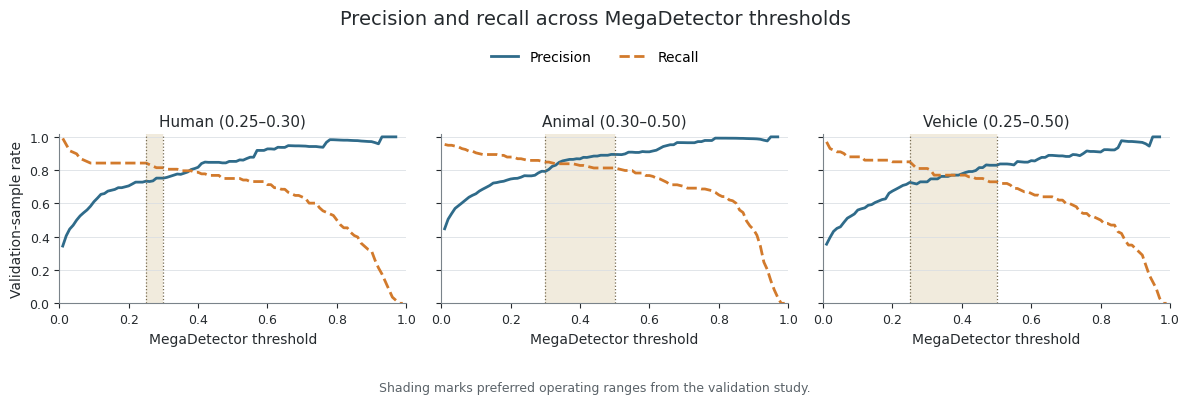

In [177]:
preferred_range_lookup = class_specific_threshold_recommendations.set_index(
    "target_class"
)[["preferred_range_lower", "preferred_range_upper"]]

fig, axes = plt.subplots(1, 3, figsize=(12, 3.8), sharex=True, sharey=True)
for ax, target_class in zip(axes, TARGET_CLASSES):
    class_metrics = validation_threshold_metrics.loc[
        validation_threshold_metrics["target_class"].eq(target_class)
    ].sort_values("threshold")
    lower = preferred_range_lookup.loc[target_class, "preferred_range_lower"]
    upper = preferred_range_lookup.loc[target_class, "preferred_range_upper"]
    ax.axvspan(lower, upper, color=RANGE_COLOR, alpha=0.35, linewidth=0)
    ax.plot(
        class_metrics["threshold"],
        class_metrics["precision"],
        color=PRECISION_COLOR,
        linewidth=2,
        label="Precision",
    )
    ax.plot(
        class_metrics["threshold"],
        class_metrics["recall"],
        color=RECALL_COLOR,
        linewidth=2,
        linestyle="--",
        label="Recall",
    )
    ax.axvline(lower, color="#756A50", linewidth=0.9, linestyle=":")
    ax.axvline(upper, color="#756A50", linewidth=0.9, linestyle=":")
    ax.set_title(
        f"{CLASS_DISPLAY_NAMES[target_class]} ({lower:.2f}–{upper:.2f})",
        color=TEXT_COLOR,
        fontsize=11,
    )
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1.02)
    ax.set_xlabel("MegaDetector threshold", color=TEXT_COLOR)
    style_axis(ax, "Validation-sample rate" if ax is axes[0] else None)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    loc="upper center",
    bbox_to_anchor=(0.5, 0.91),
    ncol=2,
    frameon=False,
)
fig.suptitle(
    "Precision and recall across MegaDetector thresholds",
    fontsize=14,
    color=TEXT_COLOR,
    y=0.985,
)
fig.text(
    0.5,
    -0.02,
    "Shading marks preferred operating ranges from the validation study.",
    ha="center",
    fontsize=9,
    color="#5B6369",
)
fig.tight_layout(rect=[0, 0.06, 1, 0.84])
fig_threshold_precision_recall_path = (
    FIGURE_DIR / "fig_threshold_precision_recall.png"
)
finalise_figure(fig, fig_threshold_precision_recall_path)
plt.show()

### Figure 2. Confidence-Band Manual Confirmation

Saved: analysis_outputs\figures\fig_confidence_band_confirmation.png


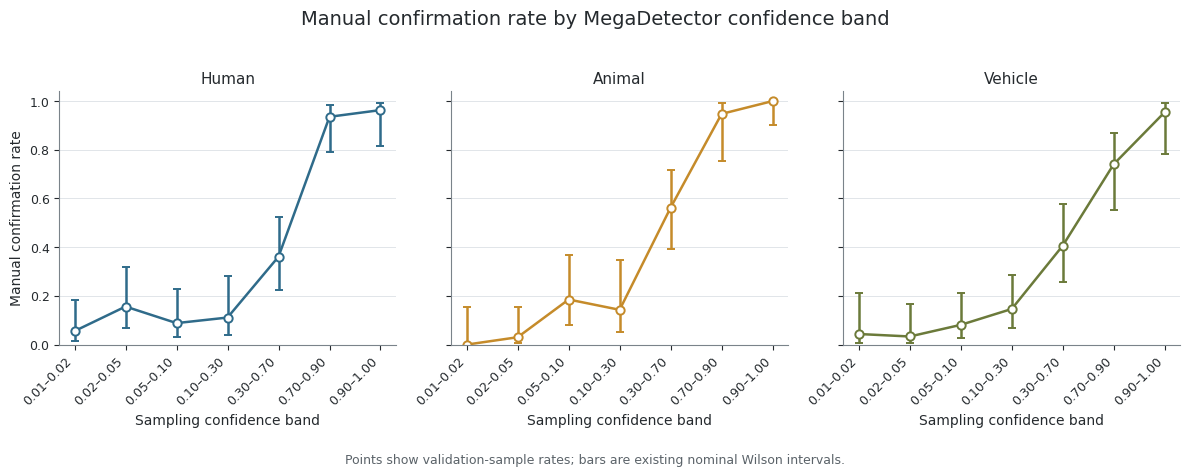

In [178]:
confirmation_figure_data = positive_confidence_band_truth_rates_with_ci.copy()
assert not FINAL_PUBLIC_FORBIDDEN_COLUMNS.intersection(
    confirmation_figure_data.columns
)

fig, axes = plt.subplots(1, 3, figsize=(12, 4.2), sharey=True)
for ax, target_class in zip(axes, TARGET_CLASSES):
    class_rows = confirmation_figure_data.loc[
        confirmation_figure_data["target_class"].eq(target_class)
    ].sort_values("sampling_confidence_band")
    x = np.arange(len(class_rows))
    rates = class_rows["manual_positive_rate"].to_numpy(dtype=float)
    lower_error = rates - class_rows["manual_positive_rate_ci_low"].to_numpy(
        dtype=float
    )
    upper_error = class_rows["manual_positive_rate_ci_high"].to_numpy(
        dtype=float
    ) - rates
    ax.errorbar(
        x,
        rates,
        yerr=np.vstack([lower_error, upper_error]),
        color=CLASS_COLORS[target_class],
        marker="o",
        markerfacecolor="white",
        markeredgewidth=1.4,
        linewidth=1.8,
        capsize=3,
    )
    labels = [
        str(value).replace("_to_", "–").replace("_", " ")
        for value in class_rows["sampling_confidence_band"]
    ]
    ax.set_xticks(x, labels, rotation=45, ha="right")
    ax.set_ylim(0, 1.04)
    ax.set_title(CLASS_DISPLAY_NAMES[target_class], fontsize=11, color=TEXT_COLOR)
    ax.set_xlabel("Sampling confidence band", color=TEXT_COLOR)
    style_axis(ax, "Manual confirmation rate" if ax is axes[0] else None)

fig.suptitle(
    "Manual confirmation rate by MegaDetector confidence band",
    fontsize=14,
    color=TEXT_COLOR,
    y=1.03,
)
fig.text(
    0.5,
    -0.05,
    "Points show validation-sample rates; bars are existing nominal Wilson intervals.",
    ha="center",
    fontsize=9,
    color="#5B6369",
)
fig.tight_layout()
fig_confidence_band_confirmation_path = (
    FIGURE_DIR / "fig_confidence_band_confirmation.png"
)
finalise_figure(fig, fig_confidence_band_confirmation_path)
plt.show()

### Figure 3. Human Missed-Detection Consequences

Saved: analysis_outputs\figures\fig_human_missed_detection_risk.png


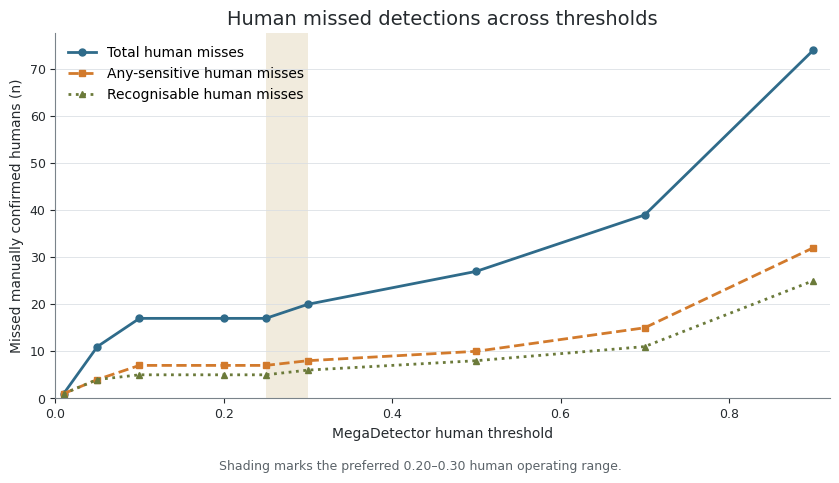

In [179]:
human_range = preferred_range_lookup.loc["human"]
human_risk_plot_data = human_sensitive_false_negative_audit.sort_values(
    "threshold"
)

fig, ax = plt.subplots(figsize=(8.5, 4.8))
ax.axvspan(
    human_range["preferred_range_lower"],
    human_range["preferred_range_upper"],
    color=RANGE_COLOR,
    alpha=0.35,
    linewidth=0,
)
risk_series = [
    ("total_human_missed_n", "Total human misses", PRECISION_COLOR, "-", "o"),
    (
        "any_sensitive_human_missed_n",
        "Any-sensitive human misses",
        RECALL_COLOR,
        "--",
        "s",
    ),
    (
        "recognisable_human_missed_n",
        "Recognisable human misses",
        "#6B7A3A",
        ":",
        "^",
    ),
]
for column, label, color, line_style, marker in risk_series:
    ax.plot(
        human_risk_plot_data["threshold"],
        human_risk_plot_data[column],
        label=label,
        color=color,
        linestyle=line_style,
        marker=marker,
        linewidth=2,
        markersize=5,
    )
ax.set_xlim(0, 0.92)
ax.set_ylim(bottom=0)
ax.set_xlabel("MegaDetector human threshold", color=TEXT_COLOR)
style_axis(ax, "Missed manually confirmed humans (n)")
ax.legend(frameon=False, loc="upper left")
ax.set_title(
    "Human missed detections across thresholds",
    fontsize=14,
    color=TEXT_COLOR,
)
fig.text(
    0.5,
    0.01,
    "Shading marks the preferred 0.20–0.30 human operating range.",
    ha="center",
    fontsize=9,
    color="#5B6369",
)
fig.tight_layout(rect=[0, 0.04, 1, 1])
fig_human_missed_detection_risk_path = (
    FIGURE_DIR / "fig_human_missed_detection_risk.png"
)
finalise_figure(fig, fig_human_missed_detection_risk_path)
plt.show()

### Figure 4. Time-Of-Day Reference Performance

This figure describes validation-sample variation at the established Section 9 reference threshold. It does not estimate or recommend subgroup-specific thresholds.

Saved: analysis_outputs\figures\fig_time_of_day_performance.png


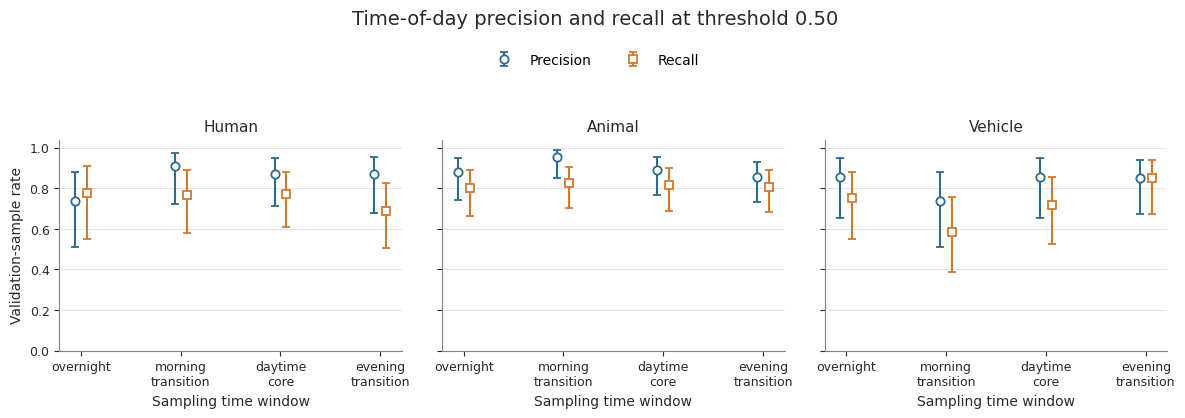

In [180]:
time_plot_data = time_window_threshold_performance.loc[
    np.isclose(
        time_window_threshold_performance["threshold"],
        CONTEXT_REFERENCE_THRESHOLD,
    )
].copy()
assert len(time_plot_data) == len(TARGET_CLASSES) * len(CONTEXT_TIME_ORDER)

fig, axes = plt.subplots(1, 3, figsize=(12, 4.2), sharey=True)
for ax, target_class in zip(axes, TARGET_CLASSES):
    class_rows = (
        time_plot_data.loc[time_plot_data["target_class"].eq(target_class)]
        .set_index("sampling_time_window")
        .reindex(CONTEXT_TIME_ORDER)
        .reset_index()
    )
    x = np.arange(len(class_rows))
    for metric, color, marker, offset in [
        ("precision", PRECISION_COLOR, "o", -0.06),
        ("recall", RECALL_COLOR, "s", 0.06),
    ]:
        values = class_rows[metric].to_numpy(dtype=float)
        lower = class_rows[f"{metric}_ci_low"].to_numpy(dtype=float)
        upper = class_rows[f"{metric}_ci_high"].to_numpy(dtype=float)
        ax.errorbar(
            x + offset,
            values,
            yerr=np.vstack([values - lower, upper - values]),
            label=metric.capitalize(),
            color=color,
            marker=marker,
            markerfacecolor="white",
            markeredgewidth=1.3,
            linestyle="none",
            capsize=3,
        )
    labels = [value.replace("_", "\n") for value in CONTEXT_TIME_ORDER]
    ax.set_xticks(x, labels)
    ax.set_ylim(0, 1.04)
    ax.set_title(CLASS_DISPLAY_NAMES[target_class], fontsize=11, color=TEXT_COLOR)
    ax.set_xlabel("Sampling time window", color=TEXT_COLOR)
    style_axis(ax, "Validation-sample rate" if ax is axes[0] else None)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    loc="upper center",
    bbox_to_anchor=(0.5, 0.91),
    ncol=2,
    frameon=False,
)
fig.suptitle(
    f"Time-of-day precision and recall at threshold {CONTEXT_REFERENCE_THRESHOLD:.2f}",
    fontsize=14,
    color=TEXT_COLOR,
    y=0.985,
)
fig.tight_layout(rect=[0, 0, 1, 0.84])
fig_time_of_day_performance_path = (
    FIGURE_DIR / "fig_time_of_day_performance.png"
)
finalise_figure(fig, fig_time_of_day_performance_path)
plt.show()

### Final Key Findings And Output Manifest

In [181]:
recommendation_lookup = class_specific_threshold_recommendations.set_index(
    "target_class"
)
decision_lookup = class_threshold_decision_points.set_index(
    ["target_class", "threshold"]
)

key_finding_rows = []
for target_class in TARGET_CLASSES:
    recommendation = recommendation_lookup.loc[target_class]
    lower_threshold = float(recommendation["preferred_range_lower"])
    upper_threshold = float(recommendation["preferred_range_upper"])
    lower = decision_lookup.loc[(target_class, lower_threshold)]
    upper = decision_lookup.loc[(target_class, upper_threshold)]
    key_finding_rows.append(
        {
            "research_question": "RQ1/RQ2",
            "finding_id": f"{target_class}_preferred_operating_range",
            "target_class": target_class,
            "metric_or_topic": "preferred operating range",
            "value_or_result": (
                f"{lower_threshold:.2f}–{upper_threshold:.2f}; endpoint precision "
                f"{lower['precision']:.3f}–{upper['precision']:.3f}, recall "
                f"{lower['recall']:.3f}–{upper['recall']:.3f}, F1 "
                f"{lower['F1']:.3f}–{upper['F1']:.3f}"
            ),
            "scope": "manually validated sample",
            "main_caveat": "Evidence-informed range, not a population-universal mathematical optimum.",
            "suggested_dissertation_location": "Main results: operational threshold strategy",
        }
    )

key_finding_rows.append(
    {
        "research_question": "RQ2",
        "finding_id": "universal_threshold_strategy",
        "target_class": "all classes",
        "metric_or_topic": "universal threshold",
        "value_or_result": "Not preferred; class-specific fixed ranges are recommended.",
        "scope": "validation-study synthesis",
        "main_caveat": "Recommendations require prospective or external validation before production use.",
        "suggested_dissertation_location": "Main results and discussion",
    }
)

animal_bbox = bbox_confidence_spearman.loc[
    bbox_confidence_spearman["target_class"].eq("animal")
].iloc[0]
key_finding_rows.append(
    {
        "research_question": "RQ3",
        "finding_id": "animal_predicted_bbox_confidence",
        "target_class": "animal",
        "metric_or_topic": "predicted bbox area and confidence",
        "value_or_result": f"Spearman rho={animal_bbox['spearman_rho']:.3f}",
        "scope": "positive-pathway detections with predicted target-class boxes",
        "main_caveat": "Predicted bbox size is not manually measured true object size; no size-specific threshold is justified.",
        "suggested_dissertation_location": "Main results or supplementary bbox analysis",
    }
)

vehicle_time = contextual_variation_summary.loc[
    contextual_variation_summary["target_class"].eq("vehicle")
    & contextual_variation_summary["context_variable"].eq("time")
].iloc[0]
key_finding_rows.append(
    {
        "research_question": "RQ3",
        "finding_id": "vehicle_time_of_day_variation",
        "target_class": "vehicle",
        "metric_or_topic": "time-of-day reference performance",
        "value_or_result": (
            f"At 0.50, supported-window precision range={vehicle_time['precision_range']:.3f}; "
            f"recall range={vehicle_time['recall_range']:.3f}."
        ),
        "scope": "validation-sample time windows",
        "main_caveat": "Descriptive variation only; no time-specific threshold is estimated.",
        "suggested_dissertation_location": "Main results: contextual robustness",
    }
)

key_finding_rows.append(
    {
        "research_question": "RQ3",
        "finding_id": "context_interpretation",
        "target_class": "all classes",
        "metric_or_topic": "contextual robustness",
        "value_or_result": "Time is primary; season and sampling-oriented latitude groups are secondary descriptive checks.",
        "scope": "deliberately stratified validation sample",
        "main_caveat": "No time-, season- or geography-specific thresholds are justified.",
        "suggested_dissertation_location": "Discussion and limitations",
    }
)

human_lower = decision_lookup.loc[("human", 0.20)]
human_upper = decision_lookup.loc[("human", 0.30)]
key_finding_rows.append(
    {
        "research_question": "RQ4",
        "finding_id": "human_sensitive_misses_at_range_endpoints",
        "target_class": "human",
        "metric_or_topic": "privacy/safeguarding-sensitive misses",
        "value_or_result": (
            f"Any-sensitive FN {int(human_lower['any_sensitive_human_missed_n'])} at 0.20 and "
            f"{int(human_upper['any_sensitive_human_missed_n'])} at 0.30; recognisable FN "
            f"{int(human_lower['recognisable_human_missed_n'])} and "
            f"{int(human_upper['recognisable_human_missed_n'])}, respectively."
        ),
        "scope": "manually confirmed human-positive validation observations",
        "main_caveat": "Counts are validation-sample consequences, not population risk prevalence.",
        "suggested_dissertation_location": "Main results: privacy and safeguarding",
    }
)

animal_uncertain = uncertain_label_reference_threshold_summary.loc[
    uncertain_label_reference_threshold_summary["target_class"].eq("animal")
].iloc[0]
key_finding_rows.append(
    {
        "research_question": "RQ1/RQ2",
        "finding_id": "animal_uncertain_label_robustness",
        "target_class": "animal",
        "metric_or_topic": "uncertain-label robustness",
        "value_or_result": (
            f"Usable Uncertain n={int(animal_uncertain['uncertain_n'])} "
            f"({animal_uncertain['uncertain_share_of_globally_usable']:.1%}); at 0.50, maximum "
            f"absolute F1 change from primary={animal_uncertain['max_absolute_f1_change_from_primary']:.3f}."
        ),
        "scope": "deterministic extreme recoding sensitivity",
        "main_caveat": "Extreme recodings are hypothetical scenarios, not alternative ground truths.",
        "suggested_dissertation_location": "Sensitivity analysis or limitations",
    }
)

animal_zero = all_zero_false_negative_audit.loc[
    all_zero_false_negative_audit["target_class"].eq("animal")
].iloc[0]
key_finding_rows.append(
    {
        "research_question": "RQ1/RQ2",
        "finding_id": "animal_all_zero_positive_finding",
        "target_class": "animal",
        "metric_or_topic": "all-three-zero manual audit",
        "value_or_result": (
            f"{int(animal_zero['manual_positive_n'])}/{int(animal_zero['evaluable_n'])} "
            "reviewed evaluable images were manually animal-positive."
        ),
        "scope": "sampled all-three-zero validation pathway",
        "main_caveat": "This is not population-wide recall; exact zero does not guarantee true absence.",
        "suggested_dissertation_location": "Main results or structured-error discussion",
    }
)

key_findings = pd.DataFrame(key_finding_rows)
assert not FINAL_PUBLIC_FORBIDDEN_COLUMNS.intersection(key_findings.columns)
assert key_findings["finding_id"].is_unique
key_findings_path = TABLE_DIR / "key_findings.csv"
key_findings.to_csv(key_findings_path, index=False)
if key_findings_path not in written_files:
    written_files.append(key_findings_path)
display(key_findings)
print("Saved:", key_findings_path.relative_to(PROJECT_ROOT))

,research_question,finding_id,target_class,metric_or_topic,value_or_result,scope,main_caveat,suggested_dissertation_location
0,RQ1/RQ2,human_preferred_operating_range,human,preferred operating range,"0.25–0.30; endpoint precision 0.734–0.752, rec...",manually validated sample,"Evidence-informed range, not a population-univ...",Main results: operational threshold strategy
1,RQ1/RQ2,animal_preferred_operating_range,animal,preferred operating range,"0.30–0.50; endpoint precision 0.792–0.894, rec...",manually validated sample,"Evidence-informed range, not a population-univ...",Main results: operational threshold strategy
2,RQ1/RQ2,vehicle_preferred_operating_range,vehicle,preferred operating range,"0.25–0.50; endpoint precision 0.726–0.830, rec...",manually validated sample,"Evidence-informed range, not a population-univ...",Main results: operational threshold strategy
3,RQ2,universal_threshold_strategy,all classes,universal threshold,Not preferred; class-specific fixed ranges are...,validation-study synthesis,Recommendations require prospective or externa...,Main results and discussion
4,RQ3,animal_predicted_bbox_confidence,animal,predicted bbox area and confidence,Spearman rho=0.401,positive-pathway detections with predicted tar...,Predicted bbox size is not manually measured t...,Main results or supplementary bbox analysis
5,RQ3,vehicle_time_of_day_variation,vehicle,time-of-day reference performance,"At 0.50, supported-window precision range=0.12...",validation-sample time windows,Descriptive variation only; no time-specific t...,Main results: contextual robustness
6,RQ3,context_interpretation,all classes,contextual robustness,Time is primary; season and sampling-oriented ...,deliberately stratified validation sample,"No time-, season- or geography-specific thresh...",Discussion and limitations
7,RQ4,human_sensitive_misses_at_range_endpoints,human,privacy/safeguarding-sensitive misses,Any-sensitive FN 7 at 0.20 and 8 at 0.30; reco...,manually confirmed human-positive validation o...,"Counts are validation-sample consequences, not...",Main results: privacy and safeguarding
8,RQ1/RQ2,animal_uncertain_label_robustness,animal,uncertain-label robustness,"Usable Uncertain n=59 (7.2%); at 0.50, maximum...",deterministic extreme recoding sensitivity,"Extreme recodings are hypothetical scenarios, ...",Sensitivity analysis or limitations
9,RQ1/RQ2,animal_all_zero_positive_finding,animal,all-three-zero manual audit,6/151 reviewed evaluable images were manually ...,sampled all-three-zero validation pathway,This is not population-wide recall; exact zero...,Main results or structured-error discussion


Saved: analysis_outputs\tables\key_findings.csv


In [182]:
final_output_manifest_path = TABLE_DIR / "final_output_manifest.csv"
manifest_candidates = [Path(path) for path in written_files]
manifest_candidates.extend(FINAL_FIGURE_PATHS)
manifest_candidates.extend([key_findings_path, final_output_manifest_path])


def normalise_output_path(path):
    path = Path(path)
    return path if path.is_absolute() else PROJECT_ROOT / path


def infer_section_source(filename):
    if filename.startswith("fig_") or filename in {
        "key_findings.csv",
        "final_output_manifest.csv",
    }:
        return "Final Dissertation Outputs And Analysis Lock"
    if filename == "analysis_dataset.csv":
        return "Sections 2–3"
    if filename in {path.name for path in SECTION12_OUTPUT_PATHS}:
        return "Section 12"
    if filename in {path.name for path in SECTION11_OUTPUT_PATHS}:
        return "Section 11"
    if filename in {path.name for path in SECTION10_OUTPUT_PATHS}:
        return "Section 10"
    if filename in {path.name for path in SECTION9_OUTPUT_PATHS}:
        return "Section 9"
    if filename in {path.name for path in SECTION8_OUTPUT_PATHS}:
        return "Section 8"
    if filename in {path.name for path in SECTION7_OUTPUT_PATHS}:
        return "Section 7"
    if filename in {path.name for path in SECTION6_OUTPUT_PATHS}:
        return "Section 6"
    return "Sections 0–5"


unique_manifest_paths = {}
for candidate in manifest_candidates:
    absolute_path = normalise_output_path(candidate)
    relative_path = absolute_path.relative_to(PROJECT_ROOT)
    unique_manifest_paths[str(relative_path)] = absolute_path

manifest_rows = []
main_table_names = {
    "key_findings.csv",
    "class_specific_threshold_recommendations.csv",
    "class_threshold_decision_points.csv",
}
for relative_path_text, absolute_path in sorted(unique_manifest_paths.items()):
    filename = absolute_path.name
    suffix = absolute_path.suffix.lower()
    if suffix == ".png":
        output_type = "FIGURE_PNG"
        recommended_use = "MAIN_TEXT_FIGURE"
    elif filename == "analysis_dataset.csv":
        output_type = "DERIVED_IMAGE_LEVEL_CSV"
        recommended_use = "INTERNAL_ONLY"
    else:
        output_type = "AGGREGATE_TABLE_CSV"
        recommended_use = (
            "MAIN_TEXT_TABLE" if filename in main_table_names else "SUPPLEMENTARY"
        )
    public_release_status = (
        "PRIVATE_DO_NOT_COMMIT"
        if filename == "analysis_dataset.csv"
        else "AGGREGATE_OK_FOR_REVIEW"
    )
    manifest_rows.append(
        {
            "output_path": relative_path_text,
            "output_type": output_type,
            "section_source": infer_section_source(filename),
            "recommended_use": recommended_use,
            "public_release_status": public_release_status,
        }
    )

final_output_manifest = pd.DataFrame(manifest_rows)
assert not FINAL_PUBLIC_FORBIDDEN_COLUMNS.intersection(
    final_output_manifest.columns
)
assert final_output_manifest["output_path"].is_unique
private_manifest_row = final_output_manifest.loc[
    final_output_manifest["output_path"].map(
        lambda value: Path(value).name
    ).eq("analysis_dataset.csv")
]
assert len(private_manifest_row) == 1
assert private_manifest_row["public_release_status"].eq(
    "PRIVATE_DO_NOT_COMMIT"
).all()
assert private_manifest_row["recommended_use"].eq("INTERNAL_ONLY").all()

final_output_manifest.to_csv(final_output_manifest_path, index=False)
if final_output_manifest_path not in written_files:
    written_files.append(final_output_manifest_path)
display(final_output_manifest)
print("Saved:", final_output_manifest_path.relative_to(PROJECT_ROOT))

,output_path,output_type,section_source,recommended_use,public_release_status
0,analysis_outputs\derived\analysis_dataset.csv,DERIVED_IMAGE_LEVEL_CSV,Sections 2–3,INTERNAL_ONLY,PRIVATE_DO_NOT_COMMIT
1,analysis_outputs\figures\fig_confidence_band_c...,FIGURE_PNG,Final Dissertation Outputs And Analysis Lock,MAIN_TEXT_FIGURE,AGGREGATE_OK_FOR_REVIEW
2,analysis_outputs\figures\fig_human_missed_dete...,FIGURE_PNG,Final Dissertation Outputs And Analysis Lock,MAIN_TEXT_FIGURE,AGGREGATE_OK_FOR_REVIEW
3,analysis_outputs\figures\fig_human_missed_dete...,FIGURE_PNG,Final Dissertation Outputs And Analysis Lock,MAIN_TEXT_FIGURE,AGGREGATE_OK_FOR_REVIEW
4,analysis_outputs\figures\fig_threshold_precisi...,FIGURE_PNG,Final Dissertation Outputs And Analysis Lock,MAIN_TEXT_FIGURE,AGGREGATE_OK_FOR_REVIEW
...,...,...,...,...,...
78,analysis_outputs\tables\unweighted_vs_poststra...,AGGREGATE_TABLE_CSV,Section 6,SUPPLEMENTARY,AGGREGATE_OK_FOR_REVIEW
79,analysis_outputs\tables\validation_threshold_m...,AGGREGATE_TABLE_CSV,Sections 0–5,SUPPLEMENTARY,AGGREGATE_OK_FOR_REVIEW
80,analysis_outputs\tables\validation_threshold_m...,AGGREGATE_TABLE_CSV,Sections 0–5,SUPPLEMENTARY,AGGREGATE_OK_FOR_REVIEW
81,analysis_outputs\tables\zero_confidence_sampli...,AGGREGATE_TABLE_CSV,Sections 0–5,SUPPLEMENTARY,AGGREGATE_OK_FOR_REVIEW


Saved: analysis_outputs\tables\final_output_manifest.csv


In [183]:
assert len(FINAL_FIGURE_PATHS) == 4
assert all(path.exists() for path in FINAL_FIGURE_PATHS)
assert key_findings_path.exists()
assert final_output_manifest_path.exists()
assert len(class_threshold_decision_points) == 21
assert len(threshold_incremental_tradeoffs) == len(TARGET_CLASSES) * (
    len(DECISION_THRESHOLDS) - 1
)

manual_annotation_n = int(len(manual_annotations))
evaluable_by_class = (
    final_sample_exclusions.set_index("class")["final_evaluable_n"]
    .astype(int)
    .to_dict()
)
final_ranges = {
    target_class: (
        float(recommendation_lookup.loc[target_class, "preferred_range_lower"]),
        float(recommendation_lookup.loc[target_class, "preferred_range_upper"]),
    )
    for target_class in TARGET_CLASSES
}
private_outputs_marked = bool(
    final_output_manifest["public_release_status"].eq(
        "PRIVATE_DO_NOT_COMMIT"
    ).any()
)

print("FINAL QC SUMMARY")
print("Notebook run completed successfully: Yes")
print("Manual annotation n:", manual_annotation_n)
print("Evaluable n by class:", evaluable_by_class)
print("Final recommended ranges:", final_ranges)
print("Universal threshold preferred: No")
print("Number of final figures:", len(FINAL_FIGURE_PATHS))
print("Number of final key findings:", len(key_findings))
print("Number of output-manifest entries:", len(final_output_manifest))
print("Any private outputs marked DO_NOT_COMMIT:", private_outputs_marked)

FINAL QC SUMMARY
Notebook run completed successfully: Yes
Manual annotation n: 850
Evaluable n by class: {'human': 809, 'animal': 760, 'vehicle': 807}
Final recommended ranges: {'human': (0.25, 0.3), 'animal': (0.3, 0.5), 'vehicle': (0.25, 0.5)}
Universal threshold preferred: No
Number of final figures: 4
Number of final key findings: 10
Number of output-manifest entries: 83
Any private outputs marked DO_NOT_COMMIT: True


Saved: analysis_outputs\figures\fig_threshold_precision_recall_unshaded.png


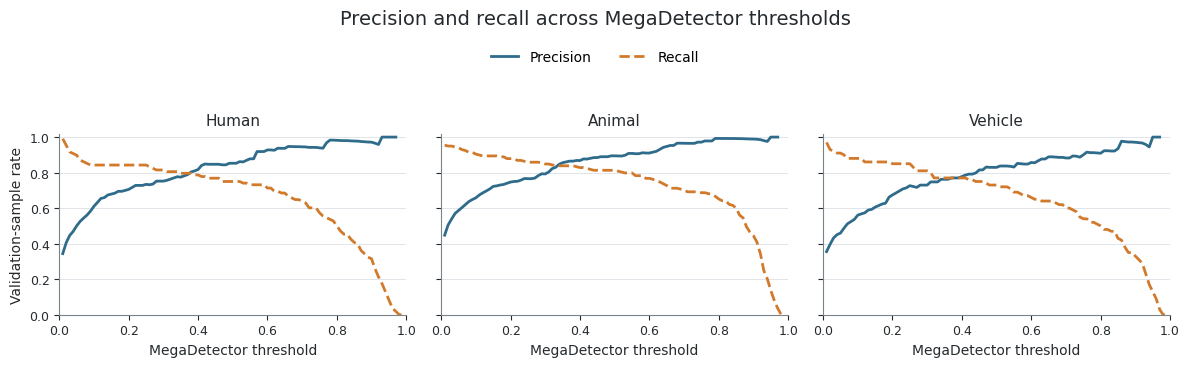

In [184]:
# Dissertation Figure 4.1:
# Precision and recall across thresholds WITHOUT preferred-range information
import matplotlib.pyplot as plt
fig, axes = plt.subplots(
    1, 3,
    figsize=(12, 3.8),
    sharex=True,
    sharey=True
)

for ax, target_class in zip(axes, TARGET_CLASSES):

    class_metrics = (
        validation_threshold_metrics.loc[
            validation_threshold_metrics["target_class"].eq(target_class)
        ]
        .sort_values("threshold")
    )

    ax.plot(
        class_metrics["threshold"],
        class_metrics["precision"],
        color=PRECISION_COLOR,
        linewidth=2,
        label="Precision",
    )

    ax.plot(
        class_metrics["threshold"],
        class_metrics["recall"],
        color=RECALL_COLOR,
        linewidth=2,
        linestyle="--",
        label="Recall",
    )

    ax.set_title(
        CLASS_DISPLAY_NAMES[target_class],
        color=TEXT_COLOR,
        fontsize=11,
    )

    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1.02)
    ax.set_xlabel("MegaDetector threshold", color=TEXT_COLOR)

    style_axis(
        ax,
        "Validation-sample rate" if ax is axes[0] else None
    )

handles, labels = axes[0].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    loc="upper center",
    bbox_to_anchor=(0.5, 0.91),
    ncol=2,
    frameon=False,
)

fig.suptitle(
    "Precision and recall across MegaDetector thresholds",
    fontsize=14,
    color=TEXT_COLOR,
    y=0.985,
)

fig.tight_layout(rect=[0, 0.03, 1, 0.84])

fig_threshold_precision_recall_unshaded_path = (
    FIGURE_DIR / "fig_threshold_precision_recall_unshaded.png"
)

finalise_figure(
    fig,
    fig_threshold_precision_recall_unshaded_path
)

plt.show()

Saved: analysis_outputs\figures\fig_human_missed_detection_risk_unshaded.png


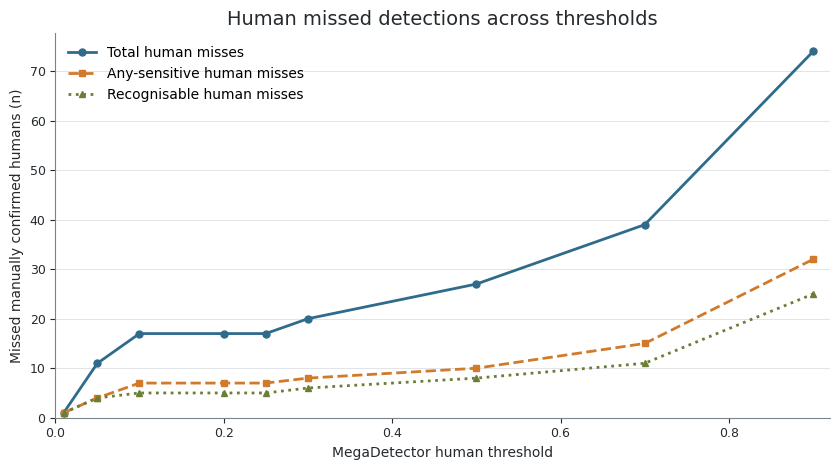

In [185]:
# Dissertation human-risk figure WITHOUT preferred-range shading

human_risk_plot_data = (
    human_sensitive_false_negative_audit
    .sort_values("threshold")
)

fig, ax = plt.subplots(figsize=(8.5, 4.8))

risk_series = [
    (
        "total_human_missed_n",
        "Total human misses",
        PRECISION_COLOR,
        "-",
        "o",
    ),
    (
        "any_sensitive_human_missed_n",
        "Any-sensitive human misses",
        RECALL_COLOR,
        "--",
        "s",
    ),
    (
        "recognisable_human_missed_n",
        "Recognisable human misses",
        "#6B7D36",
        ":",
        "^",
    ),
]

for column, label, color, line_style, marker in risk_series:
    ax.plot(
        human_risk_plot_data["threshold"],
        human_risk_plot_data[column],
        label=label,
        color=color,
        linestyle=line_style,
        marker=marker,
        linewidth=2,
        markersize=5,
    )

ax.set_xlim(0, 0.92)
ax.set_ylim(bottom=0)

ax.set_xlabel(
    "MegaDetector human threshold",
    color=TEXT_COLOR
)

style_axis(
    ax,
    "Missed manually confirmed humans (n)"
)

ax.legend(
    frameon=False,
    loc="upper left"
)

ax.set_title(
    "Human missed detections across thresholds",
    fontsize=14,
    color=TEXT_COLOR,
)

fig.tight_layout()

fig_human_missed_detection_risk_unshaded_path = (
    FIGURE_DIR / "fig_human_missed_detection_risk_unshaded.png"
)

finalise_figure(
    fig,
    fig_human_missed_detection_risk_unshaded_path
)

plt.show()